In [3]:
from dotenv import load_dotenv
load_dotenv()

True

## Import libraries

In [4]:
from langchain.agents import create_agent
from langchain.tools import tool,ToolRuntime
from langchain.messages import HumanMessage, AIMessage, ToolMessage
from langgraph.checkpoint.memory import InMemorySaver
from langchain.agents.middleware import TodoListMiddleware, before_model, AgentState, HumanInTheLoopMiddleware, wrap_tool_call, before_agent
from deepagents.middleware import FilesystemMiddleware
from deepagents.backends import CompositeBackend, FilesystemBackend, StoreBackend 
from langgraph.store.memory import InMemoryStore
from langgraph.runtime import Runtime
import json
from typing import Any, Optional, Literal, List, Dict, Annotated
from tavily import TavilyClient
from langchain.chat_models import init_chat_model
from langchain_mcp_adapters.client import MultiServerMCPClient
from pydantic import BaseModel, Field, model_validator, field_validator
from langgraph.types import Command, interrupt, Overwrite
from pathlib import Path
from langchain_core.output_parsers import StrOutputParser, JsonOutputParser
from langchain_core.prompts import PromptTemplate, ChatPromptTemplate
from langchain_core.runnables import RunnableLambda, RunnableBranch
from langchain_openai import ChatOpenAI
from operator import add
import sys
from langchain_core.messages import AIMessageChunk
from langchain_openai import ChatOpenAI
from langgraph.config import get_stream_writer
from langchain.chat_models import init_chat_model
from langchain_core.runnables import RunnableLambda
import io
import re
from xml.sax.saxutils import escape
from reportlab.lib.pagesizes import LETTER
from reportlab.lib.styles import ParagraphStyle, getSampleStyleSheet
from reportlab.lib.units import inch
from reportlab.platypus import Paragraph, SimpleDocTemplate, Spacer
import os
import subprocess
import tempfile

## General tools/chains

### Streaming tool

In [349]:
import uuid
import sys
import json
from typing import Any, Optional
from langchain_core.messages import AIMessageChunk


# Toggle for streaming output:
# - debug=False: show only custom progress events + final assistant text
# - debug=True: also print raw update payloads (tool/framework events)
debug = False


def _infer_input_query_from_payload(payload: dict, fallback: str = "") -> str:
    if isinstance(payload.get("input_query"), str) and payload.get("input_query"):
        return payload.get("input_query")

    msgs = payload.get("messages") or []
    if isinstance(msgs, list):
        try:
            for m in reversed(list(msgs)):
                if isinstance(m, dict) and m.get("role") in ("user", "human") and isinstance(m.get("content"), str):
                    content = (m.get("content") or "").strip()
                    if content:
                        return content
                if hasattr(m, "type") and getattr(m, "type") in ("human", "user") and hasattr(m, "content"):
                    content = str(getattr(m, "content") or "").strip()
                    if content:
                        return content
        except Exception:
            pass

    return (fallback or "").strip()


def make_dummy_design_schema(input_query: str) -> dict:
    """Create a conservative DesignSchema-shaped dict.

    This is intentionally minimal: it only sets values that are explicitly
    indicated by keywords in the user prompt.
    """
    q = (input_query or "").lower()

    schema: dict[str, Any] = {
        "ui": {
            "type": None,
            "variant": None,
            "style": None,
            "density": None,
            "navigation": None,
            "feedback_components": [],
        },
        "theme": {
            "primary_color": None,
            "secondary_color": None,
            "mode": None,
        },
        "features": {
            "search": None,
            "filter": None,
            "sorting": None,
            "cart": None,
            "wishlist": None,
            "reviews": None,
        },
        "constraints": {"tech_stack": ["html", "css", "javascript"]},
        "extra_requirements": [],
    }

    if "dark mode" in q or "dark-mode" in q or " dark " in f" {q} ":
        schema["theme"]["mode"] = "dark"
    elif "light mode" in q or "light-mode" in q:
        schema["theme"]["mode"] = "light"

    if "top nav" in q or "top navigation" in q or "navbar" in q:
        schema["ui"]["navigation"] = "top_nav"
    elif "side nav" in q or "side navigation" in q or "sidebar" in q:
        schema["ui"]["navigation"] = "side_nav"
    elif "hamburger" in q:
        schema["ui"]["navigation"] = "hamburger"

    if "compact" in q:
        schema["ui"]["density"] = "compact"
    elif "comfortable" in q:
        schema["ui"]["density"] = "comfortable"

    if "minimal" in q:
        schema["ui"]["style"] = "minimal"
    elif "modern" in q:
        schema["ui"]["style"] = "modern"

    if "grid" in q:
        schema["ui"]["variant"] = "grid"
    elif "list" in q:
        schema["ui"]["variant"] = "list"

    if "product listing" in q or "product list" in q or "listing page" in q:
        schema["ui"]["type"] = "product_listing"
    elif "landing page" in q:
        schema["ui"]["type"] = "landing_page"
    elif "checkout" in q:
        schema["ui"]["type"] = "checkout"
    elif "cart" in q and "product" not in q:
        schema["ui"]["type"] = "cart"

    if "search" in q:
        schema["features"]["search"] = True
    if "filter" in q or "filters" in q:
        schema["features"]["filter"] = True
    if "sort" in q or "sorting" in q:
        schema["features"]["sorting"] = True
    if "cart" in q:
        schema["features"]["cart"] = True
    if "wishlist" in q or "wish list" in q:
        schema["features"]["wishlist"] = True
    if "review" in q or "reviews" in q or "rating" in q or "ratings" in q:
        schema["features"]["reviews"] = True

    try:
        if "DesignSchema" in globals():
            schema = globals()["DesignSchema"].model_validate(schema).model_dump()
    except Exception:
        pass

    return schema


def stream_agent_run(
    agent,
    *,
    query: Optional[str] = None,
    payload: Optional[dict] = None,
    design_schema: Optional[dict] = None,
    auto_add_design_schema: bool = True,
    config: Optional[dict] = None,
    stream_mode: Optional[list[str]] = None,
    version: str = "v2",
    header: Optional[str] = None,
    print_stream: bool = True,
    debug: bool = debug,
    print_updates: Optional[bool] = None,
    updates_max_chars: int = 4000,
) -> dict:
    """Stream an agent run.

    User-friendly mode (debug=False):
    - Prints custom events and final assistant text.

    Debug mode (debug=True):
    - Also prints raw updates payloads for tool/framework observability.

    Return contract (stable):
    - final, state, tool_feedback, custom_events, reasoning_summary
    """
    if payload is None:
        payload = {
            "messages": [
                {"role": "user", "content": (query or "")},
            ]
        }

    if not isinstance(payload, dict):
        raise TypeError("payload must be a dict")

    if query is not None and (not isinstance(payload.get("input_query"), str) or not payload.get("input_query")):
        payload["input_query"] = query
    if not isinstance(payload.get("input_query"), str) or not payload.get("input_query"):
        payload["input_query"] = _infer_input_query_from_payload(payload, fallback=(query or ""))

    if design_schema is not None:
        payload["design_schema"] = design_schema
    elif auto_add_design_schema:
        ds = payload.get("design_schema")
        if not isinstance(ds, dict) or not ds:
            payload["design_schema"] = make_dummy_design_schema(payload.get("input_query") or "")

    if stream_mode is None:
        stream_mode = ["updates", "messages", "custom"]

    if config is None:
        config = {"configurable": {"thread_id": f"run_{uuid.uuid4().hex[:8]}"}}

    if print_updates is None:
        print_updates = bool(debug)

    if header and print_stream:
        print(header)

    final_text_parts: list[str] = []
    tool_feedback: list[str] = []
    custom_events: list[Any] = []
    captured_state: dict[str, Any] = {}
    in_token_stream = False

    indent_level = 0
    indent_unit = "  "

    def _merge_state_update(update: Any) -> None:
        if not isinstance(update, dict):
            return
        for key, value in update.items():
            if key == "messages":
                continue
            captured_state[key] = value

    def _indent_text(text: str) -> str:
        prefix = indent_unit * indent_level
        lines = text.rstrip("\n").splitlines() or [""]
        return "\n".join(prefix + line for line in lines)

    for chunk in agent.stream(
        payload,
        stream_mode=stream_mode,
        version=version,
        config=config,
    ):
        if isinstance(chunk, tuple) and len(chunk) == 2:
            chunk_type, data = chunk
        else:
            chunk_type = chunk.get("type")
            data = chunk.get("data")

        if chunk_type == "updates" and isinstance(data, dict):
            for _step, update in data.items():
                _merge_state_update(update)

            if print_updates and print_stream:
                try:
                    rendered = json.dumps(data, default=str, ensure_ascii=False)
                except Exception:
                    rendered = str(data)
                if len(rendered) > updates_max_chars:
                    rendered = rendered[:updates_max_chars] + "…"
                if in_token_stream:
                    sys.stdout.write("\n")
                    sys.stdout.flush()
                    in_token_stream = False
                print(rendered)

            try:
                tools_update = data.get("tools")
                if isinstance(tools_update, dict):
                    msgs = tools_update.get("messages") or []
                    if msgs:
                        last_msg = msgs[-1]
                        content = getattr(last_msg, "content", "")
                        if isinstance(content, str) and content.strip():
                            tool_feedback.append(content.strip())
            except Exception:
                pass

        elif chunk_type == "messages" and isinstance(data, (tuple, list)) and len(data) == 2:
            token, _metadata = data
            if not isinstance(token, AIMessageChunk):
                continue

            blocks = getattr(token, "content_blocks", []) or []
            emitted_any = False
            for block in blocks:
                if not isinstance(block, dict) or block.get("type") != "text":
                    continue
                text = block.get("text", "") or ""
                if not text:
                    continue
                emitted_any = True
                final_text_parts.append(text)
                if print_stream:
                    sys.stdout.write(text)
                    sys.stdout.flush()
                    in_token_stream = True

            if not emitted_any:
                text = getattr(token, "content", "")
                if isinstance(text, str) and text:
                    final_text_parts.append(text)
                    if print_stream:
                        sys.stdout.write(text)
                        sys.stdout.flush()
                        in_token_stream = True

        elif chunk_type == "custom":
            custom_events.append(data)

            if isinstance(data, dict) and data.get("type") == "indent":
                try:
                    delta = int(data.get("delta") or 0)
                except Exception:
                    delta = 0
                indent_level = max(0, indent_level + delta)
                continue

            if print_stream:
                if in_token_stream:
                    sys.stdout.write("\n")
                    sys.stdout.flush()
                    in_token_stream = False

                if isinstance(data, dict) and data.get("type") == "log":
                    text = str(data.get("text") or "")
                elif isinstance(data, str):
                    text = data
                else:
                    text = str(data)

                sys.stdout.write(_indent_text(text) + "\n")
                sys.stdout.flush()

    if print_stream and in_token_stream:
        sys.stdout.write("\n")
        sys.stdout.flush()

    final_text = "".join(final_text_parts).strip()

    return {
        "final": final_text,
        "state": captured_state,
        "tool_feedback": tool_feedback,
        "custom_events": custom_events,
        "reasoning_summary": "",
    }

## General middlewares

### ToDoListMiddleware

In [67]:
# STATUS (2026-07-08): defined but DELIBERATELY NOT WIRED to any agent.
# Decision: hold as the prepared escalation for the SECONDARY ORCHESTRATOR only,
# to be attached (one line in its create_agent middleware list) IF live testing
# shows GPT-5.4 sequencing drift. Do not attach to developer agents (their fixed
# 4-step workflow is already tracked by state fields + validator gates). If wired,
# first replace the generic system_prompt below with one naming the actual phases
# (HTML -> CSS+JS+TestGen parallel -> TestExec -> correction loop).
## ToDoListMiddleware
to_do_list_middleware = TodoListMiddleware(
            system_prompt="Utilize the write_todos tool to initialize a strategic execution plan based on your system objectives." 
        )

## Context engineering agent

### Memory & State

In [ ]:
# Notebook sync: load the finalized context-agent state from fyp.py
import importlib
import fyp

fyp = importlib.reload(fyp)
state = fyp.state

### Tools


#### extract_intent_signals

In [ ]:
# Notebook sync: use the finalized schema models from fyp.py
import importlib
import fyp

fyp = importlib.reload(fyp)

FeedbackComponent = fyp.FeedbackComponent
UI = fyp.UI
Theme = fyp.Theme
Features = fyp.Features
Constraints = fyp.Constraints
DesignSchema = fyp.DesignSchema
FIXED_TECH_STACK = fyp.FIXED_TECH_STACK

In [ ]:
# Notebook sync: use the finalized extract-intent tool from fyp.py
import importlib
import fyp

fyp = importlib.reload(fyp)

extract_intent_signals = fyp.extract_intent_signals

##### Unit Test

In [128]:
# Generic helper: unit-test a LangGraph @tool wrapper using a dummy runtime/state
from __future__ import annotations

from types import SimpleNamespace
from typing import Any, Callable, Dict, Optional, Union, List
import json

def _pretty(title: str, obj: Any) -> None:
    print(f"\n--- {title} ---")
    print(json.dumps(obj, indent=2, ensure_ascii=False, sort_keys=True))

ToolLike = Union[str, Any]  # name in globals() OR the tool object itself

def run_tool_unit_test(
    *,
    input_query: str,
    tool_name: ToolLike,
    updated_field: str,
    initial_state: Optional[Dict[str, Any]] = None,
    tool_call_id: str = "unit-test",
    verbose: bool = True,
    # Optional: extra assertion hook for the updated_field after execution
    assert_after: Optional[Callable[[Any], None]] = None,
    # Optional: ensure the tool does NOT write these keys in Command.update
    forbidden_update_fields: Optional[List[str]] = None,
) -> Dict[str, Any]:
    """
    Minimal tool test harness.

    You provide:
    - input_query: what the tool should read from state['input_query']
    - tool_name: tool variable OR its name as a string (looked up in globals())
    - updated_field: the key the tool is expected to return in Command.update

    Returns a dict with before/after snapshots for easy assertions.
    """
    if isinstance(tool_name, str):
        if tool_name not in globals():
            raise KeyError(f"Tool '{tool_name}' not found in globals().")
        tool_obj = globals()[tool_name]
    else:
        tool_obj = tool_name

    dummy_state: Dict[str, Any] = dict(initial_state or {})
    dummy_state.setdefault("input_query", input_query)
    dummy_state.setdefault(updated_field, None)  # "before" value
    dummy_runtime = SimpleNamespace(state=dummy_state, tool_call_id=tool_call_id)

    before_value = dummy_state.get(updated_field)
    if verbose:
        _pretty(f"BEFORE: state['{updated_field}']", before_value)

    # Tools created by @tool are often StructuredTool objects holding the original function in `.func`.
    tool_fn = getattr(tool_obj, "func", None)
    if tool_fn is None:
        # Fallback: allow passing a plain callable directly
        if not callable(tool_obj):
            raise TypeError("Provided tool is neither a StructuredTool with .func nor a callable")
        tool_fn = tool_obj

    cmd = tool_fn(dummy_runtime)
    update = getattr(cmd, "update", None)
    if not isinstance(update, dict):
        raise AssertionError("Expected Command.update to be a dict")
    if updated_field not in update:
        raise AssertionError(f"Expected '{updated_field}' in Command.update")
    if forbidden_update_fields:
        for k in forbidden_update_fields:
            if k in update:
                raise AssertionError(f"Did not expect '{k}' to be updated by this tool")

    after_value = update.get(updated_field)
    if verbose:
        _pretty(f"AFTER: update['{updated_field}']", after_value)

    if assert_after is not None:
        assert_after(after_value)

    return {
        "dummy_state": dummy_state,
        "cmd": cmd,
        "update": update,
        "before": before_value,
        "after": after_value,
    }

In [129]:
# Unit test (reusable harness): extract_intent_signals should write design_schema
def assert_design_schema(schema: dict) -> None:
    constraints = (schema or {}).get("constraints") or {}
    tech_stack = constraints.get("tech_stack")
    assert tuple(tech_stack or []) == ("html", "css", "javascript"), f"tech_stack not fixed: {tech_stack}"

result = run_tool_unit_test(
    input_query="Build a minimal product listing page for a grocery store. Light mode. Use side nav. Include search, filters, sorting, and cart. No wishlist.",
    tool_name="extract_intent_signals",
    updated_field="design_schema",
    assert_after=assert_design_schema,
)

schema = result["after"]
print("\nPASS: design_schema extracted")
print("constraints.tech_stack:", (schema or {}).get("constraints", {}).get("tech_stack"))
print("ui:", (schema or {}).get("ui"))
print("features:", (schema or {}).get("features"))


--- BEFORE: state['design_schema'] ---
null

--- AFTER: update['design_schema'] ---
{
  "constraints": {
    "tech_stack": [
      "html",
      "css",
      "javascript"
    ]
  },
  "extra_requirements": [
    "grocery store"
  ],
  "features": {
    "cart": true,
    "filter": true,
    "reviews": null,
    "search": true,
    "sorting": true,
    "wishlist": false
  },
  "theme": {
    "mode": "light",
    "primary_color": null,
    "secondary_color": null
  },
  "ui": {
    "density": null,
    "feedback_components": [],
    "navigation": "side_nav",
    "style": "minimal",
    "type": "product_listing",
    "variant": null
  }
}

PASS: design_schema extracted
constraints.tech_stack: ['html', 'css', 'javascript']
ui: {'type': 'product_listing', 'variant': None, 'style': 'minimal', 'density': None, 'navigation': 'side_nav', 'feedback_components': []}
features: {'search': True, 'filter': True, 'sorting': True, 'cart': True, 'wishlist': False, 'reviews': None}


#### tavily_search

In [ ]:
# Notebook sync: use the finalized Tavily integration from fyp.py
import importlib
import fyp

fyp = importlib.reload(fyp)

safe_tavily_search = fyp._safe_tavily_search
tavily_search_tool = fyp.tavily_search_tool

##### Unit Test

In [131]:
# Unit test: tavily_search_tool should update tavily_search_result ONLY (not design_schema)
def assert_tavily_result(result: Any) -> None:
    # tavily_chain ends with `| model | str_parser`, so result should be a string summary
    assert isinstance(result, str), f"Expected tavily_search_result to be str, got {type(result)}"
    assert result.strip(), "Expected non-empty tavily_search_result"

tavily_test = run_tool_unit_test(
    input_query="What are 2026 ecommerce UI design trends? Give concise bullet points.",
    tool_name="tavily_search_tool",
    updated_field="tavily_search_result",
    initial_state={"design_schema": {"sentinel": True}},
    forbidden_update_fields=["design_schema"],
    assert_after=assert_tavily_result,
)




--- BEFORE: state['tavily_search_result'] ---
null

--- AFTER: update['tavily_search_result'] ---
"- AI-driven personalization in the UI: dynamic product recommendations, tailored layouts/content, and smarter search/discovery flows.\n- Mobile-first shifting to “mobile-obsessed”: thumb-friendly navigation, fast responsive layouts, and simplified checkout optimized for small screens.\n- Immersive visuals and storytelling: animation-based product reveals, scrollytelling, rich media, and cohesive page transitions to increase engagement.\n- Micro-animations and motion feedback: subtle interaction cues that make browsing feel more responsive and guide user actions.\n- Bolder visual expression: strong color palettes, premium/dark aesthetics, and emotionally driven brand storytelling in interfaces.\n- Data-, ethics-, and sustainability-aware UX: ongoing UX optimization from user behavior data, plus clearer ethical/sustainable design choices in the shopping experience."


#### update_extra_requirements

In [ ]:
# Notebook sync: use the finalized extra-requirements updater from fyp.py
import importlib
import fyp

fyp = importlib.reload(fyp)

ExtraRequirementsUpdate = fyp.ExtraRequirementsUpdate
_normalize_schema_payload = fyp._normalize_schema_payload
_clean_item = fyp._clean_item
_merge_extra_requirements = fyp._merge_extra_requirements
update_extra_requirements = fyp.update_extra_requirements

##### Unit Test

In [133]:
# Unit test: update_extra_requirements should update design_schema (extra_requirements) ONLY
from __future__ import annotations

from typing import Any, Dict, List
import json

def _as_dict(value: Any) -> Dict[str, Any]:
    if value is None:
        return {}
    if hasattr(value, "model_dump"):
        return value.model_dump()
    if isinstance(value, dict):
        return value
    return {}


def _assert_only_extra_requirements_changed(before_schema: Any, after_schema: Any) -> None:
    before = DesignSchema.model_validate(_as_dict(before_schema) or DesignSchema().model_dump()).model_dump()
    after = DesignSchema.model_validate(_as_dict(after_schema) or DesignSchema().model_dump()).model_dump()
    after_extra = list(after.get("extra_requirements") or [])
    after["extra_requirements"] = before.get("extra_requirements")
    assert after == before, "Expected only extra_requirements to change"
    assert isinstance(after_extra, list), "extra_requirements must be list"


def _assert_items_short(schema: Any) -> None:
    data = DesignSchema.model_validate(_as_dict(schema) or {}).model_dump()
    extra = data.get("extra_requirements") or []
    assert isinstance(extra, list), "extra_requirements must be list"
    for item in extra:
        assert isinstance(item, str) and item.strip(), "extra_requirements items must be non-empty strings"
        assert len(item.split()) <= 12, f"Item exceeds 12 words: {item!r}"


print("=== Unit Test 1: update_extra_requirements (empty -> filled) ===")
tavily_blob = (
    "2020 web app UI style: glassmorphism, subtle gradients, micro-interactions, "
    "accessible contrast, and mobile-first layouts."
 )
initial_schema = DesignSchema().model_dump()

res = run_tool_unit_test(
    input_query="Make a web app with 2020 style.",
    tool_name="update_extra_requirements",
    updated_field="design_schema",
    initial_state={
        "tavily_search_result": tavily_blob,
        "design_schema": initial_schema,
    },
    forbidden_update_fields=["tavily_search_result"],
    verbose=False,
    assert_after=_assert_items_short,
 )

print("Before extra_requirements:", (res["before"] or {}).get("extra_requirements"))
print("After  extra_requirements:", (res["after"] or {}).get("extra_requirements"))
_assert_only_extra_requirements_changed(res["before"], res["after"])
print("PASS 1")


print("\n=== Unit Test 2: existing extra_requirements + partial duplicates ===")
seeded = [
    "Prioritize mobile-first, responsive layout patterns",
    "Incorporate subtle micro-interactions and motion feedback",
    "Maintain strong contrast for accessibility and readability",
 ]
schema_with_existing = DesignSchema().model_dump()
schema_with_existing["extra_requirements"] = list(seeded)

res2 = run_tool_unit_test(
    input_query="Make a web app with 2020 style.",
    tool_name="update_extra_requirements",
    updated_field="design_schema",
    initial_state={
        "tavily_search_result": tavily_blob,
        "design_schema": schema_with_existing,
    },
    forbidden_update_fields=["tavily_search_result"],
    verbose=False,
    assert_after=_assert_items_short,
 )

before2 = DesignSchema.model_validate(_as_dict(res2["before"]) or {}).model_dump()
after2 = DesignSchema.model_validate(_as_dict(res2["after"]) or {}).model_dump()
before_extra2 = list(before2.get("extra_requirements") or [])
after_extra2 = list(after2.get("extra_requirements") or [])

print("Before extra_requirements:", before_extra2)
print("After  extra_requirements:", after_extra2)

# seeded items must remain present
for item in seeded:
    assert item in after_extra2, f"Seeded item missing after update: {item!r}"

# no exact duplicates (case-insensitive)
after_norm = [s.strip().lower() for s in after_extra2 if isinstance(s, str)]
assert len(after_norm) == len(set(after_norm)), "Expected deduped extra_requirements (no exact duplicates)"

# tool can add up to 5 new items at most
assert len(after_extra2) <= len(before_extra2) + 5, "Expected at most 5 new items appended"

_assert_only_extra_requirements_changed(res2["before"], res2["after"])
print("PASS 2")

=== Unit Test 1: update_extra_requirements (empty -> filled) ===
Before extra_requirements: []
After  extra_requirements: ['Use glass-like blurred panels', 'Soft gradient backgrounds', 'Subtle microinteraction animations', 'High-contrast, accessible color schemes', 'Mobile-first responsive layout']
PASS 1

=== Unit Test 2: existing extra_requirements + partial duplicates ===
Before extra_requirements: ['Prioritize mobile-first, responsive layout patterns', 'Incorporate subtle micro-interactions and motion feedback', 'Maintain strong contrast for accessibility and readability']
After  extra_requirements: ['Prioritize mobile-first, responsive layout patterns', 'Incorporate subtle micro-interactions and motion feedback', 'Maintain strong contrast for accessibility and readability', 'Adopt translucent, frosted-glass surfaces with background blur', 'Use soft, layered gradients to create depth']
PASS 2


### Middlewares

#### Reset state values

In [ ]:
# Notebook sync note: the finalized context reset middleware now lives in fyp.py
# and is already bound to the imported context_engineering_agent below.

#### Streaming Progress Middleware

In [ ]:
# Notebook sync: use the finalized context middleware hooks from fyp.py
import importlib
import fyp

fyp = importlib.reload(fyp)

context_agent_progress = fyp.context_agent_progress
context_tool_progress = fyp.context_tool_progress

### Create agent

In [2]:
# Notebook sync: use the finalized context-engineering agent from fyp.py
import importlib
import fyp

fyp = importlib.reload(fyp)

_context_system_prompt = fyp._context_system_prompt
context_engineering_agent = fyp.context_engineering_agent
enable_langsmith = fyp.enable_langsmith
langsmith_config = fyp.langsmith_config

c:\Users\Lenovo\Desktop\FYP\fyp.py:281: LangChainBetaWarning: This API is in beta and may change in the future.
  _extract_tool = _extract_chain.as_tool(


### Component Testing

#### Normal case

##### Without invoking tavily search

In [137]:
# Stream (wrapped in a single helper function for easy component testing)
thread_id = "t0"
result = stream_agent_run(
    context_engineering_agent,
    payload={"messages": [{"role": "user", "content": "Generate a product listing page for a sneaker store with a modern style, dark mode, top nav, compact grid, and features like search, filters, sorting, cart, and wishlist. Also add a sticky promo banner."}]},
    config={"configurable": {"thread_id": thread_id}},
    header="Invoking context_engineering_agent...",
    print_stream=True,
    stream_mode=["updates", "messages", "custom"],
    version="v2",
)

# For tests/assertions (optional):
print("\n---\nCaptured tool feedback:", result["tool_feedback"])
print("Captured final length:", len(result["final"]))

Invoking context_engineering_agent...
	[Context Agent] Processing request...
	[Context Agent] Extracting intent signals...
Done.

---
Captured tool feedback: ['Stored design_schema from extract_intent_signals']
Captured final length: 5


Print out state's field value

In [138]:
from pprint import pprint

# Prints ONLY the state values for this thread_id
config = {"configurable": {"thread_id": thread_id}}
snapshot = context_engineering_agent.get_state(config)
pprint(getattr(snapshot, "values", snapshot))

{'design_schema': {'constraints': {'tech_stack': ['html', 'css', 'javascript']},
                   'extra_requirements': ['Sticky promo banner'],
                   'features': {'cart': True,
                                'filter': True,
                                'reviews': None,
                                'search': True,
                                'sorting': True,
                                'wishlist': True},
                   'theme': {'mode': 'dark',
                             'primary_color': None,
                             'secondary_color': None},
                   'ui': {'density': 'compact',
                          'feedback_components': [],
                          'navigation': 'top_nav',
                          'style': 'modern',
                          'type': 'product_listing',
                          'variant': 'grid'}},
 'input_query': 'Generate a product listing page for a sneaker store with a '
                'modern style, dark

##### invoking tavily search

In [139]:
# Stream (wrapped in a single helper function for easy component testing)
thread_id = "t2"
result = stream_agent_run(
    context_engineering_agent,
    payload={"messages": [{"role": "user", "content": "Generate a product listing page for a sneaker store with a 2026 modern style, dark mode, top nav, compact grid, and features like search, filters, sorting, cart, and wishlist. Also add a sticky promo banner."}]},
    config={"configurable": {"thread_id": thread_id}},
    header="Invoking context_engineering_agent...",
    print_stream=True,
    stream_mode=["updates", "messages", "custom"],
    version="v2",
)

# For tests/assertions (optional):
print("\n---\nCaptured tool feedback:", result["tool_feedback"])
print("Captured final length:", len(result["final"]))

Invoking context_engineering_agent...
	[Context Agent] Processing request...


	[Context Agent] Extracting intent signals...
	[Context Agent] Retrieving time-specific context...
2026 dark mode sneaker store product listing page UI design- 2026 UI inspiration strongly favors dark mode with polished, high-contrast layouts and modern component styling.
- Current shoe e-commerce examples highlight floating/sticky headers for constant access to navigation, search, and cart.
- Large product imagery, hover interactions, and compact but visually clean product grids remain key for footwear retail pages.
- Sticky or sliding top promo bars are actively used on modern shoe sites to surface offers without interrupting browsing.
- Common storefront patterns in current sneaker/shoe design include search, sorting, category filtering, wishlist, and cart access in the main chrome.
- Modern footwear UI examples use bold accent colors on dark surfaces to create premium, futuristic presentation.
	[Context Agent] Updating design requirements...


KeyboardInterrupt: 

Print out state's field value

In [ ]:
from pprint import pprint

# Prints ONLY the state values for this thread_id
config = {"configurable": {"thread_id": thread_id}}
snapshot = context_engineering_agent.get_state(config)
pprint(getattr(snapshot, "values", snapshot))

{'input_query': 'Generate a product listing page for a sneaker store with a '
                '2026 modern style, dark mode, top nav, compact grid, and '
                'features like search, filters, sorting, cart, and wishlist. '
                'Also add a sticky promo banner.',
 'messages': [HumanMessage(content='Generate a product listing page for a sneaker store with a 2026 modern style, dark mode, top nav, compact grid, and features like search, filters, sorting, cart, and wishlist. Also add a sticky promo banner.', additional_kwargs={}, response_metadata={}, id='44e7cfb9-9abb-4e4b-b694-a8ddbebc6e77'),
              AIMessage(content=[{'id': 'rs_0de3562eb66a4fc80069db455b4054819daf2740f1830cee72', 'summary': [], 'type': 'reasoning', 'index': 0}, {'type': 'function_call', 'name': 'extract_intent_signals', 'arguments': '{}', 'call_id': 'call_OfdYDonA2fyuAcoWPtFB9HFH', 'id': 'fc_0de3562eb66a4fc80069db455e499c819d81646c852a664be7', 'index': 1}], additional_kwargs={}, response_metad

#### Edge Cases

##### The input query is empty

In [ ]:
# Stream (wrapped in a single helper function for easy component testing)
thread_id = "t4"
result = stream_agent_run(
    context_engineering_agent,
    payload={"messages": [{"role": "user", "content": ""}]},
    config={"configurable": {"thread_id": thread_id}},
    header="Invoking context_engineering_agent...",
    print_stream=True,
    stream_mode=["updates", "messages", "custom"],
    version="v2",
)

# For tests/assertions (optional):
print("\n---\nCaptured tool feedback:", result["tool_feedback"])
print("Captured final length:", len(result["final"]))

Invoking context_engineering_agent...
[Reasoning] Thinking...
[Middleware Triggering] Reset selected state fields (working memory) on each agent invocation.
[Middleware] input_query empty; fallback to last user message

[Reasoning] (no summary)                                                                                                
[Tool calling] Calling extract_intent_signals with argument: ToolRuntime(state={'messages': [HumanMessage(content='', additional_kwargs={}, response_metadata={}, id='0b92c376-12ce-43d2-9b31-c14d3ddc402a'), AIMessage(content=[{'id': 'rs_0e8d74434715fa5d0069db458f1ae0819fbeec9dba02f978f5', 'summary': [{'index': 0, 'type': 'summary_text', 'text': "**Considering schema actions**\n\nOkay, I think we need to act as a schema agent. If the user's message is empty, we still have to follow through with the tools. It seems like I should call the `extract_intent_signals` tool first since the input query is likely empty. I might just need to call the tool and then

Print out state's field value

In [ ]:
from pprint import pprint

# Prints ONLY the state values for this thread_id
config = {"configurable": {"thread_id": thread_id}}
snapshot = context_engineering_agent.get_state(config)
values = getattr(snapshot, "values", snapshot)
pprint(values)


{'input_query': '',
 'messages': [HumanMessage(content='', additional_kwargs={}, response_metadata={}, id='0b92c376-12ce-43d2-9b31-c14d3ddc402a'),
              AIMessage(content=[{'id': 'rs_0e8d74434715fa5d0069db458f1ae0819fbeec9dba02f978f5', 'summary': [{'index': 0, 'type': 'summary_text', 'text': "**Considering schema actions**\n\nOkay, I think we need to act as a schema agent. If the user's message is empty, we still have to follow through with the tools. It seems like I should call the `extract_intent_signals` tool first since the input query is likely empty. I might just need to call the tool and then finalize without any user-facing content. It’s possible we’ll only stop with tools for commentary. So, let's proceed with calling `extract_intent_signals`."}], 'type': 'reasoning', 'index': 0}, {'type': 'function_call', 'name': 'extract_intent_signals', 'arguments': '{}', 'call_id': 'call_dZ4NoLxUafhfLW1vMnKqFfTY', 'id': 'fc_0e8d74434715fa5d0069db4592e558819f9ed1e39cfb88ab08', 'inde

##### The input query is gibberish

In [ ]:
# Stream (wrapped in a single helper function for easy component testing)
thread_id = "t5"
result = stream_agent_run(
    context_engineering_agent,
    payload={"messages": [{"role": "user", "content": "fvfvve"}]},
    config={"configurable": {"thread_id": thread_id}},
    header="Invoking context_engineering_agent...",
    print_stream=True,
    stream_mode=["updates", "messages", "custom"],
    version="v2",
)

# For tests/assertions (optional):
print("\n---\nCaptured tool feedback:", result["tool_feedback"])
print("Captured final length:", len(result["final"]))

Invoking context_engineering_agent...
[Reasoning] Thinking...
[Middleware Triggering] Reset selected state fields (working memory) on each agent invocation.
[Reasoning] (no summary)                                                                                                
[Tool calling] Calling extract_intent_signals with argument: ToolRuntime(state={'messages': [HumanMessage(content='fvfvve', additional_kwargs={}, response_metadata={}, id='87d1aea2-9b59-4e6d-a6bb-f7fbc05aff32'), AIMessage(content=[{'id': 'rs_07fbc132d8bc676d0069db4599df20819d9ae8b4dd81653283', 'summary': [{'index': 0, 'type': 'summary_text', 'text': "**Extracting intent signals**\n\nI need to act as a context engineering agent and call extract_intent_signals first. Since the query seems nonsensical and not time-aware, I probably won't need any additional commentary, just the tool call. It's likely that the assistant will end up empty after this. The instructions suggest I should execute the tool without a manual 

Print out state's field value

In [ ]:
from pprint import pprint

# Prints ONLY the state values for this thread_id
config = {"configurable": {"thread_id": thread_id}}
snapshot = context_engineering_agent.get_state(config)
pprint(getattr(snapshot, "values", snapshot))

{'input_query': 'fvfvve',
 'messages': [HumanMessage(content='fvfvve', additional_kwargs={}, response_metadata={}, id='87d1aea2-9b59-4e6d-a6bb-f7fbc05aff32'),
              AIMessage(content=[{'id': 'rs_07fbc132d8bc676d0069db4599df20819d9ae8b4dd81653283', 'summary': [{'index': 0, 'type': 'summary_text', 'text': "**Extracting intent signals**\n\nI need to act as a context engineering agent and call extract_intent_signals first. Since the query seems nonsensical and not time-aware, I probably won't need any additional commentary, just the tool call. It's likely that the assistant will end up empty after this. The instructions suggest I should execute the tool without a manual schema, so I should move directly to that tool call."}], 'type': 'reasoning', 'index': 0}, {'type': 'function_call', 'name': 'extract_intent_signals', 'arguments': '{}', 'call_id': 'call_wVqjcb6hoUF5hDjt6G4XjaN4', 'id': 'fc_07fbc132d8bc676d0069db459d0974819da5f055420c1a4b4b', 'index': 1}], additional_kwargs={}, resp

c:\Users\Lenovo\Desktop\FYP\fyp.py:274: LangChainBetaWarning: This API is in beta and may change in the future.
  _extract_tool = _extract_chain.as_tool(


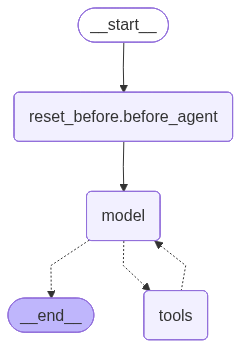

In [ ]:
from IPython.display import Image, Markdown, display

import importlib
import fyp

# Reload to pick up the latest code changes from fyp.py
fyp = importlib.reload(fyp)

# Prefer a true rendered image when available, otherwise fall back to Mermaid markup.
_graph = fyp.context_engineering_agent.get_graph()

try:
    if hasattr(_graph, "draw_mermaid_png"):
        png_bytes = _graph.draw_mermaid_png()
        display(Image(png_bytes))
    else:
        raise AttributeError("draw_mermaid_png not available")
except Exception:
    mermaid = _graph.draw_mermaid()
    display(Markdown(f"```mermaid\n{mermaid}\n```"))


In [ ]:
import importlib
import json
import fyp

# Ensure the notebook picks up the latest fyp.py changes
importlib.reload(fyp)

from langchain_core.messages import HumanMessage

demo_query = "Build a modern dark-mode product listing page with filters and sorting."

result = fyp.context_engineering_agent.invoke(
    {"messages": [HumanMessage(content=demo_query)]},
    config={"configurable": {"thread_id": "ce-demo"}},
)

print("type(result):", type(result))
print("result keys:", list(result.keys()))

print("\ninput_query:", result.get("input_query"))

print("\ndesign_schema (pretty):")
print(json.dumps(result.get("design_schema"), ensure_ascii=False, indent=2))

tav = result.get("tavily_search_result", "") or ""
print("\ntavily_search_result (first 300 chars):")
print(str(tav)[:300])

msgs = result.get("messages", []) or []
tail = msgs[-8:] if len(msgs) > 8 else msgs
print("\nlast message types:", [getattr(m, "type", type(m).__name__) for m in tail])

type(result): <class 'dict'>
result keys: ['messages', 'input_query', 'system_schema', 'tavily_search_result']

input_query: Build a modern dark-mode product listing page with filters and sorting.

system_schema (pretty):
{
  "ui": {
    "type": "product_listing",
    "variant": null,
    "style": "modern",
    "density": null,
    "navigation": null,
    "feedback_components": []
  },
  "theme": {
    "primary_color": null,
    "secondary_color": null,
    "mode": "dark"
  },
  "features": {
    "search": null,
    "filter": true,
    "sorting": true,
    "cart": null,
    "wishlist": null,
    "reviews": null
  },
  "constraints": {
    "tech_stack": [
      "html",
      "css",
      "javascript"
    ]
  },
  "extra_requirements": []
}

tavily_search_result (first 300 chars):


last message types: ['human', 'ai', 'tool', 'ai']


## System planning & design agent

### Memory & State

In [ ]:
# Notebook sync: load the finalized planning-state model from fyp.py
import importlib
import fyp

fyp = importlib.reload(fyp)
state = fyp.state

### Tools

#### Pydantic models of 4 specifications

In [ ]:
# Notebook sync: use the finalized UI specification models from fyp.py
import importlib
import fyp

fyp = importlib.reload(fyp)

AgentType = fyp.AgentType
PageType = fyp.PageType
LayoutType = fyp.LayoutType
ResponsiveBreakpoint = fyp.ResponsiveBreakpoint
HTMLTag = fyp.HTMLTag
ActionType = fyp.ActionType
ComponentCategory = fyp.ComponentCategory
RECOMMENDED_STATES = fyp.RECOMMENDED_STATES

Region = fyp.Region
Page = fyp.Page
LayoutSpecification = fyp.LayoutSpecification
ComponentState = fyp.ComponentState
ComponentEvent = fyp.ComponentEvent
DataBindingSpec = fyp.DataBindingSpec
ComponentNode = fyp.ComponentNode
PageComponentTree = fyp.PageComponentTree
ComponentSpecification = fyp.ComponentSpecification
PageComponentTreeDraft = fyp.PageComponentTreeDraft
ComponentSpecificationDraft = fyp.ComponentSpecificationDraft
InteractionEvent = fyp.InteractionEvent
ActionResultState = fyp.ActionResultState
InteractionAction = fyp.InteractionAction
InteractionStateTransition = fyp.InteractionStateTransition
InteractionFlow = fyp.InteractionFlow
PageInteraction = fyp.PageInteraction
InteractionSpecification = fyp.InteractionSpecification
DesignTokens = fyp.DesignTokens
TransitionSpec = fyp.TransitionSpec
StateVariant = fyp.StateVariant
ResponsiveVariant = fyp.ResponsiveVariant
ComponentDecoration = fyp.ComponentDecoration
PageDecoration = fyp.PageDecoration
DecorationSpecification = fyp.DecorationSpecification
UISpecificationBundle = fyp.UISpecificationBundle

#### UISpecificationBundle validation tool suite

In [ ]:
# Notebook sync: use the finalized specification helper functions from fyp.py
import importlib
import fyp

fyp = importlib.reload(fyp)

_coerce_layout_spec = fyp._coerce_layout_spec
_coerce_component_spec = fyp._coerce_component_spec
_coerce_interaction_spec = fyp._coerce_interaction_spec
_coerce_decoration_spec = fyp._coerce_decoration_spec
_walk_component_nodes = fyp._walk_component_nodes
_validate_component_contract_for_downstream = fyp._validate_component_contract_for_downstream
_build_component_scaffold_from_layout = fyp._build_component_scaffold_from_layout
_build_component_contract_from_layout = fyp._build_component_contract_from_layout
_guess_component_tag = fyp._guess_component_tag
_default_component_node_for_ref = fyp._default_component_node_for_ref
_repair_component_spec_from_layout = fyp._repair_component_spec_from_layout
_bundle_validate_or_warn = fyp._bundle_validate_or_warn
_invoke_structured_with_retries = fyp._invoke_structured_with_retries

#### layout_specification_generator

In [ ]:
# Notebook sync: use the finalized layout generator from fyp.py
import importlib
import fyp

fyp = importlib.reload(fyp)

layout_prompt = fyp.layout_prompt
layout_specification_generator_chain = fyp.layout_specification_generator_chain
layout_specification_generator_tool = fyp.layout_specification_generator_tool
layout_specification_generator = fyp.layout_specification_generator

##### Unit Test 

In [6]:
from __future__ import annotations

from types import SimpleNamespace
from typing import Any, Callable, Dict, List, Optional, Union
import json

ToolLike = Union[str, Any]  # name in globals() OR the tool object itself

def _pretty(title: str, obj: Any) -> None:
    print(f"\n--- {title} ---")
    try:
        print(json.dumps(obj, indent=2, ensure_ascii=False, sort_keys=True))
    except TypeError:
        # Fallback for non-JSON-serializable objects
        print(repr(obj))


def run_tool_unit_test_state_snapshots(
    *,
    tool_name: ToolLike,
    input_query: str,
    # Which keys to show in BEFORE/AFTER snapshots (defaults to a focused set)
    fields_to_show: Optional[List[str]] = None,
    # Which keys MUST be present in Command.update (e.g., ["layout_specification"])
    expected_update_fields: Optional[List[str]] = None,
    initial_state: Optional[Dict[str, Any]] = None,
    tool_call_id: str = "unit-test",
    verbose: bool = True,
    assert_after: Optional[Callable[[Dict[str, Any], Dict[str, Any]], None]] = None,
    forbidden_update_fields: Optional[List[str]] = None,
 ) -> Dict[str, Any]:
    """
    General unit-test harness for LangGraph @tool wrappers.

    - Builds a dummy runtime with `.state` and `.tool_call_id`
    - Calls the tool function (StructuredTool.func)
    - Captures BEFORE/AFTER snapshots for selected state fields
    - Validates expected/forbidden keys in Command.update
    """
    if fields_to_show is None:
        fields_to_show = ["input_query", "design_schema", "tavily_search_result", "extra_requirements", "layout_specification"]

    # Resolve tool object
    if isinstance(tool_name, str):
        if tool_name not in globals():
            raise KeyError(f"Tool '{tool_name}' not found in globals().")
        tool_obj = globals()[tool_name]
    else:
        tool_obj = tool_name

    dummy_state: Dict[str, Any] = dict(initial_state or {})
    dummy_state.setdefault("input_query", input_query)
    dummy_runtime = SimpleNamespace(state=dummy_state, tool_call_id=tool_call_id)

    before_state = dict(dummy_state)
    before_snapshot = {k: before_state.get(k) for k in fields_to_show}
    if verbose:
        _pretty("BEFORE (selected state fields)", before_snapshot)

    tool_fn = getattr(tool_obj, "func", None)
    if tool_fn is None:
        if not callable(tool_obj):
            raise TypeError("Provided tool is neither a StructuredTool with .func nor a callable")
        tool_fn = tool_obj

    cmd = tool_fn(dummy_runtime)
    update = getattr(cmd, "update", None)
    if not isinstance(update, dict):
        raise AssertionError("Expected Command.update to be a dict")

    if expected_update_fields:
        missing = [k for k in expected_update_fields if k not in update]
        if missing:
            raise AssertionError(f"Expected {missing} in Command.update, got keys: {sorted(update.keys())}")

    if forbidden_update_fields:
        for k in forbidden_update_fields:
            if k in update:
                raise AssertionError(f"Did not expect '{k}' to be updated by this tool")

    after_state = dict(before_state)
    after_state.update(update)
    after_snapshot = {k: after_state.get(k) for k in fields_to_show}
    if verbose:
        _pretty("AFTER (selected state fields)", after_snapshot)
        _pretty("Command.update keys", sorted(update.keys()))

    if assert_after is not None:
        assert_after(before_state, after_state)

    return {
        "before_state": before_state,
        "after_state": after_state,
        "before_snapshot": before_snapshot,
        "after_snapshot": after_snapshot,
        "cmd": cmd,
        "update": update,
    }

In [13]:
# Test layout_specification_generator: show input_query, design_schema, layout_specification BEFORE/AFTER
test_query = (
    "Build multiple modern dark-mode product listing pages for a sneaker store. "
    "Use a top nav and a compact grid. Include search, filters, sorting, cart, and wishlist. "
    "Also add a sticky promo banner. Infer the remaining details based on best practices for e-commerce UI design."
 )

seed_schema = DesignSchema(
    ui=UI(
        type="product_listing",
        variant="grid",
        style="modern",
        density="compact",
        navigation="top_nav",
        feedback_components=[],
    ),
    theme=Theme(mode="dark", primary_color=None, secondary_color=None),
    features=Features(search=True, filter=True, sorting=True, cart=True, wishlist=True, reviews=None),
    extra_requirements=["Sticky promo banner on scroll"],
).model_dump()

result = run_tool_unit_test_state_snapshots(
    tool_name="layout_specification_generator",
    input_query=test_query,
    initial_state={
        "design_schema": seed_schema,
        "layout_specification": None,
    },
    fields_to_show=["input_query", "design_schema", "layout_specification"],
    expected_update_fields=["layout_specification"],
    forbidden_update_fields=["design_schema"],
    verbose=True,
 )

print("\nPASS: layout_specification_generator produced layout_specification")
print("Number of pages:", len((result["after_state"].get("layout_specification") or {}).get("pages") or []))

# Print layout_specification as a clear parent → child architecture tree
layout_spec = (result.get("after_state") or {}).get("layout_specification") or {}

def _print_layout_architecture(layout: dict) -> None:
    def _safe_dict(x):
        return x if isinstance(x, dict) else {}
    def _safe_list(x):
        return x if isinstance(x, list) else []

    pages = _safe_list(layout.get("pages"))
    print("\n=== Layout Specification Architecture (parent → child) ===")
    if not pages:
        print("(no pages)")
        return

    for page in pages:
        page = _safe_dict(page)
        page_name = page.get("pageName") or page.get("name") or "<unnamed page>"
        page_layout_type = (
            page.get("pageLayoutType")
            or _safe_dict(page.get("layout")).get("type")
            or "<missing pageLayoutType>"
        )
        responsive = page.get("responsive")
        if responsive is None:
            responsive = _safe_dict(page.get("layout")).get("responsive")

        print(f"\nPage")
        print(f"  pageName: {page_name}")
        print(f"  pageLayoutType: {page_layout_type}")
        if responsive is not None:
            print(f"  responsive: {responsive}")

        regions = _safe_list(page.get("regions"))
        if not regions:
            print("  regions: []")
            continue

        print("  regions:")
        for region in regions:
            region = _safe_dict(region)
            region_name = region.get("name") or "<unnamed region>"
            owned_by = region.get("ownedBy")
            layout_type = region.get("layoutType") or _safe_dict(region.get("layout")).get("type")

            print("    - Region")
            print(f"      name: {region_name}")
            if owned_by is not None:
                print(f"      ownedBy: {owned_by}")
            if layout_type is not None:
                print(f"      layoutType: {layout_type}")

            # Support both schema shapes: v2 uses componentRefs; legacy uses components
            refs = _safe_list(region.get("componentRefs"))
            comps = _safe_list(region.get("components"))
            if refs:
                print("      componentRefs:")
                for ref in refs:
                    ref = _safe_dict(ref)
                    ref_id = ref.get("id") or "<missing id>"
                    pos = ref.get("position")
                    print(f"        - id: {ref_id}")
                    if pos is not None:
                        print(f"          position: {pos}")
            elif comps:
                print("      components:")
                for comp in comps:
                    comp = _safe_dict(comp)
                    comp_id = comp.get("id") or comp.get("name") or "<component>"
                    print(f"        - id: {comp_id}")
            else:
                print("      components: []")

_print_layout_architecture(layout_spec)


--- BEFORE (selected state fields) ---
{
  "design_schema": {
    "constraints": {
      "tech_stack": [
        "html",
        "css",
        "javascript"
      ]
    },
    "extra_requirements": [
      "Sticky promo banner on scroll"
    ],
    "features": {
      "cart": true,
      "filter": true,
      "reviews": null,
      "search": true,
      "sorting": true,
      "wishlist": true
    },
    "theme": {
      "mode": "dark",
      "primary_color": null,
      "secondary_color": null
    },
    "ui": {
      "density": "compact",
      "feedback_components": [],
      "navigation": "top_nav",
      "style": "modern",
      "type": "product_listing",
      "variant": "grid"
    }
  },
  "input_query": "Build multiple modern dark-mode product listing pages for a sneaker store. Use a top nav and a compact grid. Include search, filters, sorting, cart, and wishlist. Also add a sticky promo banner. Infer the remaining details based on best practices for e-commerce UI design.",
  "

#### components_specification_generator

In [ ]:
# Notebook sync: use the finalized components generator from fyp.py
import importlib
import fyp

fyp = importlib.reload(fyp)

components_prompt = fyp.components_prompt
components_specification_generator_chain = fyp.components_specification_generator_chain
components_specification_generator_tool = fyp.components_specification_generator_tool
components_specification_generator = fyp.components_specification_generator

##### Unit Test

In [202]:
# Unit test: components_specification_generator (reuses run_tool_unit_test_state_snapshots from Cell 65)
comp_test_query = (
    "Build a modern dark-mode product listing experience for a sneaker store. "
    "Include search, filters, sorting, wishlist, and cart. "
    "Have a clear header/nav, product grid, and a product detail page."
 )

# Reuse an existing layout_specification if present; otherwise generate one first
layout_spec_for_components = None
if isinstance(globals().get("result"), dict):
    layout_spec_for_components = (
        (globals().get("result") or {}).get("after_state", {}).get("layout_specification")
        if isinstance((globals().get("result") or {}).get("after_state"), dict)
        else None
    )
if not isinstance(layout_spec_for_components, dict) or not layout_spec_for_components.get("pages"):
    seed_schema_for_components = DesignSchema(
        ui=UI(
            type="product_listing",
            variant="grid",
            style="modern",
            density="compact",
            navigation="top_nav",
            feedback_components=[],
        ),
        theme=Theme(mode="dark", primary_color=None, secondary_color=None),
        features=Features(search=True, filter=True, sorting=True, cart=True, wishlist=True, reviews=None),
        extra_requirements=["Consistency between listing and PDP"],
    ).model_dump()

    layout_res = run_tool_unit_test_state_snapshots(
        tool_name="layout_specification_generator",
        input_query=comp_test_query,
        initial_state={"design_schema": seed_schema_for_components, "layout_specification": None},
        fields_to_show=["input_query", "design_schema", "layout_specification"],
        expected_update_fields=["layout_specification"],
        forbidden_update_fields=["design_schema"],
        verbose=False,
    )
    layout_spec_for_components = (layout_res.get("after_state") or {}).get("layout_specification") or {}

if not isinstance(layout_spec_for_components, dict) or not layout_spec_for_components.get("pages"):
    raise AssertionError("Could not obtain a valid layout_specification for components unit test")

# Now unit test the components_specification_generator using the layout_specification above
components_res = run_tool_unit_test_state_snapshots(
    tool_name="components_specification_generator",
    input_query=comp_test_query,
    initial_state={
        "layout_specification": layout_spec_for_components,
        "components_specification": None,
    },
    fields_to_show=["input_query", "layout_specification", "components_specification"],
    expected_update_fields=["components_specification"],
    forbidden_update_fields=["layout_specification"],
    verbose=False,
 )

# Explicitly print BEFORE/AFTER snapshots for the component-spec tool invocation
_pretty("BEFORE components_specification_generator (selected fields)", components_res.get("before_snapshot"))
_pretty("AFTER components_specification_generator (selected fields)", components_res.get("after_snapshot"))
_pretty("components_specification_generator update keys", sorted((components_res.get("update") or {}).keys()))

after_components_spec = (components_res.get("after_state") or {}).get("components_specification") or {}
print("PASS: components_specification_generator produced components_specification")
print("Layout pages:", len((layout_spec_for_components.get("pages") or [])))
if isinstance(after_components_spec, dict):
    # Try a couple of common shapes without assuming schema details too hard
    if "pages" in after_components_spec and isinstance(after_components_spec.get("pages"), list):
        print("Component-spec pages:", len(after_components_spec.get("pages") or []))
    elif "components" in after_components_spec and isinstance(after_components_spec.get("components"), list):
        print("Top-level components:", len(after_components_spec.get("components") or []))

# Display components_specification hierarchy (pages -> rootComponents -> children)
def _format_comp_node(node: dict) -> str:
    node_id = node.get("id", "<missing-id>")
    tag = node.get("tag", "<missing-tag>")
    owned_by = node.get("ownedBy", "<missing-ownedBy>")
    position = node.get("position")
    roles = node.get("role") or []
    events = node.get("events") or []
    handler_count = 0
    for ev in events:
        if isinstance(ev, dict) and ev.get("handler"):
            handler_count += 1
    pos_str = f" position={position}" if position else ""
    return (
        f"{node_id} <{tag}>"
        f" ownedBy={owned_by}"
        f"{pos_str}"
        f" roles={roles}"
        f" events={len(events)}"
        f" handlers={handler_count}"
    )


def _print_comp_tree(node: dict, indent: int = 0, max_depth: int = 20) -> None:
    if indent // 2 >= max_depth:
        print(" " * indent + "...")
        return
    print(" " * indent + "- " + _format_comp_node(node))
    children = node.get("children") or []
    if isinstance(children, list):
        for child in children:
            if isinstance(child, dict):
                _print_comp_tree(child, indent=indent + 2, max_depth=max_depth)


def _print_component_spec_hierarchy(components_spec: Any) -> None:
    if not isinstance(components_spec, dict):
        print("No components_specification (unexpected type)")
        return
    pages = components_spec.get("pages") or []
    if not isinstance(pages, list) or not pages:
        print("No pages found in components_specification")
        return
    print("\n=== Component Specification Hierarchy ===")
    for page in pages:
        if not isinstance(page, dict):
            continue
        page_name = page.get("pageName", "<missing-pageName>")
        print(f"\nPage: {page_name}")
        roots = page.get("rootComponents") or []
        if not isinstance(roots, list) or not roots:
            print("  (no rootComponents)")
            continue
        for root in roots:
            if isinstance(root, dict):
                _print_comp_tree(root, indent=2)


_print_component_spec_hierarchy(after_components_spec)


--- BEFORE components_specification_generator (selected fields) ---
{
  "components_specification": null,
  "input_query": "Build a modern dark-mode product listing experience for a sneaker store. Include search, filters, sorting, wishlist, and cart. Have a clear header/nav, product grid, and a product detail page.",
  "layout_specification": {
    "pages": [
      {
        "pageLayoutType": "stack",
        "pageName": "productListing",
        "regions": [
          {
            "componentRefs": [
              {
                "id": "siteHeader",
                "position": "top"
              }
            ],
            "layoutType": "flex-row",
            "name": "header",
            "ownedBy": "HTML"
          },
          {
            "componentRefs": [
              {
                "id": "searchBar",
                "position": "left"
              },
              {
                "id": "sortControl",
                "position": "right"
              }
            ]

#### interactions_specification_Generator

In [ ]:
# Notebook sync: use the finalized interactions generator from fyp.py
import importlib
import fyp

fyp = importlib.reload(fyp)

interactions_prompt = fyp.interactions_prompt
interactions_specification_generator_chain = fyp.interactions_specification_generator_chain
interactions_specification_generator_tool = fyp.interactions_specification_generator_tool
interactions_specification_generator = fyp.interactions_specification_generator

##### Unit Test

In [196]:
# Unit test: interactions_specification_generator (reuses run_tool_unit_test_state_snapshots from Cell 65)
interaction_test_query = (
    "Ecommerce UI: clicking a product card or View Details navigates to the product details page; "
    "clicking Quick View opens a popup/modal with product details."
 )

# Dummy layout_specification (small + consistent IDs/pages)
dummy_layout_specification = {
    "pages": [
        {
            "pageName": "ProductListingPage",
            "regions": [
                {
                    "name": "header",
                    "ownedBy": "HTML",
                    "components": [
                        {"id": "header", "type": "header"},
                        {"id": "header_search_bar", "type": "search"},
                    ],
                },
                {
                    "name": "mainContent",
                    "ownedBy": "HTML",
                    "components": [
                        {"id": "product_grid", "type": "grid"},
                        {"id": "product_card", "type": "card"},
                        {"id": "view_details_button", "type": "button"},
                        {"id": "quick_view_button", "type": "button"},
                        {"id": "product_details_modal", "type": "modal"},
                        {"id": "modal_close_button", "type": "button"},
                    ],
                },
            ],
        },
        {
            "pageName": "ProductDetailPage",
            "regions": [
                {
                    "name": "mainContent",
                    "ownedBy": "HTML",
                    "components": [
                        {"id": "pdp_root", "type": "section"},
                        {"id": "add_to_cart_button", "type": "button"},
                    ],
                }
            ],
        },
    ]
}

# Dummy components_specification (minimal ComponentSpecification-like shape)
dummy_components_specification = {
    "pages": [
        {
            "pageName": "ProductListingPage",
            "rootComponents": [
                {
                    "id": "header",
                    "tag": "header",
                    "ownedBy": "HTML",
                    "role": ["structure"],
                    "props": {},
                    "states": [],
                    "events": [],
                    "children": [
                        {
                            "id": "header_search_bar",
                            "tag": "input",
                            "ownedBy": "HTML",
                            "role": ["behavior", "structure"],
                            "props": {"type": "search"},
                            "states": [],
                            "events": [],
                            "children": [],
                        }
                    ],
                },
                {
                    "id": "product_grid",
                    "tag": "section",
                    "ownedBy": "HTML",
                    "role": ["structure"],
                    "props": {},
                    "states": [],
                    "events": [],
                    "children": [
                        {
                            "id": "product_card",
                            "tag": "article",
                            "ownedBy": "HTML",
                            "role": ["behavior", "structure"],
                            "props": {},
                            "states": [],
                            "events": [],
                            "children": [
                                {
                                    "id": "view_details_button",
                                    "tag": "button",
                                    "ownedBy": "HTML",
                                    "role": ["behavior", "structure"],
                                    "props": {"type": "button"},
                                    "states": [],
                                    "events": [],
                                    "children": [],
                                },
                                {
                                    "id": "quick_view_button",
                                    "tag": "button",
                                    "ownedBy": "HTML",
                                    "role": ["behavior", "structure"],
                                    "props": {"type": "button"},
                                    "states": [],
                                    "events": [],
                                    "children": [],
                                },
                            ],
                        },
                        {
                            "id": "product_details_modal",
                            "tag": "section",
                            "ownedBy": "HTML",
                            "role": ["structure"],
                            "props": {"aria-modal": "true"},
                            "states": [],
                            "events": [],
                            "children": [
                                {
                                    "id": "modal_close_button",
                                    "tag": "button",
                                    "ownedBy": "HTML",
                                    "role": ["behavior", "structure"],
                                    "props": {"type": "button"},
                                    "states": [],
                                    "events": [],
                                    "children": [],
                                }
                            ],
                        },
                    ],
                },
            ],
        },
        {
            "pageName": "ProductDetailPage",
            "rootComponents": [
                {
                    "id": "pdp_root",
                    "tag": "main",
                    "ownedBy": "HTML",
                    "role": ["structure"],
                    "props": {},
                    "states": [],
                    "events": [],
                    "children": [
                        {
                            "id": "add_to_cart_button",
                            "tag": "button",
                            "ownedBy": "HTML",
                            "role": ["behavior", "structure"],
                            "props": {"type": "button"},
                            "states": [],
                            "events": [],
                            "children": [],
                        }
                    ],
                }
            ],
        },
    ]
}

# Run tool under unit test harness
interaction_res = run_tool_unit_test_state_snapshots(
    tool_name="interactions_specification_generator",
    input_query=interaction_test_query,
    initial_state={
        "layout_specification": dummy_layout_specification,
        "components_specification": dummy_components_specification,
        "interactions_specification": None,
    },
    fields_to_show=[
        "input_query",
        "layout_specification",
        "components_specification",
        "interactions_specification",
    ],
    expected_update_fields=["interactions_specification"],
    forbidden_update_fields=["layout_specification", "components_specification"],
    verbose=False,
 )

after_interactions_spec = (interaction_res.get("after_state") or {}).get("interactions_specification") or {}
print("PASS: interactions_specification_generator produced interactions_specification")

# Small summary to confirm key flows exist (navigate vs modal)
if isinstance(after_interactions_spec, dict):
    pages = after_interactions_spec.get("pages") or []
    print("Pages in interactions_specification:", len(pages) if isinstance(pages, list) else "<unexpected>")
    if isinstance(pages, list):
        for p in pages:
            if not isinstance(p, dict):
                continue
            flows = p.get("flows") or []
            print("-", p.get("pageName"), "flows:", len(flows) if isinstance(flows, list) else "<unexpected>")

AssertionError: Expected ['interactions_specification'] in Command.update, got keys: ['messages']

#### decoration_specification_Generator

In [ ]:
# Notebook sync: use the finalized decoration generator from fyp.py
import importlib
import fyp

fyp = importlib.reload(fyp)

decoration_prompt = fyp.decoration_prompt
decoration_specification_generator_chain = fyp.decoration_specification_generator_chain
decoration_specification_generator_tool = fyp.decoration_specification_generator_tool
decoration_specification_generator = fyp.decoration_specification_generator

### Middlewares

#### Reset state values

In [ ]:
# Notebook sync note: the finalized planning reset middleware is defined in fyp.py
# and is already bound to system_design_planning_agent below.

#### Streaming Progress Middleware

In [ ]:
# Notebook sync: use the finalized planning middleware hooks from fyp.py
import importlib
import fyp

fyp = importlib.reload(fyp)

design_agent_progress = fyp.design_agent_progress
design_tool_progress = fyp.design_tool_progress

### Create agent

In [3]:
# Notebook sync: use the finalized planning agent from fyp.py
import importlib
import fyp

fyp = importlib.reload(fyp)

_design_system_prompt = fyp._design_system_prompt
reset_before_system_design_planning = fyp.reset_before_system_design_planning
system_design_planning_agent = fyp.system_design_planning_agent

### Component Testing

#### Normal Cases

In [395]:
from uuid import uuid4

test_query = (
    "Generate a product listing page for a sneaker store with a modern style, dark mode, "
    "top nav, compact grid, and features like search, filters, sorting, cart, and wishlist. "
    "Also add a sticky promo banner."
)

thread_id = f"t-{uuid4().hex[:8]}"
result = stream_agent_run(
    system_design_planning_agent,
    query=test_query,
    payload={"messages": [{"role": "user", "content": test_query}]},
    config={"configurable": {"thread_id": thread_id}},
    header="[Orchestrator] Invoking system_design_planning_agent...",
    print_stream=True,
    stream_mode=["updates", "messages", "custom"],
    version="v2",
)

# For tests/assertions (optional):
print("\n---\nCaptured tool feedback:", result["tool_feedback"])
print("Captured final length:", len(result["final"]))
print("Captured state keys:", sorted(list((result.get("state") or {}).keys()))[:30])

[Orchestrator] Invoking system_design_planning_agent...
	[Design Agent] Processing request...


	[Design Agent] Generating layout specification...
	[Design Agent] Generating component specifications...
	[Design Agent] Generating interaction specifications...
	[Design Agent] Generating decoration specifications...
Done. The complete UI specification bundle has been generated for the sneaker store product listing page, including:

- Layout specification
- Components specification
- Interactions specification
- Decoration specification

The request was applied with:
- Modern style
- Dark mode
- Top navigation
- Compact product grid
- Search
- Filters
- Sorting
- Cart
- Wishlist
- Sticky promo banner

---
Captured tool feedback: ['Stored layout_specification.', 'Stored components_specification.', 'Stored interactions_specification.', 'Stored decoration_specification.']
Captured final length: 390
Captured state keys: ['components_specification', 'decoration_specification', 'design_schema', 'interactions_specification', 'layout_specification']


In [396]:
import json

result_payload = globals().get("result") or {}
state_payload = result_payload.get("state") or {}


def _payload_to_dict(value):
    if value is None:
        return {}
    if hasattr(value, "model_dump"):
        return value.model_dump()
    if isinstance(value, str):
        text = value.strip()
        return json.loads(text) if text else {}
    if isinstance(value, dict):
        return value
    return {"raw": str(value)}


fields_to_print = [
    "layout_specification",
    "components_specification",
    "interactions_specification",
    "decoration_specification"
]

for field_name in fields_to_print:
    payload = _payload_to_dict(state_payload.get(field_name))
    print(f"\n=== {field_name} ===")
    if payload:
        print(json.dumps(payload, indent=2, ensure_ascii=False))
    else:
        print("<missing or empty>")


=== layout_specification ===
{
  "pages": [
    {
      "pageName": "productListingPage",
      "pageLayoutType": "flex-column",
      "responsive": true,
      "regions": [
        {
          "name": "topNav",
          "ownedBy": "HTML",
          "layoutType": "flex-row",
          "componentRefs": [
            {
              "id": "siteLogo",
              "position": "left"
            },
            {
              "id": "searchBar",
              "position": "center-left"
            },
            {
              "id": "sortControl",
              "position": "center"
            },
            {
              "id": "wishlistButton",
              "position": "center-right"
            },
            {
              "id": "cartButton",
              "position": "right"
            }
          ]
        },
        {
          "name": "filtersBar",
          "ownedBy": "HTML",
          "layoutType": "flex-row",
          "componentRefs": [
            {
              "id": "

In [397]:
state_payload = (globals().get("result") or {}).get("state") or {}
feedback = list(state_payload.get("tool_feedback") or [])
layout_payload = state_payload.get("layout_specification") or {}
components_payload = state_payload.get("components_specification") or {}
interactions_payload = state_payload.get("interactions_specification") or {}

print("TOOL FEEDBACK:", feedback)
print("INTERACTIONS PAGES:", [page.get("pageName") for page in (interactions_payload.get("pages") or [])])

for page in layout_payload.get("pages") or []:
    page_name = page.get("pageName")
    component_page = next((candidate for candidate in (components_payload.get("pages") or []) if candidate.get("pageName") == page_name), {})
    print("PAGE:", page_name)
    for region in page.get("regions") or []:
        layout_ids = [ref.get("id") for ref in (region.get("componentRefs") or [])]
        component_ids = [node.get("id") for node in ((component_page.get("regionComponents") or {}).get(region.get("name"), []) or [])]
        print(" ", region.get("name"), "layout refs:", layout_ids, "component top-level ids:", component_ids)

TOOL FEEDBACK: []
INTERACTIONS PAGES: ['productListingPage']
PAGE: productListingPage
  topNav layout refs: ['siteLogo', 'searchBar', 'sortControl', 'wishlistButton', 'cartButton'] component top-level ids: ['siteLogo', 'searchBar', 'sortControl', 'wishlistButton', 'cartButton']
  filtersBar layout refs: ['filterPanelToggle', 'activeFilters'] component top-level ids: ['filterPanelToggle', 'activeFilters']
  mainContent layout refs: ['productGrid'] component top-level ids: ['productGrid']


#### Edge Cases

Gibberish

In [398]:
from uuid import uuid4

test_query = (
    "hjwbfuewfheqif"
)

thread_id = f"t-{uuid4().hex[:8]}"
result = stream_agent_run(
    system_design_planning_agent,
    query=test_query,
    payload={"messages": [{"role": "user", "content": test_query}]},
    config={"configurable": {"thread_id": thread_id}},
    header="[Orchestrator] Invoking system_design_planning_agent...",
    print_stream=True,
    stream_mode=["updates", "messages", "custom"],
    version="v2",
)

# For tests/assertions (optional):
print("\n---\nCaptured tool feedback:", result["tool_feedback"])
print("Captured final length:", len(result["final"]))
print("Captured state keys:", sorted(list((result.get("state") or {}).keys()))[:30])

[Orchestrator] Invoking system_design_planning_agent...
	[Design Agent] Processing request...


I can’t proceed with that request because it doesn’t describe an e-commerce UI/software design task.

Please send a concrete e-commerce UI request, for example:
- “Design a mobile storefront for a fashion shop”
- “Create an admin dashboard for managing products, orders, and customers”
- “Generate a checkout flow for an online grocery app”

Include, if possible:
- store type
- target users
- key pages
- platform: web, mobile, or both
- any style or branding constraints

---
Captured tool feedback: []
Captured final length: 472
Captured state keys: ['design_schema']


Unrelated prompt

In [399]:
from uuid import uuid4

test_query = (
    "what is malaysia?"
)

thread_id = f"t-{uuid4().hex[:8]}"
result = stream_agent_run(
    system_design_planning_agent,
    query=test_query,
    payload={"messages": [{"role": "user", "content": test_query}]},
    config={"configurable": {"thread_id": thread_id}},
    header="[Orchestrator] Invoking system_design_planning_agent...",
    print_stream=True,
    stream_mode=["updates", "messages", "custom"],
    version="v2",
)

# For tests/assertions (optional):
print("\n---\nCaptured tool feedback:", result["tool_feedback"])
print("Captured final length:", len(result["final"]))
print("Captured state keys:", sorted(list((result.get("state") or {}).keys()))[:30])

[Orchestrator] Invoking system_design_planning_agent...
	[Design Agent] Processing request...


I can only help with e-commerce UI/software specification requests in this workflow.

Your question, “what is malaysia?”, is unrelated to e-commerce software generation, so I can’t process it here.

If you want, you can instead ask for something like:
- “Design an e-commerce app for Malaysian groceries”
- “Create a storefront UI spec for a Malaysia-based fashion marketplace”
- “Generate checkout flow specs for an online electronics store”

---
Captured tool feedback: []
Captured final length: 442
Captured state keys: ['design_schema']


Empty prompt?

In [400]:
from uuid import uuid4

test_query = (
    ""
)

thread_id = f"t-{uuid4().hex[:8]}"
result = stream_agent_run(
    system_design_planning_agent,
    query=test_query,
    payload={"messages": [{"role": "user", "content": test_query}]},
    config={"configurable": {"thread_id": thread_id}},
    header="[Orchestrator] Invoking system_design_planning_agent...",
    print_stream=True,
    stream_mode=["updates", "messages", "custom"],
    version="v2",
)

# For tests/assertions (optional):
print("\n---\nCaptured tool feedback:", result["tool_feedback"])
print("Captured final length:", len(result["final"]))
print("Captured state keys:", sorted(list((result.get("state") or {}).keys()))[:30])

[Orchestrator] Invoking system_design_planning_agent...
	[Design Agent] Processing request...


Please provide a concrete e-commerce UI request.

Example:
- “Design a mobile-first online fashion store with home, category, product detail, cart, checkout, and account pages.”

I can only proceed once you give a non-empty e-commerce software generation request.

---
Captured tool feedback: []
Captured final length: 263
Captured state keys: ['design_schema']


## Developer agent

### Shared helper function

In [5]:
import re

def _apply_patch(original: str, diff_text: str) -> str:
    """
    Pure-Python unified diff applicator.
    No subprocess or external patch command needed — works on Windows.
    """
    original_lines = original.splitlines(keepends=True)
    result_lines   = list(original_lines)

    hunk_re    = re.compile(r'^@@ -(\d+)(?:,(\d+))? \+\d+(?:,\d+)? @@')
    diff_lines = diff_text.splitlines()

    hunks = []
    i = 0
    while i < len(diff_lines):
        m = hunk_re.match(diff_lines[i])
        if m:
            orig_start = int(m.group(1)) - 1
            orig_count = int(m.group(2)) if m.group(2) else 1
            i += 1
            hunk_body = []
            while i < len(diff_lines) and not hunk_re.match(diff_lines[i]):
                hunk_body.append(diff_lines[i])
                i += 1
            hunks.append((orig_start, orig_count, hunk_body))
        else:
            i += 1

    for orig_start, orig_count, hunk_body in reversed(hunks):

        # ── NEW: verify context and removed lines match current content ──
        src_i = orig_start
        for line in hunk_body:
            if line.startswith(" ") or line.startswith("-"):
                expected = line[1:]
                expected = expected if expected.endswith("\n") else expected + "\n"
                # Compare ignoring the trailing newline: the last line of a
                # block carries no "\n" after splitlines(keepends=True), which
                # would otherwise make every diff touching a block's last line
                # fail with a spurious mismatch.
                if (src_i >= len(result_lines)
                        or result_lines[src_i].rstrip("\n") != expected.rstrip("\n")):
                    raise ValueError(
                        f"Hunk at original line {orig_start + 1} does not match "
                        f"current content at line {src_i + 1}.\n"
                        f"  Expected : {repr(expected)}\n"
                        f"  Got      : {repr(result_lines[src_i]) if src_i < len(result_lines) else '<EOF>'}\n"
                        "Re-extract the component and regenerate the diff against "
                        "the current version."
                    )
                src_i += 1
            # "+" lines don't consume original lines — skip
        # ── END NEW ──

        replacement = []
        for line in hunk_body:
            if line.startswith("+"):
                text = line[1:]
                replacement.append(text if text.endswith("\n") else text + "\n")
            elif line.startswith(" "):
                text = line[1:]
                replacement.append(text if text.endswith("\n") else text + "\n")
        result_lines[orig_start : orig_start + orig_count] = replacement

    return "".join(result_lines)

In [ ]:
import re

# ── Multi-block diff support (shared by the CSS and JS agents) ────────────────
# A component's code is rarely one block: a CSS rule usually has :hover and
# media-query variants, and a JS component can own several listeners. Only the
# first block used to be editable, so a "make the button darker" request left
# the hover state on the old colour.
#
# These helpers let every matching block be extracted, diffed and spliced back
# as one unit. The blocks are shown to the model as a single document joined by
# marker comment lines, which keeps unified-diff line numbers unambiguous across
# block boundaries. The markers are stripped on the way back and never reach the
# generated artifact.

_WF_BLOCK_MARK_RE = re.compile(
    r'^[ \t]*/\* @@ WebForge block \d+ of \d+ @@ \*/[ \t]*$', re.M)


def _join_blocks(blocks: list) -> str:
    """Join extracted blocks into one diffable document.

    A single block is returned untouched, so the common one-block case behaves
    exactly as it did before markers existed.
    """
    if len(blocks) <= 1:
        return blocks[0] if blocks else ""
    total = len(blocks)
    return "\n".join(f"/* @@ WebForge block {n} of {total} @@ */\n{b}"
                     for n, b in enumerate(blocks, 1))


def _split_blocks(joined: str, expected: int) -> list:
    """Inverse of _join_blocks.

    Raises if the marker lines were not preserved, rather than guessing at the
    boundaries — the same fail-loud rule _apply_patch applies to diff context.
    """
    # Trailing newlines are trimmed on every path. _apply_patch terminates each
    # added line with "\n", so patching a block's LAST line used to leave a
    # stray blank line behind once the block was spliced back. Extracted spans
    # never include the newline that follows a block, so the replacement text
    # must not either.
    if expected <= 1:
        return [joined.strip("\r\n")]

    # Compare the surviving markers against the exact sequence that was handed
    # out. A plain count check is not enough: deleting the FIRST marker still
    # leaves `expected` sections, and the blocks would silently merge.
    want  = [f"/* @@ WebForge block {n} of {expected} @@ */" for n in range(1, expected + 1)]
    found = [m.strip() for m in _WF_BLOCK_MARK_RE.findall(joined)]
    if found != want:
        raise ValueError(
            f"Block separator lines were altered: expected {want}, found {found}. "
            "Every '/* @@ WebForge block N of M @@ */' line must be kept unchanged "
            "as diff context. Re-extract the component and regenerate the diff.")

    parts = _WF_BLOCK_MARK_RE.split(joined)
    if parts[0].strip() != "":
        raise ValueError(
            "Text appeared before the first block separator. The patched text must "
            "begin with the '/* @@ WebForge block 1 of "
            f"{expected} @@ */' line, kept unchanged. Re-extract and regenerate.")
    return [p.strip("\r\n") for p in parts[1:]]


def _splice_spans(code: str, spans: list, new_blocks: list) -> str:
    """Replace each (start, end) character span in `code` with its new block.

    Applied right-to-left so earlier spans keep their offsets. Character spans
    are used rather than str.replace so that two textually identical blocks can
    never be confused, and so non-contiguous blocks splice back into their own
    positions instead of silently failing to match.
    """
    if len(spans) != len(new_blocks):
        raise ValueError(
            f"span/block count mismatch: {len(spans)} spans, {len(new_blocks)} blocks")
    out = code
    for (start, end), new in sorted(zip(spans, new_blocks), key=lambda p: -p[0][0]):
        out = out[:start] + new + out[end:]
    return out


In [ ]:
# Unit tests: _join_blocks / _split_blocks / _splice_spans

# Case 1: single block round-trips with no markers added at all
_b1 = ["a {\n  color: red;\n}"]
_j1 = _join_blocks(_b1)
assert _j1 == _b1[0], "single block must be returned untouched"
assert "WebForge block" not in _j1
assert _split_blocks(_j1, 1) == _b1
print("[Case 1] PASS: single block unchanged (backwards compatible)\n")

# Case 2: multi-block join/split round-trip
_b2 = ["a { color: red; }", "a:hover { color: blue; }", "@media (max-width: 600px) {\n  a { color: green; }\n}"]
_j2 = _join_blocks(_b2)
assert _j2.count("WebForge block") == 3
assert "block 1 of 3" in _j2 and "block 3 of 3" in _j2
assert _split_blocks(_j2, 3) == _b2, f"round-trip failed:\n{_split_blocks(_j2, 3)}"
print("[Case 2] PASS: 3 blocks join and split back identically\n")

# Case 3: any tampering with the markers is rejected, not silently guessed.
#   The FIRST-marker case matters most: deleting it still leaves 3 sections, so
#   a plain count check would have waved it through and merged blocks 1 and 2.
for _label, _broken in [
    ("middle marker deleted", _j2.replace("/* @@ WebForge block 2 of 3 @@ */\n", "")),
    ("first marker deleted",  _j2.replace("/* @@ WebForge block 1 of 3 @@ */\n", "")),
    ("marker renumbered",     _j2.replace("block 2 of 3", "block 9 of 3")),
    ("extra marker added",    "/* @@ WebForge block 4 of 3 @@ */\n" + _j2),
]:
    try:
        _split_blocks(_broken, 3)
        raise AssertionError(f"Case 3 FAIL: {_label} was not detected")
    except ValueError as e:
        assert "Re-extract" in str(e), str(e)
    print(f"[Case 3] PASS: {_label} rejected")
print()

# Case 4: spans splice right-to-left; two IDENTICAL blocks stay distinct
#   str.replace(block, new, 1) would have rewritten the first block twice.
_code = "x { c: 1; }\nMID\nx { c: 1; }"
_spans = [(0, 11), (16, 27)]
assert _code[0:11] == "x { c: 1; }" and _code[16:27] == "x { c: 1; }"
_out = _splice_spans(_code, _spans, ["FIRST", "SECOND"])
assert _out == "FIRST\nMID\nSECOND", f"Case 4 FAIL: got {_out!r}"
print(f"[Case 4] PASS: identical blocks spliced independently -> {_out!r}\n")

# Case 5: non-contiguous blocks keep everything between them untouched
_code5 = "AAA\n\nKEEP-ME\n\nBBB"
_out5 = _splice_spans(_code5, [(0, 3), (14, 17)], ["aaa", "bbb"])
assert _out5 == "aaa\n\nKEEP-ME\n\nbbb", f"Case 5 FAIL: got {_out5!r}"
print(f"[Case 5] PASS: text between blocks preserved -> {_out5!r}\n")

# Case 6: count mismatch is a hard error, never a partial splice
try:
    _splice_spans("abc", [(0, 1)], ["x", "y"])
    raise AssertionError("Case 6 FAIL: mismatch not detected")
except ValueError as e:
    assert "mismatch" in str(e)
    print("[Case 6] PASS: span/block count mismatch rejected\n")

# Case 7: _apply_patch terminates added lines with "\n". Patching a block's LAST
#   line therefore returns trailing whitespace that must not survive the splice,
#   or every such edit would inject a blank line into the artifact.
_patched = _apply_patch(".a { c: red; }",
                        "--- original\n+++ revised\n@@ -1,1 +1,1 @@\n"
                        "-.a { c: red; }\n+.a { c: green; }")
assert _patched.endswith("\n"), "precondition: _apply_patch adds the newline"
assert _split_blocks(_patched, 1) == [".a { c: green; }"], _split_blocks(_patched, 1)
print("[Case 7] PASS: trailing newline trimmed on the single-block path too\n")

print("_join_blocks / _split_blocks / _splice_spans: all 7 cases passed.")


In [ ]:
# ── Lint fix-loop cap and graceful escalation (shared by all three agents) ────
# The generate -> lint -> fix loop had no bound in code. The prompts say to
# iterate until "No issues found.", so a defect the model cannot fix had no stop
# condition at all. The installed LangGraph (1.0.10) defaults recursion_limit to
# 10000 supersteps — roughly 5000 model calls — so the loop would burn real money
# for a long time before crashing with GraphRecursionError, producing no artifact
# and no report. (Older LangGraph 0.x defaulted to 25; do not assume that here.)
#
# This mirrors the correction loop in call_test_exec_agent: a hard cap enforced
# in Python, and a partial result instead of a failure. Two rules matter:
#
#   1. Only a REAL lint verdict consumes an attempt. Infrastructure problems
#      (npx missing, config error, unparseable output, empty code) must not burn
#      the budget — the same reasoning that makes the Playwright pipeline retry
#      transient page-load failures before entering the correction loop.
#   2. Past the cap the linter REFUSES to run at all. The escalation message
#      instructs the model to stop, but a reasoning lapse could re-invoke the
#      tool; refusing makes the cap non-negotiable and costs no subprocess.

_LINT_ATTEMPT_CAP = 3          # 1 initial lint run + 2 fix attempts

_LINT_CAP_MARKER = "[LINT CAP REACHED]"


def _lint_refused(runtime) -> Command:
    """Response to a linter call made after the cap was already reached."""
    return Command(update={
        "lint_passed": False,
        "messages": [ToolMessage(
            content=(f"{_LINT_CAP_MARKER} Linter call REFUSED — the "
                     f"{_LINT_ATTEMPT_CAP}-attempt cap was already reached.\n"
                     "Do not lint again. Save the current best-effort code with "
                     "write_file, then END your turn with a summary of the "
                     "unresolved problems."),
            tool_call_id=runtime.tool_call_id)]})


def _lint_failure(runtime, body: str) -> Command:
    """Build the Command for a lint run that found real problems.

    Counts the attempt, and escalates gracefully once the cap is reached rather
    than letting the fix loop spin. `body` is the formatted problem list and is
    always placed first, unchanged, so the model still sees the diagnostics.
    """
    attempts = runtime.state.get("lint_attempts", 0) + 1

    if attempts >= _LINT_ATTEMPT_CAP:
        return Command(update={
            "lint_passed":   False,
            "lint_attempts": attempts,
            "lint_escalated": True,
            "messages": [ToolMessage(
                content=(f"{body}\n\n"
                         f"{_LINT_CAP_MARKER} {attempts}/{_LINT_ATTEMPT_CAP} lint "
                         "attempts used and problems remain. STOP the fix loop — do "
                         "NOT call the linter again.\nSave the current best-effort "
                         "code with write_file, then END your turn with a short "
                         "summary of the unresolved problems listed above."),
                tool_call_id=runtime.tool_call_id)]})

    return Command(update={
        "lint_passed":   False,
        "lint_attempts": attempts,
        "messages": [ToolMessage(
            content=(f"{body}\n\n[Lint attempt {attempts}/{_LINT_ATTEMPT_CAP}] "
                     "Fix the reported lines and re-lint."),
            tool_call_id=runtime.tool_call_id)]})


In [ ]:
# Unit tests: _lint_failure / _lint_refused (lint fix-loop cap)
from types import SimpleNamespace as _NSL

_rt_lint = lambda **kw: _NSL(state=kw, tool_call_id="test-lintcap")

# Case 1: first failure — attempt counted, loop continues, diagnostics preserved
c1 = _lint_failure(_rt_lint(), "Found 1 problem(s):\n  Line 3 [block-no-empty]: Empty block")
assert c1.update["lint_attempts"] == 1
assert c1.update["lint_passed"] is False
assert "lint_escalated" not in c1.update, "must not escalate on the first failure"
assert c1.update["messages"][0].content.startswith("Found 1 problem(s):"), \
    "the problem list must come first and unchanged — existing prompts key off it"
assert "[Lint attempt 1/3]" in c1.update["messages"][0].content
print("[Case 1] PASS: attempt 1 counted, diagnostics intact, no escalation\n")

# Case 2: the attempt that reaches the cap escalates
c2 = _lint_failure(_rt_lint(lint_attempts=_LINT_ATTEMPT_CAP - 1), "Found 2 problem(s):")
assert c2.update["lint_attempts"] == _LINT_ATTEMPT_CAP
assert c2.update["lint_escalated"] is True
assert c2.update["lint_passed"] is False, "escalation must never fake a clean lint"
_m2 = c2.update["messages"][0].content
assert _LINT_CAP_MARKER in _m2 and "write_file" in _m2 and "END your turn" in _m2
print(f"[Case 2] PASS: cap reached at attempt {_LINT_ATTEMPT_CAP}, escalation flagged\n")

# Case 3: the step just before the cap must NOT escalate (off-by-one guard)
c3 = _lint_failure(_rt_lint(lint_attempts=_LINT_ATTEMPT_CAP - 2), "Found 1 problem(s):")
assert "lint_escalated" not in c3.update
assert c3.update["lint_attempts"] == _LINT_ATTEMPT_CAP - 1
print("[Case 3] PASS: escalates on the cap, not one attempt early\n")

# Case 4: a refused call costs nothing and repeats the same instruction
c4 = _lint_refused(_rt_lint(lint_attempts=99, lint_escalated=True))
assert c4.update["lint_passed"] is False
assert "lint_attempts" not in c4.update, "a refused call must not inflate the counter"
assert _LINT_CAP_MARKER in c4.update["messages"][0].content
assert "REFUSED" in c4.update["messages"][0].content
print("[Case 4] PASS: post-cap call refused without counting\n")

# Case 5: escalation is idempotent — re-entering _lint_failure past the cap still
#   escalates rather than silently resetting or wrapping around.
c5 = _lint_failure(_rt_lint(lint_attempts=_LINT_ATTEMPT_CAP + 5), "Found 1 problem(s):")
assert c5.update["lint_escalated"] is True and c5.update["lint_passed"] is False
print("[Case 5] PASS: still escalates when called past the cap\n")

# Case 6: the whole point — a run that never lints clean terminates in a bounded
#   number of linter calls instead of climbing to GraphRecursionError.
_state, _calls = {}, 0
for _ in range(20):
    if _state.get("lint_escalated"):
        _cmd = _lint_refused(_rt_lint(**_state))
    else:
        _cmd = _lint_failure(_rt_lint(**_state), "Found 1 problem(s):")
    _calls += 1
    _state.update({k: v for k, v in _cmd.update.items() if k != "messages"})
    if _state.get("lint_escalated"):
        break
assert _state["lint_escalated"] is True
assert _calls == _LINT_ATTEMPT_CAP, f"expected {_LINT_ATTEMPT_CAP} lint runs, got {_calls}"
print(f"[Case 6] PASS: an unfixable defect stops after {_calls} lint runs, not 25 supersteps\n")

print("lint fix-loop cap: all 6 cases passed.")


### HTML Agent

#### state

In [6]:
class State(AgentState):
    user_query:               str
    layout_specification:     dict
    components_specification: dict
    html_code:                str
    lint_passed:              bool = False
    lint_attempts:               int = 0
    lint_escalated:              bool = False
    session_id:               str
    intent:                   Literal["generate", "modify"] = "generate"
    target_page:              str = ""
    target_component:         str = ""
    target_instance:          int

#### Tools

##### run_html_validate

In [7]:
import json as _json

@tool
def run_html_validate(runtime: ToolRuntime[State]) -> Command:
    """
    Lint the current html_code in state using html-validate.
    Returns formatted lint results for the agent to read and fix if needed.
    Updates lint_passed to True in state if no issues found.
    Call this after store_html_code (Generation Mode) or
    store_html_diff (Modification Mode).
    """
    # Refuse outright once the fix loop has been capped — see _lint_failure.
    if runtime.state.get("lint_escalated", False):
        return _lint_refused(runtime)
    html_code = runtime.state.get("html_code", "")
    if not html_code:
        return Command(update={
            "lint_passed": False,
            "messages": [ToolMessage(
                content="html_code is empty in state. Call store_html_code first.",
                tool_call_id=runtime.tool_call_id
            )]
        })

    with tempfile.NamedTemporaryFile(suffix=".html", mode="w",
                                     encoding="utf-8", delete=False) as f:
        f.write(html_code)
        tmp_path = f.name
    try:
        result = subprocess.run(
            f'npx html-validate --formatter json "{tmp_path}"',
            capture_output=True, text=True, shell=True
        )

        if "npx" in result.stderr.lower() and result.returncode != 0 and not result.stdout.strip():
            return Command(update={
                "lint_passed": False,
                "messages": [ToolMessage(
                    content=(
                        "html-validate could not be executed because `npx` was not found. "
                        "Install Node.js (which provides npx) and ensure it is on PATH, "
                        "then run `npm install` in this repo."
                    ),
                    tool_call_id=runtime.tool_call_id
                )]
            })

        if result.returncode == 0:
            return Command(update={
                "lint_passed": True,
                "messages": [ToolMessage(
                    content="No issues found.",
                    tool_call_id=runtime.tool_call_id
                )]
            })

        output = result.stdout or result.stderr
        try:
            results  = _json.loads(output)
            errors   = results[0].get("messages", []) if results else []
            lines    = [f"Found {len(errors)} error(s):"]
            for e in errors:
                lines.append(
                    f"  Line {e['line']}, Col {e['column']} [{e['ruleId']}]: {e['message']}"
                )
            formatted = "\n".join(lines)
        except (ValueError, IndexError, KeyError):
            formatted = output

        return _lint_failure(runtime, formatted)
    finally:
        os.unlink(tmp_path)

In [50]:
# Unit tests: run_html_validate (new signature — reads html_code from state)
from types import SimpleNamespace
from unittest.mock import patch, MagicMock

VALID_HTML = """<!DOCTYPE html>
<html lang="en">
  <head>
    <meta charset="utf-8">
    <meta name="viewport" content="width=device-width, initial-scale=1">
    <title>Dummy Testing</title>
  </head>
  <body>
    <main>
      <h1>Dummy HTML for Unit Testing</h1>
      <p>This file exists to satisfy unit tests.</p>
    </main>
  </body>
</html>"""

INVALID_HTML1 = """<!doctype html>
<html lang="en">
  <head>
    <meta charset="utf-8" />
    <meta name="viewport" content="width=device-width, initial-scale=1" />
    <title>Dummy Testing</title>
  </head>
  <body>
    <main><h1>Test</h1></main>
  </body>
</html>"""

INVALID_HTML2 = """<html>
<body>
<P>Uppercase tag
<div><p>Bad nesting</div>
</body>"""

# Case 1: empty html_code in state → caught before subprocess, lint_passed=False
dummy_runtime = SimpleNamespace(
    state={"html_code": "", "lint_passed": False},
    tool_call_id="test-rv-001"
)
result = run_html_validate.func(dummy_runtime)
update = result.update
assert "lint_passed" in update,              "FAIL: lint_passed missing"
assert update["lint_passed"] is False,       "FAIL: expected lint_passed=False"
assert "empty" in update["messages"][0].content.lower(), \
    f"FAIL: expected empty message, got: {update['messages'][0].content}"
print(f"[Case 1] {update['messages'][0].content}")
print("PASS: empty html_code in state caught before subprocess\n")

# Case 2: valid HTML in state → subprocess called, lint_passed=True
dummy_runtime2 = SimpleNamespace(
    state={"html_code": VALID_HTML, "lint_passed": False},
    tool_call_id="test-rv-002"
)
with patch("subprocess.run") as mock_run:
    mock_run.return_value = MagicMock(returncode=0, stdout="", stderr="")
    result2 = run_html_validate.func(dummy_runtime2)
    called_cmd = mock_run.call_args[0][0]
    assert "html-validate" in called_cmd, "FAIL: subprocess not called with html-validate"
    assert VALID_HTML not in called_cmd,  "FAIL: html_code must NOT appear in command"
update2 = result2.update
assert update2["lint_passed"] is True,                   "FAIL: expected lint_passed=True"
assert update2["messages"][0].content == "No issues found.", \
    f"FAIL: expected 'No issues found.', got: {update2['messages'][0].content}"
print(f"[Case 2] lint_passed={update2['lint_passed']}  message={update2['messages'][0].content}")
print("PASS: valid HTML in state → lint passed, html_code read from state not argument\n")

# Case 3: invalid HTML1 → lint_passed=False, formatted errors returned
LINT_OUTPUT1 = '[{"messages":[{"line":2,"column":1,"ruleId":"doctype-style","message":"Doctype error"},{"line":5,"column":5,"ruleId":"void-style","message":"Void element error"}]}]'
dummy_runtime3 = SimpleNamespace(
    state={"html_code": INVALID_HTML1, "lint_passed": True},
    tool_call_id="test-rv-003"
)
with patch("subprocess.run") as mock_run:
    mock_run.return_value = MagicMock(returncode=1, stdout=LINT_OUTPUT1, stderr="")
    result3 = run_html_validate.func(dummy_runtime3)
update3 = result3.update
msg3 = update3["messages"][0].content
assert update3["lint_passed"] is False,    "FAIL: expected lint_passed=False"
assert msg3.startswith("Found "),          f"FAIL: expected formatted output, got: {msg3[:80]}"
assert "error(s):" in msg3,               "FAIL: expected 'error(s):' in message"
assert "Line "      in msg3,              "FAIL: expected line numbers"
assert "doctype-style" in msg3,           "FAIL: expected doctype-style ruleId"
assert "void-style"    in msg3,           "FAIL: expected void-style ruleId"
print(f"[Case 3] lint_passed={update3['lint_passed']}")
print(f"Formatted errors:\n{msg3}")
print("PASS: invalid HTML1 → lint_passed=False, formatted errors returned\n")

# Case 4: invalid HTML2 → lint_passed=False, formatted errors returned
LINT_OUTPUT2 = '[{"messages":[{"line":3,"column":1,"ruleId":"no-uppercase-element-name","message":"Uppercase tag"},{"line":4,"column":6,"ruleId":"element-permitted-content","message":"Bad nesting"}]}]'
dummy_runtime4 = SimpleNamespace(
    state={"html_code": INVALID_HTML2, "lint_passed": True},
    tool_call_id="test-rv-004"
)
with patch("subprocess.run") as mock_run:
    mock_run.return_value = MagicMock(returncode=1, stdout=LINT_OUTPUT2, stderr="")
    result4 = run_html_validate.func(dummy_runtime4)
update4 = result4.update
msg4 = update4["messages"][0].content
assert update4["lint_passed"] is False, "FAIL: expected lint_passed=False"
assert msg4.startswith("Found "),       f"FAIL: expected formatted output, got: {msg4[:80]}"
assert "Line " in msg4,                 "FAIL: expected line numbers"
print(f"[Case 4] lint_passed={update4['lint_passed']}")
print(f"Formatted errors:\n{msg4}")
print("PASS: invalid HTML2 → lint_passed=False, formatted errors returned\n")

# Case 5: npx not found → specific install instruction returned
dummy_runtime5 = SimpleNamespace(
    state={"html_code": VALID_HTML, "lint_passed": False},
    tool_call_id="test-rv-005"
)
with patch("subprocess.run") as mock_run:
    mock_run.return_value = MagicMock(
        returncode=1,
        stdout="",
        stderr="npx: command not found"
    )
    result5 = run_html_validate.func(dummy_runtime5)
update5 = result5.update
msg5 = update5["messages"][0].content
assert update5["lint_passed"] is False,  "FAIL: expected lint_passed=False"
assert "node" in msg5.lower() or "npx" in msg5.lower(), \
    f"FAIL: expected Node.js install instruction, got: {msg5}"
print(f"[Case 5] {msg5}")
print("PASS: npx not found → install instruction returned\n")

# Case 6: html_code must never be written to state by this tool
for label, upd in [("Case 2", update2), ("Case 3", update3),
                    ("Case 4", update4), ("Case 5", update5)]:
    assert "html_code" not in upd, f"FAIL {label}: run_html_validate must not touch html_code"
print("PASS: html_code never written to state by run_html_validate")

[Case 1] html_code is empty in state. Call store_html_code first.
PASS: empty html_code in state caught before subprocess

[Case 2] lint_passed=True  message=No issues found.
PASS: valid HTML in state → lint passed, html_code read from state not argument

[Case 3] lint_passed=False
Formatted errors:
Found 2 error(s):
  Line 2, Col 1 [doctype-style]: Doctype error
  Line 5, Col 5 [void-style]: Void element error
PASS: invalid HTML1 → lint_passed=False, formatted errors returned

[Case 4] lint_passed=False
Formatted errors:
Found 2 error(s):
  Line 3, Col 1 [no-uppercase-element-name]: Uppercase tag
  Line 4, Col 6 [element-permitted-content]: Bad nesting
PASS: invalid HTML2 → lint_passed=False, formatted errors returned

[Case 5] html-validate could not be executed because `npx` was not found. Install Node.js (which provides npx) and ensure it is on PATH, then run `npm install` in this repo.
PASS: npx not found → install instruction returned

PASS: html_code never written to state by ru

##### store_html_code

In [8]:
from bs4 import BeautifulSoup

def _spec_component_identities(spec) -> list:
    """Collect (id, className) for every ComponentNode in components_specification.
    className is None for nodes without one (rendered via id per the Naming
    Contract). A local, self-contained walk — not shared with store_test_cases'
    identically-shaped _spec_component_names — because this cell executes
    earlier in the notebook."""
    found = []
    if isinstance(spec, dict):
        if isinstance(spec.get("id"), str) and "tag" in spec:
            found.append((spec["id"], spec.get("className")))
        for v in spec.values():
            found.extend(_spec_component_identities(v))
    elif isinstance(spec, list):
        for item in spec:
            found.extend(_spec_component_identities(item))
    return found


@tool
def store_html_code(html_code: str, runtime: ToolRuntime[State]) -> Command:
    """
    Store the generated or revised HTML code into agent state.
    Must be called every time after generating or revising HTML,
    before calling run_html_validate.

    On Generation Mode calls (intent="generate") with a session_id set, this
    also enforces two checks before accepting the code — the CSS/JS agents'
    files are useless if the HTML never loads them, and a missing component
    means the Naming Contract silently failed:
      1. The HTML must <link>/<script> its own preview_{session_id}.css and
         preview_{session_id}.js.
      2. Every component in components_specification must be addressable in
         the HTML (per the Naming Contract).
    Modification Mode's Step 0 (re-storing an already-validated file) is
    exempt — no session_id/components_specification round-trip is expected
    there, and re-validating a file that already passed this check on
    generation would only block the modify flow for no benefit.
    """
    intent     = runtime.state.get("intent", "generate")
    session_id = runtime.state.get("session_id", "")

    if intent == "generate" and session_id:
        expected_css = f"preview_{session_id}.css"
        expected_js  = f"preview_{session_id}.js"
        soup = BeautifulSoup(html_code, "html.parser")

        has_css_link  = any(expected_css in (tag.get("href") or "")
                            for tag in soup.find_all("link"))
        has_js_script = any(expected_js in (tag.get("src") or "")
                            for tag in soup.find_all("script"))
        missing_includes = []
        if not has_css_link:
            missing_includes.append(f'<link rel="stylesheet" href="{expected_css}">')
        if not has_js_script:
            missing_includes.append(f'<script src="{expected_js}" defer></script>')

        components_spec = runtime.state.get("components_specification") or {}
        identities = _spec_component_identities(components_spec)
        missing_components = []
        for cid, cname in identities:
            found = soup.find(class_=cname) if cname else soup.find(id=cid)
            if not found:
                missing_components.append(cid)

        if missing_includes or missing_components:
            lines = []
            if missing_includes:
                lines.append(
                    "Missing required include tag(s) — the generated CSS/JS files "
                    "are never loaded without them: " + "; ".join(missing_includes)
                )
            if missing_components:
                lines.append(
                    f"Component(s) from components_specification missing from the "
                    f"HTML (per the Naming Contract): {sorted(missing_components)}"
                )
            lines.append("Fix the issue(s) above and call store_html_code again.")
            return Command(update={"messages": [ToolMessage(
                content="\n".join(lines),
                tool_call_id=runtime.tool_call_id
            )]})

    return Command(update={
        "html_code": html_code,
        "messages": [ToolMessage(
            content="HTML code saved to state.",
            tool_call_id=runtime.tool_call_id
        )]
    })

In [21]:
# Unit tests: store_html_code
from types import SimpleNamespace

TEST_HTML = '<!DOCTYPE html><html lang="en"><head><title>T</title></head><body><p>Hi</p></body></html>'

# Case 1: html_code stored correctly
dummy_runtime = SimpleNamespace(
    state={"html_code": "", "lint_passed": False},
    tool_call_id="test-sc-001"
)
result = store_html_code.func(TEST_HTML, dummy_runtime)
update = result.update
assert update.get("html_code") == TEST_HTML, "FAIL: html_code not stored correctly"
assert "messages" in update, "FAIL: messages missing"
print(f"[Case 1] html_code stored: {update['html_code']}")
print(f"         message: {update['messages'][0].content}")
print("PASS: store_html_code stores html_code correctly\n")

# Case 2: must NOT touch lint_passed
assert "lint_passed" not in update, "FAIL: store_html_code must not touch lint_passed"
print("[Case 2] PASS: lint_passed not modified by store_html_code\n")

# Case 3: overwrites existing html_code
dummy_runtime2 = SimpleNamespace(
    state={"html_code": "<old/>", "lint_passed": True},
    tool_call_id="test-sc-002"
)
result2 = store_html_code.func(TEST_HTML, dummy_runtime2)
assert result2.update["html_code"] == TEST_HTML, "FAIL: existing html_code not overwritten"
print("[Case 3] PASS: store_html_code overwrites existing html_code\n")

# ── New cases (2026-07-08): link/script include-tag + component coverage ────
_FULL_HTML_NO_TAGS = (
    '<!DOCTYPE html><html lang="en"><head><title>T</title></head>'
    '<body><nav id="navbar"></nav><div class="product-card"></div></body></html>'
)
_FULL_HTML_WITH_TAGS = (
    '<!DOCTYPE html><html lang="en"><head><title>T</title>'
    '<link rel="stylesheet" href="preview_abc123.css"></head>'
    '<body><nav id="navbar"></nav><div class="product-card"></div>'
    '<script src="preview_abc123.js" defer></script></body></html>'
)
_COMPONENTS_SPEC = {"pages": [{"pageName": "listing", "regionComponents": {"main": [
    {"id": "navbar", "tag": "nav"},
    {"id": "product-card", "tag": "div", "className": "product-card"},
]}}]}

def _rt_html(html_code, **state_extra):
    state = {"html_code": html_code, "lint_passed": False}
    state.update(state_extra)
    return SimpleNamespace(state=state, tool_call_id="test-sc-gen")

# Case 4: generate + session_id set + BOTH include tags missing -> rejected,
# html_code NOT stored, both missing tags named in the message
r4 = store_html_code.func(_FULL_HTML_NO_TAGS, _rt_html(
    _FULL_HTML_NO_TAGS, intent="generate", session_id="abc123"))
assert "html_code" not in r4.update, "FAIL: rejected call must not store html_code"
msg4 = r4.update["messages"][0].content
assert "preview_abc123.css" in msg4 and "preview_abc123.js" in msg4
print(f"[Case 4] {msg4}")
print("PASS: missing include tags rejected, both filenames named\n")

# Case 5: tags present, no components_specification provided -> accepted
r5 = store_html_code.func(_FULL_HTML_WITH_TAGS, _rt_html(
    _FULL_HTML_WITH_TAGS, intent="generate", session_id="abc123"))
assert r5.update.get("html_code") == _FULL_HTML_WITH_TAGS
print("[Case 5] PASS: tags present, no spec to check -> accepted\n")

# Case 6: tags present, components_specification has an id NOT in the HTML -> rejected
_html_missing_one = _FULL_HTML_WITH_TAGS.replace('<nav id="navbar"></nav>', "")
r6 = store_html_code.func(_html_missing_one, _rt_html(
    _html_missing_one, intent="generate", session_id="abc123",
    components_specification=_COMPONENTS_SPEC))
assert "html_code" not in r6.update
msg6 = r6.update["messages"][0].content
assert "navbar" in msg6 and "product-card" not in msg6.split("navbar")[0], \
    f"FAIL: expected only 'navbar' missing: {msg6}"
print(f"[Case 6] {msg6}")
print("PASS: missing component named, present one not falsely flagged\n")

# Case 7: tags present, all spec components present -> accepted
r7 = store_html_code.func(_FULL_HTML_WITH_TAGS, _rt_html(
    _FULL_HTML_WITH_TAGS, intent="generate", session_id="abc123",
    components_specification=_COMPONENTS_SPEC))
assert r7.update.get("html_code") == _FULL_HTML_WITH_TAGS
print("[Case 7] PASS: full coverage + tags present -> accepted\n")

# Case 8 (regression safety): intent="modify" (Step 0 read-back) with tags/
# components missing entirely -> NOT blocked, exemption holds
r8 = store_html_code.func(_FULL_HTML_NO_TAGS, _rt_html(
    _FULL_HTML_NO_TAGS, intent="modify", session_id="abc123",
    components_specification=_COMPONENTS_SPEC))
assert r8.update.get("html_code") == _FULL_HTML_NO_TAGS, \
    "FAIL: modify-mode Step 0 must be exempt from tag/coverage checks"
print("[Case 8] PASS: modify-mode Step 0 read-back exempt (not blocked)\n")

# Case 9 (backward compat): no session_id in state at all (old-style test
# fixtures, like Cases 1-3 above) -> check skipped gracefully, no crash
r9 = store_html_code.func(_FULL_HTML_NO_TAGS, _rt_html(_FULL_HTML_NO_TAGS))
assert r9.update.get("html_code") == _FULL_HTML_NO_TAGS
print("[Case 9] PASS: missing session_id -> check skipped, no crash")


[Case 1] html_code stored: <!DOCTYPE html><html lang="en"><head><title>T</title></head><body><p>Hi</p></body></html>
         message: HTML code saved to state.
PASS: store_html_code stores html_code correctly

[Case 2] PASS: lint_passed not modified by store_html_code

[Case 3] PASS: store_html_code overwrites existing html_code


##### extract_component

In [9]:
from bs4 import BeautifulSoup

@tool
def extract_component(runtime: ToolRuntime[State]) -> Command:
    """
    Extract the target component block from html_code.
    target_component in state can be:
    - A CSS selector starting with # (id) or . (class): matched directly
    - A bare word: tried as #word then .word (backwards-compatible with test-report names)
    target_instance in state (1-based, default 1) picks which match to return when the
    selector matches several elements — it must agree with store_html_diff, which patches
    the same instance.
    Call this in Modification Mode before generating a diff.
    """
    selector = runtime.state.get("target_component", "")
    instance = runtime.state.get("target_instance", 1)
    html     = runtime.state.get("html_code", "")

    if not html:
        return Command(update={"messages": [ToolMessage(
            content="html_code is empty. Cannot extract component.",
            tool_call_id=runtime.tool_call_id
        )]})
    if not selector:
        return Command(update={"messages": [ToolMessage(
            content="target_component not set in state.",
            tool_call_id=runtime.tool_call_id
        )]})

    soup = BeautifulSoup(html, "html.parser")
    matches = soup.select(selector)

    # Bare word fallback: try #word then .word
    if not matches and not selector.startswith(("#", ".")):
        matches = soup.select(f"#{selector}") or soup.select(f".{selector}")

    if not matches:
        return Command(update={"messages": [ToolMessage(
            content=f"No element found matching '{selector}' (tried as CSS selector, #id, and .class).",
            tool_call_id=runtime.tool_call_id
        )]})
    # Same range check as store_html_diff, so the model never sees an element
    # that store_html_diff would refuse (or worse, silently patch elsewhere).
    if instance < 1 or instance > len(matches):
        return Command(update={"messages": [ToolMessage(
            content=f"Instance {instance} out of range. Found {len(matches)} instance(s).",
            tool_call_id=runtime.tool_call_id
        )]})

    block = str(matches[instance - 1])
    note  = f"  ({len(matches)} match(es) found; returning instance {instance})" if len(matches) > 1 else ""
    return Command(update={"messages": [ToolMessage(
        content=block + note,
        tool_call_id=runtime.tool_call_id
    )]})


In [30]:
# Unit tests: extract_component (reads target_component CSS selector from state)
from types import SimpleNamespace

SAMPLE_HTML = """<!DOCTYPE html>
<html lang="en">
<head><meta charset="UTF-8"><title>Test</title></head>
<body>
  <nav id="navbar"><a>Home</a></nav>
  <div class="product-card"><p>Card 1</p></div>
  <div class="product-card"><p>Card 2</p></div>
</body>
</html>"""

# Case 1: id selector
dummy_runtime = SimpleNamespace(
    state={"html_code": SAMPLE_HTML, "target_component": "#navbar"},
    tool_call_id="test-ec-001"
)
result = extract_component.func(dummy_runtime)
msg    = result.update["messages"][0].content
assert "Home" in msg, f"FAIL: expected nav content, got: {msg}"
print(f"[Case 1] {msg[:80]}")
print("PASS: #id selector works\n")

# Case 2: class selector — multiple matches, returns first
dummy_runtime2 = SimpleNamespace(
    state={"html_code": SAMPLE_HTML, "target_component": ".product-card"},
    tool_call_id="test-ec-002"
)
result2 = extract_component.func(dummy_runtime2)
msg2    = result2.update["messages"][0].content
assert "Card 1" in msg2, f"FAIL: expected Card 1, got: {msg2}"
assert "2 match(es)" in msg2, f"FAIL: expected match count note, got: {msg2}"
print(f"[Case 2] {msg2[:120]}")
print("PASS: .class selector returns first match with count note\n")

# Case 3: bare word fallback — tries #word then .word
dummy_runtime3 = SimpleNamespace(
    state={"html_code": SAMPLE_HTML, "target_component": "navbar"},
    tool_call_id="test-ec-003"
)
result3 = extract_component.func(dummy_runtime3)
msg3    = result3.update["messages"][0].content
assert "Home" in msg3, f"FAIL: expected nav content for bare-word fallback, got: {msg3}"
print(f"[Case 3] {msg3[:80]}")
print("PASS: bare-word fallback finds #navbar\n")

# Case 4: not found
dummy_runtime4 = SimpleNamespace(
    state={"html_code": SAMPLE_HTML, "target_component": "#nonexistent"},
    tool_call_id="test-ec-004"
)
result4 = extract_component.func(dummy_runtime4)
msg4    = result4.update["messages"][0].content
assert "no element found" in msg4.lower(), f"FAIL: expected not-found message, got: {msg4}"
print(f"[Case 4] {msg4}")
print("PASS: not-found handled correctly\n")

# Case 5: empty html_code
dummy_runtime5 = SimpleNamespace(
    state={"html_code": "", "target_component": "#navbar"},
    tool_call_id="test-ec-005"
)
result5 = extract_component.func(dummy_runtime5)
msg5    = result5.update["messages"][0].content
assert "empty" in msg5.lower(), f"FAIL: expected empty message, got: {msg5}"
print(f"[Case 5] {msg5}")
print("PASS: empty html_code handled\n")

# Case 6: target_instance selects the Nth match, not always the first
REPEATED_HTML = """<!DOCTYPE html>
<html lang="en">
<head><meta charset="UTF-8"><title>Test</title></head>
<body>
  <div class="product-card"><p>Alpha</p></div>
  <div class="product-card"><p>Beta</p></div>
  <div class="product-card"><p>Gamma</p></div>
</body>
</html>"""

dummy_runtime6 = SimpleNamespace(
    state={"html_code": REPEATED_HTML, "target_component": ".product-card",
           "target_instance": 2},
    tool_call_id="test-ec-006"
)
result6 = extract_component.func(dummy_runtime6)
msg6    = result6.update["messages"][0].content
assert "Beta" in msg6, f"FAIL: expected instance 2 (Beta), got: {msg6}"
assert "Alpha" not in msg6 and "Gamma" not in msg6, f"FAIL: wrong instance returned: {msg6}"
assert "instance 2" in msg6, f"FAIL: expected instance note, got: {msg6}"
print(f"[Case 6] {msg6[:120]}")
print("PASS: target_instance=2 returns the second match\n")

# Case 7: extract_component and store_html_diff agree on the same element.
# Build the diff against what extract returned, then confirm store patched
# that same instance and left the others untouched.
dummy_runtime7 = SimpleNamespace(
    state={"html_code": REPEATED_HTML, "target_component": ".product-card",
           "target_instance": 3},
    tool_call_id="test-ec-007"
)
extracted = extract_component.func(dummy_runtime7).update["messages"][0].content
extracted = extracted.split("  (")[0]          # strip the match-count note
assert "Gamma" in extracted, f"FAIL: expected instance 3 (Gamma), got: {extracted}"

diff_lines = extracted.splitlines()
diff = "@@ -1,%d +1,%d @@\n" % (len(diff_lines), len(diff_lines))
diff += "".join(
    (("-" + ln + "\n" + "+" + ln.replace("Gamma", "Delta") + "\n") if "Gamma" in ln
     else " " + ln + "\n")
    for ln in diff_lines
)

dummy_runtime7b = SimpleNamespace(
    state={"html_code": REPEATED_HTML, "target_component": ".product-card",
           "target_instance": 3, "target_page": "index.html"},
    tool_call_id="test-ec-007b"
)
result7 = store_html_diff.func(diff, dummy_runtime7b)
patched = result7.update.get("html_code", "")
assert patched, f"FAIL: store_html_diff did not update html_code: {result7.update}"
assert "Delta" in patched, f"FAIL: instance 3 was not patched: {patched}"
assert "Alpha" in patched and "Beta" in patched, f"FAIL: other instances were disturbed: {patched}"
assert "Gamma" not in patched, f"FAIL: instance 3 still holds old content: {patched}"
print(f"[Case 7] {result7.update['messages'][0].content}")
print("PASS: extract and store operate on the same instance\n")

# Case 8: instance out of range
dummy_runtime8 = SimpleNamespace(
    state={"html_code": REPEATED_HTML, "target_component": ".product-card",
           "target_instance": 5},
    tool_call_id="test-ec-008"
)
result8 = extract_component.func(dummy_runtime8)
msg8    = result8.update["messages"][0].content
assert "out of range" in msg8.lower(), f"FAIL: expected out-of-range message, got: {msg8}"
assert "3 instance(s)" in msg8, f"FAIL: expected match count in message, got: {msg8}"
print(f"[Case 8] {msg8}")
print("PASS: out-of-range instance rejected\n")


[Case 1] Extracted:
<div data-component="product-card" data-instance="2" data-page="home"><p>Card 2</p></div>
PASS: correct instance extracted from state

[Case 2] No component found: page='home' component='footer'.
PASS: missing component handled correctly

[Case 3] Instance 99 out of range. Found 2 instance(s).
PASS: out-of-range instance handled correctly

[Case 4] html_code is empty. Cannot extract component.
PASS: empty html_code handled correctly

[Case 5] target_page or target_component not set in state.
PASS: missing target fields in state handled correctly


##### store_html_diff

In [10]:
@tool
def store_html_diff(
    diff_output: str,
    runtime:     ToolRuntime[State],
) -> Command:
    """
    Apply a unified diff to the target component and splice the result
    back into html_code in state.
    Reads target_page, target_component (a CSS selector, e.g. "#navbar" or
    ".product-card"), and target_instance from state.
    Call this instead of store_html_code in Modification Mode.
    """
    page     = runtime.state.get("target_page", "")
    selector = runtime.state.get("target_component", "")
    instance = runtime.state.get("target_instance", 1)

    html = runtime.state.get("html_code", "")
    if not html:
        return Command(update={"messages": [ToolMessage(
            content="html_code is empty. Cannot apply diff.",
            tool_call_id=runtime.tool_call_id
        )]})

    if not selector:
        return Command(update={"messages": [ToolMessage(
            content="target_component not set in state.",
            tool_call_id=runtime.tool_call_id
        )]})

    soup = BeautifulSoup(html, "html.parser")
    # Same resolution rule as extract_component: try the raw CSS selector
    # first, then fall back to #id / .class for bare component names.
    matches = soup.select(selector)
    if not matches and not selector.startswith(("#", ".")):
        matches = soup.select(f"#{selector}") or soup.select(f".{selector}")

    if not matches:
        return Command(update={"messages": [ToolMessage(
            content=(f"Component not found: no element matches '{selector}' "
                     f"(tried as CSS selector, #id, and .class)."),
            tool_call_id=runtime.tool_call_id
        )]})
    if instance < 1 or instance > len(matches):
        return Command(update={"messages": [ToolMessage(
            content=f"Instance {instance} out of range. Found {len(matches)} instance(s).",
            tool_call_id=runtime.tool_call_id
        )]})

    el             = matches[instance - 1]
    original_block = str(el)

    try:
        patched_block = _apply_patch(original_block, diff_output)
    except Exception as e:
        return Command(update={"messages": [ToolMessage(
            content=f"Patch failed: {e}\nRe-extract and regenerate the diff.",
            tool_call_id=runtime.tool_call_id
        )]})

    el.replace_with(BeautifulSoup(patched_block, "html.parser"))

    return Command(update={
        "html_code": str(soup),
        "messages":  [ToolMessage(
            content=f"Diff applied. '{selector}' instance {instance} on page '{page}' updated.",
            tool_call_id=runtime.tool_call_id
        )]
    })

In [33]:
# Unit tests: store_html_diff (reads target from state, only takes diff_output)
from types import SimpleNamespace
from bs4 import BeautifulSoup

HTML_FOR_DIFF = """<!DOCTYPE html>
<html lang="en">
<head><meta charset="UTF-8"><title>Test</title></head>
<body>
<nav id="navbar">
  <a style="color: white;">Home</a>
</nav>
<section id="hero">
  <h1>Welcome</h1>
</section>
<div class="product-card"><p>Card A</p></div>
<div class="product-card"><p>Card B</p></div>
</body>
</html>"""

# Build exact diff from actual extracted block
soup         = BeautifulSoup(HTML_FOR_DIFF, "html.parser")
el           = soup.select_one("#navbar")
actual_block = str(el)
block_lines  = actual_block.splitlines()
old_line     = next(l for l in block_lines if "color: white" in l)
new_line     = old_line.replace("color: white", "color: red")
line_idx     = block_lines.index(old_line) + 1
print(f"Extracted navbar block:\n{actual_block}\n")

VALID_DIFF = f"""--- original
+++ revised
@@ -{line_idx},1 +{line_idx},1 @@
-{old_line}
+{new_line}"""
print(f"Generated diff:\n{VALID_DIFF}\n")

# Case 1: valid diff applied, target fields read from state
dummy_runtime = SimpleNamespace(
    state={
        "html_code":        HTML_FOR_DIFF,
        "target_page":      "home",
        "target_component": "#navbar",
        "target_instance":  1,
    },
    tool_call_id="test-sd-001"
)
result = store_html_diff.func(VALID_DIFF, dummy_runtime)
update = result.update
assert "html_code"          in update,               "FAIL: html_code missing"
assert "color: red"         in update["html_code"],  "FAIL: new colour not applied"
assert "color: white"   not in update["html_code"],  "FAIL: old colour still present"
assert "<h1>Welcome</h1>"   in update["html_code"],  "FAIL: hero section corrupted"
print(f"[Case 1] {update['messages'][0].content}")
print("PASS: diff applied, target read from state, hero untouched\n")

# Case 2: wrong context lines -> patch failure, html_code not updated
BAD_DIFF = """--- original
+++ revised
@@ -2,1 +2,1 @@
-  <a style="color: WRONG;">Home</a>
+  <a style="color: green;">Home</a>"""

dummy_runtime2 = SimpleNamespace(
    state={
        "html_code":        HTML_FOR_DIFF,
        "target_page":      "home",
        "target_component": "#navbar",
        "target_instance":  1,
    },
    tool_call_id="test-sd-002"
)
result2 = store_html_diff.func(BAD_DIFF, dummy_runtime2)
update2 = result2.update
assert "html_code" not in update2, "FAIL: html_code must not update on patch failure"
msg2 = update2["messages"][0].content
assert "patch failed" in msg2.lower() or "failed" in msg2.lower(), \
    f"FAIL: expected failure message, got: {msg2}"
print(f"[Case 2] {msg2[:120]}")
print("PASS: mismatched diff rejected\n")

# Case 3: component not found in state target
dummy_runtime3 = SimpleNamespace(
    state={
        "html_code":        HTML_FOR_DIFF,
        "target_page":      "home",
        "target_component": "#footer",
        "target_instance":  1,
    },
    tool_call_id="test-sd-003"
)
result3 = store_html_diff.func(VALID_DIFF, dummy_runtime3)
msg3    = result3.update["messages"][0].content
assert "not found" in msg3.lower(), f"FAIL: expected not found, got: {msg3}"
print(f"[Case 3] {msg3}")
print("PASS: missing component handled correctly\n")

# Case 4: empty html_code
dummy_runtime4 = SimpleNamespace(
    state={
        "html_code":        "",
        "target_page":      "home",
        "target_component": "#navbar",
        "target_instance":  1,
    },
    tool_call_id="test-sd-004"
)
result4 = store_html_diff.func(VALID_DIFF, dummy_runtime4)
msg4    = result4.update["messages"][0].content
assert "empty" in msg4.lower(), f"FAIL: expected empty message, got: {msg4}"
print(f"[Case 4] {msg4}")
print("PASS: empty html_code handled correctly\n")

# Case 5: missing target fields in state
dummy_runtime5 = SimpleNamespace(
    state={
        "html_code":        HTML_FOR_DIFF,
        "target_page":      "",
        "target_component": "",
        "target_instance":  1,
    },
    tool_call_id="test-sd-005"
)
result5 = store_html_diff.func(VALID_DIFF, dummy_runtime5)
msg5    = result5.update["messages"][0].content
assert "not found" in msg5.lower() or "not set" in msg5.lower(), \
    f"FAIL: expected not found/not set, got: {msg5}"
print(f"[Case 5] {msg5}")
print("PASS: missing target fields in state handled correctly\n")

# Case 6: bare component name (no #/. prefix) resolves via fallback
dummy_runtime6 = SimpleNamespace(
    state={
        "html_code":        HTML_FOR_DIFF,
        "target_page":      "home",
        "target_component": "navbar",
        "target_instance":  1,
    },
    tool_call_id="test-sd-006"
)
result6 = store_html_diff.func(VALID_DIFF, dummy_runtime6)
assert "color: red" in result6.update["html_code"], "FAIL: bare-name fallback broken"
print(f"[Case 6] {result6.update['messages'][0].content}")
print("PASS: bare component name resolved via #id fallback\n")

# Case 7: class selector + instance targets the 2nd repeated element only
_card2_block = str(soup.select(".product-card")[1])
_card2_lines = _card2_block.splitlines()
_c_old = next(l for l in _card2_lines if "Card B" in l)
_c_new = _c_old.replace("Card B", "Card B updated")
_c_idx = _card2_lines.index(_c_old) + 1
CARD_DIFF = f"""--- original
+++ revised
@@ -{_c_idx},1 +{_c_idx},1 @@
-{_c_old}
+{_c_new}"""
dummy_runtime7 = SimpleNamespace(
    state={
        "html_code":        HTML_FOR_DIFF,
        "target_page":      "home",
        "target_component": ".product-card",
        "target_instance":  2,
    },
    tool_call_id="test-sd-007"
)
result7 = store_html_diff.func(CARD_DIFF, dummy_runtime7)
_h7 = result7.update["html_code"]
assert "Card B updated" in _h7,  "FAIL: instance 2 not patched"
assert "Card A updated" not in _h7 and "Card A" in _h7, "FAIL: instance 1 touched"
print(f"[Case 7] {result7.update['messages'][0].content}")
print("PASS: class selector + instance 2 patched the right element only")

Extracted navbar block:
<nav data-component="navbar" data-instance="1" data-page="home">
<a style="color: white;">Home</a>
</nav>

Generated diff:
--- original
+++ revised
@@ -2,1 +2,1 @@
-<a style="color: white;">Home</a>
+<a style="color: red;">Home</a>

[Case 1] Diff applied. 'navbar' instance 1 on page 'home' updated.
PASS: diff applied, target read from state, hero untouched

[Case 2] Patch failed: Hunk at original line 2 does not match current content at line 2.
  Expected : '  <a style="color: WRONG;"
PASS: mismatched diff rejected

[Case 3] Component not found: page='home' component='footer'.
PASS: missing component handled correctly

[Case 4] html_code is empty. Cannot apply diff.
PASS: empty html_code handled correctly

[Case 5] Component not found: page='' component=''.
PASS: missing target fields in state handled correctly


##### validate_component_tags

In [11]:
from bs4 import BeautifulSoup
@tool
def validate_component_tags(runtime: ToolRuntime[State]) -> Command:
    """
    Validate that every nav, header, footer, section, main, aside, and article
    in html_code carries data-page, data-component, and data-instance — checked
    at all nesting depths. Use <div> for structural elements that are not
    clickable components. Call this after store_html_code, before run_html_validate.
    """
    COMPONENT_TAGS = {"nav", "header", "footer", "section", "main", "aside", "article"}
    html = runtime.state.get("html_code", "")
    if not html:
        return Command(update={"messages": [ToolMessage(
            content="html_code is empty. Call store_html_code first.",
            tool_call_id=runtime.tool_call_id
        )]})

    soup      = BeautifulSoup(html, "html.parser")
    issues    = []

    # Check all semantic container elements — tagged or completely untagged
    candidates = soup.find_all(COMPONENT_TAGS)

    for el in candidates:
        tag_id = f"<{el.name}> near '{el.get_text()[:30].strip()}'"
        if not el.has_attr("data-page"):
            issues.append(f"Missing data-page on {tag_id}")
        if not el.has_attr("data-component"):
            issues.append(f"Missing data-component on {tag_id}")
        if not el.has_attr("data-instance"):
            issues.append(f"Missing data-instance on {tag_id}")

    # Check for duplicate page+component+instance combinations
    seen       = {}
    all_tagged = soup.find_all(attrs={"data-component": True})
    for el in all_tagged:
        key = (
            el.get("data-page", ""),
            el.get("data-component", ""),
            el.get("data-instance", ""),
        )
        if key in seen:
            issues.append(
                f"Duplicate: data-page='{key[0]}' "
                f"data-component='{key[1]}' data-instance='{key[2]}'"
            )
        else:
            seen[key] = True

    if issues:
        report = "\n".join(f"- {iss}" for iss in issues)
        return Command(update={"messages": [ToolMessage(
            content=f"Component tag issues found ({len(issues)}):\n{report}",
            tool_call_id=runtime.tool_call_id
        )]})

    return Command(update={"messages": [ToolMessage(
        content=f"All {len(candidates)} component(s) correctly tagged.",
        tool_call_id=runtime.tool_call_id
    )]})

In [29]:
# Unit tests: validate_component_tags
from types import SimpleNamespace

# Case 1: all components correctly tagged
GOOD_HTML = """<!DOCTYPE html>
<html lang="en">
<head><meta charset="UTF-8"><title>Test</title></head>
<body>
  <nav data-page="home" data-component="navbar" data-instance="1"><a>Home</a></nav>
  <section data-page="home" data-component="product-card" data-instance="1"><p>Card 1</p></section>
  <section data-page="home" data-component="product-card" data-instance="2"><p>Card 2</p></section>
</body>
</html>"""

dummy_runtime = SimpleNamespace(state={"html_code": GOOD_HTML}, tool_call_id="test-vt-001")
result = validate_component_tags.func(dummy_runtime)
msg    = result.update["messages"][0].content
assert "correctly tagged" in msg.lower(), f"FAIL: expected pass message, got: {msg}"
print(f"[Case 1] {msg}")
print("PASS: fully tagged HTML accepted\n")

# Case 2: missing data-page
MISSING_PAGE = """<!DOCTYPE html>
<html lang="en"><head><title>T</title></head>
<body><nav data-component="navbar" data-instance="1"><a>Home</a></nav></body>
</html>"""

dummy_runtime2 = SimpleNamespace(state={"html_code": MISSING_PAGE}, tool_call_id="test-vt-002")
result2 = validate_component_tags.func(dummy_runtime2)
msg2    = result2.update["messages"][0].content
assert "missing data-page" in msg2.lower(), f"FAIL: expected missing data-page, got: {msg2}"
print(f"[Case 2] {msg2}")
print("PASS: missing data-page detected\n")

# Case 3: missing data-instance
MISSING_INSTANCE = """<!DOCTYPE html>
<html lang="en"><head><title>T</title></head>
<body><nav data-page="home" data-component="navbar"><a>Home</a></nav></body>
</html>"""

dummy_runtime3 = SimpleNamespace(state={"html_code": MISSING_INSTANCE}, tool_call_id="test-vt-003")
result3 = validate_component_tags.func(dummy_runtime3)
msg3    = result3.update["messages"][0].content
assert "missing data-instance" in msg3.lower(), f"FAIL: expected missing data-instance, got: {msg3}"
print(f"[Case 3] {msg3}")
print("PASS: missing data-instance detected\n")

# Case 4: duplicate page+component+instance combination
DUPLICATE_HTML = """<!DOCTYPE html>
<html lang="en"><head><title>T</title></head>
<body>
  <div data-page="home" data-component="product-card" data-instance="1"><p>A</p></div>
  <div data-page="home" data-component="product-card" data-instance="1"><p>B</p></div>
</body></html>"""

dummy_runtime4 = SimpleNamespace(state={"html_code": DUPLICATE_HTML}, tool_call_id="test-vt-004")
result4 = validate_component_tags.func(dummy_runtime4)
msg4    = result4.update["messages"][0].content
assert "duplicate" in msg4.lower(), f"FAIL: expected duplicate warning, got: {msg4}"
print(f"[Case 4] {msg4}")
print("PASS: duplicate tag combination detected\n")

# Case 5: empty html_code
dummy_runtime5 = SimpleNamespace(state={"html_code": ""}, tool_call_id="test-vt-005")
result5 = validate_component_tags.func(dummy_runtime5)
msg5    = result5.update["messages"][0].content
assert "empty" in msg5.lower(), f"FAIL: expected empty message, got: {msg5}"
print(f"[Case 5] {msg5}")
print("PASS: empty html_code handled correctly\n")


[Case 1] All 1 component(s) correctly tagged.
PASS: fully tagged HTML accepted

[Case 2] Component tag issues found (1):
- Missing data-page on <nav> near 'Home'
PASS: missing data-page detected

[Case 3] Component tag issues found (1):
- Missing data-instance on <nav> near 'Home'
PASS: missing data-instance detected

[Case 4] Component tag issues found (1):
- Duplicate: data-page='home' data-component='product-card' data-instance='1'
PASS: duplicate tag combination detected

[Case 5] html_code is empty. Call store_html_code first.
PASS: empty html_code handled correctly



#### System prompt

In [12]:
# ── Shared base (loaded in BOTH modes) ───────────────────────────────────────
_html_shared_base = """
You are a specialized HTML Developer Agent. Your sole responsibility is to generate
or modify syntactically valid, semantic HTML code and ensure the final output fully
passes linting before saving to the file system.

---

## Context You Have Access To
- User\'s original request
- Current agent state: html_code, lint_passed, layout_specification,
  components_specification, intent, target_component

---

## Compliance Mode (MANDATORY)
These constraints are non-negotiable and override user aesthetic preferences:

### W3C Semantic HTML
- Use <nav>, <main>, <header>, <footer>, <section>, <article>, <aside> — not bare <div> for layout
- One <h1> per page; heading levels must not skip (h1 → h2 → h3)
- Use <button> for actions, <a href> for navigation — never <div onclick> or <span onclick>

### WCAG 2.1 Level AA
- Every <img> must have a descriptive alt attribute (not empty, not "image")
- Every form <input> must have an associated <label for="..."> or aria-label
- All interactive elements reachable by Tab (no tabindex="-1" on focusable elements)
- Use aria-label on icon-only buttons (cart icon, search icon, close icon)

### Baymard Institute — B2C E-commerce Structure
- Product cards: always include image, name, price, primary CTA
- Navigation: persistent cart icon with item count badge
- Product detail: show shipping cost estimate near add-to-cart button
- Checkout: include progress indicator (<ol> with steps) at the top
- Forms: mark required fields with *, include <legend> in fieldsets
- Guest checkout option must appear before account creation is pushed

### Conflict Resolution Priority
1. WCAG 2.1 AA — never violate
2. W3C HTML5 semantic structure
3. Baymard Institute e-commerce structure
4. User aesthetic preference — adapt silently if it conflicts with 1–3

---

## Strict Rules (Both Modes)
- NEVER modify CSS or JavaScript — your scope is HTML only.
- NEVER save to file system unless lint_passed is True in state — the ONLY
  exception is the [LINT CAP REACHED] case described below.
- NEVER assume a fix is correct — always re-lint after every revision.
- NEVER stop iterating until ToolMessage explicitly returns "No issues found."
  or a [LINT CAP REACHED] message.
- A [LINT CAP REACHED] ToolMessage ends the fix loop immediately. The linter has
  refused to run again, so further attempts are pointless. Do exactly this, in
  order: (1) stop calling the linter, (2) save the current best-effort code with
  write_file as in the Save step, (3) END your turn with a short summary of the
  unresolved problems. This is the one case where saving with lint_passed False
  is correct — a page with a known styling defect is more useful than no file.
- STOP the moment linter returns "No issues found." — no further changes.
"""

# ── Generation Mode prompt ────────────────────────────────────────────────────
_html_generation_prompt = _html_shared_base + """
---

## Your Task: Generation Mode

### Step 1 — Generate HTML
- Read layout_specification and components_specification from your context.
- Use pageType from layout_specification to determine the expected page structure:
    * plp      → product grid + filter panel + sort bar
    * pdp      → product image gallery + product details + add-to-cart button
    * cart     → cart items + quantity selector + order summary
    * checkout → checkout form + payment form + order summary
    * account  → account profile + order history
    * search   → search bar + search results + pagination
  Do NOT add components not present in components_specification.
- For each component in components_specification:
    * If dataBinding is present, render the bound field's content using this priority:
        1. If props contains an explicit value for this field, use it as-is.
        2. Otherwise fall back to format-based mock data:
               - format="currency"    → <span>$0.00</span>
               - format="count"       → <span>0</span>
               - format="list"        → <ul></ul>
               - format="date"        → <span>Jan 1, 2025</span>
               - format="percentage"  → <span>0%</span>
        3. If format is also absent, render an empty <span>.
- Generate a complete, valid HTML document including <!DOCTYPE html>, <head>, <body>.
- Do not truncate, summarise, or omit any section — produce the full document.
- Include the generated CSS and JS files — the page renders unstyled and
  non-interactive without these:
    * <link rel="stylesheet" href="preview_{state.session_id}.css"> in <head>
    * <script src="preview_{state.session_id}.js" defer></script> before </body>
  Use the EXACT filenames shown (session_id from state) — store_html_code
  rejects HTML missing either tag.
- Naming Contract — CSS, JS, AND the automated test suite locate elements by
  these exact names, so follow it precisely:
    * Every component node in components_specification must be addressable in
      the HTML you produce.
    * If the node defines className: render the element with
      class="<className>" (repeated elements share the same class,
      e.g. class="product-card", class="cart-item").
    * Otherwise: render the element with id="<id>", using the node's exact id
      value from components_specification (e.g. id="navbar", id="cart-icon").
    * Never invent different names for these elements — the test suite will
      query "#<id>" / ".<className>" verbatim and fail if they don't exist.
- State Materialization Contract — component states must be OBSERVABLE in the DOM:
    * Every ComponentState declared in components_specification must be reflected
      as an attribute on the element when active: the matching aria-* attribute
      where one exists (aria-expanded, aria-pressed, aria-disabled, aria-selected)
      or data-state="<stateName>" otherwise.
    * Static initial states (e.g. disabled) are set here in the HTML; dynamic
      states are toggled by the JS agent.
    * Never implement a state as a purely visual change — the test suite verifies
      state transitions by asserting these attributes (e.g. "aria-expanded=true").

### Step 2 — Store HTML into State
- Refer back to the exact HTML code you just produced in your previous message.
- Pass that EXACT and COMPLETE content — character for character — as the html_code
  argument to store_html_code(html_code).
- Do not summarise, truncate, paraphrase, or regenerate — use precisely what
  appears in your last message.

### Step 3 — Lint the HTML
- Call run_html_validate().

### Step 4 — Read and Interpret Linter Output Every Single Time
Carefully read the full content of the returned ToolMessage on every call.

  A) ToolMessage contains error objects:
     - lint_passed in state is now False.
     - For each error entry, extract and carefully read:
         * "message"  → exact description of the problem
         * "line"     → line number affected
         * "column"   → column number affected
         * "ruleId"   → the specific HTML rule violated
     - Retrieve the exact current html_code from state.
     - Apply targeted fixes ONLY to the specific lines and columns reported.
     - Do NOT touch any unaffected sections.
     - Do NOT regenerate the entire HTML from scratch.
     - Call store_html_code(html_code) with the revised version.
     - Call run_html_validate() again.
     - Return to Step 4 and repeat until linter confirms no issues.

  B) ToolMessage returns "No issues found.":
     - lint_passed in state is now True.
     - Proceed immediately to Step 5.

### Step 5 — Save to File System
- Only proceed here when lint_passed is True in state.
- Call write_file provided by FilesystemMiddleware:
    write_file(f"preview_{state.session_id}.html", state.html_code)
- Use the session_id from state — do not hardcode or guess it.
- Do not proceed until write_file confirms the file is saved successfully.

### Step 6 — End

---

## Generation Mode Strict Rules
- ALWAYS call store_html_code before run_html_validate — every time.
- NEVER call store_html_diff in Generation Mode — use store_html_code only.
- ALWAYS include the <link>/<script> include tags (previous section) and every
  component from components_specification — store_html_code rejects the call
  otherwise and reports exactly what is missing.
"""

# ── Modification Mode prompt ──────────────────────────────────────────────────
_html_modification_prompt = _html_shared_base + """
---

## Your Task: Modification Mode

target_component is a CSS selector already set in state (e.g. "#navbar",
".product-card", "button#add-to-cart"). It identifies the element to modify.
Do not ask the user to clarify the target.

### Step 0 — Load Current HTML
- Call read_file(f"preview_{state.session_id}.html") to load the existing file.
- Call store_html_code(html_code=<file content>) to put it in state.

### Step 1 — Extract the Target Component
- Call extract_component().
- Read the returned block carefully — this is your ONLY working scope.
- Do NOT read or touch any other part of html_code.

### Step 2 — Generate a Unified Diff
- Apply the user\'s requested change to the extracted block only.
- Output a unified diff in this exact format:

    --- original
    +++ revised
    @@ -LINE,COUNT +LINE,COUNT @@
     context line
    -removed line
    +added line
     context line

- Rules for the diff:
    * Line numbers are relative to the extracted block — NOT the full HTML file.
    * Include 2–3 lines of unchanged context around each change.
    * Do NOT output the full revised block — output the diff only.
    * Do NOT touch any lines outside the reported change.

### Step 3 — Apply the Diff
- Call store_html_diff(diff_output).
- This patches the extracted block and splices the result back into
  the full html_code in state automatically.
- If patch failed: re-extract with extract_component(), regenerate the diff
  against the freshly extracted version. Never retry with the same diff.

### Step 4 — Lint the Full Updated HTML
- Call run_html_validate().
- This lints the entire html_code in state (not just the patched block).

### Step 5 — Read and Interpret Linter Output
  A) ToolMessage contains error objects:
     - Call extract_component() again to get the current version of the block.
     - Generate a NEW diff fixing only the reported lines.
     - Call store_html_diff(diff_output).
     - Call run_html_validate().
     - Repeat until "No issues found."

  B) ToolMessage returns "No issues found.":
     - lint_passed in state is now True.
     - Proceed immediately to Step 6.

### Step 6 — Save to File System
- Call write_file(f"preview_{state.session_id}.html", state.html_code).
- Use session_id from state — do not hardcode or guess it.

### Step 7 — End

---

## Modification Mode Strict Rules
- ALWAYS call extract_component() before generating any diff.
- NEVER output a full revised HTML block — output a unified diff only.
- NEVER call store_html_code again after Step 0 — every change after the
  initial load must go through store_html_diff.
- NEVER write a diff against the full HTML file — diff is relative to extracted block only.
- If store_html_diff reports a patch failure, re-extract and regenerate — never
  retry with the same diff.
- Before finalizing your diff, check whether the target element's id/class is
  also referenced elsewhere in html_code (CSS and JS bind to these exact names).
  Do NOT rename or remove an existing id/class as part of the fix — add a new
  class/id instead of replacing one already in use, unless the request
  explicitly asks to rename it.
"""


#### Middlewares

##### Streaming progress

In [13]:
@before_agent
def html_agent_progress(state, runtime):
    get_stream_writer()("   [HTML Agent] Processing request...")
    return None


@before_model
def html_before_model_progress(state, runtime):
    writer  = get_stream_writer()
    html_code = (state or {}).get("html_code", "")
    intent    = (state or {}).get("intent", "generate")
    if intent == "generate" and not html_code:
        writer("   [HTML Agent] Generating HTML code...")
    elif intent == "modify" and html_code:
        writer("   [HTML Agent] Generating modification diff...")
    return None


@wrap_tool_call
def html_tool_progress(request, handler):
    writer = get_stream_writer()
    tool_name = ""
    try:
        tool_name = (request.tool_call or {}).get("name") or ""
    except Exception:
        tool_name = ""

    if tool_name == "store_html_code":
        writer("   [HTML Agent] Storing HTML code...")
    elif tool_name == "run_html_validate":
        writer("   [HTML Agent] Linting HTML...")
    elif tool_name == "extract_component":
        writer("   [HTML Agent] Extracting target component...")
    elif tool_name == "store_html_diff":
        writer("   [HTML Agent] Applying modification...")
    elif tool_name == "validate_component_tags":
        writer("   [HTML Agent] Validating component tags...")
    elif tool_name == "write_file":
        writer("   [HTML Agent] Saving HTML to filesystem...")
    return handler(request)

##### dynamic prompt

In [14]:
from langchain.agents.middleware.types import dynamic_prompt

@dynamic_prompt
def html_prompt_selector(request) -> str:
    intent = (request.state or {}).get("intent", "generate")
    return _html_modification_prompt if intent == "modify" else _html_generation_prompt

Unit Test

In [16]:
# ── Self-contained unit tests: _html_prompt_selector_fn ──────────────────────
from types import SimpleNamespace

def _html_prompt_selector_fn(request) -> str:
    intent = (request.state or {}).get("intent", "generate")
    return _html_modification_prompt if intent == "modify" else _html_generation_prompt

# Case 1: intent = "generate" → generation prompt returned
result = _html_prompt_selector_fn(SimpleNamespace(state={"intent": "generate"}))
assert result == _html_generation_prompt,  "FAIL: wrong prompt returned for generate"
assert result != _html_modification_prompt
print("[Case 1] PASS: intent=generate → generation prompt")

# Case 2: intent = "modify" → modification prompt returned
result = _html_prompt_selector_fn(SimpleNamespace(state={"intent": "modify"}))
assert result == _html_modification_prompt, "FAIL: wrong prompt returned for modify"
assert result != _html_generation_prompt
print("[Case 2] PASS: intent=modify → modification prompt")

# Case 3: no intent in state → defaults to generation prompt
result = _html_prompt_selector_fn(SimpleNamespace(state={}))
assert result == _html_generation_prompt,  "FAIL: expected generation as default"
print("[Case 3] PASS: missing intent defaults to generation prompt")

# Case 4: unknown intent → defaults to generation prompt
result = _html_prompt_selector_fn(SimpleNamespace(state={"intent": "unknown"}))
assert result == _html_generation_prompt,  "FAIL: expected generation for unknown intent"
print("[Case 4] PASS: unknown intent defaults to generation prompt")

# Case 5: two prompts are not the same string
assert _html_generation_prompt != _html_modification_prompt
print("[Case 5] PASS: generation and modification prompts are distinct")

print("\nAll 5 cases passed.")

[Case 1] PASS: intent=generate → generation prompt
[Case 2] PASS: intent=modify → modification prompt
[Case 3] PASS: missing intent defaults to generation prompt
[Case 4] PASS: unknown intent defaults to generation prompt
[Case 5] PASS: generation and modification prompts are distinct

All 5 cases passed.


#### Create Agent

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# Preview filesystem backend — overwrite-capable
#
# WHY THIS EXISTS
# deepagents' FilesystemBackend.write() refuses unconditionally when the target
# path already exists:
#
#     if resolved_path.exists():
#         return WriteResult(error="Cannot write to ... because it already exists.")
#
# There is no "was read first" exemption. That guard makes sense for a general
# coding agent (don't clobber a user's file), but it breaks this system's
# Modification Mode: every developer agent reads preview_{session_id}.{html,css,js}
# at Step 0 and writes the revised version back to that same path at Step 5.
# The write was silently refused, so a modification was correct in state, linted
# clean and reported success — while the file on disk never changed.
#
# Found 2026-07-18 by the tier-2 turn-based suites (TB-*-4). Every tool passed
# its own unit tests; the defect only existed in the SEQUENCE.
#
# The parent's write() already opens with O_TRUNC, so overwriting is safe once
# the guard is out of the way. Removing the file first is the smallest change
# that reuses all of the parent's handling (parent-dir creation, O_NOFOLLOW
# symlink protection, encoding).
#
# Scope: these preview files are owned exclusively by the agents and are
# regenerated per session_id, so overwriting is the intended semantic here.
# ═══════════════════════════════════════════════════════════════════════════
class OverwritingFilesystemBackend(FilesystemBackend):
    """FilesystemBackend that allows an existing file to be replaced.

    Only `write` differs from the parent: the pre-existing-path guard is lifted
    so Modification Mode can save the revised artifact back over the original.
    Path resolution, traversal protection and virtual_mode rooting are all
    inherited unchanged.
    """

    def write(self, file_path: str, content: str):
        resolved = self._resolve_path(file_path)
        if resolved.exists() and resolved.is_file():
            resolved.unlink()
        return super().write(file_path, content)


print("OverwritingFilesystemBackend ready — modify mode can now persist to disk")


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# TIER 2 — TURN-BASED EVALUATION: shared scripted-model harness
#
# Supervisor's evaluation frame: tool-level -> turn-based -> task-based.
# This cell provides the machinery the three turn-based suites below share.
#
# Turn-based tests exercise a WHOLE SUB-AGENT (tool sequencing, self-correction
# loop, guard feedback, fallback) but must NOT call the real model API. The
# model's replies are pre-scripted, so every run is deterministic and free.
#
# TWO REASONS A STOCK LANGCHAIN FAKE MODEL CANNOT BE USED DIRECTLY
#   1. FakeChatModel / FakeListChatModel / FakeMessagesListChatModel /
#      GenericFakeChatModel all inherit BaseChatModel.bind_tools, whose body is
#      `raise NotImplementedError`. create_agent binds tools to the model, so a
#      stock fake cannot drive a tool-calling agent at all.
#   2. FakeMessagesListChatModel CYCLES: when its scripted responses run out it
#      wraps back to response 0 instead of stopping. A runaway agent loop would
#      repeat forever and still look like a pass.
# ScriptedChatModel below fixes both.
# ═══════════════════════════════════════════════════════════════════════════
import json as _sj, re as _sre, uuid as _suuid
from typing import Any, Sequence

from langchain_core.language_models.fake_chat_models import FakeMessagesListChatModel
from langchain_core.messages import AIMessage, ToolMessage as _LCToolMessage
from langchain_core.outputs import ChatGeneration, ChatResult


class ScriptedChatModel(FakeMessagesListChatModel):
    """A fake chat model that can actually drive a tool-calling agent.

    `responses` is the exact sequence of model turns the agent is expected to
    take. Asking for one more turn than was scripted is an error, not a wrap-
    around — that is what turns "the agent looped when it shouldn't have" into
    a visible failure instead of a silent pass.
    """
    turns_used: int = 0

    def bind_tools(self, tools: Sequence[Any], **kwargs: Any):
        # Tool schemas are irrelevant: every reply is pre-scripted.
        return self

    def _generate(self, messages, stop=None, run_manager=None, **kwargs) -> ChatResult:
        if self.turns_used >= len(self.responses):
            raise AssertionError(
                f"Agent requested model turn #{self.turns_used + 1} but only "
                f"{len(self.responses)} were scripted — unexpected extra loop."
            )
        msg = self.responses[self.turns_used]
        self.turns_used += 1
        return ChatResult(generations=[ChatGeneration(message=msg)])


def _tc(name: str, args: dict | None = None) -> AIMessage:
    """One scripted model turn that calls exactly one tool."""
    return AIMessage(content="", tool_calls=[{
        "name": name, "args": args or {},
        "id": f"tc_{name}_{_suuid.uuid4().hex[:6]}",
    }])


def _done(text: str = "Finished.") -> AIMessage:
    """The final scripted model turn: plain text, no tool call -> loop ends."""
    return AIMessage(content=text)


_SCRIPT_NB_PATH = "C:/Users/Lenovo/Desktop/FYP/fyp.ipynb"


def _production_tool_names(agent_var: str) -> set:
    """Read the tools=[...] list off the PRODUCTION create_agent cell on disk.

    Drift guard: if a tool is later added to a developer agent without updating
    its turn-based suite, the suite must fail loudly rather than quietly
    testing an agent that no longer resembles production.
    """
    cells = _sj.load(open(_SCRIPT_NB_PATH, encoding="utf-8"))["cells"]
    for c in cells:
        s = "".join(c["source"])
        m = _sre.search(rf"^{agent_var}\s*=\s*create_agent\((.*?)^\)", s, _sre.S | _sre.M)
        if m:
            t = _sre.search(r"tools=\[(.*?)\]", m.group(1), _sre.S)
            if t:
                return {x.strip() for x in t.group(1).split(",") if x.strip()}
    return set()


def _assert_state_fields(state_cls, required: list, agent_label: str) -> None:
    """Guard against cells being re-run out of order.

    `State` is redefined by several cells in this notebook, so the name bound at
    the time this suite runs may belong to a DIFFERENT agent if the notebook was
    executed out of order. Fail with a readable instruction instead of a
    confusing downstream error.
    """
    ann = getattr(state_cls, "__annotations__", {})
    missing = [f for f in required if f not in ann]
    assert not missing, (
        f"`State` currently bound is not the {agent_label} State (missing {missing}). "
        f"Re-run the {agent_label} State cell immediately above this agent, then re-run "
        f"this suite."
    )


def _scripted_agent(responses, tools, middleware, state_schema, agent_var=None):
    """Rebuild a developer agent identically to production but model-scripted."""
    if agent_var:
        prod = _production_tool_names(agent_var)
        mine = {getattr(t, "name", getattr(t, "__name__", str(t))) for t in tools}
        assert prod == mine, (
            f"TOOL DRIFT for {agent_var}: production registers {sorted(prod)} but this "
            f"suite rebuilds with {sorted(mine)}. Update the suite's tool list."
        )
    model = ScriptedChatModel(responses=responses)
    agent = create_agent(model=model, tools=tools,
                         middleware=middleware, state_schema=state_schema)
    return model, agent


def _run_scripted(agent, payload, session_id):
    """Stream a scripted agent to completion.

    Returns (state, tool_calls, tool_messages):
      state         — non-message state fields the agent produced
      tool_calls    — ordered list of tool names the agent invoked
      tool_messages — ordered list of ToolMessage contents (the feedback the
                      agent received; scenario 3 asserts against these)
    """
    state, tool_calls, tool_messages = {}, [], []
    for chunk in agent.stream(
        payload,
        stream_mode=["updates", "custom"],
        version="v2",
        config={"configurable": {"session_id": session_id}},
    ):
        chunk_type, data = (
            chunk if isinstance(chunk, tuple)
            else (chunk.get("type"), chunk.get("data"))
        )
        if chunk_type != "updates" or not isinstance(data, dict):
            continue
        for _step, up in data.items():
            if not isinstance(up, dict):
                continue
            for k, v in up.items():
                if k == "messages":
                    for m in (v or []):
                        for call in (getattr(m, "tool_calls", None) or []):
                            tool_calls.append(call["name"])
                        if isinstance(m, _LCToolMessage):
                            tool_messages.append(str(m.content))
                else:
                    state[k] = v
    return state, tool_calls, tool_messages


print("Tier-2 scripted harness ready: ScriptedChatModel, _tc, _done, "
      "_scripted_agent, _run_scripted, _assert_state_fields")


In [ ]:
import pathlib
_html_model = ChatOpenAI(model="gpt-5.4",
    reasoning={"effort": "medium", "summary": "auto"})

_preview_root_dir = str(pathlib.Path("C:/Users/Lenovo/Desktop/FYP").resolve() / "static" / "preview")

_preview_backend = OverwritingFilesystemBackend(
    root_dir=_preview_root_dir,
    virtual_mode=True

)

html_agent = create_agent(
    model=_html_model,
    tools=[    
    store_html_code,
    run_html_validate,
    extract_component,
    store_html_diff,
    validate_component_tags],

    middleware=[
        FilesystemMiddleware(backend=_preview_backend),
        html_prompt_selector,
        html_agent_progress,
        html_before_model_progress,
        html_tool_progress,

    ],
    state_schema=State,

)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# TIER 2 — TURN-BASED EVALUATION: HTML AGENT  (5 scenarios, NO real LLM calls)
#
#   TB-HTML-1  Happy path (generation)   — tool order, lint gate, file on disk
#   TB-HTML-2  Self-correction loop      — validator fails once, agent revises, passes
#   TB-HTML-3  Coverage-guard rejection  — guard names the missing <link> include tag
#   TB-HTML-4  Modify mode               — Step 0 -> extract -> diff, no re-store
#   TB-HTML-5  Validator infra error     — npx missing: degrades, no file written
#
# Note: HTML generation has no Step 0 read — HTML is the first artifact produced,
# so there is no sibling file to load for context (CSS and JS both read it).
#
# Requires the scripted-model harness cell to have been run.
# ═══════════════════════════════════════════════════════════════════════════
import os as _os, re as _re, shutil as _shutil, uuid as _uuid, pathlib as _pathlib
from unittest.mock import patch as _patch, MagicMock as _Magic

_assert_state_fields(State, ["html_code", "layout_specification", "components_specification"], "HTML")

_TBH_ROOT = str(_pathlib.Path("C:/Users/Lenovo/Desktop/FYP").resolve() / "static" / "preview")
_os.makedirs(_TBH_ROOT, exist_ok=True)

# navbar renders via className, product-grid via id -> exercises both branches
# of the Naming Contract that store_html_code's coverage check resolves.
_TBH_LAYOUT = {"pages": [{"pageName": "plp", "regions": [
    {"name": "header", "ownedBy": "HTML", "componentRefs": [{"id": "navbar"}]},
    {"name": "main",   "ownedBy": "HTML", "componentRefs": [{"id": "product-grid"}]},
]}]}
_TBH_COMPONENTS = {"pages": [{"pageName": "plp", "rootComponents": [
    {"id": "navbar", "tag": "nav", "componentCategory": "navbar",
     "className": "site-navbar"},
    {"id": "product-grid", "tag": "section", "componentCategory": "product-grid"},
]}]}


def _tbh_good_html(sid, cols="3"):
    """Satisfies both halves of store_html_code's guard: include tags present,
    every spec component addressable. #product-grid is kept on one line so the
    modify-mode diff below stays a clean single-line hunk."""
    return (
        '<!DOCTYPE html>\n<html lang="en">\n<head>\n<meta charset="utf-8">\n'
        '<meta name="viewport" content="width=device-width, initial-scale=1">\n'
        f'<title>Product Listing</title>\n<link rel="stylesheet" href="preview_{sid}.css">\n'
        '</head>\n<body>\n'
        '<nav class="site-navbar" aria-label="Main navigation"><a href="index.html">Shop</a></nav>\n'
        '<main>\n'
        f'<section id="product-grid" data-cols="{cols}"><article class="product-card"><h2>Shoe</h2></article></section>\n'
        '</main>\n'
        f'<script src="preview_{sid}.js" defer></script>\n</body>\n</html>'
    )


def _tbh_missing_link_html(sid):
    """Everything valid except the stylesheet <link> — without it the generated
    CSS file is an orphan that never loads, so the guard must reject."""
    return _tbh_good_html(sid).replace(
        f'<link rel="stylesheet" href="preview_{sid}.css">\n', "")


_HTML_ERR_REPORT = ('[{"messages":[{"line":2,"column":1,"ruleId":"doctype-style",'
                    '"message":"Doctype should be lowercase"}]}]')

_TBH_TOOLS = [store_html_code, run_html_validate, extract_component,
              store_html_diff, validate_component_tags]
_TBH_MW = [FilesystemMiddleware(backend=_preview_backend), html_prompt_selector,
           html_agent_progress, html_before_model_progress, html_tool_progress]

_TBH_REAL_LINTER = _shutil.which("npx") is not None
if not _TBH_REAL_LINTER:
    print("[note] npx not found -> TB-HTML-1 will mock the validator instead of "
          "running the real one (scenario still valid, integration not exercised)")


def _tbh_payload(sid, query, intent="generate", target_component="", target_page=""):
    """Mirrors call_html_agent's payload construction exactly.

    Note it sends `input_query`, while the HTML State declares `user_query` —
    a pre-existing naming mismatch in production. Mirrored deliberately rather
    than silently corrected: this suite tests the contract that actually runs.
    """
    return {
        "messages":         [{"role": "user", "content": query}],
        "input_query":      query,
        "session_id":       sid,
        "intent":           intent,
        "target_page":      target_page,
        "target_component": target_component,
        "target_instance":  1,
        "layout_specification":     _TBH_LAYOUT,
        "components_specification": _TBH_COMPONENTS,
    }


_tbh_passed, _tbh_sessions = 0, []


def _tbh_new_session():
    sid = _uuid.uuid4().hex[:8]
    _tbh_sessions.append(sid)
    return sid


# ── TB-HTML-1  Happy path ───────────────────────────────────────────────────
print("=" * 68)
print("TB-HTML-1  Happy path — generation")
print("=" * 68)
_sid = _tbh_new_session()
_good = _tbh_good_html(_sid)
_script = [
    _tc("store_html_code",  {"html_code": _good}),
    _tc("run_html_validate", {}),
    _tc("write_file",       {"file_path": f"preview_{_sid}.html", "content": _good}),
    _done(),
]
_model, _agent = _scripted_agent(_script, _TBH_TOOLS, _TBH_MW, State, agent_var="html_agent")

if _TBH_REAL_LINTER:
    _st, _calls, _msgs = _run_scripted(_agent, _tbh_payload(_sid, "Build a PLP."), _sid)
else:
    with _patch("subprocess.run") as _m:
        _m.return_value = _Magic(returncode=0, stdout="", stderr="")
        _st, _calls, _msgs = _run_scripted(_agent, _tbh_payload(_sid, "Build a PLP."), _sid)

assert _calls == ["store_html_code", "run_html_validate", "write_file"], \
    f"TB-HTML-1 FAIL: tool order was {_calls}"
assert _st.get("html_code") == _good, "TB-HTML-1 FAIL: html_code not stored"
assert _st.get("lint_passed") is True, \
    f"TB-HTML-1 FAIL: lint_passed={_st.get('lint_passed')} msgs={_msgs}"
_disk = open(_os.path.join(_TBH_ROOT, f"preview_{_sid}.html"), encoding="utf-8").read()
assert _disk == _good, "TB-HTML-1 FAIL: file on disk != html_code in state"
assert _model.turns_used == len(_script), "TB-HTML-1 FAIL: unexpected model turns"
_tbh_passed += 1
print(f"PASS TB-HTML-1  order={_calls}  lint=True  file matches state  "
      f"(real validator: {_TBH_REAL_LINTER})\n")


# ── TB-HTML-2  Self-correction loop ─────────────────────────────────────────
print("=" * 68)
print("TB-HTML-2  Self-correction loop — validator fails once, then passes")
print("=" * 68)
_sid = _tbh_new_session()
_good = _tbh_good_html(_sid)
_bad  = _good.replace("<!DOCTYPE html>", "<!doctype html>")   # doctype-style error
_script = [
    _tc("store_html_code",  {"html_code": _bad}),
    _tc("run_html_validate", {}),                              # -> error
    _tc("store_html_code",  {"html_code": _good}),             # agent revises
    _tc("run_html_validate", {}),                              # -> clean
    _tc("write_file",       {"file_path": f"preview_{_sid}.html", "content": _good}),
    _done(),
]
_model, _agent = _scripted_agent(_script, _TBH_TOOLS, _TBH_MW, State, agent_var="html_agent")
with _patch("subprocess.run") as _m:
    _m.side_effect = [
        _Magic(returncode=1, stdout=_HTML_ERR_REPORT, stderr=""),
        _Magic(returncode=0, stdout="", stderr=""),
    ]
    _st, _calls, _msgs = _run_scripted(_agent, _tbh_payload(_sid, "Build a PLP."), _sid)

assert _calls.count("store_html_code") == 2, \
    f"TB-HTML-2 FAIL: expected 2 store_html_code calls, got {_calls.count('store_html_code')}"
assert _calls.count("run_html_validate") == 2, \
    "TB-HTML-2 FAIL: validator not re-run after the fix"
assert _st.get("lint_passed") is True, "TB-HTML-2 FAIL: loop did not end clean"
assert _st.get("html_code") == _good, "TB-HTML-2 FAIL: revised HTML not stored"
assert any("doctype-style" in m for m in _msgs), \
    "TB-HTML-2 FAIL: the validator error was never surfaced to the agent"
_tbh_passed += 1
print("PASS TB-HTML-2  store x2, validate x2, ends lint_passed=True\n")


# ── TB-HTML-3  Coverage-guard rejection (missing include tag) ───────────────
print("=" * 68)
print("TB-HTML-3  Coverage-guard rejection — feedback names the missing <link>")
print("=" * 68)
_sid = _tbh_new_session()
_good = _tbh_good_html(_sid)
_script = [
    _tc("store_html_code",  {"html_code": _tbh_missing_link_html(_sid)}),   # -> rejected
    _tc("store_html_code",  {"html_code": _good}),                          # -> accepted
    _tc("run_html_validate", {}),
    _tc("write_file",       {"file_path": f"preview_{_sid}.html", "content": _good}),
    _done(),
]
_model, _agent = _scripted_agent(_script, _TBH_TOOLS, _TBH_MW, State, agent_var="html_agent")
with _patch("subprocess.run") as _m:
    _m.return_value = _Magic(returncode=0, stdout="", stderr="")
    _st, _calls, _msgs = _run_scripted(_agent, _tbh_payload(_sid, "Build a PLP."), _sid)

_reject = [m for m in _msgs if "Missing required include tag" in m or "missing" in m.lower()]
assert _reject, f"TB-HTML-3 FAIL: HTML without a <link> was accepted. msgs={_msgs}"
assert f"preview_{_sid}.css" in _reject[0], \
    f"TB-HTML-3 FAIL: rejection did not name the missing stylesheet: {_reject[0][:160]}"
assert _st.get("html_code") == _good, "TB-HTML-3 FAIL: retry not stored"
assert _st.get("lint_passed") is True, "TB-HTML-3 FAIL: did not recover after rejection"
_tbh_passed += 1
print(f"PASS TB-HTML-3  guard rejected and named 'preview_{_sid}.css'; retry accepted\n")


# ── TB-HTML-4  Modify mode ──────────────────────────────────────────────────
print("=" * 68)
print("TB-HTML-4  Modify mode — Step 0 seed, extract, diff, no re-store")
print("=" * 68)
_sid = _tbh_new_session()
_good = _tbh_good_html(_sid)
with open(_os.path.join(_TBH_ROOT, f"preview_{_sid}.html"), "w", encoding="utf-8") as _f:
    _f.write(_good)

# store_html_diff patches str(el) for the selected element — build the diff the
# same way so it stays valid if the fixture markup changes.
_el   = BeautifulSoup(_good, "html.parser").select("#product-grid")[0]
_blk  = str(_el)
_newb = _blk.replace('data-cols="3"', 'data-cols="4"')
_diff = f"--- original\n+++ revised\n@@ -1,1 +1,1 @@\n-{_blk}\n+{_newb}"

# A scripted model cannot read runtime state, so the content it "writes" has to
# be computed up front. Mirror store_html_diff exactly: patch str(el), then
# replace_with and re-serialise the whole soup. The disk == state assertion
# below catches any drift between this expectation and the real tool.
_soup_exp = BeautifulSoup(_good, "html.parser")
_soup_exp.select("#product-grid")[0].replace_with(
    BeautifulSoup(_apply_patch(_blk, _diff), "html.parser"))
_TBH_EXPECTED_HTML = str(_soup_exp)

_script = [
    _tc("read_file",       {"file_path": f"preview_{_sid}.html"}),
    _tc("store_html_code", {"html_code": _good}),          # Step 0 seed only
    _tc("extract_component", {}),
    _tc("store_html_diff", {"diff_output": _diff}),
    _tc("run_html_validate", {}),
    _tc("write_file",      {"file_path": f"preview_{_sid}.html",
                            "content": _TBH_EXPECTED_HTML}),
    _done(),
]
_model, _agent = _scripted_agent(_script, _TBH_TOOLS, _TBH_MW, State, agent_var="html_agent")
with _patch("subprocess.run") as _m:
    _m.return_value = _Magic(returncode=0, stdout="", stderr="")
    _st, _calls, _msgs = _run_scripted(
        _agent,
        _tbh_payload(_sid, "Show four product columns.",
                     intent="modify", target_component="#product-grid", target_page="plp"),
        _sid)

assert _calls.count("store_html_code") == 1, \
    f"TB-HTML-4 FAIL: store_html_code called {_calls.count('store_html_code')}x — modify mode " \
    f"must seed once at Step 0 then use store_html_diff only. calls={_calls}"
assert "store_html_diff" in _calls, f"TB-HTML-4 FAIL: diff tool never called. calls={_calls}"
assert 'data-cols="4"' in _st.get("html_code", ""), \
    f"TB-HTML-4 FAIL: diff did not apply. tool messages={_msgs}"
assert 'class="site-navbar"' in _st.get("html_code", ""), \
    "TB-HTML-4 FAIL: sibling component lost during modification"

# Regression guard for the modify-mode write bug — see the CSS suite for the
# full diagnosis. Fixed by OverwritingFilesystemBackend.
assert not any("already exists" in m for m in _msgs), \
    "TB-HTML-4 FAIL: write_file was refused — the modify-mode overwrite bug is back. " \
    "Check that this agent still uses OverwritingFilesystemBackend."
_disk_after = open(_os.path.join(_TBH_ROOT, f"preview_{_sid}.html"), encoding="utf-8").read()
assert 'data-cols="4"' in _disk_after, \
    "TB-HTML-4 FAIL: modification did not reach disk"
assert _disk_after == _st.get("html_code"), \
    "TB-HTML-4 FAIL: file on disk does not match html_code in state"

_tbh_passed += 1
print(f"PASS TB-HTML-4  order={_calls}  diff applied, sibling intact, "
      f"persisted to disk\n")


# ── TB-HTML-5  Validator infrastructure error (fallback) ────────────────────
print("=" * 68)
print("TB-HTML-5  Fallback — validator infra error, no file written")
print("=" * 68)
_sid = _tbh_new_session()
_good = _tbh_good_html(_sid)
_script = [
    _tc("store_html_code",  {"html_code": _good}),
    _tc("run_html_validate", {}),                    # -> npx missing
    _done("Cannot validate: the html-validate toolchain is unavailable."),
]
_model, _agent = _scripted_agent(_script, _TBH_TOOLS, _TBH_MW, State, agent_var="html_agent")
with _patch("subprocess.run") as _m:
    _m.return_value = _Magic(returncode=1, stdout="", stderr="'npx' is not recognized")
    _st, _calls, _msgs = _run_scripted(_agent, _tbh_payload(_sid, "Build a PLP."), _sid)

assert _st.get("lint_passed") is not True, "TB-HTML-5 FAIL: infra error must not pass the gate"
assert "write_file" not in _calls, "TB-HTML-5 FAIL: wrote a file despite lint never passing"
assert not _os.path.exists(_os.path.join(_TBH_ROOT, f"preview_{_sid}.html")), \
    "TB-HTML-5 FAIL: HTML file exists on disk despite the failure"
_tbh_passed += 1
print("PASS TB-HTML-5  gate held, no file written\n")


# ── cleanup ─────────────────────────────────────────────────────────────────
for _s in _tbh_sessions:
    _p = _os.path.join(_TBH_ROOT, f"preview_{_s}.html")
    if _os.path.exists(_p):
        _os.remove(_p)

print("=" * 68)
print(f"TIER 2 — HTML AGENT: {_tbh_passed}/5 PASSED   (0 LLM calls)")
print("=" * 68)


##### Unit Testing

In [25]:
import uuid, json, os, re, pathlib

# ═══════════════════════════════════════════════════════════════════════════
# END-TO-END HTML AGENT TESTS  (no mocking — real LLM)
#
# E2E-GM-01  Generation  normal — lint passes, html_code non-empty, file on disk

# E2E-MM-01  Modification normal — navbar change applied, siblings intact,
#                                   updated file on disk
# E2E-MM-02  Modification edge   — instance 2 only changed (auto-skipped
#                                   when generated HTML has < 2 product-cards)
# ═══════════════════════════════════════════════════════════════════════════

_PREVIEW_ROOT = str(pathlib.Path("C:/Users/Lenovo/Desktop/FYP").resolve() / "static" / "preview")
print(f"[DEBUG] Test _PREVIEW_ROOT={_PREVIEW_ROOT}")

_layout_spec = json.dumps({
    "pages": [{
        "pageName": "plp",
        "regions": [
            {"name": "header", "ownedBy": "HTML",
             "componentRefs": [{"id": "navbar"}]},
            {"name": "main",   "ownedBy": "HTML",
             "componentRefs": [{"id": "product-grid"}, {"id": "product-card"}]},
            {"name": "footer", "ownedBy": "HTML",
             "componentRefs": [{"id": "footer"}]},
        ]
    }]
})

_components_spec = json.dumps({
    "pages": [{
        "pageName": "plp",
        "rootComponents": [
            {
                "id": "navbar", "tag": "nav",
                "componentCategory": "navbar", "ownedBy": "HTML",
                "role": ["structure"], "props": {}, "states": [], "events": [], "children": []
            },
            {
                "id": "product-grid", "tag": "section",
                "componentCategory": "product-grid", "ownedBy": "HTML",
                "role": ["structure"], "props": {}, "states": [], "events": [],
                "children": [
                    {
                        "id": "product-card", "tag": "article",
                        "componentCategory": "product-card", "ownedBy": "HTML",
                        "role": ["content"], "props": {},
                        "states": [{"name": "hover"}, {"name": "selected"}],
                        "events": [], "children": []
                    }
                ]
            },
            {
                "id": "footer", "tag": "footer",
                "componentCategory": "footer", "ownedBy": "HTML",
                "role": ["structure"], "props": {}, "states": [], "events": [], "children": []
            },
        ]
    }]
})


def _stream_html_agent(session_id, query, intent,
                       target_page="", target_component="", target_instance=1,
                       html_code=""):
    print(f"\n[DEBUG] _stream_html_agent called with intent={intent}")
    captured_tools_called = []
    payload = {
        "messages":                 [{"role": "user", "content": query}],
        "input_query":              query,
        "session_id":               session_id,
        "intent":                   intent,
        "target_page":              target_page,
        "target_component":         target_component,
        "target_instance":          target_instance,
        "layout_specification":     _layout_spec,
        "components_specification": _components_spec,
        "lint_passed":              False,
        "html_code":                html_code,
    }
    captured = {}

    def _merge(update):
        if isinstance(update, dict):
            for k, v in update.items():
                if k != "messages":
                    captured[k] = v

    for chunk in html_agent.stream(
        payload,
        stream_mode=["updates", "custom"],
        version="v2",
        config={"configurable": {"session_id": session_id}},
    ):
        chunk_type, data = (
            chunk if isinstance(chunk, tuple)
            else (chunk.get("type"), chunk.get("data"))
        )
        if chunk_type == "custom":
            print(data if isinstance(data, str) else str(data))
            # Capture if write_file was called
            if isinstance(data, str) and "write_file" in data.lower():
                captured_tools_called.append("write_file")
        elif chunk_type == "updates" and isinstance(data, dict):
            for _step, up in data.items():
                _merge(up)
    
    print(f"[DEBUG] Tools called during stream: {captured_tools_called}")
    print(f"[DEBUG] Final state - lint_passed={captured.get('lint_passed')}, html_code length={len(captured.get('html_code', ''))}")
    return captured


_session_id   = uuid.uuid4().hex[:8]
_preview_path = os.path.join(_PREVIEW_ROOT, f"preview_{_session_id}.html")
_e2e_passed   = 0
_card_count   = 0
print(f"Session ID   : {_session_id}")
print(f"Preview path : {_preview_path}\n")


# ─────────────────────────────────────────────────────────────────────────────
# E2E-GM-01  Generation mode — normal case
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 64)
print("E2E-GM-01  Generation mode — full pipeline (normal case)")
print("=" * 64)

_gm01           = _stream_html_agent(_session_id, "Build a product listing page.", intent="generate")
_html_generated = _gm01.get("html_code", "")

assert _gm01.get("lint_passed") is True, \
    f"E2E-GM-01 FAIL: lint_passed={_gm01.get('lint_passed')}"
assert len(_html_generated) > 100, \
    f"E2E-GM-01 FAIL: html_code too short ({len(_html_generated)} chars)"
assert os.path.exists(_preview_path), \
    f"E2E-GM-01 FAIL: file not written to disk at {_preview_path}"

_disk_html = open(_preview_path, encoding="utf-8").read()
assert _disk_html == _html_generated, \
    "E2E-GM-01 FAIL: file on disk does not match html_code in state"

_e2e_passed += 1
print(f"PASS E2E-GM-01  lint=True  {len(_html_generated)} chars  file on disk")
print("\n── Generated HTML (first 1 000 chars) ──────────────────────────────")
print(_html_generated[:1000])
print()


# ─────────────────────────────────────────────────────────────────────────────
# E2E-MM-01  Modification mode — single component, single instance (normal case)
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 64)
print("E2E-MM-01  Modification mode — single component (normal case)")
print("=" * 64)

_mm01      = _stream_html_agent(
    _session_id,
    "Add aria-label='Main navigation' to the navbar.",
    intent="modify",
    target_page="plp",
    target_component="navbar",
    target_instance=1,
    html_code=_html_generated,
)
_html_mm01 = _mm01.get("html_code", "")

assert len(_html_mm01) > 0, \
    "E2E-MM-01 FAIL: html_code empty after modification"
assert _mm01.get("lint_passed") is True, \
    f"E2E-MM-01 FAIL: lint_passed={_mm01.get('lint_passed')}"
assert "aria-label" in _html_mm01, \
    "E2E-MM-01 FAIL: aria-label not present in modified HTML"
for _comp in {"product-grid", "product-card", "footer"}:
    # Naming Contract: unique components carry id=<id>, repeated ones
    # class=<className>; semantic tags (e.g. <footer>) also count as present.
    _present = (
        f'id="{_comp}"' in _html_mm01
        or re.search(rf'class="[^"]*\b{_comp}\b[^"]*"', _html_mm01)
        or f"<{_comp}" in _html_mm01
    )
    assert _present, \
        f"E2E-MM-01 FAIL: sibling {_comp} missing after navbar modification"

_disk_html_mm01 = open(_preview_path, encoding="utf-8").read()
assert _disk_html_mm01 == _html_mm01, \
    "E2E-MM-01 FAIL: file on disk does not match html_code after modification"

_e2e_passed += 1
print(f"PASS E2E-MM-01  aria-label applied  {len(_html_mm01)} chars  file updated on disk\n")


# ─────────────────────────────────────────────────────────────────────────────
# E2E-MM-02  Modification mode — multi-instance edge case
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 64)
print("E2E-MM-02  Modification mode — multi-instance edge case")
print("=" * 64)

_card_count = len(re.findall(r'class="[^"]*\bproduct-card\b[^"]*"', _html_mm01))

if _card_count < 2:
    print(f"SKIP E2E-MM-02: only {_card_count} product-card instance(s) — need ≥ 2\n")
else:
    _mm02      = _stream_html_agent(
        _session_id,
        "Add data-featured='true' to this product card.",
        intent="modify",
        target_page="plp",
        target_component="product-card",
        target_instance=2,
        html_code=_html_mm01,
    )
    _html_mm02 = _mm02.get("html_code", "")

    assert len(_html_mm02) > 0, \
        "E2E-MM-02 FAIL: html_code empty"
    assert _mm02.get("lint_passed") is True, \
        f"E2E-MM-02 FAIL: lint_passed={_mm02.get('lint_passed')}"
    _cards_after = len(re.findall(r'class="[^"]*\bproduct-card\b[^"]*"', _html_mm02))
    assert _cards_after == _card_count, \
        f"E2E-MM-02 FAIL: product-card count changed {_card_count} → {_cards_after}"

    _disk_html_mm02 = open(_preview_path, encoding="utf-8").read()
    assert _disk_html_mm02 == _html_mm02, \
        "E2E-MM-02 FAIL: file on disk does not match html_code after instance-2 modification"

    _e2e_passed += 1
    print(f"PASS E2E-MM-02  instance 2 modified  {_card_count} cards preserved\n")



# ─────────────────────────────────────────────────────────────────────────────
print("(MM-02 auto-skipped if generated HTML has < 2 product-card instances)")
print("=" * 64)
print("=" * 64)
print("=" * 64)
print("=" * 64)
print("(MM-02 auto-skipped if generated HTML has < 2 product-card instances)")
print(f"E2E HTML Agent: {_e2e_passed} PASSED")

[DEBUG] Test _PREVIEW_ROOT=C:\Users\Lenovo\Desktop\FYP\static\preview
Session ID   : 6c8354e0
Preview path : C:\Users\Lenovo\Desktop\FYP\static\preview\preview_6c8354e0.html

E2E-GM-01  Generation mode — full pipeline (normal case)

[DEBUG] _stream_html_agent called with intent=generate
   [HTML Agent] Processing request...
   [HTML Agent] Generating HTML code...
   [HTML Agent] Storing HTML code...
   [HTML Agent] Validating component tags...
   [HTML Agent] Linting HTML...
[DEBUG] Tools called during stream: []
[DEBUG] Final state - lint_passed=True, html_code length=1454


AssertionError: E2E-GM-01 FAIL: file not written to disk at C:\Users\Lenovo\Desktop\FYP\static\preview\preview_6c8354e0.html

### Javascript Agent

#### state

In [ ]:
from typing import Literal

class State(AgentState):
    js_specification: str
    js_code:          str = ""
    lint_passed:      bool = False
    lint_attempts:       int = 0
    lint_escalated:      bool = False
    session_id:       str
    intent:           Literal["generate", "modify"] = "generate"
    target_component: str = ""
    target_page:      str = ""
    target_instance:  int = 1
    interaction_specification: dict = {}
    components_specification: dict = {}


#### Tools

In [ ]:
@tool
def run_eslint(runtime: ToolRuntime[State]) -> Command:
    """
    Lint the current js_code in state using ESLint (flat config:
    eslint.config.fyp.mjs in the repo root — declares browser globals).
    Reads js_code from state — call store_js_code first.
    lint_passed gates on ERRORS only (severity 2 / fatal); warnings are
    reported as advisory so cosmetic issues cannot trap the fix loop.
    """
    # Refuse outright once the fix loop has been capped — see _lint_failure.
    if runtime.state.get("lint_escalated", False):
        return _lint_refused(runtime)
    js_code = runtime.state.get("js_code", "")
    if not js_code:
        return Command(update={
            "lint_passed": False,
            "messages": [ToolMessage(
                content="js_code is empty in state. Call store_js_code first.",
                tool_call_id=runtime.tool_call_id
            )]
        })
    # Temp file must live INSIDE the repo: eslint v9+ silently ignores files
    # outside its base path, and npx run from %TEMP% would download a throwaway
    # eslint instead of using the repo's local install.
    _lint_dir = os.path.join(os.getcwd(), ".lint_tmp")
    os.makedirs(_lint_dir, exist_ok=True)
    with tempfile.NamedTemporaryFile(suffix=".js", mode="w", encoding="utf-8",
                                     dir=_lint_dir, delete=False) as f:
        f.write(js_code)
        tmp_path = f.name
    try:
        result = subprocess.run(
            f'npx eslint --format json --config eslint.config.fyp.mjs "{tmp_path}"',
            capture_output=True, text=True, shell=True
        )
        if "npx" in result.stderr.lower() and result.returncode != 0 and not result.stdout.strip():
            return Command(update={
                "lint_passed": False,
                "messages": [ToolMessage(
                    content=(
                        "ESLint could not be executed because `npx` was not found. "
                        "Install Node.js and run `npm install` in this repo."
                    ),
                    tool_call_id=runtime.tool_call_id
                )]
            })
        try:
            results = _json.loads(result.stdout)
            msgs    = results[0].get("messages", []) if results else []
        except (ValueError, IndexError, KeyError):
            return Command(update={
                "lint_passed": False,
                "messages": [ToolMessage(
                    content=("ESLint produced unparseable output:\n"
                             + (result.stdout or result.stderr)[:800]),
                    tool_call_id=runtime.tool_call_id
                )]
            })
        errors   = [m for m in msgs if m.get("severity") == 2 or m.get("fatal")]
        warnings = [m for m in msgs if m.get("severity") == 1 and not m.get("fatal")]

        def _fmt(m):
            return (f"  Line {m.get('line','?')}, Col {m.get('column','?')} "
                    f"[{m.get('ruleId') or 'fatal'}]: {m.get('message','')}")

        if not errors:
            content = "No issues found."
            if warnings:
                content = ("No blocking issues found. Advisory warnings "
                           "(no fix required):\n"
                           + "\n".join(_fmt(m) for m in warnings))
            return Command(update={
                "lint_passed": True,
                "messages": [ToolMessage(content=content,
                                         tool_call_id=runtime.tool_call_id)]
            })
        lines = [f"Found {len(errors)} error(s):"] + [_fmt(m) for m in errors]
        if warnings:
            lines += [f"Also {len(warnings)} advisory warning(s):"]
            lines += [_fmt(m) for m in warnings]
        return _lint_failure(runtime, "\n".join(lines))
    finally:
        os.unlink(tmp_path)


In [ ]:
@tool
def store_js_code(js_code: str, runtime: ToolRuntime[State]) -> Command:
    """
    Store the generated or revised JavaScript code into agent state.
    Must be called every time after generating or revising JavaScript,
    before calling run_js_validate.

    On Generation Mode calls (intent="generate"), also enforces a coverage
    check: every interaction trigger/action target in interaction_specification
    must be referenced in the JS by its resolved selector value (className if
    the component has one, else its id — per the Naming Contract, resolved via
    components_specification). Modification Mode is exempt.
    """
    intent = runtime.state.get("intent", "generate")

    if intent == "generate":
        interaction_spec = runtime.state.get("interaction_specification") or {}
        components_spec  = runtime.state.get("components_specification") or {}
        target_ids = set()
        for page in (interaction_spec.get("pages") or []):
            for flow in (page.get("flows") or []):
                trig = flow.get("trigger") or {}
                if trig.get("targetId"):
                    target_ids.add(trig["targetId"])
                for act in (flow.get("actions") or []):
                    if act.get("targetId"):
                        target_ids.add(act["targetId"])

        if target_ids:
            # Reuse the HTML agent's identity walk (cell runs earlier in the
            # notebook) rather than duplicating the recursive walk a third time.
            identity_map = dict(_spec_component_identities(components_spec))
            missing = []
            for tid in sorted(target_ids):
                cname = identity_map.get(tid)
                selector_value = cname if cname else tid
                if selector_value not in js_code:
                    missing.append(tid)
            if missing:
                return Command(update={"messages": [ToolMessage(
                    content=(
                        f"Coverage check failed — interaction_specification target "
                        f"component(s) never referenced in the generated JS: {missing}. "
                        f"Wire up their triggers/actions (per the Naming Contract "
                        f"selector) and call store_js_code again."
                    ),
                    tool_call_id=runtime.tool_call_id
                )]})

    return Command(update={
        "js_code": js_code,
        "messages": [ToolMessage(
            content="JavaScript code saved to state.",
            tool_call_id=runtime.tool_call_id
        )]
    })

In [ ]:
# Unit tests: run_eslint + store_js_code (subprocess mocked — offline)
from types import SimpleNamespace
from unittest.mock import patch, MagicMock

_JS_CLEAN_JSON = '[{"filePath":"x.js","messages":[],"errorCount":0,"warningCount":0}]'
_JS_WARN_JSON  = ('[{"filePath":"x.js","messages":['
                  '{"ruleId":"no-unused-vars","severity":1,"message":"unused","line":1,"column":7}],'
                  '"errorCount":0,"warningCount":1}]')
_JS_ERR_JSON   = ('[{"filePath":"x.js","messages":['
                  '{"ruleId":"no-undef","severity":2,"message":"foo is not defined","line":2,"column":1},'
                  '{"ruleId":"no-unused-vars","severity":1,"message":"unused","line":1,"column":7}],'
                  '"errorCount":1,"warningCount":1}]')

def _rt_js(js_code):
    return SimpleNamespace(state={"js_code": js_code, "lint_passed": False},
                           tool_call_id="test-el-001")

# Case 1: empty js_code caught before subprocess
r = run_eslint.func(_rt_js(""))
assert r.update["lint_passed"] is False
assert "empty" in r.update["messages"][0].content.lower()
print("[Case 1] PASS: empty js_code caught before subprocess")

# Case 2: clean JS -> lint_passed True; flat-config command; repo-local temp
with patch("subprocess.run") as m:
    m.return_value = MagicMock(returncode=0, stdout=_JS_CLEAN_JSON, stderr="")
    r = run_eslint.func(_rt_js("console.log(1);"))
    cmd = m.call_args[0][0]
assert "eslint" in cmd and "--config eslint.config.fyp.mjs" in cmd
assert "--no-eslintrc" not in cmd, "FAIL: removed-in-v9 flag must not be used"
assert ".lint_tmp" in cmd, "FAIL: temp file must live inside repo .lint_tmp"
assert r.update["lint_passed"] is True
assert r.update["messages"][0].content == "No issues found."
print("[Case 2] PASS: clean JS -> lint_passed=True, v10 flat-config invocation")

# Case 3 (loop-safety property): warnings ONLY -> still lint_passed True,
# reported as advisory — cosmetic issues cannot trap the JS agent's fix loop
with patch("subprocess.run") as m:
    m.return_value = MagicMock(returncode=0, stdout=_JS_WARN_JSON, stderr="")
    r = run_eslint.func(_rt_js("const a = 1;"))
assert r.update["lint_passed"] is True, "FAIL: warnings must not block lint_passed"
assert "Advisory warnings" in r.update["messages"][0].content
print("[Case 3] PASS: warnings-only -> lint_passed=True with advisory text")

# Case 4: errors -> lint_passed False, formatted; warnings listed separately
with patch("subprocess.run") as m:
    m.return_value = MagicMock(returncode=1, stdout=_JS_ERR_JSON, stderr="")
    r = run_eslint.func(_rt_js("foo(b)"))
msg = r.update["messages"][0].content
assert r.update["lint_passed"] is False
assert "Found 1 error(s):" in msg and "[no-undef]" in msg
assert "advisory warning" in msg.lower()
print("[Case 4] PASS: errors block, formatted with line/col/rule + advisory section")

# Case 5: npx missing -> helpful install message
with patch("subprocess.run") as m:
    m.return_value = MagicMock(returncode=1, stdout="",
                               stderr="'npx' is not recognized")
    r = run_eslint.func(_rt_js("console.log(1);"))
assert "npx" in r.update["messages"][0].content
print("[Case 5] PASS: npx-missing guard fires")

# Case 6: unparseable output -> clean failure, no crash
with patch("subprocess.run") as m:
    m.return_value = MagicMock(returncode=2, stdout="Invalid option '--eslintrc'", stderr="")
    r = run_eslint.func(_rt_js("console.log(1);"))
assert r.update["lint_passed"] is False
assert "unparseable" in r.update["messages"][0].content.lower()
print("[Case 6] PASS: unparseable/CLI-error output handled\n")

# ── store_js_code (mirrors store_html_code tests) ────────────────────────────
TEST_JS = 'document.querySelector(".btn").addEventListener("click", () => {});'
r = store_js_code.func(TEST_JS, SimpleNamespace(
    state={"js_code": "", "lint_passed": False}, tool_call_id="test-sjc-001"))
assert r.update.get("js_code") == TEST_JS
assert "lint_passed" not in r.update, "store_js_code must not touch lint_passed"
print("[Case 7] PASS: store_js_code stores js_code, lint_passed untouched")

r = store_js_code.func(TEST_JS, SimpleNamespace(
    state={"js_code": "old();", "lint_passed": True}, tool_call_id="test-sjc-002"))
assert r.update["js_code"] == TEST_JS
print("[Case 8] PASS: store_js_code overwrites existing js_code\n")

# ── New cases (2026-07-08): interaction coverage check ───────────────────────
_INTERACTION_SPEC_COV = {"pages": [{"pageName": "listing", "flows": [
    {"name": "add-to-cart-flow",
     "trigger": {"event": "click", "targetId": "add-to-cart-button"},
     "actions": [{"type": "addToCart"}]},
]}]}
_COMPONENTS_SPEC_JS = {"pages": [{"pageName": "listing", "regionComponents": {"main": [
    {"id": "add-to-cart-button", "tag": "button", "className": "add-to-cart-btn"},
]}}]}

def _rt_js_gen(js_code, **state_extra):
    state = {"js_code": js_code}
    state.update(state_extra)
    return SimpleNamespace(state=state, tool_call_id="test-sjc-gen")

# Case 9: generate + trigger target never referenced in JS -> rejected
r9 = store_js_code.func("console.log('nothing wired');", _rt_js_gen(
    "console.log('nothing wired');", intent="generate",
    interaction_specification=_INTERACTION_SPEC_COV,
    components_specification=_COMPONENTS_SPEC_JS))
assert "js_code" not in r9.update, "FAIL: rejected call must not store js_code"
msg9 = r9.update["messages"][0].content
assert "add-to-cart-button" in msg9
print(f"[Case 9] {msg9}")
print("PASS: unreferenced interaction target rejected\n")

# Case 10: JS references the RESOLVED className selector -> accepted
# (targetId is the spec id "add-to-cart-button"; components_specification
# says it renders via className "add-to-cart-btn" — the check must resolve
# through the Naming Contract, not string-match the raw targetId)
_JS_WIRED = "document.querySelector('.add-to-cart-btn').addEventListener('click', () => {});"
r10 = store_js_code.func(_JS_WIRED, _rt_js_gen(
    _JS_WIRED, intent="generate",
    interaction_specification=_INTERACTION_SPEC_COV,
    components_specification=_COMPONENTS_SPEC_JS))
assert r10.update.get("js_code") == _JS_WIRED
print("[Case 10] PASS: resolved className selector satisfies coverage\n")

# Case 11: targetId with NO components_specification entry -> falls back to
# raw targetId string match
_INTERACTION_NO_COMP = {"pages": [{"pageName": "listing", "flows": [
    {"name": "f", "trigger": {"event": "click", "targetId": "mystery-button"},
     "actions": []},
]}]}
r11 = store_js_code.func("wireUp('mystery-button');", _rt_js_gen(
    "wireUp('mystery-button');", intent="generate",
    interaction_specification=_INTERACTION_NO_COMP))
assert r11.update.get("js_code") == "wireUp('mystery-button');"
print("[Case 11] PASS: unresolved targetId falls back to raw-id match\n")

# Case 12 (regression safety): intent="modify" -> coverage check exempt
r12 = store_js_code.func("console.log('partial');", _rt_js_gen(
    "console.log('partial');", intent="modify",
    interaction_specification=_INTERACTION_SPEC_COV,
    components_specification=_COMPONENTS_SPEC_JS))
assert r12.update.get("js_code") == "console.log('partial');", \
    "FAIL: modify mode must be exempt from coverage check"
print("[Case 12] PASS: modify mode exempt from coverage check\n")

# Case 13 (backward compat): no interaction_specification in state at all
# (old-style fixtures, like Cases 1-8 above) -> skipped gracefully
r13 = store_js_code.func("console.log('x');", _rt_js_gen("console.log('x');"))
assert r13.update.get("js_code") == "console.log('x');"
print("[Case 13] PASS: missing interaction_specification -> check skipped, no crash")


##### extract_js_component

In [ ]:
def _js_block_spans(js_code: str, component: str) -> list:
    """Return the (start, end) character span of every JS paragraph (blank-line
    section) referencing the target component.
    component may be a CSS selector (#id, .class) or a bare name; a leading
    # or . is stripped so the raw name is searched inside selector strings.
    Spans are used rather than plain text so that non-contiguous paragraphs can
    be spliced back into their own positions -- joining them and calling
    str.replace would find no match and silently leave js_code unchanged."""
    raw  = component.lstrip('#.')
    body = js_code.strip()
    if not body:
        return []
    lead = len(js_code) - len(js_code.lstrip())

    spans, pos = [], 0
    for m in re.finditer(r'\n{2,}', body):
        spans.append((pos, m.start()))
        pos = m.end()
    spans.append((pos, len(body)))

    return [(a + lead, b + lead) for a, b in spans if raw in body[a:b]]


def _js_blocks_for_component(js_code: str, component: str) -> list:
    """Return JS paragraphs (blank-line sections) referencing the target component.
    Thin wrapper over _js_block_spans, kept for callers that only need the text."""
    return [js_code[a:b] for a, b in _js_block_spans(js_code, component)]


@tool
def extract_js_component(runtime: ToolRuntime[State]) -> Command:
    """
    Extract EVERY JS code block for target_component from js_code in state --
    all paragraphs that reference the component's id or class name, not just the
    first. Multiple blocks come back as one document separated by
    '/* @@ WebForge block N of M @@ */' marker lines; diff against it as a whole.
    target_component may be a CSS selector (#id, .class) or a bare component name.
    Call this in Modification Mode before generating a diff.
    """
    component = runtime.state.get("target_component", "")
    js_code   = runtime.state.get("js_code", "")

    if not js_code:
        return Command(update={"messages": [ToolMessage(
            content="js_code is empty. Cannot extract component.",
            tool_call_id=runtime.tool_call_id
        )]})
    if not component:
        return Command(update={"messages": [ToolMessage(
            content="target_component not set in state.",
            tool_call_id=runtime.tool_call_id
        )]})

    blocks = _js_blocks_for_component(js_code, component)
    if not blocks:
        return Command(update={"messages": [ToolMessage(
            content=f"No JS code found referencing '{component}'.",
            tool_call_id=runtime.tool_call_id
        )]})

    # The message is the joined text and nothing else -- any preamble would
    # shift the line numbers the model diffs against.
    return Command(update={"messages": [ToolMessage(
        content=_join_blocks(blocks),
        tool_call_id=runtime.tool_call_id
    )]})


In [ ]:
# Unit tests: extract_js_component
from types import SimpleNamespace

_JS_SAMPLE = """
document.addEventListener('DOMContentLoaded', () => {
  const nav = document.querySelector('#navbar');
  nav.addEventListener('click', () => console.log('nav clicked'));
});

document.addEventListener('DOMContentLoaded', () => {
  const card = document.querySelector('.product-card');
  card.addEventListener('mouseenter', () => card.classList.add('hovered'));
});

document.addEventListener('DOMContentLoaded', () => {
  const btn = document.querySelector('#add-to-cart-btn');
  btn.addEventListener('click', () => console.log('added to cart'));
});
""".strip()

_mk_rt = lambda component, js_code=_JS_SAMPLE: SimpleNamespace(
    state={"js_code": js_code, "target_component": component},
    tool_call_id="test-ej"
)

# Case 1: CSS selector (#id) — correct block returned
r1 = extract_js_component.func(_mk_rt("#navbar"))
msg1 = r1.update["messages"][0].content
assert "navbar" in msg1
assert "product-card" not in msg1
print("[Case 1] PASS: #id selector finds correct block\n")

# Case 2: CSS selector (.class)
r2 = extract_js_component.func(_mk_rt(".product-card"))
msg2 = r2.update["messages"][0].content
assert "product-card" in msg2
assert "navbar" not in msg2
print("[Case 2] PASS: .class selector finds correct block\n")

# Case 3: bare word — strips # prefix and still finds block
r3 = extract_js_component.func(_mk_rt("navbar"))
msg3 = r3.update["messages"][0].content
assert "navbar" in msg3
print("[Case 3] PASS: bare word finds block by raw name\n")

# Case 4: component not found
r4 = extract_js_component.func(_mk_rt("#nonexistent"))
assert "no js code found" in r4.update["messages"][0].content.lower()
print("[Case 4] PASS: not-found handled\n")

# Case 5: empty js_code
r5 = extract_js_component.func(SimpleNamespace(
    state={"js_code": "", "target_component": "#navbar"},
    tool_call_id="test-ej-empty"
))
assert "empty" in r5.update["messages"][0].content.lower()
print("[Case 5] PASS: empty js_code handled\n")

# Case 6: every referencing paragraph comes back, not just the first, even when
#   an unrelated paragraph sits between them.
_JS_MULTI = ('const cart = document.querySelector("#mini-cart");\n\n'
             'document.querySelector("#unrelated").addEventListener("click", () => {});\n\n'
             'document.querySelector("#mini-cart .badge").textContent = "0";')
r6 = extract_js_component.func(_mk_rt("#mini-cart", _JS_MULTI))
msg6 = r6.update["messages"][0].content
assert msg6.count("WebForge block") == 2 and "block 2 of 2" in msg6
assert "unrelated" not in msg6, "an unrelated paragraph was pulled in"
print(f"[Case 6] Extracted:\n{msg6}")
print("PASS: both non-adjacent paragraphs returned\n")

# Case 7: a single match carries no marker lines.
assert "WebForge block" not in \
    extract_js_component.func(_mk_rt("#navbar")).update["messages"][0].content
print("[Case 7] PASS: single-match extraction is unmarked\n")


##### store_js_diff

In [ ]:
@tool
def store_js_diff(diff_output: str, runtime: ToolRuntime[State]) -> Command:
    """
    Apply a unified diff to ALL JS blocks for target_component and splice the
    results back into js_code in state. The diff must be relative to the exact
    text returned by extract_js_component, including any
    '/* @@ WebForge block N of M @@ */' separator lines, which must be preserved
    as context. Call this instead of store_js_code in Modification Mode.
    """
    component = runtime.state.get("target_component", "")
    js_code   = runtime.state.get("js_code", "")

    if not js_code:
        return Command(update={"messages": [ToolMessage(
            content="js_code is empty. Cannot apply diff.",
            tool_call_id=runtime.tool_call_id
        )]})

    spans = _js_block_spans(js_code, component)
    if not spans:
        return Command(update={"messages": [ToolMessage(
            content=f"No JS block found for data-component='{component}'. "
                    "Re-extract and regenerate the diff.",
            tool_call_id=runtime.tool_call_id
        )]})

    original_blocks = [js_code[a:b] for a, b in spans]

    try:
        patched_joined = _apply_patch(_join_blocks(original_blocks), diff_output)
        patched_blocks = _split_blocks(patched_joined, len(original_blocks))
        new_js_code    = _splice_spans(js_code, spans, patched_blocks)
    except Exception as e:
        return Command(update={"messages": [ToolMessage(
            content=f"Patch failed: {e}\nRe-extract and regenerate the diff.",
            tool_call_id=runtime.tool_call_id
        )]})

    plural = "block" if len(spans) == 1 else "blocks"
    return Command(update={
        "js_code": new_js_code,
        "messages": [ToolMessage(
            content=f"Diff applied. {len(spans)} JS {plural} for '{component}' updated.",
            tool_call_id=runtime.tool_call_id
        )]
    })


In [ ]:
# Unit tests: store_js_diff
from types import SimpleNamespace

_JS_FOR_DIFF = """
document.addEventListener('DOMContentLoaded', () => {
  const btn = document.querySelector('[data-component="add-to-cart-btn"]');
  btn.addEventListener('click', () => console.log('old message'));
});

document.addEventListener('DOMContentLoaded', () => {
  const nav = document.querySelector('[data-component="navbar"]');
  nav.addEventListener('click', () => {});
});
""".strip()

# Diff against the SAME text the tool builds: every matching block joined.
_BLOCK  = _join_blocks(_js_blocks_for_component(_JS_FOR_DIFF, "add-to-cart-btn"))
_LINES  = _BLOCK.splitlines()
_OLD    = next(l for l in _LINES if "old message" in l)
_NEW    = _OLD.replace("old message", "new message")
_IDX    = _LINES.index(_OLD) + 1

VALID_DIFF = f"""--- original
+++ revised
@@ -{_IDX},1 +{_IDX},1 @@
-{_OLD}
+{_NEW}"""

_mk_rt_js = lambda: SimpleNamespace(
    state={"js_code": _JS_FOR_DIFF, "target_component": "add-to-cart-btn"},
    tool_call_id="test-sjd"
)

# Case 1: valid diff applied — js_code updated, navbar untouched
r1 = store_js_diff.func(VALID_DIFF, _mk_rt_js())
assert "new message" in r1.update["js_code"]
assert "old message" not in r1.update["js_code"]
assert "navbar"      in r1.update["js_code"]
print(f"[Case 1] {r1.update['messages'][0].content}")
print("PASS: diff applied, target updated, navbar untouched\n")

# Case 2: wrong context lines → patch failure, js_code not returned
BAD_DIFF = """--- original
+++ revised
@@ -3,1 +3,1 @@
-  btn.addEventListener('click', () => console.log('WRONG'));
+  btn.addEventListener('click', () => console.log('new'));"""
r2 = store_js_diff.func(BAD_DIFF, _mk_rt_js())
assert "js_code" not in r2.update
assert "patch failed" in r2.update["messages"][0].content.lower()
print(f"[Case 2] {r2.update['messages'][0].content[:80]}")
print("PASS: mismatched diff rejected\n")

# Case 3: component not found → error
r3 = store_js_diff.func(VALID_DIFF, SimpleNamespace(
    state={"js_code": _JS_FOR_DIFF, "target_component": "footer"},
    tool_call_id="sjd-3"
))
assert "no js block" in r3.update["messages"][0].content.lower()
print(f"[Case 3] {r3.update['messages'][0].content}")
print("PASS: not-found component handled\n")

# Case 4: empty js_code → error
r4 = store_js_diff.func(VALID_DIFF, SimpleNamespace(
    state={"js_code": "", "target_component": "add-to-cart-btn"},
    tool_call_id="sjd-4"
))
assert "empty" in r4.update["messages"][0].content.lower()
print(f"[Case 4] {r4.update['messages'][0].content}")
print("PASS: empty js_code handled\n")

# Case 5: returned Command.update contains both js_code and messages
r5 = store_js_diff.func(VALID_DIFF, _mk_rt_js())
assert "js_code"  in r5.update
assert "messages" in r5.update
print("[Case 5] PASS: update contains js_code and messages")

# Case 6: non-contiguous paragraphs. The old splice joined the matching blocks
#   and called js_code.replace(joined, ...) — with an unrelated paragraph in
#   between, the joined text was not a substring, so the patch silently went
#   nowhere while the tool still reported success.
_JS_MULTI = ('const cart = document.querySelector("#mini-cart");\n\n'
             'document.querySelector("#unrelated").addEventListener("click", () => {});\n\n'
             'document.querySelector("#mini-cart .badge").textContent = "0";')
_j6 = _join_blocks(_js_blocks_for_component(_JS_MULTI, "#mini-cart"))
assert _j6 not in _JS_MULTI, "fixture must exercise the non-contiguous case"
_jl6 = _j6.splitlines()
_n6  = next(i for i, l in enumerate(_jl6, 1) if "textContent" in l)
_new6 = _jl6[_n6 - 1].replace('"0"', '"3"')
_d6 = ("--- original\n+++ revised\n"
       f"@@ -{_n6},1 +{_n6},1 @@\n-{_jl6[_n6 - 1]}\n+{_new6}")
r6 = store_js_diff.func(_d6, SimpleNamespace(
    state={"js_code": _JS_MULTI, "target_component": "#mini-cart"}, tool_call_id="sjd-6"))
_o6 = r6.update["js_code"]
assert '.textContent = "3"' in _o6, f"diff silently lost:\n{_o6}"
assert "#unrelated" in _o6, "untargeted paragraph was damaged"
assert "WebForge block" not in _o6, "separator leaked into the script"
print(f"[Case 6] {r6.update['messages'][0].content}")
print("PASS: non-contiguous blocks patched, untargeted paragraph intact\n")


#### middleware

In [ ]:
@before_agent
def js_agent_progress(state, runtime):
    get_stream_writer()("   [JS Agent] Processing request...")
    return None


@wrap_tool_call
def js_tool_progress(request, handler):
    writer = get_stream_writer()
    tool_name = ""
    try:
        tool_name = (request.tool_call or {}).get("name") or ""
    except Exception:
        tool_name = ""

    if tool_name == "store_js_code":
        writer("   [JS Agent] Storing JS code...")
    elif tool_name == "run_eslint":
        writer("   [JS Agent] Linting JS code with ESLint...")
    elif tool_name == "extract_js_component":
        writer("   [JS Agent] Extracting JS block for component...")
    elif tool_name == "store_js_diff":
        writer("   [JS Agent] Applying diff to JS code...")
    return handler(request)


#### Create Agent

In [ ]:
_js_shared_base = """
You are a specialized JavaScript Developer Agent. Your sole responsibility is to generate
or modify syntactically valid, clean JavaScript code and ensure it fully passes linting
before saving to the file system.

---

## Context You Have Access To
- User\'s original request
- Current agent state: js_code, lint_passed, js_specification, intent, target_component,
  interaction_specification — the structured source of truth for triggers,
  actions, and state transitions. Copy event names and behaviours from
  interaction_specification; the user message tells you what to do with them.
  components_specification is also available — used to resolve a trigger's
  targetId to its rendered selector (per the Naming Contract: '.<className>'
  if the node has one, else '#<id>') when wiring up event listeners.
- State Materialization Contract: when your JS changes a component's state
  (open/closed, expanded, selected, loading...), update an observable DOM
  attribute in the SAME handler — the matching aria-* attribute where one exists
  (aria-expanded, aria-pressed, aria-disabled) or data-state="<stateName>".
  Never toggle visuals alone: the test suite verifies state transitions by
  asserting these attributes after the triggering interaction.

---

## Compliance Mode (MANDATORY)
These constraints are non-negotiable and override user aesthetic preferences:

### WCAG 2.1 Level AA — Keyboard & Interaction Accessibility
- All interactive elements must be keyboard-accessible (Tab focus, Enter/Space activate).
- Modal dialogs: trap focus within, dismiss on Escape, return focus to trigger on close.
- No keyboard traps — user must always be able to Tab away from any element.
- Dynamic content changes must be announced via aria-live or focus management.

### Baymard Institute — E-commerce Interaction Standards
- Product image gallery: keyboard-navigable (arrow keys or Tab+Enter between thumbnails).
- Checkout form: inline validation on blur, not submit-only.
- Cart quantity controls: +/- buttons with full keyboard support.
- Filter/sort dropdowns: keyboard operable with visible focus states.
- Accordion/tab components: follow WAI-ARIA 1.2 Authoring Practices.

### Conflict Resolution Priority
1. WCAG 2.1 AA — never violate (accessibility is non-negotiable)
2. W3C / ARIA semantics
3. Baymard Institute e-commerce UX
4. User aesthetic preference — adapt silently if it conflicts with 1–3
If user intent violates WCAG 2.1 AA, implement the closest compliant alternative silently.

---

## Strict Rules (Both Modes)
- NEVER modify HTML or CSS — your scope is JavaScript only.
- NEVER save to file system unless lint_passed is True in state — the ONLY
  exception is the [LINT CAP REACHED] case described below.
- NEVER assume a fix is correct — always re-lint after every revision.
- NEVER stop iterating until ToolMessage explicitly returns "No issues found."
  or a [LINT CAP REACHED] message.
- A [LINT CAP REACHED] ToolMessage ends the fix loop immediately. The linter has
  refused to run again, so further attempts are pointless. Do exactly this, in
  order: (1) stop calling the linter, (2) save the current best-effort code with
  write_file as in the Save step, (3) END your turn with a short summary of the
  unresolved problems. This is the one case where saving with lint_passed False
  is correct — a page with a known styling defect is more useful than no file.
- STOP the moment linter returns "No issues found." — no further changes.
- ALWAYS call store_js_code before run_eslint — every single time.
- ALWAYS pass the exact content from your last message to store_js_code.
"""

_js_generation_prompt = _js_shared_base + """
---

## Your Task: Generation Mode

### Step 0 — Load HTML for DOM Context
- Call read_file(f"preview_{state.session_id}.html") to read the current HTML.
- Identify the element IDs and classes your JavaScript will reference
  (the HTML agent names them from components_specification: class=<className>
  for repeated components, id=<id> for unique ones).
- This prevents undefined DOM references and selector mismatches at runtime.

### Step 1 — Generate JavaScript
- Read the full JavaScript specification from your context.
- Generate complete, valid JavaScript covering all interactions, logic, and behaviours.
- Do not truncate, summarise, or omit any section — produce the full script.

### Step 2 — Store JavaScript into State
- Call store_js_code(js_code=<your generated code>).

### Step 3 — Lint the JavaScript
- Call run_eslint() — reads js_code from state automatically.

### Step 4 — Read and Interpret Linter Output
  A) ToolMessage contains JSON error objects → lint_passed is False.
     - Read "message", "line", "column", "ruleId" for each error.
     - Apply targeted fixes ONLY to the reported lines.
     - Call store_js_code(js_code=<revised>) then run_eslint() again.
     - Repeat until "No issues found."

  B) "No issues found." → lint_passed is True. Proceed to Step 5.

### Step 5 — Save to File System
- Call write_file(f"preview_{state.session_id}.js", state.js_code).

### Step 6 — End
"""

_js_modification_prompt = _js_shared_base + """
---

## Your Task: Modification Mode

target_component is already set in state. Do not ask the user to clarify the target.

### Step 0 — Load Current JavaScript
- Call read_file(f"preview_{state.session_id}.js") to load the existing file.
- Call store_js_code(js_code=<file content>) to put it in state.

### Step 1 — Extract the Target Component\'s Block
- Call extract_js_component().
- It returns EVERY block referencing target_component, not just the first, as one
  document. When more than one matched, they are separated by lines reading
  /* @@ WebForge block N of M @@ */. The whole document is your working scope.
- Apply the change consistently across every block it affects.

### Step 2 — Generate a Unified Diff
Apply the requested change to the extracted block and output a diff in this format:

    --- original
    +++ revised
    @@ -LINE,COUNT +LINE,COUNT @@
     context line
    -removed line
    +added line
     context line

- Line numbers are RELATIVE to the extracted document as a whole — separator
  lines included in the count — NOT the full JS file.
- NEVER add, remove or edit a /* @@ WebForge block N of M @@ */ line. Keep them
  as unchanged context lines; they mark where each block is spliced back.
- Include 2–3 unchanged context lines around each change.
- Output the diff ONLY — never the full revised block.

### Step 3 — Apply the Diff
- Call store_js_diff(diff_output=<your diff>).
- If patch failed: re-call extract_js_component(), regenerate. Never retry same diff.

### Step 4 — Lint
- Call run_eslint() — reads updated js_code from state automatically.
- Fix any issues by extracting the relevant block again, diffing, and re-applying.
- Repeat until "No issues found."

### Step 5 — Save to File System
- Call write_file(f"preview_{state.session_id}.js", state.js_code).

### Step 6 — End

---

## Modification Mode Strict Rules
- ALWAYS call extract_js_component() before generating any diff.
- NEVER call store_js_code again after Step 0 — every change after the
  initial load must go through store_js_diff.
- NEVER write a diff against the full JS file — diff is relative to extracted block.
- Before finalizing your diff, check whether target_component's behaviour comes
  from a function or event listener shared with other components (e.g. a
  generic handler bound to multiple elements). If so, do NOT edit the shared
  function's logic directly — scope the fix with a conditional check on the
  specific element, or add a dedicated handler for this component, so other
  components' behaviour is unaffected.
"""


In [ ]:
from langchain.agents.middleware.types import dynamic_prompt

@dynamic_prompt
def js_prompt_selector(request) -> str:
    intent = (request.state or {}).get("intent", "generate")
    return _js_modification_prompt if intent == "modify" else _js_generation_prompt


# Unit tests: js_prompt_selector
def _js_sel_fn(request):
    intent = (request.state or {}).get("intent", "generate")
    return _js_modification_prompt if intent == "modify" else _js_generation_prompt

from types import SimpleNamespace as NS
assert _js_sel_fn(NS(state={"intent": "generate"})) == _js_generation_prompt
assert _js_sel_fn(NS(state={"intent": "modify"}))   == _js_modification_prompt
assert _js_sel_fn(NS(state={}))                      == _js_generation_prompt
assert _js_sel_fn(NS(state={"intent": "other"}))     == _js_generation_prompt
assert _js_generation_prompt != _js_modification_prompt
print("js_prompt_selector: all 5 cases passed.")


In [ ]:
_js_model = ChatOpenAI(model="gpt-5.4",
    reasoning={"effort": "high", "summary": "auto"})

_preview_backend = OverwritingFilesystemBackend(
    root_dir=os.path.join("C:/Users/Lenovo/Desktop/FYP", "static", "preview"),
    virtual_mode=True
)

js_agent = create_agent(
    model=_js_model,
    tools=[store_js_code, run_eslint, extract_js_component, store_js_diff],
    middleware=[
        FilesystemMiddleware(backend=_preview_backend),
        js_prompt_selector,
        js_agent_progress,
        js_tool_progress,
    ],
    state_schema=State,
)


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# TIER 2 — TURN-BASED EVALUATION: JS AGENT  (5 scenarios, NO real LLM calls)
#
#   TB-JS-1  Happy path (generation)   — tool order, lint gate, file on disk
#   TB-JS-2  Self-correction loop      — errors block, then warnings-only passes
#                                        (also proves advisory warnings never trap the loop)
#   TB-JS-3  Coverage-guard rejection  — guard names the unwired interaction target
#   TB-JS-4  Modify mode               — Step 0 -> extract -> diff, no re-store
#   TB-JS-5  Linter infra error        — npx missing: degrades, no file written
#
# Requires the scripted-model harness cell to have been run.
# ═══════════════════════════════════════════════════════════════════════════
from types import SimpleNamespace as _NS4  # stub runtime for expected-content setup
import os as _os, re as _re, shutil as _shutil, uuid as _uuid, pathlib as _pathlib
from unittest.mock import patch as _patch, MagicMock as _Magic

_assert_state_fields(State, ["js_specification", "js_code", "interaction_specification"], "JS")

_TBJ_ROOT = str(_pathlib.Path("C:/Users/Lenovo/Desktop/FYP").resolve() / "static" / "preview")
_os.makedirs(_TBJ_ROOT, exist_ok=True)

# Exercises BOTH Naming Contract branches store_js_code resolves through:
#   add-to-cart-button -> has className -> JS must reference "add-to-cart-btn"
#   mini-cart          -> no className  -> falls back to the raw id "mini-cart"
_TBJ_INTERACTION = {"pages": [{"pageName": "plp", "flows": [
    {"name": "add-to-cart-flow",
     "trigger": {"event": "click", "targetId": "add-to-cart-button"},
     "actions": [{"type": "addToCart", "targetId": "mini-cart"}]},
]}]}
_TBJ_COMPONENTS = {"pages": [{"pageName": "plp", "rootComponents": [
    {"id": "add-to-cart-button", "tag": "button", "className": "add-to-cart-btn"},
    {"id": "mini-cart", "tag": "div"},
]}]}

# Blank-line-separated paragraphs: extract_js_component locates blocks that way.
_TBJ_GOOD_JS = (
    'const miniCart = document.getElementById("mini-cart");\n'
    '\n'
    'document.querySelectorAll(".add-to-cart-btn").forEach(function (btn) {\n'
    '  btn.addEventListener("click", function () {\n'
    '    if (miniCart) { miniCart.setAttribute("aria-live", "polite"); }\n'
    '  });\n'
    '});'
)
# References the button but never the mini-cart target -> guard must reject
_TBJ_INCOMPLETE_JS = (
    'document.querySelectorAll(".add-to-cart-btn").forEach(function (btn) {\n'
    '  btn.addEventListener("click", function () {});\n'
    '});'
)
# Lint-BAD but coverage-COMPLETE: calls an undefined helper (no-undef error)
# while still referencing both interaction targets. It has to satisfy the
# coverage guard, otherwise store_js_code rejects it at write time and the
# linter never runs — which is not the path this scenario means to exercise.
_TBJ_LINT_BAD_JS = (
    'const miniCart = document.getElementById("mini-cart");\n'
    '\n'
    'document.querySelectorAll(".add-to-cart-btn").forEach(function (btn) {\n'
    '  btn.addEventListener("click", function () { undefinedHelper(miniCart); });\n'
    '});'
)

# eslint writes its JSON report to STDOUT (unlike stylelint, which uses stderr)
_JS_CLEAN = '[{"filePath":"x.js","messages":[],"errorCount":0,"warningCount":0}]'
_JS_WARN  = ('[{"filePath":"x.js","messages":['
             '{"ruleId":"no-unused-vars","severity":1,"message":"unused","line":1,"column":7}],'
             '"errorCount":0,"warningCount":1}]')
_JS_ERR   = ('[{"filePath":"x.js","messages":['
             '{"ruleId":"no-undef","severity":2,"message":"foo is not defined","line":2,"column":1},'
             '{"ruleId":"no-unused-vars","severity":1,"message":"unused","line":1,"column":7}],'
             '"errorCount":1,"warningCount":1}]')

_TBJ_TOOLS = [store_js_code, run_eslint, extract_js_component, store_js_diff]
_TBJ_MW = [FilesystemMiddleware(backend=_preview_backend), js_prompt_selector,
           js_agent_progress, js_tool_progress]

_TBJ_REAL_LINTER = _shutil.which("npx") is not None
if not _TBJ_REAL_LINTER:
    print("[note] npx not found -> TB-JS-1 will mock the linter instead of running "
          "the real one (scenario still valid, integration not exercised)")


def _tbj_payload(sid, query, intent="generate", target_component="", target_page=""):
    """Mirrors call_js_agent's payload construction exactly."""
    return {
        "messages":         [{"role": "user", "content": query}],
        "session_id":       sid,
        "intent":           intent,
        "target_component": target_component,
        "target_page":      target_page,
        "target_instance":  1,
        "js_specification": query,
        "js_code":          "",
        "lint_passed":      False,
        "interaction_specification": _TBJ_INTERACTION,
        "components_specification":  _TBJ_COMPONENTS,
    }


def _tbj_fixture(sid):
    """The HTML the JS agent reads at Step 0 for DOM context."""
    html = (f'<!DOCTYPE html><html lang="en"><head><meta charset="utf-8">'
            f'<title>PLP</title><link rel="stylesheet" href="preview_{sid}.css"></head>'
            f'<body><div id="mini-cart" data-count="0">Cart: 0</div>'
            f'<button class="add-to-cart-btn" type="button">Add</button>'
            f'<script src="preview_{sid}.js" defer></script></body></html>')
    with open(_os.path.join(_TBJ_ROOT, f"preview_{sid}.html"), "w", encoding="utf-8") as f:
        f.write(html)


_tbj_passed, _tbj_sessions = 0, []


def _tbj_new_session():
    sid = _uuid.uuid4().hex[:8]
    _tbj_sessions.append(sid)
    _tbj_fixture(sid)
    return sid


# ── TB-JS-1  Happy path ─────────────────────────────────────────────────────
print("=" * 68)
print("TB-JS-1  Happy path — generation")
print("=" * 68)
_sid = _tbj_new_session()
_script = [
    _tc("read_file",     {"file_path": f"preview_{_sid}.html"}),
    _tc("store_js_code", {"js_code": _TBJ_GOOD_JS}),
    _tc("run_eslint",    {}),
    _tc("write_file",    {"file_path": f"preview_{_sid}.js", "content": _TBJ_GOOD_JS}),
    _done(),
]
_model, _agent = _scripted_agent(_script, _TBJ_TOOLS, _TBJ_MW, State, agent_var="js_agent")

if _TBJ_REAL_LINTER:
    _st, _calls, _msgs = _run_scripted(_agent, _tbj_payload(_sid, "Wire up add-to-cart."), _sid)
else:
    with _patch("subprocess.run") as _m:
        _m.return_value = _Magic(returncode=0, stdout=_JS_CLEAN, stderr="")
        _st, _calls, _msgs = _run_scripted(_agent, _tbj_payload(_sid, "Wire up add-to-cart."), _sid)

assert _calls == ["read_file", "store_js_code", "run_eslint", "write_file"], \
    f"TB-JS-1 FAIL: tool order was {_calls}"
assert _st.get("js_code") == _TBJ_GOOD_JS, "TB-JS-1 FAIL: js_code not stored"
assert _st.get("lint_passed") is True, f"TB-JS-1 FAIL: lint_passed={_st.get('lint_passed')}"
_disk = open(_os.path.join(_TBJ_ROOT, f"preview_{_sid}.js"), encoding="utf-8").read()
assert _disk == _TBJ_GOOD_JS, "TB-JS-1 FAIL: file on disk != js_code in state"
assert _model.turns_used == len(_script), "TB-JS-1 FAIL: unexpected model turns"
_tbj_passed += 1
print(f"PASS TB-JS-1  order={_calls}  lint=True  file matches state  "
      f"(real linter: {_TBJ_REAL_LINTER})\n")


# ── TB-JS-2  Self-correction loop + warnings never block ────────────────────
print("=" * 68)
print("TB-JS-2  Self-correction loop — errors block, warnings-only passes")
print("=" * 68)
_sid = _tbj_new_session()
_script = [
    _tc("read_file",     {"file_path": f"preview_{_sid}.html"}),
    _tc("store_js_code", {"js_code": _TBJ_LINT_BAD_JS}),   # coverage OK, no-undef error
    _tc("run_eslint",    {}),                              # -> 1 error + 1 warning: blocks
    _tc("store_js_code", {"js_code": _TBJ_GOOD_JS}),       # agent revises
    _tc("run_eslint",    {}),                              # -> warnings only: must PASS
    _tc("write_file",    {"file_path": f"preview_{_sid}.js", "content": _TBJ_GOOD_JS}),
    _done(),
]
_model, _agent = _scripted_agent(_script, _TBJ_TOOLS, _TBJ_MW, State, agent_var="js_agent")
with _patch("subprocess.run") as _m:
    _m.side_effect = [
        _Magic(returncode=1, stdout=_JS_ERR,  stderr=""),
        _Magic(returncode=0, stdout=_JS_WARN, stderr=""),
    ]
    _st, _calls, _msgs = _run_scripted(_agent, _tbj_payload(_sid, "Wire up add-to-cart."), _sid)

assert _calls.count("store_js_code") == 2, \
    f"TB-JS-2 FAIL: expected 2 store_js_code calls, got {_calls.count('store_js_code')}"
assert _calls.count("run_eslint") == 2, "TB-JS-2 FAIL: linter not re-run after the fix"
assert _st.get("lint_passed") is True, \
    "TB-JS-2 FAIL: warnings-only must NOT block — a cosmetic no-unused-vars warning " \
    "would otherwise trap the agent's fix loop forever"
assert any("no-undef" in m for m in _msgs), \
    "TB-JS-2 FAIL: the blocking error was never surfaced to the agent"
assert any("dvisory" in m for m in _msgs), \
    "TB-JS-2 FAIL: warnings not reported as advisory"
_tbj_passed += 1
print("PASS TB-JS-2  errors blocked, warnings-only passed, loop closed cleanly\n")


# ── TB-JS-3  Coverage-guard rejection ───────────────────────────────────────
print("=" * 68)
print("TB-JS-3  Coverage-guard rejection — feedback names the unwired target")
print("=" * 68)
_sid = _tbj_new_session()
_script = [
    _tc("read_file",     {"file_path": f"preview_{_sid}.html"}),
    _tc("store_js_code", {"js_code": _TBJ_INCOMPLETE_JS}),   # -> rejected
    _tc("store_js_code", {"js_code": _TBJ_GOOD_JS}),         # -> accepted
    _tc("run_eslint",    {}),
    _tc("write_file",    {"file_path": f"preview_{_sid}.js", "content": _TBJ_GOOD_JS}),
    _done(),
]
_model, _agent = _scripted_agent(_script, _TBJ_TOOLS, _TBJ_MW, State, agent_var="js_agent")
with _patch("subprocess.run") as _m:
    _m.return_value = _Magic(returncode=0, stdout=_JS_CLEAN, stderr="")
    _st, _calls, _msgs = _run_scripted(_agent, _tbj_payload(_sid, "Wire up add-to-cart."), _sid)

_reject = [m for m in _msgs if "Coverage check failed" in m]
assert _reject, "TB-JS-3 FAIL: incomplete JS was accepted — the guard never fired"
assert "mini-cart" in _reject[0], \
    f"TB-JS-3 FAIL: rejection did not name the unwired target: {_reject[0][:140]}"
assert _st.get("js_code") == _TBJ_GOOD_JS, "TB-JS-3 FAIL: retry not stored"
assert _st.get("lint_passed") is True, "TB-JS-3 FAIL: did not recover after rejection"
_tbj_passed += 1
print("PASS TB-JS-3  guard rejected and named 'mini-cart'; retry accepted\n")


# ── TB-JS-4  Modify mode ────────────────────────────────────────────────────
print("=" * 68)
print("TB-JS-4  Modify mode — Step 0 seed, extract, diff, no re-store")
print("=" * 68)
_sid = _tbj_new_session()
with open(_os.path.join(_TBJ_ROOT, f"preview_{_sid}.js"), "w", encoding="utf-8") as _f:
    _f.write(_TBJ_GOOD_JS)

# Build the diff off the real extractor so it stays valid if the fixture changes.
# store_js_diff joins ALL matching blocks with a blank line before patching —
# mirror that exactly rather than taking blocks[0].
# store_js_diff patches EVERY matching block as one marked document, so the diff
# has to be written against the joined text.
_blk = _join_blocks(_js_blocks_for_component(_TBJ_GOOD_JS, "#mini-cart"))
_old = next(l for l in _blk.splitlines() if "getElementById" in l)
_new = _old.replace('document.getElementById("mini-cart")',
                    'document.querySelector("#mini-cart")')
_idx = _blk.splitlines().index(_old) + 1
_diff = f"--- original\n+++ revised\n@@ -{_idx},1 +{_idx},1 @@\n-{_old}\n+{_new}"

# A scripted model cannot read runtime state, so the content it "writes" has to
# be computed up front. Ask the real tool rather than re-implementing the splice:
# an inline copy silently drifts from the implementation. The disk == state
# assertion below then proves the agent actually persisted this exact text.
_TBJ_EXPECTED_JS = store_js_diff.func(_diff, _NS4(
    state={"js_code": _TBJ_GOOD_JS, "target_component": "#mini-cart"},
    tool_call_id="tbj4-expected")).update["js_code"]
assert 'querySelector("#mini-cart")' in _TBJ_EXPECTED_JS and _TBJ_EXPECTED_JS != _TBJ_GOOD_JS, \
    "TB-JS-4 setup FAIL: the expected content is not actually a modification"

_script = [
    _tc("read_file",     {"file_path": f"preview_{_sid}.js"}),
    _tc("store_js_code", {"js_code": _TBJ_GOOD_JS}),          # Step 0 seed only
    _tc("extract_js_component", {}),
    _tc("store_js_diff", {"diff_output": _diff}),
    _tc("run_eslint",    {}),
    _tc("write_file",    {"file_path": f"preview_{_sid}.js",
                          "content": _TBJ_EXPECTED_JS}),
    _done(),
]
_model, _agent = _scripted_agent(_script, _TBJ_TOOLS, _TBJ_MW, State, agent_var="js_agent")
with _patch("subprocess.run") as _m:
    _m.return_value = _Magic(returncode=0, stdout=_JS_CLEAN, stderr="")
    _st, _calls, _msgs = _run_scripted(
        _agent,
        _tbj_payload(_sid, "Use querySelector for the mini-cart lookup.",
                     intent="modify", target_component="#mini-cart", target_page="plp"),
        _sid)

assert _calls.count("store_js_code") == 1, \
    f"TB-JS-4 FAIL: store_js_code called {_calls.count('store_js_code')}x — modify mode must " \
    f"seed once at Step 0 then use store_js_diff only. calls={_calls}"
assert "store_js_diff" in _calls, f"TB-JS-4 FAIL: diff tool never called. calls={_calls}"
assert 'querySelector("#mini-cart")' in _st.get("js_code", ""), \
    f"TB-JS-4 FAIL: diff did not apply. tool messages={_msgs}"
assert "add-to-cart-btn" in _st.get("js_code", ""), \
    "TB-JS-4 FAIL: untargeted wiring lost during modification"

# Regression guard for the modify-mode write bug — see the CSS suite for the
# full diagnosis. Fixed by OverwritingFilesystemBackend.
assert not any("already exists" in m for m in _msgs), \
    "TB-JS-4 FAIL: write_file was refused — the modify-mode overwrite bug is back. " \
    "Check that this agent still uses OverwritingFilesystemBackend."
_disk_after = open(_os.path.join(_TBJ_ROOT, f"preview_{_sid}.js"), encoding="utf-8").read()
assert 'querySelector("#mini-cart")' in _disk_after, \
    "TB-JS-4 FAIL: modification did not reach disk"
assert _disk_after == _st.get("js_code"), \
    "TB-JS-4 FAIL: file on disk does not match js_code in state"

_tbj_passed += 1
print(f"PASS TB-JS-4  order={_calls}  diff applied, other wiring intact, "
      f"persisted to disk\n")


# ── TB-JS-5  Linter infrastructure error (fallback) ─────────────────────────
print("=" * 68)
print("TB-JS-5  Fallback — linter infra error is distinguishable, no file written")
print("=" * 68)
_sid = _tbj_new_session()
_script = [
    _tc("read_file",     {"file_path": f"preview_{_sid}.html"}),
    _tc("store_js_code", {"js_code": _TBJ_GOOD_JS}),
    _tc("run_eslint",    {}),                       # -> npx missing
    _done("Cannot lint: the eslint toolchain is unavailable."),
]
_model, _agent = _scripted_agent(_script, _TBJ_TOOLS, _TBJ_MW, State, agent_var="js_agent")
with _patch("subprocess.run") as _m:
    _m.return_value = _Magic(returncode=1, stdout="", stderr="'npx' is not recognized")
    _st, _calls, _msgs = _run_scripted(_agent, _tbj_payload(_sid, "Wire up add-to-cart."), _sid)

assert _st.get("lint_passed") is not True, "TB-JS-5 FAIL: infra error must not pass the gate"
assert any("npx" in m for m in _msgs), \
    "TB-JS-5 FAIL: infra error not distinguishable from a JS error in the feedback"
assert "write_file" not in _calls, "TB-JS-5 FAIL: wrote a file despite lint never passing"
assert not _os.path.exists(_os.path.join(_TBJ_ROOT, f"preview_{_sid}.js")), \
    "TB-JS-5 FAIL: JS file exists on disk despite the failure"
_tbj_passed += 1
print("PASS TB-JS-5  infra error surfaced, gate held, no file written\n")


# ── cleanup ─────────────────────────────────────────────────────────────────
for _s in _tbj_sessions:
    for _ext in ("html", "js"):
        _p = _os.path.join(_TBJ_ROOT, f"preview_{_s}.{_ext}")
        if _os.path.exists(_p):
            _os.remove(_p)

print("=" * 68)
print(f"TIER 2 — JS AGENT: {_tbj_passed}/5 PASSED   (0 LLM calls)")
print("=" * 68)


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# END-TO-END JS AGENT TESTS  (no mocking — REAL LLM CALLS, spends credits)
#
# COST: ~1–2 GPT-5.4 calls per test case (generation re-loops if eslint reports
#       errors; this agent runs at reasoning effort "high"). Two cases below →
#       budget ~2–5 calls per full run.
#
# PREREQS
#   * Run every cell above this one first (imports, State, tools, prompts,
#     js_agent) — this cell calls the real `js_agent`.
#   * cwd must be the repo root: run_eslint resolves ./.lint_tmp, the repo-local
#     eslint binary, and eslint.config.fyp.mjs from os.getcwd().
#
# WHY A LIVE SUITE: run_eslint had NEVER worked against the real binary while
# every mocked test was green (it passed flags removed in eslint v9). Only a
# live call surfaces that class of failure.
#
# E2E-JS-GM-01  Generation   — lint passes, BOTH Naming Contract branches
#                              resolve (className target + raw-id fallback),
#                              js_code non-empty, disk matches state
# E2E-JS-MM-01  Modification — targeted change applied, wiring intact,
#                              updated file on disk
# ═══════════════════════════════════════════════════════════════════════════
import uuid, os, re, pathlib

_JS_PREVIEW_ROOT = str(pathlib.Path("C:/Users/Lenovo/Desktop/FYP").resolve()
                       / "static" / "preview")
os.makedirs(_JS_PREVIEW_ROOT, exist_ok=True)

if not os.path.isfile(os.path.join(os.getcwd(), "eslint.config.fyp.mjs")):
    print(f"[WARN] cwd={os.getcwd()!r} does not look like the repo root — "
          f"run_eslint resolves .lint_tmp, the local eslint binary and "
          f"eslint.config.fyp.mjs from cwd, so linting may fail for "
          f"environmental reasons.")

_js_session_id = uuid.uuid4().hex[:8]
_js_path       = os.path.join(_JS_PREVIEW_ROOT, f"preview_{_js_session_id}.js")
_js_html_path  = os.path.join(_JS_PREVIEW_ROOT, f"preview_{_js_session_id}.html")

# ── Specs (real dicts — store_js_code calls .get() on both; a JSON string
#    would raise AttributeError, so never json.dumps these) ──────────────────
_JS_INTERACTION_SPEC = {
    "pages": [{
        "pageName": "plp",
        "flows": [
            {"name": "add-to-cart-flow",
             "trigger": {"event": "click", "targetId": "add-to-cart-button"},
             "actions": [{"type": "addToCart", "targetId": "mini-cart"}]},
        ],
    }]
}

# Deliberately exercises BOTH branches of the Naming Contract resolution that
# store_js_code performs:
#   add-to-cart-button -> has className -> JS must reference "add-to-cart-btn"
#   mini-cart          -> no className  -> falls back to the raw id "mini-cart"
_JS_COMPONENTS_SPEC = {
    "pages": [{
        "pageName": "plp",
        "rootComponents": [
            {"id": "add-to-cart-button", "tag": "button",
             "componentCategory": "add-to-cart-button",
             "className": "add-to-cart-btn"},
            {"id": "mini-cart", "tag": "div",
             "componentCategory": "mini-cart"},
        ],
    }]
}

# Resolve the expected selector values the same way store_js_code does, so the
# assertion below tracks the contract rather than a hardcoded guess.
_js_identity_map   = dict(_spec_component_identities(_JS_COMPONENTS_SPEC))
_JS_EXPECTED_REFS  = []
for _p in _JS_INTERACTION_SPEC["pages"]:
    for _flow in _p["flows"]:
        for _tid in ([(_flow.get("trigger") or {}).get("targetId")]
                     + [a.get("targetId") for a in (_flow.get("actions") or [])]):
            if _tid:
                _JS_EXPECTED_REFS.append(_js_identity_map.get(_tid) or _tid)

# ── Fixture HTML: the JS agent's Step 0 reads this file for DOM context.
#    Every resolved selector above must actually exist here.
_JS_FIXTURE_HTML = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<title>Product Listing</title>
<link rel="stylesheet" href="preview_{_js_session_id}.css">
</head>
<body>
<nav class="site-navbar" aria-label="Main navigation">
<a href="index.html">Shop</a>
<div id="mini-cart" data-count="0" aria-live="polite">Cart: 0</div>
</nav>
<main>
<section id="product-grid">
<article class="product-card">
<h2>Running Shoe</h2>
<p class="price">$89.00</p>
<button class="add-to-cart-btn" type="button" aria-pressed="false">Add to cart</button>
</article>
<article class="product-card">
<h2>Trail Shoe</h2>
<p class="price">$99.00</p>
<button class="add-to-cart-btn" type="button" aria-pressed="false">Add to cart</button>
</article>
</section>
</main>
<footer id="site-footer"><p>&copy; 2026 Shop</p></footer>
<script src="preview_{_js_session_id}.js" defer></script>
</body>
</html>
"""
with open(_js_html_path, "w", encoding="utf-8") as _f:
    _f.write(_JS_FIXTURE_HTML)

# Fixture/spec consistency — fail fast rather than blaming the model for a
# contradiction the fixture itself introduced.
assert 'class="add-to-cart-btn"' in _JS_FIXTURE_HTML, \
    "FIXTURE BUG: .add-to-cart-btn absent from the fixture HTML"
assert 'id="mini-cart"' in _JS_FIXTURE_HTML, \
    "FIXTURE BUG: #mini-cart absent from the fixture HTML"
assert set(_JS_EXPECTED_REFS) == {"add-to-cart-btn", "mini-cart"}, \
    f"FIXTURE BUG: Naming Contract resolution changed: {_JS_EXPECTED_REFS}"

print(f"JS session ID  : {_js_session_id}")
print(f"Fixture HTML   : {_js_html_path}")
print(f"Expected JS    : {_js_path}")
print(f"Resolved refs  : {_JS_EXPECTED_REFS}  "
      f"(className branch + raw-id fallback)\n")


def _stream_js_agent(session_id, query, intent,
                     target_page="", target_component="", target_instance=1,
                     interaction_specification=None, components_specification=None):
    """Mirror of call_js_agent's payload construction.

    Deliberately kept key-for-key identical to the orchestrator tool: a live
    suite that assembles a different payload would be exercising a contract
    that never actually runs in production. Note js_code is always "" — even in
    modify mode the agent re-loads the file from disk at Step 0, exactly as
    call_js_agent does.
    """
    payload = {
        "messages":         [{"role": "user", "content": query}],
        "session_id":       session_id,
        "intent":           intent,
        "target_component": target_component,
        "target_page":      target_page,
        "target_instance":  target_instance,
        "js_specification": query,
        "js_code":          "",
        "lint_passed":      False,
        "interaction_specification": interaction_specification or {},
        "components_specification":  components_specification or {},
    }
    captured = {}

    def _merge(update):
        if isinstance(update, dict):
            for k, v in update.items():
                if k != "messages":
                    captured[k] = v

    for chunk in js_agent.stream(
        payload,
        stream_mode=["updates", "custom"],
        version="v2",
        config={"configurable": {"session_id": session_id}},
    ):
        chunk_type, data = (
            chunk if isinstance(chunk, tuple)
            else (chunk.get("type"), chunk.get("data"))
        )
        if chunk_type == "custom":
            print(data if isinstance(data, str) else str(data))
        elif chunk_type == "updates" and isinstance(data, dict):
            for _step, up in data.items():
                _merge(up)
    return captured


_js_e2e_passed = 0

# ─────────────────────────────────────────────────────────────────────────────
# E2E-JS-GM-01  Generation mode — normal case
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 64)
print("E2E-JS-GM-01  Generation mode — full pipeline (normal case)")
print("=" * 64)

_js_gm01 = _stream_js_agent(
    _js_session_id,
    "Wire up the add-to-cart buttons: clicking one increments the mini-cart "
    "counter and reflects the pressed state on the button.",
    intent="generate",
    interaction_specification=_JS_INTERACTION_SPEC,
    components_specification=_JS_COMPONENTS_SPEC,
)
_js_generated = _js_gm01.get("js_code", "")

assert _js_gm01.get("lint_passed") is True, \
    f"E2E-JS-GM-01 FAIL: lint_passed={_js_gm01.get('lint_passed')}"
assert len(_js_generated) > 30, \
    f"E2E-JS-GM-01 FAIL: js_code too short ({len(_js_generated)} chars)"
assert os.path.exists(_js_path), \
    f"E2E-JS-GM-01 FAIL: file not written to disk at {_js_path}"

_js_on_disk = open(_js_path, encoding="utf-8").read()
assert _js_on_disk == _js_generated, \
    "E2E-JS-GM-01 FAIL: file on disk does not match js_code in state"

# Independent re-check of the coverage contract store_js_code enforces, across
# BOTH resolution branches. Duplicated on purpose: a guard that silently stopped
# firing would otherwise be indistinguishable from a pass.
_js_missing = [ref for ref in _JS_EXPECTED_REFS if ref not in _js_generated]
assert not _js_missing, \
    f"E2E-JS-GM-01 FAIL: interaction target(s) never referenced in JS: {_js_missing}"

_js_e2e_passed += 1
print(f"PASS E2E-JS-GM-01  lint=True  {len(_js_generated)} chars  "
      f"refs {_JS_EXPECTED_REFS} all wired  file on disk")

# Soft checks — model-phrasing dependent, reported not asserted. The State
# Materialization Contract asks for aria-*/data-state toggling, but the exact
# attribute the model picks varies; a hard assert would fail spuriously.
print(f"[soft] State Materialization (aria-*/data-state toggled): "
      f"{bool(re.search(r'(setAttribute|aria-|dataset|data-state)', _js_generated))}")
print(f"[soft] keyboard accessibility handled: "
      f"{'keydown' in _js_generated or 'keyup' in _js_generated}")
print("\n── Generated JS (first 800 chars) ──────────────────────────────────")
print(_js_generated[:800])
print()


# ─────────────────────────────────────────────────────────────────────────────
# E2E-JS-MM-01  Modification mode — targeted change, wiring intact
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 64)
print("E2E-JS-MM-01  Modification mode — single component")
print("=" * 64)

if not os.path.exists(_js_path):
    print("SKIP E2E-JS-MM-01: generation did not produce a JS file to modify\n")
else:
    _js_mm01 = _stream_js_agent(
        _js_session_id,
        "Also update the mini-cart's data-count attribute whenever the counter "
        "changes.",
        intent="modify",
        target_page="plp",
        target_component="#mini-cart",   # Selector Contract: #id (no className)
        target_instance=1,
        interaction_specification=_JS_INTERACTION_SPEC,
        components_specification=_JS_COMPONENTS_SPEC,
    )
    _js_modified = _js_mm01.get("js_code", "")

    assert len(_js_modified) > 0, \
        "E2E-JS-MM-01 FAIL: js_code empty after modification"
    assert _js_mm01.get("lint_passed") is True, \
        f"E2E-JS-MM-01 FAIL: lint_passed={_js_mm01.get('lint_passed')}"
    assert _js_modified != _js_generated, \
        "E2E-JS-MM-01 FAIL: JS unchanged — the modification never applied"

    # No collateral damage: the original wiring must survive the edit.
    for _ref in _JS_EXPECTED_REFS:
        assert _ref in _js_modified, \
            f"E2E-JS-MM-01 FAIL: reference to {_ref!r} lost during modification"

    _js_disk_mm01 = open(_js_path, encoding="utf-8").read()
    assert _js_disk_mm01 == _js_modified, \
        "E2E-JS-MM-01 FAIL: file on disk does not match js_code after modification"

    _js_e2e_passed += 1
    print(f"PASS E2E-JS-MM-01  change applied  {len(_js_modified)} chars  "
          f"wiring preserved  file updated")
    print(f"[soft] literal 'data-count' present: "
          f"{'data-count' in _js_modified}\n")

print("=" * 64)
print(f"E2E JS Agent: {_js_e2e_passed} PASSED")
print("=" * 64)


### CSS Agent

#### state

In [ ]:
from typing import Literal

class State(AgentState):
    css_specification: str
    css_code:          str = ""
    lint_passed:       bool = False
    lint_attempts:        int = 0
    lint_escalated:       bool = False
    session_id:        str
    intent:            Literal["generate", "modify"] = "generate"
    target_component:  str = ""
    target_page:       str = ""
    target_instance:   int = 1
    decoration_specification: dict = {}


#### Tools

In [ ]:
@tool
def run_stylelint(runtime: ToolRuntime[State]) -> Command:
    """
    Lint the current css_code in state using Stylelint (config auto-discovered:
    .stylelintrc.json in the repo root — built-in rules only, no plugins).
    Reads css_code from state — call store_css_code first.
    Updates lint_passed to True when no problems are found.
    """
    # Refuse outright once the fix loop has been capped — see _lint_failure.
    if runtime.state.get("lint_escalated", False):
        return _lint_refused(runtime)
    css_code = runtime.state.get("css_code", "")
    if not css_code:
        return Command(update={
            "lint_passed": False,
            "messages": [ToolMessage(
                content="css_code is empty in state. Call store_css_code first.",
                tool_call_id=runtime.tool_call_id
            )]
        })
    # Temp file inside the repo so stylelint's upward config lookup finds
    # .stylelintrc.json, and npx resolves the repo's local stylelint.
    _lint_dir = os.path.join(os.getcwd(), ".lint_tmp")
    os.makedirs(_lint_dir, exist_ok=True)
    with tempfile.NamedTemporaryFile(suffix=".css", mode="w", encoding="utf-8",
                                     dir=_lint_dir, delete=False) as f:
        f.write(css_code)
        tmp_path = f.name
    try:
        result = subprocess.run(
            f'npx stylelint --formatter json "{tmp_path}"',
            capture_output=True, text=True, shell=True
        )
        if result.returncode == 78:
            # 78 = stylelint configuration error — an infra problem, not a CSS bug
            return Command(update={
                "lint_passed": False,
                "messages": [ToolMessage(
                    content=("Stylelint configuration problem (exit 78) — check "
                             ".stylelintrc.json in the repo root:\n"
                             + (result.stderr or result.stdout)[:500]),
                    tool_call_id=runtime.tool_call_id
                )]
            })
        # Stylelint v16+ writes the JSON report to STDERR (older versions used
        # stdout) — parse whichever stream holds it.
        raw = (result.stdout or "").strip() or (result.stderr or "").strip()
        try:
            results  = _json.loads(raw)
            entry    = results[0] if results else {}
            problems = list(entry.get("parseErrors", [])) + list(entry.get("warnings", []))
        except (ValueError, IndexError, KeyError):
            if "npx" in (result.stderr or "").lower() and result.returncode != 0:
                return Command(update={
                    "lint_passed": False,
                    "messages": [ToolMessage(
                        content=(
                            "Stylelint could not be executed because `npx` was not found. "
                            "Install Node.js and run `npm install` in this repo."
                        ),
                        tool_call_id=runtime.tool_call_id
                    )]
                })
            return Command(update={
                "lint_passed": False,
                "messages": [ToolMessage(
                    content=("Stylelint produced unparseable output:\n" + raw[:800]),
                    tool_call_id=runtime.tool_call_id
                )]
            })
        if not problems:
            return Command(update={
                "lint_passed": True,
                "messages": [ToolMessage(content="No issues found.",
                                         tool_call_id=runtime.tool_call_id)]
            })
        lines = [f"Found {len(problems)} problem(s):"]
        for w in problems:
            lines.append(
                f"  Line {w.get('line','?')}, Col {w.get('column','?')} "
                f"[{w.get('rule','parse-error')}]: {w.get('text', w.get('message',''))}"
            )
        return _lint_failure(runtime, "\n".join(lines))
    finally:
        os.unlink(tmp_path)


In [ ]:
import re

@tool
def store_css_code(css_code: str, runtime: ToolRuntime[State]) -> Command:
    """
    Store the generated or revised CSS code into agent state.
    Must be called every time after generating or revising CSS,
    before calling run_css_validate.

    On Generation Mode calls (intent="generate"), also enforces a coverage
    check: every component in decoration_specification must have at least
    one matching '.<className>' rule in the CSS. Modification Mode is exempt
    (an existing component's styles are edited via store_css_diff, not this
    tool, after the initial Step 0 load).
    """
    intent = runtime.state.get("intent", "generate")

    if intent == "generate":
        decoration_spec = runtime.state.get("decoration_specification") or {}
        class_names = set()
        for page in (decoration_spec.get("pages") or []):
            for cd in (page.get("componentDecorations") or []):
                cn = cd.get("className")
                if cn:
                    class_names.add(cn)
        missing = sorted(
            cn for cn in class_names
            if not re.search(rf"\.{re.escape(cn)}\b", css_code)
        )
        if missing:
            return Command(update={"messages": [ToolMessage(
                content=(
                    f"Coverage check failed — decoration_specification component(s) "
                    f"with NO matching CSS rule: {missing}. Add a '.<className>' rule "
                    f"for each (from baseStyles) and call store_css_code again."
                ),
                tool_call_id=runtime.tool_call_id
            )]})

    return Command(update={
        "css_code": css_code,
        "messages": [ToolMessage(
            content="CSS code saved to state.",
            tool_call_id=runtime.tool_call_id
        )]
    })

In [ ]:
# Unit tests: run_stylelint + store_css_code (subprocess mocked — offline)
from types import SimpleNamespace
from unittest.mock import patch, MagicMock

_CSS_CLEAN_JSON  = '[{"source":"x.css","parseErrors":[],"warnings":[]}]'
_CSS_ERRORS_JSON = ('[{"source":"x.css","parseErrors":[],"warnings":['
                    '{"line":2,"column":7,"rule":"block-no-empty","severity":"error","text":"Empty block (block-no-empty)"},'
                    '{"line":1,"column":15,"rule":"color-no-invalid-hex","severity":"error","text":"Invalid hex color"}]}]')

def _rt_css(css_code):
    return SimpleNamespace(state={"css_code": css_code, "lint_passed": False},
                           tool_call_id="test-sl-001")

# Case 1: empty css_code caught before subprocess
r = run_stylelint.func(_rt_css(""))
assert r.update["lint_passed"] is False
assert "empty" in r.update["messages"][0].content.lower()
print("[Case 1] PASS: empty css_code caught before subprocess")

# Case 2: clean CSS -> lint_passed True. Realistic v16+/v17 behaviour: the JSON
# report arrives on STDERR, stdout empty.
with patch("subprocess.run") as m:
    m.return_value = MagicMock(returncode=0, stdout="", stderr=_CSS_CLEAN_JSON)
    r = run_stylelint.func(_rt_css(".a { color: #fff; }"))
    cmd = m.call_args[0][0]
assert "stylelint" in cmd and "--formatter json" in cmd
assert ".lint_tmp" in cmd, "FAIL: temp file must live inside repo .lint_tmp"
assert r.update["lint_passed"] is True
assert r.update["messages"][0].content == "No issues found."
print("[Case 2] PASS: clean CSS (report on stderr, v17) -> lint_passed=True")

# Case 2b: legacy behaviour (report on stdout) still handled
with patch("subprocess.run") as m:
    m.return_value = MagicMock(returncode=0, stdout=_CSS_CLEAN_JSON, stderr="")
    r = run_stylelint.func(_rt_css(".a { color: #fff; }"))
assert r.update["lint_passed"] is True
print("[Case 2b] PASS: legacy stdout report also parsed")

# Case 3: problems -> lint_passed False, formatted lines with rule tags
with patch("subprocess.run") as m:
    m.return_value = MagicMock(returncode=2, stdout="", stderr=_CSS_ERRORS_JSON)
    r = run_stylelint.func(_rt_css(".card { colr: #zzz; }"))
msg = r.update["messages"][0].content
assert r.update["lint_passed"] is False
assert "Found 2 problem(s):" in msg and "[block-no-empty]" in msg and "Line 1, Col 15" in msg
print("[Case 3] PASS: problems formatted with line/col/rule")

# Case 4: config error (exit 78) reported as infra problem, not CSS bug
with patch("subprocess.run") as m:
    m.return_value = MagicMock(returncode=78, stdout="",
                               stderr="Error: No configuration provided")
    r = run_stylelint.func(_rt_css(".a{}"))
assert r.update["lint_passed"] is False
assert "configuration problem" in r.update["messages"][0].content.lower()
print("[Case 4] PASS: exit-78 config error reported distinctly")

# Case 5: npx missing -> helpful install message
with patch("subprocess.run") as m:
    m.return_value = MagicMock(returncode=1, stdout="",
                               stderr="'npx' is not recognized")
    r = run_stylelint.func(_rt_css(".a{color:red}"))
assert "npx" in r.update["messages"][0].content
print("[Case 5] PASS: npx-missing guard fires")

# Case 6: unparseable output -> clean failure, no crash
with patch("subprocess.run") as m:
    m.return_value = MagicMock(returncode=2, stdout="not json at all", stderr="")
    r = run_stylelint.func(_rt_css(".a{color:red}"))
assert r.update["lint_passed"] is False
assert "unparseable" in r.update["messages"][0].content.lower()
print("[Case 6] PASS: unparseable output handled\n")

# ── store_css_code (mirrors store_html_code tests) ───────────────────────────
TEST_CSS = ".product-card { border-radius: 8px; }"
r = store_css_code.func(TEST_CSS, SimpleNamespace(
    state={"css_code": "", "lint_passed": False}, tool_call_id="test-scc-001"))
assert r.update.get("css_code") == TEST_CSS
assert "lint_passed" not in r.update, "store_css_code must not touch lint_passed"
print("[Case 7] PASS: store_css_code stores css_code, lint_passed untouched")

r = store_css_code.func(TEST_CSS, SimpleNamespace(
    state={"css_code": ".old{}", "lint_passed": True}, tool_call_id="test-scc-002"))
assert r.update["css_code"] == TEST_CSS
print("[Case 8] PASS: store_css_code overwrites existing css_code\n")

# ── New cases (2026-07-08): decoration_specification coverage check ─────────
_DECO_SPEC_COV = {"pages": [{"pageName": "listing", "componentDecorations": [
    {"componentId": "add-to-cart-btn", "className": "add-to-cart-btn",
     "baseStyles": {"background-color": "#1a73e8"}},
]}]}

def _rt_css_gen(css_code, **state_extra):
    state = {"css_code": css_code}
    state.update(state_extra)
    return SimpleNamespace(state=state, tool_call_id="test-scc-gen")

# Case 9: generate + decoration component with NO matching CSS rule -> rejected
r9 = store_css_code.func(".navbar { color: red; }", _rt_css_gen(
    ".navbar { color: red; }", intent="generate",
    decoration_specification=_DECO_SPEC_COV))
assert "css_code" not in r9.update, "FAIL: rejected call must not store css_code"
msg9 = r9.update["messages"][0].content
assert "add-to-cart-btn" in msg9
print(f"[Case 9] {msg9}")
print("PASS: uncovered decoration component rejected\n")

# Case 10: matching rule present -> accepted
_CSS_WITH_RULE = ".navbar { color: red; }\n.add-to-cart-btn { background-color: #1a73e8; }"
r10 = store_css_code.func(_CSS_WITH_RULE, _rt_css_gen(
    _CSS_WITH_RULE, intent="generate", decoration_specification=_DECO_SPEC_COV))
assert r10.update.get("css_code") == _CSS_WITH_RULE
print("[Case 10] PASS: matching rule present -> accepted\n")

# Case 11 (regression safety): intent="modify" -> coverage check exempt
r11 = store_css_code.func(".navbar { color: red; }", _rt_css_gen(
    ".navbar { color: red; }", intent="modify",
    decoration_specification=_DECO_SPEC_COV))
assert r11.update.get("css_code") == ".navbar { color: red; }", \
    "FAIL: modify mode must be exempt from coverage check"
print("[Case 11] PASS: modify mode exempt from coverage check\n")

# Case 12 (backward compat): no decoration_specification in state at all
# (old-style fixtures, like Cases 1-8 above) -> skipped gracefully
r12 = store_css_code.func(".navbar { color: red; }", _rt_css_gen(".navbar { color: red; }"))
assert r12.update.get("css_code") == ".navbar { color: red; }"
print("[Case 12] PASS: missing decoration_specification -> check skipped, no crash")


##### extract_css_component

In [ ]:
def _extract_css_block_spans(css_code: str, component: str) -> list:
    """
    Return the (start, end) character span of every CSS rule block whose
    selector line references the component. Spans are used rather than plain
    text so blocks can be spliced back into their own positions even when two
    of them are textually identical.
    component may be a CSS selector (#id, .class, tag) or a bare component name.
    For bare names, also tries #name and .name patterns.
    Uses brace-depth counting to handle multi-line blocks correctly.
    """
    if component.startswith(('#', '.')):
        targets = [component]
    else:
        targets = [f'#{component}', f'.{component}', component]

    lines = css_code.splitlines(keepends=True)
    starts, pos = [], 0
    for ln in lines:
        starts.append(pos)
        pos += len(ln)
    starts.append(pos)                      # sentinel: end of file

    spans, i = [], 0
    while i < len(lines):
        stripped = lines[i].strip()
        if any(t in stripped for t in targets) and '{' in stripped:
            depth = lines[i].count('{') - lines[i].count('}')
            j = i + 1
            while j < len(lines) and depth > 0:
                depth += lines[j].count('{') - lines[j].count('}')
                j += 1
            # Trim the block's own trailing newline so the span text matches
            # what the old line-joining extractor produced.
            segment = css_code[starts[i]:starts[j]]
            spans.append((starts[i], starts[i] + len(segment.rstrip('\r\n'))))
            i = j
        else:
            i += 1
    return spans


def _extract_css_blocks(css_code: str, component: str) -> list:
    """
    Return CSS rule blocks whose selector line contains the component reference.
    Thin wrapper over _extract_css_block_spans, kept for callers that only need
    the text.
    """
    return [css_code[a:b] for a, b in _extract_css_block_spans(css_code, component)]


@tool
def extract_css_component(runtime: ToolRuntime[State]) -> Command:
    """
    Extract EVERY CSS rule block for target_component from css_code in state --
    the base rule plus any state variants (:hover, :focus) and media-query
    overrides. Multiple blocks come back as one document separated by
    '/* @@ WebForge block N of M @@ */' marker lines; diff against it as a whole.
    target_component may be a CSS selector (#id, .class) or a bare component name.
    Call this in Modification Mode before generating a diff.
    """
    component = runtime.state.get("target_component", "")
    css_code  = runtime.state.get("css_code", "")

    if not css_code:
        return Command(update={"messages": [ToolMessage(
            content="css_code is empty. Cannot extract component.",
            tool_call_id=runtime.tool_call_id
        )]})
    if not component:
        return Command(update={"messages": [ToolMessage(
            content="target_component not set in state.",
            tool_call_id=runtime.tool_call_id
        )]})

    blocks = _extract_css_blocks(css_code, component)
    if not blocks:
        return Command(update={"messages": [ToolMessage(
            content=f"No CSS blocks found for '{component}'.",
            tool_call_id=runtime.tool_call_id
        )]})

    # The message is the joined text and nothing else -- any preamble would
    # shift the line numbers the model diffs against.
    return Command(update={"messages": [ToolMessage(
        content=_join_blocks(blocks),
        tool_call_id=runtime.tool_call_id
    )]})


In [ ]:
# Unit tests: extract_css_component
from types import SimpleNamespace

_CSS_SAMPLE = """
body {
  margin: 0;
}

.product-card {
  background: white;
  padding: 1rem;
}

.product-card:hover {
  box-shadow: 0 4px 8px rgba(0,0,0,0.1);
}

#navbar {
  background: #1a73e8;
  color: white;
}
""".strip()

_mk_rt_css = lambda comp, css=_CSS_SAMPLE: SimpleNamespace(
    state={"css_code": css, "target_component": comp},
    tool_call_id="test-ecc"
)

# Case 1: .class selector — matching rules returned
r1 = extract_css_component.func(_mk_rt_css(".product-card"))
msg1 = r1.update["messages"][0].content
assert ".product-card" in msg1 or "product-card" in msg1
assert "background: white" in msg1
assert "navbar" not in msg1
print(f"[Case 1] Extracted:\n{msg1[:120]}")
print("PASS: .class selector resolves to the right rules\n")

# Case 2: #id selector
r2 = extract_css_component.func(_mk_rt_css("#navbar"))
msg2 = r2.update["messages"][0].content
assert "navbar" in msg2
assert "product-card" not in msg2
print(f"[Case 2] {msg2[:80]}")
print("PASS: #id selector finds correct block\n")

# Case 3: bare word fallback
r3 = extract_css_component.func(_mk_rt_css("navbar"))
msg3 = r3.update["messages"][0].content
assert "navbar" in msg3
print(f"[Case 3] {msg3[:80]}")
print("PASS: bare-word fallback finds #navbar block\n")

# Case 4: component not found
r4 = extract_css_component.func(_mk_rt_css(".footer"))
assert "no css blocks found" in r4.update["messages"][0].content.lower()
print(f"[Case 4] {r4.update['messages'][0].content}")
print("PASS: not-found handled\n")

# Case 5: empty css_code
r5 = extract_css_component.func(SimpleNamespace(
    state={"css_code": "", "target_component": ".product-card"},
    tool_call_id="test-ecc-empty"
))
assert "empty" in r5.update["messages"][0].content.lower()
print(f"[Case 5] {r5.update['messages'][0].content}")
print("PASS: empty css_code handled\n")

# Case 6: EVERY matching block is returned, not just the first — the base rule
#   and its :hover variant, joined by marker lines the diff must preserve.
r6 = extract_css_component.func(_mk_rt_css(".product-card"))
msg6 = r6.update["messages"][0].content
assert "background: white" in msg6 and "box-shadow" in msg6, msg6
assert msg6.count("WebForge block") == 2 and "block 2 of 2" in msg6
print(f"[Case 6] Extracted:\n{msg6}")
print("PASS: base rule and :hover variant both returned\n")

# Case 7: a single match carries no marker lines at all, so the one-block case
#   is byte-identical to what the model saw before multi-block support.
r7 = extract_css_component.func(_mk_rt_css("#navbar"))
assert "WebForge block" not in r7.update["messages"][0].content
assert r7.update["messages"][0].content.startswith("#navbar {")
print("[Case 7] PASS: single-match extraction is unmarked\n")


##### store_css_diff

In [ ]:
@tool
def store_css_diff(diff_output: str, runtime: ToolRuntime[State]) -> Command:
    """
    Apply a unified diff to ALL CSS blocks for target_component and splice the
    results back into css_code in state. The diff must be relative to the exact
    text returned by extract_css_component, including any
    '/* @@ WebForge block N of M @@ */' separator lines, which must be preserved
    as context. Call this instead of store_css_code in Modification Mode.
    """
    component = runtime.state.get("target_component", "")
    css_code  = runtime.state.get("css_code", "")

    if not css_code:
        return Command(update={"messages": [ToolMessage(
            content="css_code is empty. Cannot apply diff.",
            tool_call_id=runtime.tool_call_id
        )]})

    spans = _extract_css_block_spans(css_code, component)
    if not spans:
        return Command(update={"messages": [ToolMessage(
            content=f"No CSS blocks found for [data-component='{component}']. "
                    "Re-extract and regenerate the diff.",
            tool_call_id=runtime.tool_call_id
        )]})

    original_blocks = [css_code[a:b] for a, b in spans]

    try:
        patched_joined = _apply_patch(_join_blocks(original_blocks), diff_output)
        patched_blocks = _split_blocks(patched_joined, len(original_blocks))
        new_css_code   = _splice_spans(css_code, spans, patched_blocks)
    except Exception as e:
        return Command(update={"messages": [ToolMessage(
            content=f"Patch failed: {e}\nRe-extract and regenerate the diff.",
            tool_call_id=runtime.tool_call_id
        )]})

    plural = "block" if len(spans) == 1 else "blocks"
    return Command(update={
        "css_code": new_css_code,
        "messages": [ToolMessage(
            content=f"Diff applied. {len(spans)} CSS {plural} for '{component}' updated.",
            tool_call_id=runtime.tool_call_id
        )]
    })


In [ ]:
# Unit tests: store_css_diff
from types import SimpleNamespace

_CSS_FOR_DIFF = """
[data-component="add-to-cart-btn"] {
  background-color: blue;
  color: white;
  padding: 0.5rem 1rem;
}

[data-component="navbar"] {
  background: #1a73e8;
}
""".strip()

# Diff against the SAME text the tool builds: every matching block joined.
# Indexing [0] happens to work while the fixture has one block, but would
# break silently the moment a :hover variant were added to it.
_BLOCK_CSS  = _join_blocks(_extract_css_blocks(_CSS_FOR_DIFF, "add-to-cart-btn"))
_LINES_CSS  = _BLOCK_CSS.splitlines()
_OLD_CSS    = next(l for l in _LINES_CSS if "background-color: blue" in l)
_NEW_CSS    = _OLD_CSS.replace("blue", "#e05c5c")
_IDX_CSS    = _LINES_CSS.index(_OLD_CSS) + 1

VALID_CSS_DIFF = f"""--- original
+++ revised
@@ -{_IDX_CSS},1 +{_IDX_CSS},1 @@
-{_OLD_CSS}
+{_NEW_CSS}"""

_mk_rt_scd = lambda: SimpleNamespace(
    state={"css_code": _CSS_FOR_DIFF, "target_component": "add-to-cart-btn"},
    tool_call_id="test-scd"
)

# Case 1: valid diff applied — colour updated, navbar untouched
r1 = store_css_diff.func(VALID_CSS_DIFF, _mk_rt_scd())
assert "#e05c5c"          in r1.update["css_code"]
assert "background-color: blue" not in r1.update["css_code"]
assert "[data-component=\"navbar\"]" in r1.update["css_code"]
print(f"[Case 1] {r1.update['messages'][0].content}")
print("PASS: colour updated, navbar block untouched\n")

# Case 2: wrong context → patch failure, css_code not returned
BAD_CSS_DIFF = """--- original
+++ revised
@@ -2,1 +2,1 @@
-  background-color: WRONG;
+  background-color: red;"""
r2 = store_css_diff.func(BAD_CSS_DIFF, _mk_rt_scd())
assert "css_code" not in r2.update
assert "patch failed" in r2.update["messages"][0].content.lower()
print(f"[Case 2] {r2.update['messages'][0].content[:80]}")
print("PASS: mismatched diff rejected\n")

# Case 3: component not found → error
r3 = store_css_diff.func(VALID_CSS_DIFF, SimpleNamespace(
    state={"css_code": _CSS_FOR_DIFF, "target_component": "footer"},
    tool_call_id="scd-3"
))
assert "no css blocks" in r3.update["messages"][0].content.lower()
print(f"[Case 3] {r3.update['messages'][0].content}")
print("PASS: not-found component handled\n")

# Case 4: empty css_code → error
r4 = store_css_diff.func(VALID_CSS_DIFF, SimpleNamespace(
    state={"css_code": "", "target_component": "add-to-cart-btn"},
    tool_call_id="scd-4"
))
assert "empty" in r4.update["messages"][0].content.lower()
print(f"[Case 4] {r4.update['messages'][0].content}")
print("PASS: empty css_code handled\n")

# Case 5: returned update contains css_code and messages
r5 = store_css_diff.func(VALID_CSS_DIFF, _mk_rt_scd())
assert "css_code"  in r5.update
assert "messages"  in r5.update
print("[Case 5] PASS: update contains css_code and messages")

# Case 6: a change spanning BOTH the base rule and its :hover variant. Before
#   multi-block support only blocks[0] was reachable, so "make the button
#   darker" left the hover state on the old colour.
_CSS_MULTI = (".cta { background: #123456; }\n\n"
              ".other { color: #000000; }\n\n"
              ".cta:hover { background: #123456; }")
_joined6 = _join_blocks(_extract_css_blocks(_CSS_MULTI, ".cta"))
_dl6 = _joined6.splitlines()
_hunks6 = ["--- original", "+++ revised"]
for _n6, _l6 in enumerate(_dl6, 1):
    if "#123456" in _l6:
        _hunks6 += [f"@@ -{_n6},1 +{_n6},1 @@", "-" + _l6,
                    "+" + _l6.replace("#123456", "#abcdef")]
r6 = store_css_diff.func("\n".join(_hunks6), SimpleNamespace(
    state={"css_code": _CSS_MULTI, "target_component": ".cta"}, tool_call_id="scd-6"))
_out6 = r6.update["css_code"]
assert "#123456" not in _out6, f"a matching block was missed:\n{_out6}"
assert _out6.count("#abcdef") == 2
assert ".other { color: #000000; }" in _out6, "untargeted rule was damaged"
assert "WebForge block" not in _out6, "separator leaked into the stylesheet"
print(f"[Case 6] {r6.update['messages'][0].content}")
print("PASS: base rule and :hover variant updated together\n")

# Case 7: the separator lines are load-bearing — a diff that deletes one must be
#   rejected outright, never half-applied.
_bad6 = "\n".join(["--- original", "+++ revised", "@@ -1,2 +1,1 @@",
                   "-" + _dl6[0], " " + _dl6[1]])
r7 = store_css_diff.func(_bad6, SimpleNamespace(
    state={"css_code": _CSS_MULTI, "target_component": ".cta"}, tool_call_id="scd-7"))
assert "css_code" not in r7.update, "state mutated despite a destroyed separator"
assert "patch failed" in r7.update["messages"][0].content.lower()
print(f"[Case 7] {r7.update['messages'][0].content[:90]}")
print("PASS: destroyed separator rejected, css_code untouched\n")


#### middleware

In [ ]:
@before_agent
def css_agent_progress(state, runtime):
    get_stream_writer()("   [CSS Agent] Processing request...")
    return None


@wrap_tool_call
def css_tool_progress(request, handler):
    writer = get_stream_writer()
    tool_name = ""
    try:
        tool_name = (request.tool_call or {}).get("name") or ""
    except Exception:
        tool_name = ""

    if tool_name == "store_css_code":
        writer("   [CSS Agent] Storing CSS code...")
    elif tool_name == "run_stylelint":
        writer("   [CSS Agent] Linting CSS code with Stylelint...")
    elif tool_name == "extract_css_component":
        writer("   [CSS Agent] Extracting CSS block for component...")
    elif tool_name == "store_css_diff":
        writer("   [CSS Agent] Applying diff to CSS code...")
    return handler(request)


#### Create Agent

In [ ]:
_css_shared_base = """
You are a specialized CSS Developer Agent. Your sole responsibility is to generate
or modify syntactically valid, clean CSS code and ensure it fully passes linting
before saving to the file system.

---

## Context You Have Access To
- User's original request
- Current agent state: css_code, lint_passed, css_specification, intent, target_component,
  decoration_specification — the structured source of truth for exact values
  (colours, spacing, state variants, breakpoints). Copy values from
  decoration_specification; the user message tells you what to do with them.

---

## Compliance Mode (MANDATORY)
These constraints are non-negotiable and override user aesthetic preferences:

### WCAG 2.1 Level AA — Visual Accessibility
- Colour contrast ratio >= 4.5:1 for normal text (< 18pt); >= 3:1 for large text (>= 18pt or bold 14pt+).
- Never convey information through colour alone — pair with text labels or icons.
- Focus indicators must be visible — never write outline:none or outline:0 without a custom focus style replacement.
- Text must remain readable at 200% browser zoom (no fixed-height containers that clip text).

### W3C Responsive Design
- All styles must work at viewport widths 320px–1440px without horizontal scrolling.
- Touch targets for interactive elements >= 44x44px.

### Baymard Institute — E-commerce Visual Standards
- Product image containers: maintain consistent aspect ratio across grid (use aspect-ratio or padding-top technique).
- Primary CTA buttons (Add to Cart, Proceed to Checkout): high contrast, visually prominent, min-height >= 44px.
- Error state styling: colour + icon + text label (never colour alone).
- Form input fields: visible border, clear label spacing, adequate padding.
- Price display: typographically distinct (size or weight); sale price clearly differentiated from original.

### Conflict Resolution Priority
1. WCAG 2.1 AA — never violate (accessibility is non-negotiable)
2. W3C responsive design
3. Baymard Institute e-commerce UX
4. User aesthetic preference — adapt silently if it conflicts with 1–3
If user requests a colour failing contrast (e.g. light text on light background), substitute the nearest WCAG-compliant colour silently.

---

## Strict Rules (Both Modes)
- NEVER modify HTML or JavaScript — your scope is CSS only.
- NEVER save to file system unless lint_passed is True in state — the ONLY
  exception is the [LINT CAP REACHED] case described below.
- NEVER assume a fix is correct — always re-lint after every revision.
- NEVER stop iterating until ToolMessage explicitly returns "No issues found."
  or a [LINT CAP REACHED] message.
- A [LINT CAP REACHED] ToolMessage ends the fix loop immediately. The linter has
  refused to run again, so further attempts are pointless. Do exactly this, in
  order: (1) stop calling the linter, (2) save the current best-effort code with
  write_file as in the Save step, (3) END your turn with a short summary of the
  unresolved problems. This is the one case where saving with lint_passed False
  is correct — a page with a known styling defect is more useful than no file.
- STOP the moment linter returns "No issues found." — no further changes.
- ALWAYS call store_css_code before run_stylelint — every single time.
- ALWAYS pass the exact content from your last message to store_css_code.
"""

_css_generation_prompt = _css_shared_base + """
---

## Your Task: Generation Mode

### Step 0 — Load HTML for Selector Context
- Call read_file(f"preview_{state.session_id}.html") to read the current HTML.
- Identify existing IDs and classes before writing selectors
  (the HTML agent names them from components_specification: class=<className>
  for repeated components, id=<id> for unique ones).
- This ensures every CSS rule targets an element that actually exists in the HTML.

### Step 1 — Generate CSS
- Read the full CSS specification from your context.
- Generate complete, valid CSS covering all styles, layouts, and visual rules.
- Use id selectors (#id) for unique single-instance elements matching the id attributes set by the HTML agent
    (e.g. #navbar, #product-grid, #checkout-form).
- Use class selectors (.class-name) for repeated components matching the class attributes in the HTML
    (e.g. .product-card, .cart-item, .filter-chip).
- Use element+class combinations for specificity where needed (e.g. button.cta, nav.main-nav).
- Do not invent selector names — derive them from the HTML you read in Step 0.
- Do not truncate, summarise, or omit any section — produce the full stylesheet.

### Step 2 — Store CSS into State
- Call store_css_code(css_code=<your generated code>).

### Step 3 — Lint the CSS
- Call run_stylelint() — reads css_code from state automatically.

### Step 4 — Read and Interpret Linter Output
  A) ToolMessage contains JSON error objects → lint_passed is False.
     - Read "text", "line", "column", "rule" for each error.
     - Apply targeted fixes ONLY to the reported lines.
     - Call store_css_code(css_code=<revised>) then run_stylelint() again.
     - Repeat until "No issues found."

  B) "No issues found." → lint_passed is True. Proceed to Step 5.

### Step 5 — Save to File System
- Call write_file(f"preview_{state.session_id}.css", state.css_code).

### Step 6 — End
"""

_css_modification_prompt = _css_shared_base + """
---

## Your Task: Modification Mode

target_component is already set in state. Do not ask the user to clarify the target.

### Step 0 — Load Current CSS
- Call read_file(f"preview_{state.session_id}.css") to load the existing file.
- Call store_css_code(css_code=<file content>) to put it in state.

### Step 1 — Extract the Target Component's Blocks
- Call extract_css_component().
- It returns EVERY rule block matching target_component — the base rule plus any
  :hover / :focus variants and media-query overrides — as one document.
- When more than one block matched, they are separated by lines reading
  /* @@ WebForge block N of M @@ */. The whole document is your working scope.
- Apply the change consistently across every block it affects. A colour change
  normally needs the :hover variant updated too, or the component ends up
  inconsistent between states.

### Step 2 — Generate a Unified Diff
Apply the requested change to the extracted block and output a diff in this format:

    --- original
    +++ revised
    @@ -LINE,COUNT +LINE,COUNT @@
     context line
    -removed line
    +added line
     context line

- Line numbers are RELATIVE to the extracted document as a whole — separator
  lines included in the count — NOT the full CSS file.
- NEVER add, remove or edit a /* @@ WebForge block N of M @@ */ line. Keep them
  as unchanged context lines; they mark where each block is spliced back.
- Include 2–3 unchanged context lines around each change.
- Output the diff ONLY — never the full revised block.

### Step 3 — Apply the Diff
- Call store_css_diff(diff_output=<your diff>).
- If patch failed: re-call extract_css_component(), regenerate. Never retry same diff.

### Step 4 — Lint
- Call run_stylelint() — reads updated css_code from state automatically.
- Fix any issues by extracting the relevant block again, diffing, and re-applying.
- Repeat until "No issues found."

### Step 5 — Save to File System
- Call write_file(f"preview_{state.session_id}.css", state.css_code).

### Step 6 — End

---

## Modification Mode Strict Rules
- ALWAYS call extract_css_component() before generating any diff.
- NEVER call store_css_code again after Step 0 — every change after the
  initial load must go through store_css_diff.
- NEVER write a diff against the full CSS file — diff is relative to extracted block.
- Before finalizing your diff, check whether target_component's current styles
  come from a rule shared with other components (e.g. a generic class like
  .btn, .card, .container). If so, do NOT edit the shared rule directly — add
  a more specific selector (e.g. combine with the component's own id/class) so
  the fix does not affect other elements using the shared rule.
"""


In [ ]:
from langchain.agents.middleware.types import dynamic_prompt

@dynamic_prompt
def css_prompt_selector(request) -> str:
    intent = (request.state or {}).get("intent", "generate")
    return _css_modification_prompt if intent == "modify" else _css_generation_prompt


# Unit tests: css_prompt_selector
def _css_sel_fn(request):
    intent = (request.state or {}).get("intent", "generate")
    return _css_modification_prompt if intent == "modify" else _css_generation_prompt

from types import SimpleNamespace as NS
assert _css_sel_fn(NS(state={"intent": "generate"})) == _css_generation_prompt
assert _css_sel_fn(NS(state={"intent": "modify"}))   == _css_modification_prompt
assert _css_sel_fn(NS(state={}))                      == _css_generation_prompt
assert _css_sel_fn(NS(state={"intent": "other"}))     == _css_generation_prompt
assert _css_generation_prompt != _css_modification_prompt
print("css_prompt_selector: all 5 cases passed.")


In [ ]:
# Unit tests: Modification Mode prompt fixes (HTML Step 0 bug fix, strict-rule
# consistency fix, shared-dependency awareness constraint) across all 3 developer agents.

# ── T1: HTML Step 0 bug fix — read_file + store_html_code now present ────────
assert "### Step 0 \u2014 Load Current HTML" in _html_modification_prompt, \
    "HTML Step 0 missing"
assert 'read_file(f"preview_{state.session_id}.html")' in _html_modification_prompt, \
    "HTML Step 0 does not call read_file on the correct path"
assert "store_html_code(html_code=<file content>)" in _html_modification_prompt, \
    "HTML Step 0 does not seed html_code via store_html_code"
print("[T1] PASS: HTML Modification Mode has Step 0 (read_file + store_html_code)")

# ── T2: Step 0 for HTML comes BEFORE Step 1 (ordering matters) ───────────────
_step0_idx = _html_modification_prompt.find("Step 0")
_step1_idx = _html_modification_prompt.find("Step 1")
assert 0 <= _step0_idx < _step1_idx, "Step 0 must precede Step 1 in HTML prompt"
print("[T2] PASS: HTML Step 0 appears before Step 1")

# ── T3: strict-rule wording no longer self-contradicts (HTML/CSS/JS) ─────────
for _name, _prompt, _fn in [
    ("HTML", _html_modification_prompt, "store_html_code"),
    ("CSS",  _css_modification_prompt,  "store_css_code"),
    ("JS",   _js_modification_prompt,   "store_js_code"),
]:
    assert f"NEVER call {_fn} again after Step 0" in _prompt, \
        f"{_name}: strict-rule wording not updated"
    assert f"NEVER call {_fn} in Modification Mode" not in _prompt, \
        f"{_name}: old contradictory wording still present"
    # Step 0 must actually call the function the rule refers to -- otherwise
    # "again after Step 0" would be nonsensical (nothing was called the first time).
    assert f"{_fn}(" in _prompt.split("Step 1")[0], \
        f"{_name}: Step 0 does not actually call {_fn}, so the rule wording is inconsistent"
print("[T3] PASS: HTML/CSS/JS strict-rule wording is consistent with their own Step 0")

# ── T4: shared-dependency awareness constraint present in all 3 prompts ──────
# Normalize whitespace first -- the prompts wrap long constraint sentences across
# multiple lines, so a literal multi-word substring check would false-negative
# on the line break even though the sentence is present and correct.
import re as _re
def _norm(text: str) -> str:
    return _re.sub(r"\s+", " ", text)

_html_norm = _norm(_html_modification_prompt)
_css_norm  = _norm(_css_modification_prompt)
_js_norm   = _norm(_js_modification_prompt)

assert "also referenced elsewhere in html_code" in _html_norm, \
    "HTML awareness constraint missing"
assert "Do NOT rename or remove an existing id/class" in _html_norm, \
    "HTML awareness constraint missing the concrete guardrail"

assert "shared with other components" in _css_norm, \
    "CSS awareness constraint missing"
assert "do NOT edit the shared rule directly" in _css_norm, \
    "CSS awareness constraint missing the concrete guardrail"

assert "shared with other components" in _js_norm, \
    "JS awareness constraint missing"
assert "do NOT edit the shared function's logic directly" in _js_norm, \
    "JS awareness constraint missing the concrete guardrail"
print("[T4] PASS: shared-dependency awareness constraint present in HTML, CSS, and JS")

# ── T5: awareness constraint is phrased as a conditional constraint, not a ───
#        rigid numbered step (GPT-5.4 alignment: constraints > scripted steps)
for _name, _prompt in [
    ("HTML", _html_modification_prompt),
    ("CSS",  _css_modification_prompt),
    ("JS",   _js_modification_prompt),
]:
    _rules_section = _prompt.split("Modification Mode Strict Rules")[-1]
    assert "if" in _rules_section.lower() or "check whether" in _rules_section.lower(), \
        f"{_name}: awareness rule not framed as a conditional constraint"
    assert "### Step 8" not in _prompt and "### Step 9" not in _prompt, \
        f"{_name}: awareness rule was added as a new numbered step, not a constraint"
print("[T5] PASS: awareness rules are conditional constraints, not new numbered steps")

# ── T6: generation prompts (untouched) are unaffected by these edits ─────────
assert "Step 0" not in _html_generation_prompt.split("Generation Mode Strict Rules")[0] \
    or "Load HTML" not in _html_generation_prompt, \
    "HTML generation prompt should not have gained a spurious Step 0 load-file step"
assert _html_generation_prompt != _html_modification_prompt
assert _css_generation_prompt  != _css_modification_prompt
assert _js_generation_prompt   != _js_modification_prompt
print("[T6] PASS: generation prompts remain distinct and unaffected")

print("\nAll 6 Modification Mode prompt fix tests passed.")


In [ ]:
_css_model = ChatOpenAI(model="gpt-5.4",
    reasoning={"effort": "medium", "summary": "auto"})

_preview_backend = OverwritingFilesystemBackend(
    root_dir=os.path.join("C:/Users/Lenovo/Desktop/FYP", "static", "preview"),
    virtual_mode=True
)

css_agent = create_agent(
    model=_css_model,
    tools=[store_css_code, run_stylelint, extract_css_component, store_css_diff],
    middleware=[
        FilesystemMiddleware(backend=_preview_backend),
        css_prompt_selector,
        css_agent_progress,
        css_tool_progress,
    ],
    state_schema=State,
)


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# TIER 2 — TURN-BASED EVALUATION: CSS AGENT  (5 scenarios, NO real LLM calls)
#
# Exercises the CSS sub-agent as a whole — tool sequencing, the self-correction
# loop, write-time guard feedback, modify-mode routing, and fallback on an
# infrastructure failure — with every model reply pre-scripted. Free to run,
# deterministic, repeatable.
#
#   TB-CSS-1  Happy path (generation)   — tool order, lint gate, file on disk
#   TB-CSS-2  Self-correction loop      — lint fails once, agent revises, passes
#   TB-CSS-3  Coverage-guard rejection  — guard names the missing className, retry accepted
#   TB-CSS-4  Modify mode               — Step 0 -> extract -> diff, no re-store
#   TB-CSS-5  Linter infra error        — npx missing: degrades, no file written
#
# Requires the harness cell (ScriptedChatModel) to have been run.
# ═══════════════════════════════════════════════════════════════════════════
from types import SimpleNamespace as _NS4  # stub runtime for expected-content setup
import os as _os, re as _re, shutil as _shutil, uuid as _uuid, pathlib as _pathlib
from unittest.mock import patch as _patch, MagicMock as _Magic

_assert_state_fields(State, ["css_specification", "css_code", "decoration_specification"], "CSS")

_TBC_ROOT = str(_pathlib.Path("C:/Users/Lenovo/Desktop/FYP").resolve() / "static" / "preview")
_os.makedirs(_TBC_ROOT, exist_ok=True)

_TBC_DECO = {"pages": [{"pageName": "plp", "componentDecorations": [
    {"componentId": "product-card", "className": "product-card",
     "baseStyles": {"border-radius": "8px"}},
    {"componentId": "add-to-cart-button", "className": "add-to-cart-btn",
     "baseStyles": {"background-color": "#1a73e8"}},
]}]}
_TBC_CLASSNAMES = ["product-card", "add-to-cart-btn"]

_TBC_GOOD_CSS = (".product-card { border-radius: 8px; background-color: #ffffff; }\n"
                 ".add-to-cart-btn { background-color: #1a73e8; color: #ffffff; }")
# Missing .add-to-cart-btn -> the coverage guard must reject this (scenario 3)
_TBC_INCOMPLETE_CSS = ".product-card { border-radius: 8px; }"
# Empty block -> a real stylelint error (block-no-empty)
_TBC_LINT_BAD_CSS = _TBC_GOOD_CSS + "\n.dead {}"

_CSS_CLEAN_REPORT = '[{"source":"x.css","parseErrors":[],"warnings":[]}]'
_CSS_ERROR_REPORT = ('[{"source":"x.css","parseErrors":[],"warnings":['
                     '{"line":3,"column":1,"rule":"block-no-empty","severity":"error",'
                     '"text":"Empty block (block-no-empty)"}]}]')

_TBC_TOOLS = [store_css_code, run_stylelint, extract_css_component, store_css_diff]
_TBC_MW = [FilesystemMiddleware(backend=_preview_backend), css_prompt_selector,
           css_agent_progress, css_tool_progress]

_TBC_REAL_LINTER = _shutil.which("npx") is not None
if not _TBC_REAL_LINTER:
    print("[note] npx not found -> TB-CSS-1 will mock the linter instead of "
          "running the real one (scenario still valid, integration not exercised)")


def _tbc_payload(sid, query, intent="generate", target_component="", target_page=""):
    """Mirrors call_css_agent's payload construction exactly."""
    return {
        "messages":          [{"role": "user", "content": query}],
        "session_id":        sid,
        "intent":            intent,
        "target_component":  target_component,
        "target_page":       target_page,
        "target_instance":   1,
        "css_specification": query,
        "css_code":          "",
        "lint_passed":       False,
        "decoration_specification": _TBC_DECO,
    }


def _tbc_fixture(sid):
    """The HTML the CSS agent reads at Step 0 for selector context."""
    html = (f'<!DOCTYPE html><html lang="en"><head><meta charset="utf-8">'
            f'<title>PLP</title><link rel="stylesheet" href="preview_{sid}.css"></head>'
            f'<body><article class="product-card"><button class="add-to-cart-btn" '
            f'type="button">Add</button></article>'
            f'<script src="preview_{sid}.js" defer></script></body></html>')
    with open(_os.path.join(_TBC_ROOT, f"preview_{sid}.html"), "w", encoding="utf-8") as f:
        f.write(html)
    return html


_tbc_passed, _tbc_sessions = 0, []


def _tbc_new_session():
    sid = _uuid.uuid4().hex[:8]
    _tbc_sessions.append(sid)
    _tbc_fixture(sid)
    return sid


# ── TB-CSS-1  Happy path ────────────────────────────────────────────────────
print("=" * 68)
print("TB-CSS-1  Happy path — generation")
print("=" * 68)
_sid = _tbc_new_session()
_script = [
    _tc("read_file",      {"file_path": f"preview_{_sid}.html"}),
    _tc("store_css_code", {"css_code": _TBC_GOOD_CSS}),
    _tc("run_stylelint",  {}),
    _tc("write_file",     {"file_path": f"preview_{_sid}.css", "content": _TBC_GOOD_CSS}),
    _done(),
]
_model, _agent = _scripted_agent(_script, _TBC_TOOLS, _TBC_MW, State, agent_var="css_agent")

if _TBC_REAL_LINTER:
    _st, _calls, _msgs = _run_scripted(_agent, _tbc_payload(_sid, "Style the PLP."), _sid)
else:
    with _patch("subprocess.run") as _m:
        _m.return_value = _Magic(returncode=0, stdout="", stderr=_CSS_CLEAN_REPORT)
        _st, _calls, _msgs = _run_scripted(_agent, _tbc_payload(_sid, "Style the PLP."), _sid)

assert _calls == ["read_file", "store_css_code", "run_stylelint", "write_file"], \
    f"TB-CSS-1 FAIL: tool order was {_calls}"
assert _st.get("css_code") == _TBC_GOOD_CSS, "TB-CSS-1 FAIL: css_code not stored"
assert _st.get("lint_passed") is True, f"TB-CSS-1 FAIL: lint_passed={_st.get('lint_passed')}"
_disk = open(_os.path.join(_TBC_ROOT, f"preview_{_sid}.css"), encoding="utf-8").read()
assert _disk == _TBC_GOOD_CSS, "TB-CSS-1 FAIL: file on disk != css_code in state"
assert _model.turns_used == len(_script), "TB-CSS-1 FAIL: unexpected model turns"
_tbc_passed += 1
print(f"PASS TB-CSS-1  order={_calls}  lint=True  file matches state  "
      f"(real linter: {_TBC_REAL_LINTER})\n")


# ── TB-CSS-2  Self-correction loop ──────────────────────────────────────────
print("=" * 68)
print("TB-CSS-2  Self-correction loop — lint fails once, then passes")
print("=" * 68)
_sid = _tbc_new_session()
_script = [
    _tc("read_file",      {"file_path": f"preview_{_sid}.html"}),
    _tc("store_css_code", {"css_code": _TBC_LINT_BAD_CSS}),
    _tc("run_stylelint",  {}),                                   # -> errors
    _tc("store_css_code", {"css_code": _TBC_GOOD_CSS}),          # agent revises
    _tc("run_stylelint",  {}),                                   # -> clean
    _tc("write_file",     {"file_path": f"preview_{_sid}.css", "content": _TBC_GOOD_CSS}),
    _done(),
]
_model, _agent = _scripted_agent(_script, _TBC_TOOLS, _TBC_MW, State, agent_var="css_agent")
with _patch("subprocess.run") as _m:
    _m.side_effect = [
        _Magic(returncode=2, stdout="", stderr=_CSS_ERROR_REPORT),
        _Magic(returncode=0, stdout="", stderr=_CSS_CLEAN_REPORT),
    ]
    _st, _calls, _msgs = _run_scripted(_agent, _tbc_payload(_sid, "Style the PLP."), _sid)

assert _calls.count("store_css_code") == 2, \
    f"TB-CSS-2 FAIL: expected 2 store_css_code calls, got {_calls.count('store_css_code')}"
assert _calls.count("run_stylelint") == 2, "TB-CSS-2 FAIL: linter not re-run after the fix"
assert _st.get("lint_passed") is True, "TB-CSS-2 FAIL: loop did not end clean"
assert _st.get("css_code") == _TBC_GOOD_CSS, "TB-CSS-2 FAIL: revised code not stored"
assert any("block-no-empty" in m for m in _msgs), \
    "TB-CSS-2 FAIL: the linter error was never surfaced to the agent"
_tbc_passed += 1
print(f"PASS TB-CSS-2  store x2, lint x2, ends lint_passed=True  "
      f"(error text reached the agent)\n")


# ── TB-CSS-3  Coverage-guard rejection ──────────────────────────────────────
print("=" * 68)
print("TB-CSS-3  Coverage-guard rejection — feedback names the missing className")
print("=" * 68)
_sid = _tbc_new_session()
_script = [
    _tc("read_file",      {"file_path": f"preview_{_sid}.html"}),
    _tc("store_css_code", {"css_code": _TBC_INCOMPLETE_CSS}),    # -> rejected
    _tc("store_css_code", {"css_code": _TBC_GOOD_CSS}),          # -> accepted
    _tc("run_stylelint",  {}),
    _tc("write_file",     {"file_path": f"preview_{_sid}.css", "content": _TBC_GOOD_CSS}),
    _done(),
]
_model, _agent = _scripted_agent(_script, _TBC_TOOLS, _TBC_MW, State, agent_var="css_agent")
with _patch("subprocess.run") as _m:
    _m.return_value = _Magic(returncode=0, stdout="", stderr=_CSS_CLEAN_REPORT)
    _st, _calls, _msgs = _run_scripted(_agent, _tbc_payload(_sid, "Style the PLP."), _sid)

_reject = [m for m in _msgs if "Coverage check failed" in m]
assert _reject, "TB-CSS-3 FAIL: incomplete CSS was accepted — the guard never fired"
assert "add-to-cart-btn" in _reject[0], \
    f"TB-CSS-3 FAIL: rejection did not name the missing className: {_reject[0][:120]}"
assert _st.get("css_code") == _TBC_GOOD_CSS, "TB-CSS-3 FAIL: retry not stored"
assert _st.get("lint_passed") is True, "TB-CSS-3 FAIL: did not recover after rejection"
_tbc_passed += 1
print(f"PASS TB-CSS-3  guard rejected and named 'add-to-cart-btn'; retry accepted\n")


# ── TB-CSS-4  Modify mode ───────────────────────────────────────────────────
print("=" * 68)
print("TB-CSS-4  Modify mode — Step 0 seed, extract, diff, no re-store")
print("=" * 68)
_sid = _tbc_new_session()
with open(_os.path.join(_TBC_ROOT, f"preview_{_sid}.css"), "w", encoding="utf-8") as _f:
    _f.write(_TBC_GOOD_CSS)

# Build the diff programmatically off the real extractor, so it stays valid if
# the CSS fixture above is ever edited.
# store_css_diff patches EVERY matching block as one marked document, so the
# diff has to be written against the joined text, not against blocks[0].
_blk = _join_blocks(_extract_css_blocks(_TBC_GOOD_CSS, ".add-to-cart-btn"))
_old = next(l for l in _blk.splitlines() if "background-color" in l)
_new = _old.replace("#1a73e8", "#0b5cd5")
_idx = _blk.splitlines().index(_old) + 1
_diff = f"--- original\n+++ revised\n@@ -{_idx},1 +{_idx},1 @@\n-{_old}\n+{_new}"

# A scripted model cannot read runtime state, so the content it "writes" has to
# be computed up front. Ask the real tool rather than re-implementing the splice:
# an inline copy silently drifts from the implementation (it did, when the tool
# started trimming the newline _apply_patch appends). The disk == state assertion
# below then proves the agent actually persisted this exact text.
_TBC_EXPECTED_CSS = store_css_diff.func(_diff, _NS4(
    state={"css_code": _TBC_GOOD_CSS, "target_component": ".add-to-cart-btn"},
    tool_call_id="tbc4-expected")).update["css_code"]
assert "#0b5cd5" in _TBC_EXPECTED_CSS and _TBC_EXPECTED_CSS != _TBC_GOOD_CSS, \
    "TB-CSS-4 setup FAIL: the expected content is not actually a modification"

_script = [
    _tc("read_file",      {"file_path": f"preview_{_sid}.css"}),
    _tc("store_css_code", {"css_code": _TBC_GOOD_CSS}),           # Step 0 seed only
    _tc("extract_css_component", {}),
    _tc("store_css_diff", {"diff_output": _diff}),
    _tc("run_stylelint",  {}),
    _tc("write_file",     {"file_path": f"preview_{_sid}.css",
                           "content": _TBC_EXPECTED_CSS}),
    _done(),
]
_model, _agent = _scripted_agent(_script, _TBC_TOOLS, _TBC_MW, State, agent_var="css_agent")
with _patch("subprocess.run") as _m:
    _m.return_value = _Magic(returncode=0, stdout="", stderr=_CSS_CLEAN_REPORT)
    _st, _calls, _msgs = _run_scripted(
        _agent,
        _tbc_payload(_sid, "Make the add-to-cart button darker.",
                     intent="modify", target_component=".add-to-cart-btn",
                     target_page="plp"),
        _sid)

assert _calls.count("store_css_code") == 1, \
    f"TB-CSS-4 FAIL: store_css_code called {_calls.count('store_css_code')}x — modify mode " \
    f"must seed once at Step 0 and then use store_css_diff only. calls={_calls}"
assert "store_css_diff" in _calls, f"TB-CSS-4 FAIL: diff tool never called. calls={_calls}"
assert "#0b5cd5" in _st.get("css_code", ""), \
    f"TB-CSS-4 FAIL: diff did not apply. tool messages={_msgs}"
assert ".product-card" in _st.get("css_code", ""), \
    "TB-CSS-4 FAIL: untargeted rule lost during modification"

# Regression guard for the modify-mode write bug (found 2026-07-18, fixed by
# OverwritingFilesystemBackend). deepagents' stock FilesystemBackend.write()
# refuses when the target already exists, so a modify-mode change used to be
# correct in state, lint clean, report success — and never reach disk.
assert not any("already exists" in m for m in _msgs), \
    "TB-CSS-4 FAIL: write_file was refused — the modify-mode overwrite bug is back. " \
    "Check that this agent still uses OverwritingFilesystemBackend."
_disk_after = open(_os.path.join(_TBC_ROOT, f"preview_{_sid}.css"), encoding="utf-8").read()
assert "#0b5cd5" in _disk_after, \
    "TB-CSS-4 FAIL: modification did not reach disk"
assert _disk_after == _st.get("css_code"), \
    "TB-CSS-4 FAIL: file on disk does not match css_code in state"

_tbc_passed += 1
print(f"PASS TB-CSS-4  order={_calls}  diff applied, sibling rule intact, "
      f"persisted to disk\n")


# ── TB-CSS-5  Linter infrastructure error (fallback) ────────────────────────
print("=" * 68)
print("TB-CSS-5  Fallback — linter infra error is distinguishable, no file written")
print("=" * 68)
_sid = _tbc_new_session()
_script = [
    _tc("read_file",      {"file_path": f"preview_{_sid}.html"}),
    _tc("store_css_code", {"css_code": _TBC_GOOD_CSS}),
    _tc("run_stylelint",  {}),                       # -> npx missing
    _done("Cannot lint: the stylelint toolchain is unavailable."),
]
_model, _agent = _scripted_agent(_script, _TBC_TOOLS, _TBC_MW, State, agent_var="css_agent")
with _patch("subprocess.run") as _m:
    _m.return_value = _Magic(returncode=1, stdout="", stderr="'npx' is not recognized")
    _st, _calls, _msgs = _run_scripted(_agent, _tbc_payload(_sid, "Style the PLP."), _sid)

assert _st.get("lint_passed") is not True, "TB-CSS-5 FAIL: infra error must not pass the gate"
assert any("npx" in m for m in _msgs), \
    "TB-CSS-5 FAIL: infra error not distinguishable from a CSS error in the feedback"
assert "write_file" not in _calls, "TB-CSS-5 FAIL: wrote a file despite lint never passing"
assert not _os.path.exists(_os.path.join(_TBC_ROOT, f"preview_{_sid}.css")), \
    "TB-CSS-5 FAIL: CSS file exists on disk despite the failure"
_tbc_passed += 1
print(f"PASS TB-CSS-5  infra error surfaced, gate held, no file written\n")


# ── cleanup ─────────────────────────────────────────────────────────────────
for _s in _tbc_sessions:
    for _ext in ("html", "css"):
        _p = _os.path.join(_TBC_ROOT, f"preview_{_s}.{_ext}")
        if _os.path.exists(_p):
            _os.remove(_p)

print("=" * 68)
print(f"TIER 2 — CSS AGENT: {_tbc_passed}/5 PASSED   (0 LLM calls)")
print("=" * 68)


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# END-TO-END CSS AGENT TESTS  (no mocking — REAL LLM CALLS, spends credits)
#
# COST: ~1–2 GPT-5.4 calls per test case (generation re-loops if stylelint
#       reports errors). Two test cases below → budget ~2–5 calls per full run.
#
# PREREQS
#   * Run every cell above this one first (imports, State, tools, prompts,
#     css_agent) — this cell calls the real `css_agent`.
#   * cwd must be the repo root: run_stylelint resolves ./.lint_tmp and the
#     repo-local stylelint binary from os.getcwd().
#
# WHY A LIVE SUITE: the offline tests for store_css_code/run_stylelint mock
# subprocess entirely. They cannot catch what only appears against the real
# binary + the real model — exactly the class of bug that left run_stylelint
# silently broken (v16+ writes its JSON report to stderr, not stdout).
#
# E2E-CSS-GM-01  Generation   — lint passes, every decoration className has a
#                               rule, css_code non-empty, disk matches state
# E2E-CSS-MM-01  Modification — targeted change applied, no rules lost,
#                               updated file on disk
# ═══════════════════════════════════════════════════════════════════════════
import uuid, os, re, pathlib

_CSS_PREVIEW_ROOT = str(pathlib.Path("C:/Users/Lenovo/Desktop/FYP").resolve()
                        / "static" / "preview")
os.makedirs(_CSS_PREVIEW_ROOT, exist_ok=True)

if not os.path.isfile(os.path.join(os.getcwd(), "eslint.config.fyp.mjs")):
    print(f"[WARN] cwd={os.getcwd()!r} does not look like the repo root — "
          f"run_stylelint resolves .lint_tmp and the local stylelint binary "
          f"from cwd, so linting may fail for environmental reasons.")

_css_session_id = uuid.uuid4().hex[:8]
_css_path       = os.path.join(_CSS_PREVIEW_ROOT, f"preview_{_css_session_id}.css")
_css_html_path  = os.path.join(_CSS_PREVIEW_ROOT, f"preview_{_css_session_id}.html")

# ── decoration_specification (real dict — store_css_code calls .get() on it;
#    a JSON string would raise AttributeError, so never json.dumps this) ──────
_CSS_DECORATION_SPEC = {
    "pages": [{
        "pageName": "plp",
        "componentDecorations": [
            {"componentId": "navbar", "className": "site-navbar",
             "baseStyles": {"background-color": "#111827", "color": "#f9fafb"}},
            {"componentId": "product-card", "className": "product-card",
             "baseStyles": {"border-radius": "8px", "background-color": "#ffffff"},
             "stateVariants": [
                 {"state": "hover",
                  "styles": {"box-shadow": "0 2px 8px rgba(0, 0, 0, 0.15)"}}
             ]},
            {"componentId": "add-to-cart-button", "className": "add-to-cart-btn",
             "baseStyles": {"background-color": "#1a73e8", "color": "#ffffff"}},
        ],
    }]
}
_EXPECTED_CLASSNAMES = [cd["className"]
                        for _p in _CSS_DECORATION_SPEC["pages"]
                        for cd in _p["componentDecorations"]]

# ── Fixture HTML: the CSS agent's Step 0 reads this file for selector context.
#    Every className in the decoration spec above must actually appear here —
#    otherwise the agent is told to style selectors the page does not have.
_CSS_FIXTURE_HTML = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<title>Product Listing</title>
<link rel="stylesheet" href="preview_{_css_session_id}.css">
</head>
<body>
<nav class="site-navbar" aria-label="Main navigation">
<a href="index.html">Shop</a>
</nav>
<main>
<section id="product-grid">
<article class="product-card">
<h2>Running Shoe</h2>
<p class="price">$89.00</p>
<button class="add-to-cart-btn" type="button">Add to cart</button>
</article>
<article class="product-card">
<h2>Trail Shoe</h2>
<p class="price">$99.00</p>
<button class="add-to-cart-btn" type="button">Add to cart</button>
</article>
</section>
</main>
<footer id="site-footer"><p>&copy; 2026 Shop</p></footer>
<script src="preview_{_css_session_id}.js" defer></script>
</body>
</html>
"""
with open(_css_html_path, "w", encoding="utf-8") as _f:
    _f.write(_CSS_FIXTURE_HTML)

# Fixture/spec consistency — fail fast here rather than blaming the model for
# a contradiction the fixture itself introduced.
for _cn in _EXPECTED_CLASSNAMES:
    assert f'class="{_cn}"' in _CSS_FIXTURE_HTML, \
        f"FIXTURE BUG: decoration className {_cn!r} absent from the fixture HTML"

print(f"CSS session ID : {_css_session_id}")
print(f"Fixture HTML   : {_css_html_path}")
print(f"Expected CSS   : {_css_path}")
print(f"Decoration classNames: {_EXPECTED_CLASSNAMES}\n")


def _stream_css_agent(session_id, query, intent,
                      target_page="", target_component="", target_instance=1,
                      decoration_specification=None):
    """Mirror of call_css_agent's payload construction.

    Deliberately kept key-for-key identical to the orchestrator tool: a live
    suite that assembles a different payload would be exercising a contract
    that never actually runs in production. Note css_code is always "" — even
    in modify mode the agent re-loads the file from disk at Step 0, exactly as
    call_css_agent does.
    """
    payload = {
        "messages":          [{"role": "user", "content": query}],
        "session_id":        session_id,
        "intent":            intent,
        "target_component":  target_component,
        "target_page":       target_page,
        "target_instance":   target_instance,
        "css_specification": query,
        "css_code":          "",
        "lint_passed":       False,
        "decoration_specification": decoration_specification or {},
    }
    captured = {}

    def _merge(update):
        if isinstance(update, dict):
            for k, v in update.items():
                if k != "messages":
                    captured[k] = v

    for chunk in css_agent.stream(
        payload,
        stream_mode=["updates", "custom"],
        version="v2",
        config={"configurable": {"session_id": session_id}},
    ):
        chunk_type, data = (
            chunk if isinstance(chunk, tuple)
            else (chunk.get("type"), chunk.get("data"))
        )
        if chunk_type == "custom":
            print(data if isinstance(data, str) else str(data))
        elif chunk_type == "updates" and isinstance(data, dict):
            for _step, up in data.items():
                _merge(up)
    return captured


_css_e2e_passed = 0

# ─────────────────────────────────────────────────────────────────────────────
# E2E-CSS-GM-01  Generation mode — normal case
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 64)
print("E2E-CSS-GM-01  Generation mode — full pipeline (normal case)")
print("=" * 64)

_css_gm01 = _stream_css_agent(
    _css_session_id,
    "Style this product listing page: dark navbar, white product cards with "
    "rounded corners and a hover shadow, and a blue primary add-to-cart button.",
    intent="generate",
    decoration_specification=_CSS_DECORATION_SPEC,
)
_css_generated = _css_gm01.get("css_code", "")

assert _css_gm01.get("lint_passed") is True, \
    f"E2E-CSS-GM-01 FAIL: lint_passed={_css_gm01.get('lint_passed')}"
assert len(_css_generated) > 50, \
    f"E2E-CSS-GM-01 FAIL: css_code too short ({len(_css_generated)} chars)"
assert os.path.exists(_css_path), \
    f"E2E-CSS-GM-01 FAIL: file not written to disk at {_css_path}"

_css_on_disk = open(_css_path, encoding="utf-8").read()
assert _css_on_disk == _css_generated, \
    "E2E-CSS-GM-01 FAIL: file on disk does not match css_code in state"

# Independent re-check of the coverage contract store_css_code enforces.
# Duplicated on purpose: if the guard ever silently stops firing, this catches
# it — a guard that no longer runs would otherwise look identical to a pass.
_css_missing = [cn for cn in _EXPECTED_CLASSNAMES
                if not re.search(rf"\.{re.escape(cn)}\b", _css_generated)]
assert not _css_missing, \
    f"E2E-CSS-GM-01 FAIL: decoration className(s) with no CSS rule: {_css_missing}"

_css_e2e_passed += 1
print(f"PASS E2E-CSS-GM-01  lint=True  {len(_css_generated)} chars  "
      f"{len(_EXPECTED_CLASSNAMES)} classNames covered  file on disk")

# Soft checks — model-phrasing dependent, reported not asserted. A hard assert
# here would produce false failures unrelated to what this suite verifies.
print(f"[soft] hover state variant present : "
      f"{bool(re.search(r'\.product-card\s*:\s*hover', _css_generated))}")
print(f"[soft] responsive media query      : "
      f"{'@media' in _css_generated}")
print("\n── Generated CSS (first 800 chars) ─────────────────────────────────")
print(_css_generated[:800])
print()


# ─────────────────────────────────────────────────────────────────────────────
# E2E-CSS-MM-01  Modification mode — targeted change, siblings intact
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 64)
print("E2E-CSS-MM-01  Modification mode — single component")
print("=" * 64)

if not os.path.exists(_css_path):
    print("SKIP E2E-CSS-MM-01: generation did not produce a CSS file to modify\n")
else:
    _css_mm01 = _stream_css_agent(
        _css_session_id,
        "Change the add-to-cart button background colour to #0b5cd5.",
        intent="modify",
        target_page="plp",
        target_component=".add-to-cart-btn",   # Selector Contract: .className
        target_instance=1,
        decoration_specification=_CSS_DECORATION_SPEC,
    )
    _css_modified = _css_mm01.get("css_code", "")

    assert len(_css_modified) > 0, \
        "E2E-CSS-MM-01 FAIL: css_code empty after modification"
    assert _css_mm01.get("lint_passed") is True, \
        f"E2E-CSS-MM-01 FAIL: lint_passed={_css_mm01.get('lint_passed')}"
    assert _css_modified != _css_generated, \
        "E2E-CSS-MM-01 FAIL: CSS unchanged — the modification never applied"

    # No collateral damage: every previously-styled component still has a rule.
    for _cn in _EXPECTED_CLASSNAMES:
        assert re.search(rf"\.{re.escape(_cn)}\b", _css_modified), \
            f"E2E-CSS-MM-01 FAIL: rule for .{_cn} lost during modification"

    _css_disk_mm01 = open(_css_path, encoding="utf-8").read()
    assert _css_disk_mm01 == _css_modified, \
        "E2E-CSS-MM-01 FAIL: file on disk does not match css_code after modification"

    _css_e2e_passed += 1
    print(f"PASS E2E-CSS-MM-01  change applied  {len(_css_modified)} chars  "
          f"all {len(_EXPECTED_CLASSNAMES)} rules preserved  file updated")
    # Soft: the exact literal may be normalised (rgb(), uppercase hex, ...)
    print(f"[soft] literal '#0b5cd5' present   : "
          f"{'#0b5cd5' in _css_modified.lower()}\n")

print("=" * 64)
print(f"E2E CSS Agent: {_css_e2e_passed} PASSED")
print("=" * 64)


## Test Case Generation agent

### Memory & State

In [ ]:
class State(AgentState):
    user_query:                str
    layout_specification:      dict
    components_specification:  dict
    interaction_specification: dict
    decoration_specification:  dict
    test_cases:                list
    session_id:                str


### Tools

#### store_test_cases

In [ ]:
VALID_ACTIONS = {"assert_visible", "assert_text", "assert_css", "assert_hover_css",
                 "assert_attribute", "assert_url", "click", "type", "screenshot"}

def _spec_component_names(spec) -> set:
    """Collect every ComponentNode id anywhere in components_specification.
    A dict counts as a component node when it has BOTH 'id' and 'tag' keys
    (the ComponentNode schema); recursion handles any nesting depth, so
    children of children are collected too."""
    found = set()
    if isinstance(spec, dict):
        if isinstance(spec.get("id"), str) and "tag" in spec:
            found.add(spec["id"])
        for v in spec.values():
            found.update(_spec_component_names(v))
    elif isinstance(spec, list):
        for item in spec:
            found.update(_spec_component_names(item))
    return found

@tool
def store_test_cases(test_cases: list, runtime: ToolRuntime[State]) -> Command:
    """
    Store the generated test suite into agent state.
    Each item must be a dict with keys:
      id, component, description, action, selector, expected, passed.
    Valid action values: assert_visible, assert_text, assert_css, assert_hover_css,
      assert_attribute, assert_url, click, type, screenshot.
    For assert_hover_css: same pipe-separated format as assert_css (checked while hovering).
    For assert_attribute: expected must be 'attribute=value' (value may be empty for a
      presence-only check, e.g. 'disabled=').
    For assert_url: expected is a substring the current page URL must contain.
    For assert_css: expected must be pipe-separated 'property=value' pairs,
      e.g. "background-color=#1a73e8|color=#ffffff".
    Every component in components_specification must be covered by at least
      one test case, or the call is rejected with the missing component names.
    Call this once after generating the test suite.
    """
    if not isinstance(test_cases, list):
        return Command(update={
            "messages": [ToolMessage(
                content=f"test_cases must be a list. Received: {type(test_cases).__name__}",
                tool_call_id=runtime.tool_call_id
            )]
        })
    required_keys = {"id", "component", "description", "action", "selector", "expected", "passed"}
    for i, tc in enumerate(test_cases):
        if not isinstance(tc, dict):
            return Command(update={
                "messages": [ToolMessage(
                    content=f"Test case at index {i} must be a dict. Got: {type(tc).__name__}",
                    tool_call_id=runtime.tool_call_id
                )]
            })
        missing = required_keys - set(tc.keys())
        if missing:
            return Command(update={
                "messages": [ToolMessage(
                    content=f"Test case at index {i} missing required keys: {sorted(missing)}",
                    tool_call_id=runtime.tool_call_id
                )]
            })
        if tc["action"] not in VALID_ACTIONS:
            return Command(update={
                "messages": [ToolMessage(
                    content=(
                        f"Test case at index {i} has invalid action: '{tc['action']}'."
                        f" Must be one of: {sorted(VALID_ACTIONS)}"
                    ),
                    tool_call_id=runtime.tool_call_id
                )]
            })
        if tc["action"] in ("assert_css", "assert_hover_css"):
            for pair in tc["expected"].split("|"):
                if "=" not in pair:
                    return Command(update={
                        "messages": [ToolMessage(
                            content=(
                                f"Test case {tc['id']}: {tc['action']} expected must be "
                                f"pipe-separated 'property=value' pairs "
                                f"(e.g. 'background-color=#fff|color=#000'). "
                                f"Got: '{tc['expected']}'"
                            ),
                            tool_call_id=runtime.tool_call_id
                        )]
                    })
        if tc["action"] == "assert_attribute" and "=" not in tc["expected"]:
            return Command(update={
                "messages": [ToolMessage(
                    content=(
                        f"Test case {tc['id']}: assert_attribute expected must be "
                        f"'attribute=value' (value may be empty for presence-only, "
                        f"e.g. 'disabled='). Got: '{tc['expected']}'"
                    ),
                    tool_call_id=runtime.tool_call_id
                )]
            })
        # Optional viewport: responsive cases carry "<width>x<height>" in px.
        vp = str(tc.get("viewport") or "")
        if vp:
            _parts = vp.lower().split("x")
            if len(_parts) != 2 or not all(p.strip().isdigit() for p in _parts):
                return Command(update={"messages": [ToolMessage(
                    content=(
                        f"Test case {tc['id']}: viewport must be '<width>x<height>' "
                        f"in pixels (e.g. '375x812'). Got: '{vp}'"
                    ),
                    tool_call_id=runtime.tool_call_id
                )]})
    # ── Coverage check: every spec component needs >= 1 test case ──────────
    # Turns the prompt's "cover every component" instruction into a code-level
    # guarantee: a forgotten component bounces the call back (same reject-and-
    # retry loop as the schema errors above). Empty/absent spec skips the check
    # -- the prompt's edge case (generic tests from user_query alone) stays valid.
    spec       = runtime.state.get("components_specification") or {}
    spec_names = _spec_component_names(spec)
    if spec_names:
        covered   = {tc["component"] for tc in test_cases}
        uncovered = spec_names - covered
        if uncovered:
            return Command(update={
                "messages": [ToolMessage(
                    content=(
                        f"Coverage check failed — {len(uncovered)} component(s) from "
                        f"components_specification have NO test case: {sorted(uncovered)}. "
                        f"Add at least one test case (e.g. assert_visible) for each, "
                        f"keep the existing cases, and call store_test_cases again."
                    ),
                    tool_call_id=runtime.tool_call_id
                )]
            })

    return Command(update={
        "test_cases": test_cases,
        "messages": [ToolMessage(
            content=f"{len(test_cases)} test case(s) saved to state.",
            tool_call_id=runtime.tool_call_id
        )]
    })


In [ ]:
# Unit tests: store_test_cases
from types import SimpleNamespace

_VALID_TC = [
    {
        "id":          "TC-001",
        "component":   "navbar",
        "description": "Navbar renders all navigation links",
        "action":      "assert_visible",
        "selector":    "#navbar a",
        "expected":    "at least 3 links visible",
        "passed":      None,
    }
]

# Case 1: valid test cases stored correctly
r1 = store_test_cases.func(_VALID_TC, SimpleNamespace(state={}, tool_call_id="stc-001"))
assert r1.update["test_cases"] == _VALID_TC, "FAIL: test_cases not stored"
assert "1 test case(s)" in r1.update["messages"][0].content
print(f"[Case 1] {r1.update['messages'][0].content}")
print("PASS: valid test cases stored\n")

# Case 2: non-list input rejected
r2 = store_test_cases.func("not a list", SimpleNamespace(state={}, tool_call_id="stc-002"))
assert "must be a list" in r2.update["messages"][0].content.lower()
print(f"[Case 2] {r2.update['messages'][0].content}")
print("PASS: non-list rejected\n")

# Case 3: test case missing required keys
_BAD_TC = [{"id": "TC-002", "component": "navbar"}]
r3 = store_test_cases.func(_BAD_TC, SimpleNamespace(state={}, tool_call_id="stc-003"))
assert "missing required keys" in r3.update["messages"][0].content.lower()
print(f"[Case 3] {r3.update['messages'][0].content}")
print("PASS: missing keys detected\n")

# Case 4: empty list accepted
r4 = store_test_cases.func([], SimpleNamespace(state={"test_cases": _VALID_TC}, tool_call_id="stc-004"))
assert r4.update["test_cases"] == []
print(f"[Case 4] {r4.update['messages'][0].content}")
print("PASS: empty list accepted\n")

# Case 5: multiple test cases stored together
_MULTI_TC = [
    {"id": f"TC-{i:03}", "component": "c", "description": "d",
     "action": "assert_visible", "selector": "s", "expected": "e", "passed": None}
    for i in range(1, 4)
]
r5 = store_test_cases.func(_MULTI_TC, SimpleNamespace(state={}, tool_call_id="stc-005"))
assert len(r5.update["test_cases"]) == 3
print(f"[Case 5] {r5.update['messages'][0].content}")
print("PASS: multiple test cases stored\n")

# Case 6: non-dict item in list rejected
_LIST_WITH_NON_DICT = [
    {"id": "TC-001", "component": "navbar", "description": "d",
     "action": "assert_visible", "selector": "s", "expected": "e", "passed": None},
    "not a dict"
]
r6 = store_test_cases.func(_LIST_WITH_NON_DICT, SimpleNamespace(state={}, tool_call_id="stc-006"))
assert "must be a dict" in r6.update["messages"][0].content.lower()
print(f"[Case 6] {r6.update['messages'][0].content}")
print("PASS: non-dict item in list rejected\n")

# Case 7: assert_css with invalid expected format (no "=") is rejected
_BAD_CSS_TC = [{
    "id": "TC-CSS-BAD", "component": "btn", "description": "bad css format",
    "action": "assert_css",
    "selector": "#btn",
    "expected": "red",
    "passed": None
}]
r7 = store_test_cases.func(_BAD_CSS_TC, SimpleNamespace(state={}, tool_call_id="stc-007"))
assert "property=value" in r7.update["messages"][0].content.lower()
print(f"[Case 7] {r7.update['messages'][0].content}")
print("PASS: assert_css invalid format rejected\n")

# Case 8: coverage check -- spec components with no test case are rejected
_SPEC = {"pages": [{"pageName": "listing", "regionComponents": {"main": [
    {"id": "navbar",       "tag": "nav"},
    {"id": "product-card", "tag": "div", "className": "product-card",
     "children": [{"id": "add-to-cart-button", "tag": "button",
                   "className": "add-to-cart-btn"}]},
]}}]}
r8 = store_test_cases.func(_VALID_TC, SimpleNamespace(
    state={"components_specification": _SPEC}, tool_call_id="stc-008"))
assert "test_cases" not in r8.update, "FAIL: uncovered suite must not be saved"
_msg8 = r8.update["messages"][0].content
assert "Coverage check failed" in _msg8
assert "add-to-cart-button" in _msg8 and "product-card" in _msg8
assert "'navbar'" not in _msg8, "navbar IS covered -- must not be listed as missing"
print(f"[Case 8] {_msg8}")
print("PASS: uncovered components rejected, missing names listed\n")

# Case 9: full coverage accepted
_FULL_TC = _VALID_TC + [
    {"id": "TC-002", "component": "product-card", "description": "d",
     "action": "assert_visible", "selector": ".product-card",
     "expected": "e", "passed": None},
    {"id": "TC-003", "component": "add-to-cart-button", "description": "d",
     "action": "click", "selector": ".add-to-cart-btn",
     "expected": "e", "passed": None},
]
r9 = store_test_cases.func(_FULL_TC, SimpleNamespace(
    state={"components_specification": _SPEC}, tool_call_id="stc-009"))
assert r9.update["test_cases"] == _FULL_TC
assert "3 test case(s)" in r9.update["messages"][0].content
print(f"[Case 9] {r9.update['messages'][0].content}")
print("PASS: fully covered suite accepted\n")

# Case 10: nested spec shapes still extracted (recursive walk)
_NESTED_SPEC = {"pages": [{"components": [
    {"id": "hero-banner", "tag": "section",
     "children": [{"id": "cta-btn", "tag": "button"}]}
]}]}
assert _spec_component_names(_NESTED_SPEC) == {"hero-banner", "cta-btn"}
r10 = store_test_cases.func(_VALID_TC, SimpleNamespace(
    state={"components_specification": _NESTED_SPEC}, tool_call_id="stc-010"))
_msg10 = r10.update["messages"][0].content
assert "hero-banner" in _msg10 and "cta-btn" in _msg10
print(f"[Case 10] {_msg10}")
print("PASS: nested spec extracted recursively, both missing names listed\n")

# Case 11: empty spec skips the coverage check (generic-tests edge case)
r11 = store_test_cases.func(_VALID_TC, SimpleNamespace(
    state={"components_specification": {}}, tool_call_id="stc-011"))
assert r11.update["test_cases"] == _VALID_TC
print(f"[Case 11] {r11.update['messages'][0].content}")
print("PASS: empty spec skips coverage check, suite accepted\n")

# Case 12: optional well-formed viewport accepted
_VP_TC = [{**_VALID_TC[0], "viewport": "375x812"}]
r12 = store_test_cases.func(_VP_TC, SimpleNamespace(state={}, tool_call_id="stc-012"))
assert r12.update["test_cases"] == _VP_TC, "FAIL: valid viewport rejected"
print(f"[Case 12] {r12.update['messages'][0].content}")
print("PASS: optional viewport accepted\n")

# Case 13: malformed viewport rejected
_BAD_VP_TC = [{**_VALID_TC[0], "viewport": "mobile"}]
r13 = store_test_cases.func(_BAD_VP_TC, SimpleNamespace(state={}, tool_call_id="stc-013"))
assert "test_cases" not in r13.update
assert "viewport must be" in r13.update["messages"][0].content
print(f"[Case 13] {r13.update['messages'][0].content}")
print("PASS: malformed viewport rejected\n")

# Case 14: three new actions accepted with valid expected formats
_NEW_ACT_TCS = [
    {**_VALID_TC[0], "id": "TC-H", "action": "assert_hover_css",
     "expected": "background-color=#1557b0"},
    {**_VALID_TC[0], "id": "TC-A", "action": "assert_attribute",
     "expected": "aria-expanded=true"},
    {**_VALID_TC[0], "id": "TC-U", "action": "assert_url", "expected": "cart"},
]
r14 = store_test_cases.func(_NEW_ACT_TCS, SimpleNamespace(state={}, tool_call_id="stc-014"))
assert "3 test case(s)" in r14.update["messages"][0].content, \
    f"FAIL: new actions rejected: {r14.update['messages'][0].content}"
print("[Case 14] PASS: assert_hover_css / assert_attribute / assert_url accepted\n")

# Case 15: assert_hover_css with non-pair expected rejected (shares css rule)
r15 = store_test_cases.func(
    [{**_VALID_TC[0], "action": "assert_hover_css", "expected": "blue"}],
    SimpleNamespace(state={}, tool_call_id="stc-015"))
assert "test_cases" not in r15.update
assert "assert_hover_css expected must be" in r15.update["messages"][0].content
print(f"[Case 15] {r15.update['messages'][0].content}")
print("PASS: malformed assert_hover_css rejected\n")

# Case 16: assert_attribute without '=' rejected
r16 = store_test_cases.func(
    [{**_VALID_TC[0], "action": "assert_attribute", "expected": "ariaexpanded"}],
    SimpleNamespace(state={}, tool_call_id="stc-016"))
assert "test_cases" not in r16.update
assert "attribute=value" in r16.update["messages"][0].content
print(f"[Case 16] {r16.update['messages'][0].content}")
print("PASS: malformed assert_attribute rejected")


### System Prompt

In [ ]:
_test_gen_system_prompt = """
You are a specialized Test Generation Agent. Your sole responsibility is to generate
a comprehensive, structured test suite for a B2C e-commerce web application.

CRITICAL MANDATE: You MUST call `store_test_cases` as your ONLY output.
Do NOT write any text response. Do NOT explain your plan.
Generate the test cases internally, then immediately call the tool.
If store_test_cases returns a validation error, fix the argument and call it again.

---

## Context You Have Access To (from agent state)
- user_query: the original user requirement
- layout_specification: page structure and component placement
- components_specification: component tree — each node has a stable id, tag,
  and an optional className (the HTML agent renders className as the class
  attribute when present, otherwise the node id as the id attribute)
- interaction_specification: triggers, actions, state transitions
- decoration_specification: state variants (hover/active), responsive breakpoints, base styles

---

## Test Case Schema (ALL 7 keys required in every entry; ONE optional extra key\n## — "viewport" — allowed on responsive cases only)
{
  "id":          "TC-001",
  "component":   "<ComponentNode id from components_specification>",
  "description": "<what is being verified>",
  "action":      "<assert_visible | assert_text | assert_css | assert_hover_css | assert_attribute | assert_url | click | type | screenshot>",
  "selector":    "<'.<className>' if the node defines className, else '#<id>'>",
  "expected":    "<expected result after the action>",
  "passed":      null,
  "viewport":    "<OPTIONAL: '<width>x<height>' in px, e.g. '375x812' — include ONLY for responsive checks>"
}

### assert_css usage
Use assert_css to verify computed CSS styles from decoration_specification.
Set selector to the element selector and expected to a pipe-separated property=value pair:
  "selector":  ".add-to-cart-btn",
  "expected":  "background-color=#1a73e8|color=#ffffff"
The Test Execution Agent will call browser_evaluate(getComputedStyle) to verify each pair.

---

## Edge Cases — Handle These First
- If all four specifications are empty dicts: generate at least 3 generic structural
  test cases derived from user_query alone.
- If user_query is empty: generate tests from the specifications alone, as normal.
- Either way, always call store_test_cases at the end.

---

## Workflow

### Step 1 — Analyse All Specifications
Read all four specifications. For each component in components_specification:
- Identify its selector: '.<className>' when the node defines className, otherwise '#<id>'
- Identify its interactions (interaction_specification)
- Identify its visual states and base styles (decoration_specification)
- Note which page/section it appears on (layout_specification)

### Step 2 — Generate Test Cases
Generate one or more test cases per component and per trigger.
Use the exact 7-key schema above. Cover these categories:
- Structural  : assert_visible — all required components are visible on load
- Content     : assert_text — key text is present and non-empty
- Interactive : click/type — assert expected state change after interaction
- Style       : assert_css — verify computed styles from decoration_specification
                (baseStyles, stateVariants, responsiveStyles)
- Responsive  : assert_visible / assert_css cases carrying the optional "viewport"
                key ("<width>x<height>" from decoration_specification breakpoints,
                e.g. "375x812" for mobile). Omit viewport for default desktop checks —
                the executor resizes the browser only when the key is present.
- State variants: assert_hover_css — verify stateVariants (hover/focus) styles from
                decoration_specification; the executor hovers the element for real,
                then checks computed styles (same 'property=value|...' format as assert_css)
- State transitions: a click case followed by an assert_attribute case — verify
                InteractionFlow stateTransitions via observable DOM state. Expected
                format 'attribute=value' (e.g. "aria-expanded=true"); empty value =
                presence-only (e.g. "disabled="). The HTML/JS agents implement states
                as aria-*/data-state attributes (State Materialization Contract).
- Navigation  : assert_url after a navigate-trigger click — expected is a substring
                the destination URL must contain (selector may repeat the trigger's)
- Screenshot  : capture overall visual state of key pages

### Step 3 — Call store_test_cases (MANDATORY — non-negotiable)
Immediately call:
    store_test_cases(test_cases=[<TC-001 dict>, <TC-002 dict>, ...])

This is the ONLY output of this agent. The run is not complete without this call.
Do NOT output anything else.

---

## Strict Rules
- ALWAYS call store_test_cases exactly once — this is non-negotiable
- NEVER produce a text response instead of a tool call
- NEVER set passed to anything other than null
- Selector Contract (non-negotiable): set component to the node's EXACT id from
  components_specification; set selector to '.<className>' when the node defines
  className, otherwise '#<id>'. NEVER invent names not present in the spec —
  the HTML is generated with these exact values, so any invented name fails.
- ALWAYS include all 7 required keys in every test case dict
- VALID action values ONLY: assert_visible, assert_text, assert_css, assert_hover_css,
  assert_attribute, assert_url, click, type, screenshot
- Cover every component in components_specification
- Cover every trigger in interaction_specification
- Derive assert_css cases from decoration_specification baseStyles and stateVariants
- If a component is created dynamically by JS and is NOT in the initial DOM
  (e.g. toast, modal, dropdown menu): test it with a click case that triggers it.
  Do NOT use assert_visible on page load for such components — it would fail
  even when the page is correct.
- If store_test_cases returns a validation error, correct the input and call it again
"""


In [ ]:
# Test Gen Agent uses a single static system prompt (_test_gen_system_prompt).
# No dynamic routing needed — update mode has been eliminated.
# The agent is invoked once per session during generation only.


In [ ]:
# Unit tests: store_test_cases -- assert_css action validation
from types import SimpleNamespace

# css-style and attribute actions have validator-enforced expected formats,
# so the fixture supplies a format-valid expected per action.
_EXPECTED_BY_ACTION = {
    "assert_css":       "background-color=#1a73e8",
    "assert_hover_css": "background-color=#1557b0",
    "assert_attribute": "aria-expanded=true",
}
_mk_tc = lambda action: [{
    "id": "TC-001", "component": "btn", "description": "test",
    "action": action, "selector": "#btn",
    "expected": _EXPECTED_BY_ACTION.get(action, "visible"),
    "passed": None
}]

# Case 1: assert_css is accepted as a valid action
r1 = store_test_cases.func(_mk_tc("assert_css"), SimpleNamespace(state={}, tool_call_id="css-001"))
assert "1 test case(s)" in r1.update["messages"][0].content, "FAIL: assert_css rejected"
print(f"[Case 1] {r1.update['messages'][0].content}")
print("PASS: assert_css accepted\n")

# Case 2: all other valid actions are accepted
for act in ("assert_visible", "assert_text", "assert_hover_css",
            "assert_attribute", "assert_url", "click", "type", "screenshot"):
    r = store_test_cases.func(_mk_tc(act), SimpleNamespace(state={}, tool_call_id=f"act-{act}"))
    assert "test case(s)" in r.update["messages"][0].content, f"FAIL: {act} rejected"
print("PASS: all valid actions accepted\n")

# Case 3: invalid action is rejected
r3 = store_test_cases.func(_mk_tc("hover"), SimpleNamespace(state={}, tool_call_id="act-bad"))
assert "invalid action" in r3.update["messages"][0].content.lower(), "FAIL: invalid action not caught"
print(f"[Case 3] {r3.update['messages'][0].content}")
print("PASS: invalid action rejected\n")

# Case 4: assert_css with valid pipe-separated expected is stored correctly
_css_tc = [{
    "id": "TC-CSS-001", "component": "add-to-cart-btn",
    "description": "Button background matches brand colour",
    "action": "assert_css",
    "selector": ".add-to-cart-btn",
    "expected": "background-color=#1a73e8|color=#ffffff",
    "passed": None
}]
r4 = store_test_cases.func(_css_tc, SimpleNamespace(state={}, tool_call_id="css-style-001"))
assert r4.update["test_cases"] == _css_tc
print(f"[Case 4] {r4.update['messages'][0].content}")
print("PASS: assert_css with valid pipe-separated expected stored correctly\n")

# Case 5: assert_css with expected that has no "=" in any segment is rejected
_bad_expected_tc = [{
    "id": "TC-CSS-BAD", "component": "btn", "description": "bad format",
    "action": "assert_css",
    "selector": "#btn",
    "expected": "red",
    "passed": None
}]
r5 = store_test_cases.func(_bad_expected_tc, SimpleNamespace(state={}, tool_call_id="css-fmt-bad"))
assert "property=value" in r5.update["messages"][0].content.lower(), \
    f"FAIL: expected format error message, got: {r5.update['messages'][0].content}"
print(f"[Case 5] {r5.update['messages'][0].content}")
print("PASS: assert_css invalid expected format rejected")


### Middlewares

#### Streaming progress

In [ ]:
@before_agent
def test_gen_agent_progress(state, runtime):
    get_stream_writer()("   [Test Gen Agent] Processing request...")
    return None


@before_model
def test_gen_before_model_progress(state, runtime):
    writer     = get_stream_writer()
    test_cases = (state or {}).get("test_cases", [])
    intent     = (state or {}).get("intent", "generate")
    if intent == "generate" and not test_cases:
        writer("   [Test Gen Agent] Generating test suite...")
    elif intent == "update":
        writer("   [Test Gen Agent] Updating test suite...")
    return None


@wrap_tool_call
def test_gen_tool_progress(request, handler):
    writer = get_stream_writer()
    tool_name = ""
    try:
        tool_name = (request.tool_call or {}).get("name") or ""
    except Exception:
        tool_name = ""
    if tool_name == "store_test_cases":
        writer("   [Test Gen Agent] Storing test cases...")
    return handler(request)


### Create Agent

In [ ]:
_test_gen_model = ChatOpenAI(model="gpt-5.4",
    reasoning={"effort": "medium", "summary": "auto"})

test_gen_agent = create_agent(
    model=_test_gen_model,
    system_prompt=_test_gen_system_prompt,
    tools=[store_test_cases],
    middleware=[
        test_gen_agent_progress,
        test_gen_before_model_progress,
        test_gen_tool_progress,
    ],
    state_schema=State,
)


In [63]:
# Unit tests: test_gen_agent  (stream_agent_run -- live progress + tool-feedback assertions)
import uuid, re
from langchain_core.messages import HumanMessage

_TC_REQUIRED_KEYS = {"id", "component", "description", "action", "selector", "expected", "passed"}

# --- Shared fixtures ---
_SAMPLE_QUERY = "Build a product listing page with navbar, product cards, and a cart."

_LAYOUT_SPEC = {
    "pages": [{"name": "product-listing", "sections": ["navbar", "product-grid", "cart-sidebar"]}]
}
_COMPONENTS_SPEC = {"pages": [{"pageName": "product-listing", "regionComponents": {"main": [
    {"id": "navbar",             "tag": "nav"},
    {"id": "product-card",       "tag": "div",    "className": "product-card"},
    {"id": "add-to-cart-button", "tag": "button", "className": "add-to-cart-btn"},
]}}]}
_INTERACTION_SPEC = {
    "add-to-cart-button": {"trigger": "click", "action": "increment_cart_count"}
}
_DECORATION_SPEC = {
    "add-to-cart-button": {"hover": "opacity:0.8", "active": "scale:0.95"},
    "breakpoints":         {"mobile": "max-width:768px"},
}

def _make_cfg(tag):
    return {"configurable": {"thread_id": f"tga-{tag}-{uuid.uuid4().hex[:6]}"}}

def _check_schema(tc_list):
    for i, tc in enumerate(tc_list):
        assert isinstance(tc, dict), f"TC[{i}] is not a dict"
        missing = _TC_REQUIRED_KEYS - set(tc.keys())
        assert not missing, f"TC[{i}] missing keys: {missing}"
        assert tc["passed"] is None, f"TC[{i}] passed should be None, got {tc['passed']!r}"

def _run(label, payload, tag):
    """Stream test_gen_agent with live progress; return full stream_agent_run result."""
    print(f"\n{'='*60}\n  {label}\n{'='*60}")
    return stream_agent_run(
        test_gen_agent,
        payload=payload,
        auto_add_design_schema=False,
        config=_make_cfg(tag),
    )

def _saved_count(fb):
    """Return count from 'N test case(s) saved to state.' in tool_feedback, or None."""
    for msg in fb:
        m = re.match(r"(\d+) test case", msg, re.I)
        if m:
            return int(m.group(1))
    return None

# --- Case 1: happy path -- full specs ---
r1 = _run("Case 1: full specs", {
    "messages":                  [HumanMessage(content=_SAMPLE_QUERY)],
    "user_query":                _SAMPLE_QUERY,
    "layout_specification":      _LAYOUT_SPEC,
    "components_specification":  _COMPONENTS_SPEC,
    "interaction_specification": _INTERACTION_SPEC,
    "decoration_specification":  _DECORATION_SPEC,
    "test_cases":                [],
    "session_id":                "tga-c1",
}, "c1")
cnt1 = _saved_count(r1["tool_feedback"])
assert cnt1 is not None and cnt1 > 0, \
    f"FAIL C1: store_test_cases not called or returned 0 cases -- feedback={r1['tool_feedback']}"
tc1 = r1["state"].get("test_cases")
if isinstance(tc1, list):
    _check_schema(tc1)
    assert {tc["component"] for tc in tc1} & set(_COMPONENTS_SPEC.keys()), \
        "FAIL C1: no component from components_specification covered"
print(f"[Case 1] PASS: store_test_cases called with {cnt1} case(s)"
      f"{', schema valid' if isinstance(tc1, list) else ' (schema check via delta skipped)'}")

# --- Case 2: edge -- all four specs are empty dicts ---
r2 = _run("Case 2: all four specs empty", {
    "messages":                  [HumanMessage(content=_SAMPLE_QUERY)],
    "user_query":                _SAMPLE_QUERY,
    "layout_specification":      {},
    "components_specification":  {},
    "interaction_specification": {},
    "decoration_specification":  {},
    "test_cases":                [],
    "session_id":                "tga-c2",
}, "c2")
cnt2 = _saved_count(r2["tool_feedback"])
tc2 = r2["state"].get("test_cases")
if isinstance(tc2, list) and tc2:
    _check_schema(tc2)
print(f"[Case 2] PASS: empty specs handled gracefully"
      f" -- saved={cnt2 if cnt2 is not None else 'tool not called (ok)'}")

# --- Case 3: edge -- empty user_query string ---
r3 = _run("Case 3: empty user_query", {
    "messages":                  [HumanMessage(content="")],
    "user_query":                "",
    "layout_specification":      _LAYOUT_SPEC,
    "components_specification":  _COMPONENTS_SPEC,
    "interaction_specification": _INTERACTION_SPEC,
    "decoration_specification":  _DECORATION_SPEC,
    "test_cases":                [],
    "session_id":                "tga-c3",
}, "c3")
cnt3 = _saved_count(r3["tool_feedback"])
tc3 = r3["state"].get("test_cases")
if isinstance(tc3, list) and tc3:
    _check_schema(tc3)
print(f"[Case 3] PASS: empty user_query handled gracefully"
      f" -- saved={cnt3 if cnt3 is not None else 'tool not called (ok)'}")

print("\n" + "="*60)
print("  All 3 test_gen_agent cases passed.")
print("="*60)



  Case 1: generate intent - full specs
   [Test Gen Agent] Processing request...
   [Test Gen Agent] Generating test suite...


   [Test Gen Agent] Storing test cases...
Done.
[Case 1] PASS: store_test_cases called with 16 case(s), schema valid

  Case 2: update intent - preserves unchanged cases
   [Test Gen Agent] Processing request...
   [Test Gen Agent] Updating test suite...
I’m missing the actual `test_cases` and `modification_summary` content needed to update the suite correctly.

Please provide:
- the current `test_cases`
- the `modification_summary`

Once I have them, I’ll update only the affected cases and store the full revised suite.


AssertionError: FAIL C2: store_test_cases not called successfully -- feedback=[]

## Test Executor agent 

### Memory & State

In [ ]:
class State(AgentState):
    test_cases:           list
    preview_url:          str
    test_report:          str
    session_id:           str
    modification_context: str = ""


### Tools

#### Test execution pipeline

In [ ]:
# ── Browser setup ─────────────────────────────────────────────────────────────
_browser_instance = None
_pages: dict      = {}

def _get_browser():
    global _browser_instance
    if _browser_instance is None:
        from playwright.sync_api import sync_playwright
        _pw               = sync_playwright().start()
        _browser_instance = _pw.chromium.launch(headless=True)
    return _browser_instance


# ── Helpers ────────────────────────────────────────────────────────────────────

def _hex_to_rgb(hex_val: str) -> str:
    """Convert '#rrggbb' or '#rgb' to 'rgb(r, g, b)' for getComputedStyle comparison."""
    h = hex_val.lstrip("#")
    if len(h) == 3:
        h = "".join(c * 2 for c in h)
    r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
    return f"rgb({r}, {g}, {b})"


def _css_pair_mismatches(page, selector: str, expected: str) -> list:
    """Check pipe-separated 'property=value' pairs against computed styles.
    Shared by assert_css (normal state) and assert_hover_css (while hovering)."""
    mismatches = []
    for pair in expected.split("|"):
        prop, val = pair.split("=", 1)
        actual = page.evaluate(
            f"getComputedStyle(document.querySelector('{selector}')"
            f").getPropertyValue('{prop}')"
        )
        if val.startswith("#"):
            val = _hex_to_rgb(val)
        if val not in actual:
            mismatches.append(f"{prop}: expected '{val}', got '{actual}'")
    return mismatches


def _execute_action(page, tc: dict, session_id: str) -> dict:
    """Run one test case action via Playwright. Returns {passed, reason}."""
    action, selector, expected = tc["action"], tc["selector"], tc["expected"]
    try:
        if action == "assert_visible":
            passed = page.query_selector(selector) is not None
            reason = "" if passed else f"'{selector}' not found in DOM"

        elif action == "assert_text":
            el = page.query_selector(selector)
            if el is None:
                return {"passed": False, "reason": f"'{selector}' not found"}
            text   = el.inner_text()
            passed = expected.lower() in text.lower()
            reason = "" if passed else f"expected '{expected}', got '{text[:80]}'"

        elif action == "assert_css":
            el = page.query_selector(selector)
            if el is None:
                return {"passed": False, "reason": f"'{selector}' not found"}
            mismatches = _css_pair_mismatches(page, selector, expected)
            passed = not mismatches
            reason = "; ".join(mismatches)

        elif action == "assert_hover_css":
            el = page.query_selector(selector)
            if el is None:
                return {"passed": False, "reason": f"'{selector}' not found"}
            page.hover(selector)   # browser applies :hover rules for real
            mismatches = _css_pair_mismatches(page, selector, expected)
            passed = not mismatches
            reason = "; ".join(mismatches)

        elif action == "assert_attribute":
            el = page.query_selector(selector)
            if el is None:
                return {"passed": False, "reason": f"'{selector}' not found"}
            attr, _, want = expected.partition("=")
            attr, want = attr.strip(), want.strip()
            actual = el.get_attribute(attr)
            # empty value means presence-only check (e.g. "disabled=")
            passed = actual is not None and (want in actual if want else True)
            reason = "" if passed else (
                f"{attr}: expected '{want or '<present>'}', got "
                f"{'<missing>' if actual is None else repr(actual)}"
            )

        elif action == "assert_url":
            current = page.url
            passed = expected in current
            reason = "" if passed else (
                f"expected URL to contain '{expected}', got '{current}'"
            )

        elif action == "click":
            page.click(selector)
            passed, reason = True, ""

        elif action == "type":
            page.fill(selector, "test input")
            passed, reason = True, ""

        elif action == "screenshot":
            page.screenshot(path=f"static/preview/screenshot_{session_id}.png")
            passed, reason = True, ""

        else:
            return {"passed": False, "reason": f"Unknown action: '{action}'"}

    except Exception as e:
        return {"passed": False, "reason": str(e)}

    return {"passed": passed, "reason": reason}


def _build_report(results: list, modification_context: str = "") -> str:
    """Format results list into a structured test report string."""
    passed = [r for r in results if r["passed"]]
    failed = [r for r in results if not r["passed"]]

    lines = []
    if passed:
        lines.append(f"PASSED: {', '.join(r['id'] for r in passed)}")
    for r in failed:
        lines.append(f"FAILED: {r['id']} [{r['action']}] — {r['reason']}")

    if modification_context:
        targeted = [r for r in results if modification_context in r.get("component", "")]
        if targeted:
            lines.append(f"\nTargeted re-check ({modification_context}):")
            for r in targeted:
                status = "PASS" if r["passed"] else f"FAIL — {r['reason']}"
                lines.append(f"  {r['id']}: {status}")

    if not failed:
        lines.append("\nALL TESTS PASSED — no action required.")
    else:
        lines.append("\nAction required:")
        for r in failed:
            lines.append(
                f"- css_agent | intent=modify | "
                f"target_component={r['component']} | reason={r['reason']}"
            )

    return "\n".join(lines)


In [ ]:
@tool
def run_test_suite(runtime: ToolRuntime[State]) -> Command:
    """
    Execute all test cases against the preview page sequentially using Playwright.
    Reads test_cases, preview_url, session_id, and modification_context from state.
    Stores updated test_cases (passed=True/False) and test_report back to state.
    Call this once — it handles execution, result recording, and report generation.
    """
    test_cases           = runtime.state.get("test_cases", [])
    preview_url          = runtime.state.get("preview_url", "")
    session_id           = runtime.state.get("session_id", "")
    modification_context = runtime.state.get("modification_context", "")

    if not test_cases:
        return Command(update={"messages": [ToolMessage(
            content="No test cases found in state. Cannot run test suite.",
            tool_call_id=runtime.tool_call_id
        )]})

    browser = _get_browser()
    page    = browser.new_page()
    # Cap how long click/type wait for a missing element (Playwright default
    # is 30s per action — a page missing 5 interactive elements would burn
    # 2.5 min of dead waiting). Assertions never wait, and goto keeps its own
    # explicit 10s budget, so only the auto-waiting actions are affected.
    page.set_default_timeout(3000)

    # Retry transient load hiccups (file still mid-write, momentary lock) so
    # only genuine load failures enter the correction loop and consume a
    # modification attempt. 3 attempts total, short pause between.
    _load_error = None
    for _attempt in range(3):
        try:
            page.goto(preview_url, timeout=10000)
            _load_error = None
            break
        except Exception as _e_load:
            _load_error = _e_load
            if _attempt < 2:
                import time
                time.sleep(1.5)

    if _load_error is not None:
        e = _load_error
        page.close()
        report = (
            "\n".join(f"FAILED: {tc['id']} [page_load] — page failed to load: {e}"
                       for tc in test_cases)
            + "\n\nAction required:\n"
              "- html_agent | intent=modify | target_component=page"
              " | reason=preview page failed to load"
        )
        return Command(update={
            "test_report": report,
            "messages":    [ToolMessage(content=report,
                                        tool_call_id=runtime.tool_call_id)],
        })

    # Viewport handling: a case may carry an optional "viewport" ("375x812")
    # for responsive checks. The browser is resized only when the target size
    # changes; cases without the key run at the default desktop size.
    _DEFAULT_VP = (1280, 720)
    _current_vp = None
    results = []
    for tc in test_cases:
        try:
            _w, _h  = (int(p) for p in str(tc.get("viewport") or "").lower().split("x"))
            _target = (_w, _h)
        except Exception:
            _target = _DEFAULT_VP
        if _target != _current_vp:
            page.set_viewport_size({"width": _target[0], "height": _target[1]})
            _current_vp = _target
        results.append({**tc, **_execute_action(page, tc, session_id)})
    page.close()

    report = _build_report(results, modification_context)

    return Command(update={
        "test_cases":  results,
        "test_report": report,
        "messages":    [ToolMessage(content=report,
                                    tool_call_id=runtime.tool_call_id)],
    })


In [ ]:
# Unit tests: _hex_to_rgb, _execute_action, _build_report, run_test_suite
from types import SimpleNamespace
from unittest.mock import MagicMock, patch

# ── _hex_to_rgb ───────────────────────────────────────────────────────────────
assert _hex_to_rgb("#ff0000") == "rgb(255, 0, 0)",    "FAIL: full hex red"
assert _hex_to_rgb("#fff")    == "rgb(255, 255, 255)", "FAIL: short hex white"
assert _hex_to_rgb("#1a73e8") == "rgb(26, 115, 232)",  "FAIL: brand blue"
print("PASS: _hex_to_rgb\n")

# ── _execute_action ───────────────────────────────────────────────────────────
def _mock_page(found=True, inner_text="Sample Text", evaluate_return="rgb(255, 0, 0)"):
    page = MagicMock()
    page.query_selector.return_value = MagicMock() if found else None
    if found:
        page.query_selector.return_value.inner_text.return_value = inner_text
    page.evaluate.return_value = evaluate_return
    return page

r = _execute_action(_mock_page(found=True),
                    {"action": "assert_visible", "selector": "s", "expected": ""}, "sid")
assert r["passed"] is True
print("PASS: assert_visible found")

r = _execute_action(_mock_page(found=False),
                    {"action": "assert_visible", "selector": "s", "expected": ""}, "sid")
assert r["passed"] is False and "not found" in r["reason"]
print("PASS: assert_visible not found")

r = _execute_action(_mock_page(inner_text="Add to Cart"),
                    {"action": "assert_text", "selector": "s", "expected": "Add to Cart"}, "sid")
assert r["passed"] is True
print("PASS: assert_text match")

r = _execute_action(_mock_page(inner_text="Wrong Text"),
                    {"action": "assert_text", "selector": "s", "expected": "Add to Cart"}, "sid")
assert r["passed"] is False and "Add to Cart" in r["reason"]
print("PASS: assert_text mismatch")

r = _execute_action(_mock_page(evaluate_return="rgb(255, 0, 0)"),
                    {"action": "assert_css", "selector": "s",
                     "expected": "background-color=#ff0000"}, "sid")
assert r["passed"] is True, f"FAIL: {r['reason']}"
print("PASS: assert_css hex converted, match")

r = _execute_action(_mock_page(evaluate_return="rgb(0, 0, 255)"),
                    {"action": "assert_css", "selector": "s",
                     "expected": "background-color=#ff0000"}, "sid")
assert r["passed"] is False and "background-color" in r["reason"]
print("PASS: assert_css colour mismatch")

r = _execute_action(_mock_page(found=False),
                    {"action": "assert_css", "selector": "s",
                     "expected": "background-color=#ff0000"}, "sid")
assert r["passed"] is False and r["reason"] == "'s' not found", (
    f"Expected a clean 'not found' message (matching assert_text's own pattern), "
    f"got: {r['reason']!r}"
)
print("PASS: assert_css not found -- clean message, not a masked exception")

r = _execute_action(_mock_page(evaluate_return="rgb(21, 87, 176)"),
                    {"action": "assert_hover_css", "selector": "s",
                     "expected": "background-color=#1557b0"}, "sid")
assert r["passed"] is True, f"FAIL: {r['reason']}"
print("PASS: assert_hover_css computed-style match while hovering")

_hp = _mock_page(evaluate_return="rgb(0, 0, 255)")
r = _execute_action(_hp, {"action": "assert_hover_css", "selector": "s",
                          "expected": "background-color=#1557b0"}, "sid")
assert r["passed"] is False and "background-color" in r["reason"]
_hp.hover.assert_called_once_with("s")
print("PASS: assert_hover_css mismatch, and hover was actually invoked")

_ap = _mock_page()
_ap.query_selector.return_value.get_attribute.return_value = "true"
r = _execute_action(_ap, {"action": "assert_attribute", "selector": "s",
                          "expected": "aria-expanded=true"}, "sid")
assert r["passed"] is True
print("PASS: assert_attribute match")

_ap2 = _mock_page()
_ap2.query_selector.return_value.get_attribute.return_value = None
r = _execute_action(_ap2, {"action": "assert_attribute", "selector": "s",
                           "expected": "aria-expanded=true"}, "sid")
assert r["passed"] is False and "missing" in r["reason"]
print("PASS: assert_attribute missing attribute fails cleanly")

_ap3 = _mock_page()
_ap3.query_selector.return_value.get_attribute.return_value = ""
r = _execute_action(_ap3, {"action": "assert_attribute", "selector": "s",
                           "expected": "disabled="}, "sid")
assert r["passed"] is True
print("PASS: assert_attribute presence-only check (empty value)")

_up = _mock_page(); _up.url = "file:///C:/x/preview_cart.html"
r = _execute_action(_up, {"action": "assert_url", "selector": "s",
                          "expected": "cart"}, "sid")
assert r["passed"] is True
r = _execute_action(_up, {"action": "assert_url", "selector": "s",
                          "expected": "checkout"}, "sid")
assert r["passed"] is False and "checkout" in r["reason"]
print("PASS: assert_url match and mismatch")

r = _execute_action(_mock_page(), {"action": "click", "selector": "s", "expected": ""}, "sid")
assert r["passed"] is True
print("PASS: click")

r = _execute_action(_mock_page(), {"action": "type", "selector": "s", "expected": ""}, "sid")
assert r["passed"] is True
print("PASS: type")

bad = MagicMock()
bad.query_selector.side_effect = Exception("element detached")
r = _execute_action(bad, {"action": "assert_visible", "selector": "s", "expected": ""}, "sid")
assert r["passed"] is False and "element detached" in r["reason"]
print("PASS: exception caught\n")

# ── _build_report ─────────────────────────────────────────────────────────────
_all_pass = [{"id": "TC-001", "component": "nav", "passed": True,  "reason": "", "action": "assert_visible"},
             {"id": "TC-002", "component": "btn", "passed": True,  "reason": "", "action": "click"}]
_mixed    = [{"id": "TC-001", "component": "nav", "passed": True,  "reason": "", "action": "assert_visible"},
             {"id": "TC-002", "component": "btn", "passed": False, "reason": "colour mismatch", "action": "assert_css"}]

r = _build_report(_all_pass)
assert "ALL TESTS PASSED" in r and "Action required" not in r
print("PASS: _build_report all pass")

r = _build_report(_mixed)
assert "FAILED: TC-002 [assert_css]" in r, f"Expected [assert_css] tag in FAILED line, got: {r}"
assert "Action required" in r
print("PASS: _build_report mixed results, [assert_css] tag present")

r = _build_report(_mixed, modification_context="btn")
assert "Targeted re-check (btn)" in r and "TC-002" in r
print("PASS: _build_report targeted re-check\n")

# ── run_test_suite ────────────────────────────────────────────────────────────
def _rt(test_cases, mod_ctx=""):
    return SimpleNamespace(
        state={"test_cases": test_cases, "preview_url": "file:///t.html",
               "session_id": "s1",       "modification_context": mod_ctx},
        tool_call_id="rts-001"
    )

_tc = [{"id": "TC-001", "component": "btn", "description": "d",
        "action": "assert_visible", "selector": "s", "expected": "e", "passed": None}]

r = run_test_suite.func(_rt([]))
assert "no test cases" in r.update["messages"][0].content.lower()
print("PASS: run_test_suite empty test_cases")

_mb = MagicMock(); _mp = MagicMock()
_mb.new_page.return_value = _mp
_mp.goto.side_effect = Exception("ERR_FILE_NOT_FOUND")
with patch("__main__._get_browser", return_value=_mb), patch("time.sleep"):
    r = run_test_suite.func(_rt(_tc))
assert _mp.goto.call_count == 3, (
    f"Expected 3 load attempts (1 try + 2 retries), got {_mp.goto.call_count}"
)
assert "page failed to load" in r.update["test_report"]
assert "[page_load]" in r.update["test_report"], (
    f"Expected [page_load] tag in the page-load-failure report, got: {r.update['test_report']}"
)
print("PASS: run_test_suite page load failure after 3 attempts, [page_load] tag present")

_mb2 = MagicMock(); _mp2 = MagicMock()
_mb2.new_page.return_value = _mp2
_mp2.goto.return_value = None
_mp2.query_selector.return_value = MagicMock()
with patch("__main__._get_browser", return_value=_mb2):
    r = run_test_suite.func(_rt(_tc))
assert r.update["test_cases"][0]["passed"] is True
assert "ALL TESTS PASSED" in r.update["test_report"]
_mp2.set_default_timeout.assert_called_once_with(3000)
print("PASS: run_test_suite happy path, 3s action-timeout cap applied")

# Transient hiccup: first goto fails, second succeeds -> suite runs normally,
# no [page_load] failure, no correction attempt wasted
_mb3 = MagicMock(); _mp3 = MagicMock()
_mb3.new_page.return_value = _mp3
_mp3.goto.side_effect = [Exception("transient file lock"), None]
_mp3.query_selector.return_value = MagicMock()
with patch("__main__._get_browser", return_value=_mb3), patch("time.sleep"):
    r = run_test_suite.func(_rt(_tc))
assert r.update["test_cases"][0]["passed"] is True
assert "ALL TESTS PASSED" in r.update["test_report"]
assert _mp3.goto.call_count == 2, (
    f"Expected 2 load attempts (fail, then success), got {_mp3.goto.call_count}"
)
print("PASS: run_test_suite transient load hiccup recovered on retry\n")

# Viewport: case with viewport runs at that size; next case restores default
_mb4 = MagicMock(); _mp4 = MagicMock()
_mb4.new_page.return_value = _mp4
_mp4.goto.return_value = None
_mp4.query_selector.return_value = MagicMock()
_tc_vp = [
    {"id": "TC-001", "component": "nav", "description": "d", "action": "assert_visible",
     "selector": "s", "expected": "e", "passed": None, "viewport": "375x812"},
    {"id": "TC-002", "component": "nav", "description": "d", "action": "assert_visible",
     "selector": "s", "expected": "e", "passed": None},
]
with patch("__main__._get_browser", return_value=_mb4), patch("time.sleep"):
    r = run_test_suite.func(_rt(_tc_vp))
_vp_calls = [c.args[0] for c in _mp4.set_viewport_size.call_args_list]
assert _vp_calls == [{"width": 375, "height": 812}, {"width": 1280, "height": 720}], \
    f"FAIL: viewport calls wrong: {_vp_calls}"
assert "ALL TESTS PASSED" in r.update["test_report"]
print("PASS: run_test_suite applies per-case viewport and restores default")


### System Prompt

In [ ]:
_test_exec_system_prompt = """
You are a specialized Test Execution Agent.

## Your Only Job
Call run_test_suite() exactly once.

run_test_suite() handles everything internally:
- Launches Playwright and navigates to preview_url from state
- Iterates every test case in test_cases from state
- Records PASS/FAIL for each case using Playwright
- Builds the structured test report (PASSED/FAILED lines + Action required section)
- Writes test_report and updated test_cases back to state automatically
- Adds a Targeted re-check section if modification_context is set in state

## Strict Rules
- Call run_test_suite() once and stop
- Do NOT write a text response instead of calling the tool
- Do NOT call the tool more than once per request
"""


### Middlewares

#### Streaming progress

In [ ]:
@before_agent
def test_exec_agent_progress(state, runtime):
    get_stream_writer()("   [Test Exec Agent] Processing request...")
    return None


@before_model
def test_exec_before_model_progress(state, runtime):
    writer      = get_stream_writer()
    test_cases  = (state or {}).get("test_cases", [])
    test_report = (state or {}).get("test_report", "")
    if test_cases and not test_report:
        writer(f"   [Test Exec Agent] Executing {len(test_cases)} test case(s)...")
    return None


@wrap_tool_call
def test_exec_tool_progress(request, handler):
    writer = get_stream_writer()
    tool_name = ""
    try:
        tool_name = (request.tool_call or {}).get("name") or ""
    except Exception:
        tool_name = ""
    if tool_name == "store_test_report":
        writer("   [Test Exec Agent] Storing test report...")
    elif tool_name == "browser_navigate":
        writer("   [Test Exec Agent] Opening preview page...")
    elif tool_name == "browser_snapshot":
        writer("   [Test Exec Agent] Taking accessibility snapshot...")
    elif tool_name == "browser_click":
        writer("   [Test Exec Agent] Clicking element...")
    elif tool_name == "browser_type":
        writer("   [Test Exec Agent] Typing input...")
    elif tool_name == "browser_screenshot":
        writer("   [Test Exec Agent] Capturing screenshot...")
    return handler(request)


### Create Agent

In [ ]:
# SUPERSEDED (2026-07-08): test execution is now a deterministic pipeline
# inside call_test_exec_agent (run_test_suite invoked directly — no LLM turn).
# This agent is no longer invoked by the system; kept for reference/rollback.
_test_exec_model = ChatOpenAI(model="gpt-5.4",
    reasoning={"effort": "medium", "summary": "auto"})

test_exec_agent = create_agent(
    model=_test_exec_model,
    system_prompt=_test_exec_system_prompt,
    tools=[run_test_suite],
    middleware=[
        test_exec_agent_progress,
        test_exec_before_model_progress,
        test_exec_tool_progress,
    ],
    state_schema=State,
)


## User guide agent


### Memory & State

In [2]:
class state(AgentState):
    user_guide_pdf: bytes

### Tools

In [3]:
# SCOPE NOTE (2026-07-08): the User Guide Agent this tool was built for is
# TENTATIVELY DESCOPED — user leaning toward elimination, final decision
# pending. Only this md_to_pdf tool exists (unit-tested, cell 207); no agent
# was ever wired into either orchestrator. If revived, the cheap completion
# is a deterministic pipeline (one LLM call writes the guide markdown ->
# md_to_pdf renders it), NOT a full agent — same philosophy as the Test Exec
# pipeline conversion. Do not build on this without confirming the decision.
def _md_inline_to_rl(text: str) -> str:
    """Convert inline markdown to ReportLab paragraph markup."""
    text = escape(text)
    text = re.sub(r"\*\*(.+?)\*\*", r"<b>\1</b>", text)
    text = re.sub(r"__(.+?)__", r"<u>\1</u>", text)
    text = re.sub(r"(?<!\*)\*(?!\s)(.+?)(?<!\s)\*(?!\*)", r"<i>\1</i>", text)
    return text


def _build_pdf_bytes(md_text: str) -> bytes:
    """Build PDF bytes from simple Markdown."""
    buffer = io.BytesIO()
    doc = SimpleDocTemplate(
        buffer,
        pagesize=LETTER,
        leftMargin=54,
        rightMargin=54,
        topMargin=54,
        bottomMargin=54,
    )

    styles = getSampleStyleSheet()
    title_style = ParagraphStyle("Title2", parent=styles["Heading1"], spaceAfter=12)
    h2_style = ParagraphStyle("H2", parent=styles["Heading2"], spaceBefore=8, spaceAfter=8)
    h3_style = ParagraphStyle("H3", parent=styles["Heading3"], spaceBefore=6, spaceAfter=6)
    body_style = ParagraphStyle("Body2", parent=styles["BodyText"], leading=14, spaceAfter=6)

    story = []

    for raw in md_text.splitlines():
        line = raw.rstrip().lstrip()

        if not line:
            story.append(Spacer(1, 0.14 * inch))
            continue

        if line.startswith("#"):
            level = min(len(line) - len(line.lstrip("#")), 3)
            text = line.lstrip("#").strip()

            if level == 1:
                story.append(Paragraph(_md_inline_to_rl(text), title_style))
            elif level == 2:
                story.append(Paragraph(_md_inline_to_rl(text), h2_style))
            else:
                story.append(Paragraph(_md_inline_to_rl(text), h3_style))

        elif line.startswith(("- ", "* ")):
            story.append(Paragraph(_md_inline_to_rl(line[2:].strip()), body_style, bulletText="•"))

        else:
            story.append(Paragraph(_md_inline_to_rl(line), body_style))

    doc.build(story)
    buffer.seek(0)
    return buffer.read()


@tool
def md_to_pdf(md_text: str, runtime: ToolRuntime) -> Command:
    """Convert simple Markdown text into a PDF and store it in state['user_guide_pdf']."""
    pdf_bytes = _build_pdf_bytes(md_text)

    return Command(
        update={
            "user_guide_pdf": pdf_bytes,  # keeps your requested state key
            "messages": [
                ToolMessage(
                    content="Generated PDF bytes stored in state['user_guide_pdf'].",
                    tool_call_id=runtime.tool_call_id,
                )
            ],
        }
    )


Unit testing

In [4]:
from unittest.mock import MagicMock

def test_build_pdf_bytes():
    dummy_md_text = """
    # Test PDF Title

    This is a **bold** word, this is *italic*, and this is __underlined__.

    ## Section 1

    - First item
    - Second item
    - Third item

    ### Subsection

    This is a normal paragraph to check line rendering.
    """

    pdf_bytes = _build_pdf_bytes(dummy_md_text)

    assert isinstance(pdf_bytes, (bytes, bytearray))
    assert len(pdf_bytes) > 1000
    assert pdf_bytes.startswith(b"%PDF")

    with open("test_output.pdf", "wb") as f:
        f.write(pdf_bytes)

    print("PDF created: test_output.pdf")
    print("First 8 bytes:", pdf_bytes[:8])


def test_md_to_pdf_tool():
    dummy_md_text = """
    # Test PDF Title

    This is a **bold** word, this is *italic*, and this is __underlined__.

    ## Section 1

    - First item
    - Second item
    - Third item
    """

    fake_runtime = MagicMock()
    fake_runtime.tool_call_id = "test-call-001"

    result = md_to_pdf.func(dummy_md_text, fake_runtime)
    update = result.update

    assert isinstance(update, dict)
    assert "user_guide_pdf" in update
    assert isinstance(update["user_guide_pdf"], (bytes, bytearray))
    assert update["user_guide_pdf"].startswith(b"%PDF")
    assert update["messages"][0].content == "Generated PDF bytes stored in state['user_guide_pdf']."

    with open("tool_test_output.pdf", "wb") as f:
        f.write(update["user_guide_pdf"] )

    print("Tool test passed")
    print("PDF created: tool_test_output.pdf")


if __name__ == "__main__":
    test_build_pdf_bytes()
    test_md_to_pdf_tool()

PDF created: test_output.pdf
First 8 bytes: b'%PDF-1.4'
Tool test passed
PDF created: tool_test_output.pdf


## Secondary orchestrator

### State

In [ ]:
from typing import Literal

class State(AgentState):
    session_id:                str
    user_query:                str = ""
    layout_specification:      dict = {}
    components_specification:  dict = {}
    interaction_specification: dict = {}
    decoration_specification:  dict = {}
    test_cases:                list = []
    test_report:               str = ""
    modification_context:      str = ""
    modification_attempts:     int = 0
    intent:                    Literal["generate", "modify"] = "generate"
    target_page:               str = ""
    target_component:          str = ""
    target_instance:           int = 1
    modification_history:      list = []
    episode_context:           str = ""


### Tools

#### generate_session_id

In [59]:
@tool
def generate_session_id() -> Command:
    """Generate a unique session_id for the developer agents (e.g., html, css, js) tool calls."""
    session_id = f"{uuid.uuid4().hex[:8]}"
    return Command(update={"session_id": session_id})

In [ ]:
# Unit tests: generate_session_id
# Case 1: returns a Command updating ONLY session_id (no other state touched)
r = generate_session_id.func()
assert set(r.update.keys()) == {"session_id"}, f"FAIL: unexpected keys: {set(r.update.keys())}"
print(f"[Case 1] session_id: {r.update['session_id']}")
print("PASS: Command updates only session_id\n")

# Case 2: format — exactly 8 lowercase hex chars (safe for the
# preview_{session_id}.html/.css/.js filename convention: no path separators,
# no spaces, filesystem- and URL-safe)
sid = r.update["session_id"]
assert len(sid) == 8, f"FAIL: expected 8 chars, got {len(sid)}"
assert all(c in "0123456789abcdef" for c in sid), f"FAIL: non-hex chars in {sid!r}"
print("[Case 2] PASS: 8-char lowercase hex — filename/URL safe\n")

# Case 3: uniqueness — the id keys preview files, test artifacts, and episode
# namespaces, so collisions would silently cross-contaminate sessions
_ids = {generate_session_id.func().update["session_id"] for _ in range(200)}
assert len(_ids) == 200, f"FAIL: collision within 200 draws ({len(_ids)} unique)"
print("[Case 3] PASS: 200 consecutive ids all unique")


#### call_html_agent

In [62]:
@tool
def call_html_agent(
    runtime:          ToolRuntime[State],
    query:            str,
    intent:           str = "generate",
    target_page:      str = "",
    target_component: str = "",
    target_instance:  int = 1,
) -> Command:
    """
    Invoke the HTML agent.
    For Generation Mode: call with intent='generate' (default).
    For Modification Mode: call with intent='modify' and the target fields
    captured from Streamlit's click-to-select.
    """
    writer     = get_stream_writer()
    writer({"type": "indent", "delta": 1})
    session_id = runtime.state.session_id
    # Forward the specs from secondary-orch state. The HTML agent's prompt and
    # State expect them, and the Naming Contract needs the exact ComponentNode
    # id/className values — a paraphrased query is not enough. Sub-agents have
    # no checkpointer: anything not in this payload does not exist for them.
    _st = runtime.state
    layout_spec     = (_st.get("layout_specification")     if hasattr(_st, "get")
                       else getattr(_st, "layout_specification", None)) or {}
    components_spec = (_st.get("components_specification") if hasattr(_st, "get")
                       else getattr(_st, "components_specification", None)) or {}
    try:
        payload = {
            "messages":         [{"role": "user", "content": query}],
            "input_query":      query,
            "session_id":       session_id,
            "intent":           intent,
            "target_page":      target_page,
            "target_component": target_component,
            "target_instance":  target_instance,
            "layout_specification":     layout_spec,
            "components_specification": components_spec,
        }

        # recursion_limit is set explicitly rather than inheriting LangGraph's
        # default, which in 1.0.10 is 10000 supersteps (see
        # langgraph/_internal/_config.py DEFAULT_RECURSION_LIMIT) — effectively no
        # bound at all, and thousands of paid model calls before it trips.
        # Sizing: the worst LAWFUL run is modify mode — read_file, store (seed),
        # then extract/diff/lint x_LINT_ATTEMPT_CAP, then write_file = 12 tool
        # calls. Each tool-calling turn costs 2 supersteps (model node + tools
        # node), so ~25 supersteps. 50 gives 2x headroom while still stopping a
        # runaway in seconds rather than hours.
        sub_config: Dict[str, Any] = {
            "configurable":   {"session_id": session_id},
            "recursion_limit": 50,
            "callbacks": []
        }

        captured: Dict[str, Any] = {}

        def _merge(update: Any) -> None:
            if not isinstance(update, dict):
                return
            for k, v in update.items():
                if k == "messages":
                    continue
                captured[k] = v

        for chunk in html_agent.stream(
            payload,
            stream_mode=["updates", "custom"],
            version="v2",
            config=sub_config,
        ):
            if isinstance(chunk, tuple) and len(chunk) == 2:
                chunk_type, data = chunk
            else:
                chunk_type = chunk.get("type")
                data       = chunk.get("data")

            if chunk_type == "custom":
                writer(data if isinstance(data, (str, dict)) else str(data))
            elif chunk_type == "updates" and isinstance(data, dict):
                for _step, up in data.items():
                    _merge(up)

        cmd_update = {
            "messages": [ToolMessage(
                content="[Secondary Orchestrator] HTML Agent completed. "
                        "Updated html code saved to file system.",
                tool_call_id=runtime.tool_call_id
            )]
        }
        if intent == "modify":
            # Capture the work order: the fix instruction this tool just carried
            # is the best available description of the fix itself. _retain_fn
            # later uses it as the episode's fix_summary (see store middleware) —
            # reusing text the orchestrator already wrote, no extra LLM call.
            _hist = (_st.get("modification_history") if hasattr(_st, "get")
                     else getattr(_st, "modification_history", None)) or []
            cmd_update["modification_history"] = _hist + [f"[html_agent] {query}"]
        return Command(update=cmd_update)
    finally:
        writer({"type": "indent", "delta": -1})

Unit Test

In [63]:
from types import SimpleNamespace
from unittest.mock import MagicMock

def _run_cla(stream_chunks, query="build a product listing page",
             session_id="s001", tool_call_id="tc001", state_extra=None, **kw):
    """
    Run call_html_agent.func with mocked html_agent and get_stream_writer.
    Saves and restores both globals between calls.
    Returns (command_result, writes_list, mock_agent).
    """
    global html_agent, get_stream_writer
    _orig_agent = html_agent
    _orig_gsw   = get_stream_writer
    _writes     = []
    _mock_agent = MagicMock()
    _mock_agent.stream.return_value = iter(stream_chunks)
    try:
        html_agent        = _mock_agent
        get_stream_writer = lambda: (lambda d: _writes.append(d))
        _st = SimpleNamespace(session_id=session_id)
        for _k, _v in (state_extra or {}).items():
            setattr(_st, _k, _v)
        rt = SimpleNamespace(state=_st, tool_call_id=tool_call_id)
        result = call_html_agent.func(rt, query, **kw)
    finally:
        html_agent        = _orig_agent
        get_stream_writer = _orig_gsw
    return result, _writes, _mock_agent

# Case 1: default params → payload has intent=generate, empty targets
result, writes, mock_agent = _run_cla([])
payload = mock_agent.stream.call_args[0][0]
assert payload["intent"]           == "generate", "FAIL: expected intent=generate"
assert payload["target_page"]      == "",          "FAIL: expected empty target_page"
assert payload["target_component"] == "",          "FAIL: expected empty target_component"
assert payload["target_instance"]  == 1,           "FAIL: expected target_instance=1"
print("[Case 1] PASS: default params → intent=generate, empty targets")

# Case 2: explicit intent=modify + target fields flow into payload
result, writes, mock_agent = _run_cla(
    [], intent="modify", target_page="pdp",
    target_component="product-card", target_instance=2
)
payload = mock_agent.stream.call_args[0][0]
assert payload["intent"]           == "modify",       "FAIL: intent not passed"
assert payload["target_page"]      == "pdp",          "FAIL: target_page not passed"
assert payload["target_component"] == "product-card", "FAIL: target_component not passed"
assert payload["target_instance"]  == 2,              "FAIL: target_instance not passed"
print("[Case 2] PASS: explicit modify params flow into payload")

# Case 3: session_id from runtime.state placed in payload
result, writes, mock_agent = _run_cla([], session_id="abc123")
payload = mock_agent.stream.call_args[0][0]
assert payload["session_id"] == "abc123", "FAIL: session_id not in payload"
print("[Case 3] PASS: session_id from runtime.state → payload")

# Case 4: sub_config configurable uses same session_id
result, writes, mock_agent = _run_cla([], session_id="cfg-42")
sub_config = mock_agent.stream.call_args.kwargs["config"]
assert sub_config["configurable"]["session_id"] == "cfg-42", \
    "FAIL: configurable session_id wrong"
print("[Case 4] PASS: sub_config configurable session_id matches")

# Case 5: custom chunk (tuple form) forwarded to writer
result, writes, _ = _run_cla([("custom", "progress text")])
assert "progress text" in writes, "FAIL: custom tuple chunk not forwarded to writer"
print("[Case 5] PASS: custom chunk (tuple) forwarded to writer")

# Case 6: custom chunk (dict form) forwarded to writer
result, writes, _ = _run_cla([{"type": "custom", "data": "dict-chunk"}])
assert "dict-chunk" in writes, "FAIL: custom dict chunk not forwarded to writer"
print("[Case 6] PASS: custom chunk (dict) forwarded to writer")

# Case 7: updates chunk — captured state NOT returned in Command.update
result, writes, _ = _run_cla([
    ("updates", {"agent": {"html_code": "<html>mock</html>", "lint_passed": True}})
])
assert "html_code"   not in result.update, "FAIL: html_code must not be in Command.update"
assert "lint_passed" not in result.update, "FAIL: lint_passed must not be in Command.update"
print("[Case 7] PASS: captured state not returned in Command.update")

# Case 8: messages key inside updates skipped — only explicit ToolMessage returned
result, writes, _ = _run_cla([
    ("updates", {"agent": {"messages": [{"role": "assistant", "content": "hi"}],
                           "html_code": "<p>hi</p>"}})
])
assert all(isinstance(m, ToolMessage) for m in result.update["messages"]), \
    "FAIL: non-ToolMessage found in Command.update messages"
print("[Case 8] PASS: messages key skipped by _merge, only ToolMessage returned")

# Case 9: non-dict update silently skipped by _merge (no exception raised)
result, writes, _ = _run_cla([("updates", {"agent": "not-a-dict"})])
assert "messages" in result.update, "FAIL: Command.update must still have messages key"
print("[Case 9] PASS: non-dict update silently skipped")

# Case 10: returned ToolMessage has expected content keywords
result, writes, _ = _run_cla([])
msg_content = result.update["messages"][0].content
assert "HTML Agent"  in msg_content, "FAIL: ToolMessage missing 'HTML Agent'"
assert "file system" in msg_content, "FAIL: ToolMessage missing 'file system'"
print("[Case 10] PASS: ToolMessage content correct")

# Case 11: Command.update has ONLY 'messages' key (captured never returned)
result, writes, _ = _run_cla([
    ("updates", {"agent": {"html_code": "<html/>", "session_id": "x"}})
])
assert set(result.update.keys()) == {"messages"}, \
    f"FAIL: unexpected keys in Command.update: {set(result.update.keys())}"
print("[Case 11] PASS: Command.update contains only 'messages' key")

# Case 12: indent +1 written at start, -1 in finally
result, writes, _ = _run_cla([])
indent_writes = [w for w in writes if isinstance(w, dict) and w.get("type") == "indent"]
assert len(indent_writes) >= 2,           "FAIL: expected at least 2 indent writes"
assert indent_writes[0]["delta"]  ==  1,  "FAIL: first indent must be +1"
assert indent_writes[-1]["delta"] == -1,  "FAIL: last indent must be -1"
print("[Case 12] PASS: indent +1 at start, -1 in finally")


# Case 13: query appears in both payload["input_query"] and payload["messages"][0]["content"]
result, writes, mock_agent = _run_cla([], query="show me a cart page")
payload = mock_agent.stream.call_args[0][0]
assert payload["input_query"]              == "show me a cart page", "FAIL: input_query wrong"
assert payload["messages"][0]["content"]   == "show me a cart page", "FAIL: messages content wrong"
print("[Case 13] PASS: query in payload[input_query] and payload[messages][0][content]")

# Case 14: tool_call_id forwarded to the returned ToolMessage
result, writes, _ = _run_cla([], tool_call_id="specific-tc-99")
assert result.update["messages"][0].tool_call_id == "specific-tc-99", \
    "FAIL: tool_call_id not forwarded to ToolMessage"
print("[Case 14] PASS: tool_call_id forwarded to returned ToolMessage")

# Case 15: exception during stream → indent -1 still fires in finally
_orig_agent_15 = html_agent
_orig_gsw_15   = get_stream_writer
_writes_15     = []
_mock_exc      = MagicMock()
_mock_exc.stream.side_effect = RuntimeError("stream blew up")
try:
    html_agent        = _mock_exc
    get_stream_writer = lambda: (lambda d: _writes_15.append(d))
    _rt15 = SimpleNamespace(state=SimpleNamespace(session_id="s-exc"), tool_call_id="tc-exc")
    call_html_agent.func(_rt15, "some query")
except RuntimeError:
    pass
finally:
    html_agent        = _orig_agent_15
    get_stream_writer = _orig_gsw_15
_indent_15 = [w for w in _writes_15 if isinstance(w, dict) and w.get("type") == "indent"]
assert any(w["delta"] == -1 for w in _indent_15), "FAIL: indent -1 not fired after exception"
print("[Case 15] PASS: indent -1 fires in finally even when stream raises")

# Case 16: stream_mode=["updates","custom"] and version="v2" passed to html_agent.stream
result, writes, mock_agent = _run_cla([])
_call_kw = mock_agent.stream.call_args.kwargs
assert _call_kw["stream_mode"] == ["updates", "custom"], \
    f"FAIL: stream_mode wrong: {_call_kw.get('stream_mode')}"
assert _call_kw["version"]     == "v2", \
    f"FAIL: version wrong: {_call_kw.get('version')}"
print("[Case 16] PASS: stream_mode and version passed correctly to html_agent.stream")

# Case 17: specs in secondary-orch state forwarded into the payload
_specs = {
    "layout_specification":     {"pages": [{"name": "listing"}]},
    "components_specification": {"pages": [{"pageName": "listing",
        "regionComponents": {"main": [{"id": "navbar", "tag": "nav"}]}}]},
}
result, writes, mock_agent = _run_cla([], state_extra=_specs)
payload = mock_agent.stream.call_args[0][0]
assert payload["layout_specification"]     == _specs["layout_specification"], \
    "FAIL: layout_specification not forwarded"
assert payload["components_specification"] == _specs["components_specification"], \
    "FAIL: components_specification not forwarded"
print("[Case 17] PASS: layout + components specs forwarded to HTML agent payload")

# Case 18: specs absent from state -> payload gets empty dicts (no crash)
result, writes, mock_agent = _run_cla([])
payload = mock_agent.stream.call_args[0][0]
assert payload["layout_specification"] == {},     "FAIL: missing layout should be {}"
assert payload["components_specification"] == {}, "FAIL: missing components should be {}"
print("[Case 18] PASS: missing specs default to empty dicts")

# Case 19: modify intent captures the work order into modification_history
result, writes, mock_agent = _run_cla(
    [], query="fix the navbar colour", intent="modify", target_component="#navbar",
    state_extra={"modification_history": ["[css_agent] earlier fix"]}
)
assert result.update["modification_history"] == [
    "[css_agent] earlier fix", "[html_agent] fix the navbar colour"
], f"FAIL: work order not appended: {result.update.get('modification_history')}"
print("[Case 19] PASS: modify appends work order to modification_history")

# Case 20: generate intent does NOT touch modification_history
result, writes, mock_agent = _run_cla([], query="build a page")
assert "modification_history" not in result.update, \
    "FAIL: generate mode must not write modification_history"
print("[Case 20] PASS: generate leaves modification_history untouched")

print("\nAll 20 call_html_agent tests passed.")

[Case 1] PASS: default params → intent=generate, empty targets
[Case 2] PASS: explicit modify params flow into payload
[Case 3] PASS: session_id from runtime.state → payload
[Case 4] PASS: sub_config configurable session_id matches
[Case 5] PASS: custom chunk (tuple) forwarded to writer
[Case 6] PASS: custom chunk (dict) forwarded to writer
[Case 7] PASS: captured state not returned in Command.update
[Case 8] PASS: messages key skipped by _merge, only ToolMessage returned
[Case 9] PASS: non-dict update silently skipped
[Case 10] PASS: ToolMessage content correct
[Case 11] PASS: Command.update contains only 'messages' key
[Case 12] PASS: indent +1 at start, -1 in finally
[Case 13] PASS: query in payload[input_query] and payload[messages][0][content]
[Case 14] PASS: tool_call_id forwarded to returned ToolMessage
[Case 15] PASS: indent -1 fires in finally even when stream raises
[Case 16] PASS: stream_mode and version passed correctly to html_agent.stream

All 16 call_html_agent tests pas

#### call_css_agent

In [ ]:
@tool
def call_css_agent(
    runtime:          ToolRuntime[State],
    query:            str,
    intent:           str = "generate",
    target_component: str = "",
    target_page:      str = "",
    target_instance:  int = 1,
) -> Command:
    """
    Invoke the CSS Agent.
    Generation: intent='generate' (default).
    Modification: intent='modify' + target_component, target_page, target_instance.
    """
    writer     = get_stream_writer()
    writer({"type": "indent", "delta": 1})
    session_id = runtime.state.session_id
    # Forward the decoration_specification verbatim (deterministic Python copy — the
    # LLM never re-types values, so transcription drift is impossible for this
    # field). The work-order query still carries intent and direction.
    _st = runtime.state
    decoration_spec  = (_st.get("decoration_specification") if hasattr(_st, "get")
                       else getattr(_st, "decoration_specification", None)) or {}
    try:
        payload = {
            "messages":         [{"role": "user", "content": query}],
            "session_id":       session_id,
            "intent":           intent,
            "target_component": target_component,
            "target_page":      target_page,
            "target_instance":  target_instance,
            "css_specification": query,
            "css_code":         "",
            "lint_passed":      False,
            "decoration_specification": decoration_spec,
        }
        # Explicit rather than LangGraph's default of 25 — see call_html_agent
        # for the superstep arithmetic behind the value.
        sub_config = {"configurable": {"session_id": session_id},
                      "callbacks": [], "recursion_limit": 50}
        for chunk in css_agent.stream(
            payload,
            stream_mode=["updates", "custom"],
            version="v2",
            config=sub_config,
        ):
            if isinstance(chunk, tuple) and len(chunk) == 2:
                chunk_type, data = chunk
            else:
                chunk_type = chunk.get("type")
                data       = chunk.get("data")
            if chunk_type == "custom":
                writer(data if isinstance(data, (str, dict)) else str(data))
        cmd_update = {
            "messages": [ToolMessage(
                content="[Secondary Orchestrator] CSS Agent completed. "
                        "CSS file saved to file system.",
                tool_call_id=runtime.tool_call_id
            )]
        }
        if intent == "modify":
            # Capture the work order: the fix instruction this tool just carried
            # is the best available description of the fix itself. _retain_fn
            # later uses it as the episode's fix_summary (see store middleware) —
            # reusing text the orchestrator already wrote, no extra LLM call.
            _hist = (_st.get("modification_history") if hasattr(_st, "get")
                     else getattr(_st, "modification_history", None)) or []
            cmd_update["modification_history"] = _hist + [f"[css_agent] {query}"]
        return Command(update=cmd_update)
    finally:
        writer({"type": "indent", "delta": -1})


In [ ]:
from types import SimpleNamespace
from unittest.mock import MagicMock

def _run_cca(chunks, query="build styles", session_id="s001",
             tool_call_id="tc001", state_extra=None, **kw):
    global css_agent, get_stream_writer
    _orig, _orig_gsw = css_agent, get_stream_writer
    _writes, _mock   = [], MagicMock()
    _mock.stream.return_value = iter(chunks)
    try:
        css_agent        = _mock
        get_stream_writer = lambda: (lambda d: _writes.append(d))
        _st = SimpleNamespace(session_id=session_id)
        for _k, _v in (state_extra or {}).items():
            setattr(_st, _k, _v)
        rt = SimpleNamespace(state=_st, tool_call_id=tool_call_id)
        result = call_css_agent.func(rt, query, **kw)
    finally:
        css_agent, get_stream_writer = _orig, _orig_gsw
    return result, _writes, _mock

# Case 1: default params → payload has intent=generate, empty target_component
result, _, mock = _run_cca([])
p = mock.stream.call_args[0][0]
assert p["intent"]           == "generate"
assert p["target_component"] == ""
print("[Case 1] PASS: default params → intent=generate, empty target_component")

# Case 2: modification params flow into payload
result, _, mock = _run_cca([], intent="modify", target_component="product-card")
p = mock.stream.call_args[0][0]
assert p["intent"]           == "modify"
assert p["target_component"] == "product-card"
print("[Case 2] PASS: modify params flow into payload")

# Case 3: session_id from runtime.state in payload
result, _, mock = _run_cca([], session_id="abc99")
p = mock.stream.call_args[0][0]
assert p["session_id"] == "abc99"
print("[Case 3] PASS: session_id forwarded to payload")

# Case 4: custom chunk forwarded to writer
result, writes, _ = _run_cca([("custom", "css-progress")])
assert "css-progress" in writes
print("[Case 4] PASS: custom chunk forwarded to writer")

# Case 5: indent +1 at start, -1 in finally
result, writes, _ = _run_cca([])
indents = [w for w in writes if isinstance(w, dict) and w.get("type") == "indent"]
assert indents[0]["delta"]  ==  1
assert indents[-1]["delta"] == -1
print("[Case 5] PASS: indent +1 start, -1 finally")

# Case 6: ToolMessage content mentions 'CSS Agent'
result, _, _ = _run_cca([])
assert "CSS Agent" in result.update["messages"][0].content
print("[Case 6] PASS: ToolMessage mentions CSS Agent")

# Case 7: target_instance forwarded to payload
result, _, mock = _run_cca([], intent="modify", target_component="navbar", target_instance=2)
p = mock.stream.call_args[0][0]
assert p["target_instance"] == 2
print("[Case 7] PASS: target_instance forwarded to payload")

# Case 8: decoration_specification forwarded verbatim from orch state
_deco = {"add-to-cart-btn": {"baseStyles": {"background-color": "#1a73e8"}}}
result, _, mock = _run_cca([], state_extra={"decoration_specification": _deco})
p = mock.stream.call_args[0][0]
assert p["decoration_specification"] == _deco, "FAIL: decoration spec not forwarded"
print("[Case 8] PASS: decoration_specification forwarded verbatim")

# Case 9: missing spec defaults to empty dict (no crash)
result, _, mock = _run_cca([])
p = mock.stream.call_args[0][0]
assert p["decoration_specification"] == {}, "FAIL: missing spec should be {}"
print("[Case 9] PASS: missing decoration spec defaults to {}")

# Case 10: modify intent captures the work order into modification_history
result, _, mock = _run_cca([], query="scope a fix", intent="modify",
                       state_extra={"modification_history": []})
assert result.update["modification_history"] == ["[css_agent] scope a fix"], \
    f"FAIL: {result.update.get('modification_history')}"
print("[Case 10] PASS: modify appends work order")

# Case 11: generate intent does NOT touch modification_history
result, _, mock = _run_cca([])
assert "modification_history" not in result.update
print("[Case 11] PASS: generate leaves modification_history untouched")

print("\nAll 11 call_css_agent tests passed.")


#### call_js_agent

In [ ]:
@tool
def call_js_agent(
    runtime:          ToolRuntime[State],
    query:            str,
    intent:           str = "generate",
    target_component: str = "",
    target_page:      str = "",
    target_instance:  int = 1,
) -> Command:
    """
    Invoke the JS Agent.
    Generation: intent='generate' (default).
    Modification: intent='modify' + target_component, target_page, target_instance.
    """
    writer     = get_stream_writer()
    writer({"type": "indent", "delta": 1})
    session_id = runtime.state.session_id
    # Forward the interaction_specification verbatim (deterministic Python copy — the
    # LLM never re-types values, so transcription drift is impossible for this
    # field). The work-order query still carries intent and direction.
    _st = runtime.state
    interaction_spec = (_st.get("interaction_specification") if hasattr(_st, "get")
                       else getattr(_st, "interaction_specification", None)) or {}
    components_spec  = (_st.get("components_specification") if hasattr(_st, "get")
                       else getattr(_st, "components_specification", None)) or {}
    try:
        payload = {
            "messages":         [{"role": "user", "content": query}],
            "session_id":       session_id,
            "intent":           intent,
            "target_component": target_component,
            "target_page":      target_page,
            "target_instance":  target_instance,
            "js_specification": query,
            "js_code":          "",
            "lint_passed":      False,
            "interaction_specification": interaction_spec,
            "components_specification": components_spec,
        }
        # Explicit rather than LangGraph's default of 25 — see call_html_agent
        # for the superstep arithmetic behind the value.
        sub_config = {"configurable": {"session_id": session_id},
                      "callbacks": [], "recursion_limit": 50}
        for chunk in js_agent.stream(
            payload,
            stream_mode=["updates", "custom"],
            version="v2",
            config=sub_config,
        ):
            if isinstance(chunk, tuple) and len(chunk) == 2:
                chunk_type, data = chunk
            else:
                chunk_type = chunk.get("type")
                data       = chunk.get("data")
            if chunk_type == "custom":
                writer(data if isinstance(data, (str, dict)) else str(data))
        cmd_update = {
            "messages": [ToolMessage(
                content="[Secondary Orchestrator] JS Agent completed. "
                        "JS file saved to file system.",
                tool_call_id=runtime.tool_call_id
            )]
        }
        if intent == "modify":
            # Capture the work order: the fix instruction this tool just carried
            # is the best available description of the fix itself. _retain_fn
            # later uses it as the episode's fix_summary (see store middleware) —
            # reusing text the orchestrator already wrote, no extra LLM call.
            _hist = (_st.get("modification_history") if hasattr(_st, "get")
                     else getattr(_st, "modification_history", None)) or []
            cmd_update["modification_history"] = _hist + [f"[js_agent] {query}"]
        return Command(update=cmd_update)
    finally:
        writer({"type": "indent", "delta": -1})


In [ ]:
from types import SimpleNamespace
from unittest.mock import MagicMock

def _run_cja(chunks, query="build interactions", session_id="s002",
             tool_call_id="tc002", state_extra=None, **kw):
    global js_agent, get_stream_writer
    _orig, _orig_gsw = js_agent, get_stream_writer
    _writes, _mock   = [], MagicMock()
    _mock.stream.return_value = iter(chunks)
    try:
        js_agent         = _mock
        get_stream_writer = lambda: (lambda d: _writes.append(d))
        _st = SimpleNamespace(session_id=session_id)
        for _k, _v in (state_extra or {}).items():
            setattr(_st, _k, _v)
        rt = SimpleNamespace(state=_st, tool_call_id=tool_call_id)
        result = call_js_agent.func(rt, query, **kw)
    finally:
        js_agent, get_stream_writer = _orig, _orig_gsw
    return result, _writes, _mock

# Case 1: default params → payload intent=generate, empty target_component
result, _, mock = _run_cja([])
p = mock.stream.call_args[0][0]
assert p["intent"]           == "generate"
assert p["target_component"] == ""
print("[Case 1] PASS: default params → intent=generate")

# Case 2: modify params forwarded
result, _, mock = _run_cja([], intent="modify", target_component="cart-item")
p = mock.stream.call_args[0][0]
assert p["intent"] == "modify" and p["target_component"] == "cart-item"
print("[Case 2] PASS: modify params forwarded")

# Case 3: session_id from runtime.state
result, _, mock = _run_cja([], session_id="xyz42")
assert mock.stream.call_args[0][0]["session_id"] == "xyz42"
print("[Case 3] PASS: session_id forwarded")

# Case 4: custom chunk forwarded to writer
result, writes, _ = _run_cja([("custom", "js-progress")])
assert "js-progress" in writes
print("[Case 4] PASS: custom chunk forwarded")

# Case 5: indent written at start and end
result, writes, _ = _run_cja([])
indents = [w for w in writes if isinstance(w, dict) and w.get("type") == "indent"]
assert indents[0]["delta"] == 1 and indents[-1]["delta"] == -1
print("[Case 5] PASS: indent +1 start, -1 finally")

# Case 6: ToolMessage content mentions 'JS Agent'
result, _, _ = _run_cja([])
assert "JS Agent" in result.update["messages"][0].content
print("[Case 6] PASS: ToolMessage mentions JS Agent")

# Case 7: target_instance forwarded to payload
result, _, mock = _run_cja([], intent="modify", target_component="cart-item", target_instance=3)
p = mock.stream.call_args[0][0]
assert p["target_instance"] == 3
print("[Case 7] PASS: target_instance forwarded to payload")

# Case 8: interaction_specification forwarded verbatim from orch state
_ixn = {"add-to-cart-button": {"trigger": "click", "action": "increment_cart_count"}}
result, _, mock = _run_cja([], state_extra={"interaction_specification": _ixn})
p = mock.stream.call_args[0][0]
assert p["interaction_specification"] == _ixn, "FAIL: interaction spec not forwarded"
print("[Case 8] PASS: interaction_specification forwarded verbatim")

# Case 9: missing spec defaults to empty dict (no crash)
result, _, mock = _run_cja([])
p = mock.stream.call_args[0][0]
assert p["interaction_specification"] == {}, "FAIL: missing spec should be {}"
print("[Case 9] PASS: missing interaction spec defaults to {}")

# Case 10: modify intent captures the work order into modification_history
result, _, mock = _run_cja([], query="scope a fix", intent="modify",
                       state_extra={"modification_history": []})
assert result.update["modification_history"] == ["[js_agent] scope a fix"], \
    f"FAIL: {result.update.get('modification_history')}"
print("[Case 10] PASS: modify appends work order")

# Case 11: generate intent does NOT touch modification_history
result, _, mock = _run_cja([])
assert "modification_history" not in result.update
print("[Case 11] PASS: generate leaves modification_history untouched")

print("\nAll 11 call_js_agent tests passed.")


#### call_test_gen_agent

In [ ]:
@tool
def call_test_gen_agent(
    runtime: ToolRuntime[State],
    query:   str = "",
) -> Command:
    """
    Invoke the Test Generation Agent.
    Reads all 4 specifications and user_query from secondary orchestrator state.
    Stores test_cases back into state via Command.update.
    """
    writer     = get_stream_writer()
    writer({"type": "indent", "delta": 1})
    state      = runtime.state
    session_id = state.session_id
    try:
        payload = {
            "messages":                 [{"role": "user", "content": query}],
            "user_query":               state.get("user_query", query),
            "layout_specification":     state.get("layout_specification", {}),
            "components_specification": state.get("components_specification", {}),
            "interaction_specification":state.get("interaction_specification", {}),
            "decoration_specification": state.get("decoration_specification", {}),
            "session_id":               session_id,
            "test_cases":               [],
        }
        # Explicit rather than LangGraph's default of 25 — see call_html_agent
        # for the superstep arithmetic behind the value.
        sub_config = {"configurable": {"session_id": session_id},
                      "callbacks": [], "recursion_limit": 50}
        captured: dict = {}

        def _merge(update):
            if not isinstance(update, dict):
                return
            for k, v in update.items():
                if k != "messages":
                    captured[k] = v

        for chunk in test_gen_agent.stream(
            payload,
            stream_mode=["updates", "custom"],
            version="v2",
            config=sub_config,
        ):
            if isinstance(chunk, tuple) and len(chunk) == 2:
                chunk_type, data = chunk
            else:
                chunk_type = chunk.get("type")
                data       = chunk.get("data")
            if chunk_type == "custom":
                writer(data if isinstance(data, (str, dict)) else str(data))
            elif chunk_type == "updates" and isinstance(data, dict):
                for _, up in data.items():
                    _merge(up)

        test_cases = captured.get("test_cases", [])
        return Command(update={
            "test_cases": test_cases,
            "messages":   [ToolMessage(
                content=f"[Secondary Orchestrator] Test Gen Agent completed. "
                        f"{len(test_cases)} test case(s) stored.",
                tool_call_id=runtime.tool_call_id
            )]
        })
    finally:
        writer({"type": "indent", "delta": -1})


In [ ]:
from types import SimpleNamespace
from unittest.mock import MagicMock

_SAMPLE_TCS = [
    {"id": "TC-001", "component": "navbar", "description": "navbar visible",
     "action": "assert_visible", "selector": "#navbar",
     "expected": "visible", "passed": None}
]

def _run_ctga(chunks, session_id="s001", tool_call_id="tc001",
              user_query="build a shop", layout=None, **kw):
    global test_gen_agent, get_stream_writer
    _orig, _orig_gsw = test_gen_agent, get_stream_writer
    _writes, _mock   = [], MagicMock()
    _mock.stream.return_value = iter(chunks)
    try:
        test_gen_agent    = _mock
        get_stream_writer = lambda: (lambda d: _writes.append(d))
        rt = SimpleNamespace(
            state=SimpleNamespace(
                session_id          = session_id,
                get                 = lambda k, d=None: {
                    "user_query": user_query,
                    "layout_specification":      layout or {},
                    "components_specification":  {},
                    "interaction_specification": {},
                    "decoration_specification":  {},
                }.get(k, d)
            ),
            tool_call_id = tool_call_id
        )
        result = call_test_gen_agent.func(rt, **kw)
    finally:
        test_gen_agent, get_stream_writer = _orig, _orig_gsw
    return result, _writes, _mock

# Case 1: test_cases captured from sub-agent state and returned in Command.update
_tc_chunk = ("updates", {"agent": {"test_cases": _SAMPLE_TCS}})
result, _, _ = _run_ctga([_tc_chunk])
assert result.update["test_cases"] == _SAMPLE_TCS
print("[Case 1] PASS: test_cases captured and returned in Command.update")

# Case 2: no test_cases in sub-agent update → empty list returned
result, _, _ = _run_ctga([("updates", {"agent": {"lint_passed": True}})])
assert result.update["test_cases"] == []
print("[Case 2] PASS: missing test_cases defaults to empty list")

# Case 3: user_query from state forwarded to payload
result, _, mock = _run_ctga([], user_query="B2C shop with cart")
p = mock.stream.call_args[0][0]
assert p["user_query"] == "B2C shop with cart"
print("[Case 3] PASS: user_query from state forwarded to payload")

# Case 4: session_id from runtime.state in payload + sub_config
result, _, mock = _run_ctga([], session_id="abc123")
p  = mock.stream.call_args[0][0]
sc = mock.stream.call_args.kwargs["config"]
assert p["session_id"]  == "abc123"
assert sc["configurable"]["session_id"] == "abc123"
print("[Case 4] PASS: session_id in payload and sub_config")

# Case 5: custom chunk forwarded to writer
result, writes, _ = _run_ctga([("custom", "gen-progress")])
assert "gen-progress" in writes
print("[Case 5] PASS: custom chunk forwarded to writer")

# Case 6: ToolMessage count reflects captured test_cases length
result, _, _ = _run_ctga([("updates", {"agent": {"test_cases": _SAMPLE_TCS}})])
assert "1 test case(s)" in result.update["messages"][0].content
print("[Case 6] PASS: ToolMessage reflects test case count")

print("\nAll 6 call_test_gen_agent tests passed.")


#### call_test_exec_agent

In [ ]:
@tool
def call_test_exec_agent(
    runtime:              ToolRuntime[State],
    query:                str = "Execute all test cases",
    modification_context: str = "",
) -> Command:
    """
    Run the Playwright test suite directly (deterministic pipeline — no sub-agent).
    Reads test_cases and session_id from secondary orchestrator state.
    modification_context (optional): describes which component was just modified.
    Stores test_report back into state and increments modification_attempts
    when modification_context is non-empty.
    Hard cap: refuses to run (no Playwright execution) once
    modification_attempts has already reached 2 and modification_context is set.
    """
    writer     = get_stream_writer()
    writer({"type": "indent", "delta": 1})
    state      = runtime.state
    session_id = state.session_id
    import pathlib as _pl
    _preview_path = _pl.Path.cwd() / "static" / "preview" / f"preview_{session_id}.html"
    preview_url   = "file:///" + str(_preview_path).replace("\\", "/")
    try:
        # Hard enforcement of the modification_attempts cap (=2). The system
        # prompt instructs the LLM to stop at cap, but a reasoning lapse could
        # still re-invoke this tool — this guard makes the cap non-negotiable
        # in code, independent of whether the LLM honors the instruction.
        current_attempts = state.get("modification_attempts", 0)
        if modification_context and current_attempts >= 2:
            return Command(update={
                "messages": [ToolMessage(
                    content=(
                        "[Secondary Orchestrator] Test Exec Agent call REFUSED — "
                        "modification_attempts cap (2) already reached.\n"
                        "The correction loop must stop now. Report the partial "
                        "result to the user and END; do not call "
                        "call_test_exec_agent again with modification_context set."
                    ),
                    tool_call_id=runtime.tool_call_id
                )]
            })

        # ── Deterministic pipeline (2026-07-08): test execution needs no LLM ──
        # The former test_exec_agent's only permitted behaviour was calling
        # run_test_suite exactly once, so the sub-agent turn was pure overhead
        # (one LLM round-trip of latency + tokens + a stochastic failure
        # surface) on every test run, including each correction re-run. The
        # suite is now invoked directly. Every external contract is unchanged:
        # tool signature, cap guard, report format, attempt counting,
        # ToolMessage shape.
        from types import SimpleNamespace as _SNS
        writer("[Test Exec Pipeline] Running Playwright test suite...")
        _suite_rt = _SNS(
            state={
                "test_cases":           state.get("test_cases", []),
                "preview_url":          preview_url,
                "modification_context": modification_context,
                "session_id":           session_id,
            },
            tool_call_id=runtime.tool_call_id,
        )
        _suite_up   = run_test_suite.func(_suite_rt).update
        test_report = _suite_up.get("test_report", "")
        current_attempts = state.get("modification_attempts", 0)
        new_attempts     = current_attempts + 1 if modification_context else current_attempts
        cmd_update  = {
            "test_report": test_report,
            "messages": [ToolMessage(
                content=(
                    "[Secondary Orchestrator] Test Exec Agent completed.\n"
                    f"modification_attempts: {new_attempts} / cap: 2\n"
                    f"Report:\n{test_report[:500]}"
                ),
                tool_call_id=runtime.tool_call_id
            )]
        }
        if modification_context:
            cmd_update["modification_attempts"] = new_attempts
        return Command(update=cmd_update)
    finally:
        writer({"type": "indent", "delta": -1})


In [ ]:
from types import SimpleNamespace
from unittest.mock import MagicMock

_SAMPLE_TCS = [{"id": "TC-001", "component": "navbar", "description": "d",
                "action": "assert_visible", "selector": "s",
                "expected": "e", "passed": None}]
_PASS_REPORT = "PASSED: TC-001\nALL TESTS PASSED — no action required."

def _mk_state_exec(session_id="s001", test_cases=None, attempts=0):
    return SimpleNamespace(
        session_id = session_id,
        get        = lambda k, d=None: {
            "test_cases":           test_cases or _SAMPLE_TCS,
            "modification_attempts": attempts,
        }.get(k, d)
    )

def _run_ctea(report=_PASS_REPORT, session_id="s001", tool_call_id="tc001",
              modification_context="", attempts=0, **kw):
    """Run call_test_exec_agent with run_test_suite mocked.
    Pipeline form: the suite is invoked directly — no sub-agent, no stream."""
    global run_test_suite, get_stream_writer
    _orig, _orig_gsw = run_test_suite, get_stream_writer
    _writes, _mock   = [], MagicMock()
    _mock.func.return_value = SimpleNamespace(
        update={"test_report": report, "test_cases": []})
    try:
        run_test_suite    = _mock
        get_stream_writer = lambda: (lambda d: _writes.append(d))
        rt = SimpleNamespace(
            state        = _mk_state_exec(session_id, attempts=attempts),
            tool_call_id = tool_call_id
        )
        result = call_test_exec_agent.func(
            rt, modification_context=modification_context, **kw
        )
    finally:
        run_test_suite, get_stream_writer = _orig, _orig_gsw
    return result, _writes, _mock

# Case 1: suite's test_report returned in Command.update
result, _, _ = _run_ctea(report=_PASS_REPORT)
assert result.update["test_report"] == _PASS_REPORT
print("[Case 1] PASS: test_report from suite returned in Command.update")

# Case 2: test_cases from state passed to the suite
result, _, mock = _run_ctea()
suite_state = mock.func.call_args[0][0].state
assert suite_state["test_cases"] == _SAMPLE_TCS
print("[Case 2] PASS: test_cases from state passed to run_test_suite")

# Case 3: preview_url derived from session_id
result, _, mock = _run_ctea(session_id="abc42")
suite_state = mock.func.call_args[0][0].state
assert "abc42" in suite_state["preview_url"]
assert suite_state["preview_url"].startswith("file:///")
print(f"[Case 3] preview_url: {suite_state['preview_url']}")
print("PASS: preview_url contains session_id and file:/// scheme")

# Case 4: modification_context passed to the suite
result, _, mock = _run_ctea(modification_context="product-card colour change")
suite_state = mock.func.call_args[0][0].state
assert suite_state["modification_context"] == "product-card colour change"
print("[Case 4] PASS: modification_context passed to run_test_suite")

# Case 5: modification_attempts incremented when modification_context non-empty
result, _, _ = _run_ctea(modification_context="some change", attempts=1)
assert result.update.get("modification_attempts") == 2
print("[Case 5] PASS: modification_attempts incremented (1 -> 2)")

# Case 6: modification_attempts NOT incremented when modification_context empty
result, _, _ = _run_ctea(modification_context="", attempts=0)
assert "modification_attempts" not in result.update
print("[Case 6] PASS: modification_attempts not changed when no context")

# Case 7: pipeline progress line written (replaces old custom-chunk forwarding)
result, writes, _ = _run_ctea()
assert any("Running Playwright test suite" in str(w) for w in writes), \
    f"FAIL: progress line missing: {writes}"
print("[Case 7] PASS: pipeline progress line written to stream")

# Case 8: indent +1 at start, -1 in finally
result, writes, _ = _run_ctea()
indents = [w for w in writes if isinstance(w, dict) and w.get("type") == "indent"]
assert indents[0]["delta"] == 1 and indents[-1]["delta"] == -1
print("[Case 8] PASS: indent +1 start, -1 finally")

# Case 9: ToolMessage contains modification_attempts count and cap
result, _, _ = _run_ctea(modification_context="some fix", attempts=1)
msg_content = result.update["messages"][0].content
assert "modification_attempts: 2 / cap: 2" in msg_content, f"Count missing: {msg_content}"
print("[Case 9] PASS: ToolMessage shows modification_attempts count and cap")

# Case 10: ToolMessage shows 0 attempts when no modification_context
result, _, _ = _run_ctea(modification_context="", attempts=0)
msg_content = result.update["messages"][0].content
assert "modification_attempts: 0 / cap: 2" in msg_content, f"Missing: {msg_content}"
print("[Case 10] PASS: ToolMessage shows 0 attempts when no modification_context")

# Case 11: cap already reached (attempts=2) + modification_context set -> REFUSED
result, _, mock = _run_ctea(modification_context="another fix", attempts=2)
mock.func.assert_not_called()
msg_content = result.update["messages"][0].content
assert "REFUSED" in msg_content and "cap (2)" in msg_content, f"Wrong message: {msg_content}"
assert "test_report" not in result.update, "test_report should not be set on refusal"
assert "modification_attempts" not in result.update, "attempts must not increment on refusal"
print("[Case 11] PASS: call refused at cap, suite never invoked")

# Case 12: cap reached but modification_context empty -> NOT refused, proceeds
result, _, mock = _run_ctea(modification_context="", attempts=2)
mock.func.assert_called_once()
msg_content = result.update["messages"][0].content
assert "REFUSED" not in msg_content
assert "modification_attempts" not in result.update
print("[Case 12] PASS: guard does not block calls without modification_context")

# Case 13: indent balanced (+1/-1) on the refusal path too
result, writes, _ = _run_ctea(modification_context="yet another fix", attempts=2)
indents = [w for w in writes if isinstance(w, dict) and w.get("type") == "indent"]
assert indents[0]["delta"] == 1 and indents[-1]["delta"] == -1, f"Indent not balanced: {indents}"
print("[Case 13] PASS: indent +1/-1 balanced even when refused")

# Case 14 (new, pipeline-specific): suite invoked exactly once, directly,
# with the tool_call_id forwarded — no LLM anywhere in the path
result, _, mock = _run_ctea(tool_call_id="tc-pipeline")
mock.func.assert_called_once()
assert mock.func.call_args[0][0].tool_call_id == "tc-pipeline"
print("[Case 14] PASS: run_test_suite invoked once, directly, tool_call_id forwarded")

print("\nAll 14 call_test_exec_agent (pipeline) tests passed.")


In [ ]:
@tool
def sync_css_test_cases(component: str, runtime: ToolRuntime[State]) -> Command:
    """
    Rebuild assert_css expected values for one component from decoration_specification.
    Call after a user-requested style change, before re-running call_test_exec_agent.
    Avoids re-invoking call_test_gen_agent for a full test suite regeneration.
    """
    decoration_spec = runtime.state.get("decoration_specification", {})
    test_cases      = runtime.state.get("test_cases", [])

    comp_styles = decoration_spec.get(component, {}).get("baseStyles", {})
    if not comp_styles:
        return Command(update={"messages": [ToolMessage(
            content=(
                f"No baseStyles found for '{component}' in decoration_specification. "
                f"Skipping sync — existing assert_css expected values unchanged."
            ),
            tool_call_id=runtime.tool_call_id
        )]})

    new_expected = "|".join(f"{p}={v}" for p, v in comp_styles.items())

    updated = [
        {**tc, "expected": new_expected}
        if tc["component"] == component and tc["action"] == "assert_css"
        else tc
        for tc in test_cases
    ]

    patched = sum(1 for o, n in zip(test_cases, updated) if o != n)

    return Command(update={
        "test_cases": updated,
        "messages": [ToolMessage(
            content=(
                f"Patched {patched} assert_css case(s) for '{component}'. "
                f"New expected: '{new_expected}'"
            ),
            tool_call_id=runtime.tool_call_id
        )]
    })


# Unit tests: sync_css_test_cases
from types import SimpleNamespace

_DECO_SPEC = {
    "add-to-cart-btn": {
        "baseStyles": {"background-color": "#ff0000", "color": "#ffffff"}
    }
}
_SYNC_TCS = [
    {"id": "TC-001", "component": "navbar",          "action": "assert_visible",
     "selector": "s", "expected": "e",               "passed": None, "description": "d"},
    {"id": "TC-002", "component": "add-to-cart-btn", "action": "assert_css",
     "selector": ".add-to-cart-btn",
     "expected": "background-color=#0000ff|color=#ffffff",
     "passed": None, "description": "d"},
]

def _rt_sync(component, test_cases, deco_spec):
    return SimpleNamespace(
        state={"decoration_specification": deco_spec, "test_cases": test_cases},
        tool_call_id="sync-001"
    )

# Case 1: assert_css expected rebuilt from baseStyles
r1 = sync_css_test_cases.func("add-to-cart-btn",
                               _rt_sync("add-to-cart-btn", _SYNC_TCS, _DECO_SPEC))
assert r1.update["test_cases"][1]["expected"] == "background-color=#ff0000|color=#ffffff", \
    f"FAIL: {r1.update['test_cases'][1]['expected']}"
assert r1.update["test_cases"][0]["expected"] == "e", "FAIL: unrelated TC mutated"
print(f"[Case 1] {r1.update['messages'][0].content}")
print("PASS: assert_css expected rebuilt correctly\n")

# Case 2: non-assert_css tests for same component untouched
_SYNC_TCS2 = [{"id": "TC-003", "component": "add-to-cart-btn", "action": "assert_visible",
               "selector": "s", "expected": "visible", "passed": None, "description": "d"}]
r2 = sync_css_test_cases.func("add-to-cart-btn",
                               _rt_sync("add-to-cart-btn", _SYNC_TCS2, _DECO_SPEC))
assert r2.update["test_cases"][0]["expected"] == "visible", "FAIL: assert_visible mutated"
print(f"[Case 2] {r2.update['messages'][0].content}")
print("PASS: non-assert_css cases untouched\n")

# Case 3: component missing from decoration_specification → graceful skip
r3 = sync_css_test_cases.func("unknown-btn",
                               _rt_sync("unknown-btn", _SYNC_TCS, _DECO_SPEC))
assert "no basestyles" in r3.update["messages"][0].content.lower()
print(f"[Case 3] {r3.update['messages'][0].content}")
print("PASS: missing component handled gracefully")


In [ ]:
@tool
def sync_text_test_cases(component: str, new_text: str, runtime: ToolRuntime[State]) -> Command:
    """
    Rebuild assert_text expected values for one component after a user-requested
    text change. new_text is the text the user asked for — it is the new source of
    truth (modification mode does not update the specifications).
    Call after the change is applied, before re-running call_test_exec_agent.
    """
    test_cases = runtime.state.get("test_cases", [])

    if not new_text:
        return Command(update={"messages": [ToolMessage(
            content=(
                f"No new_text provided for '{component}'. "
                f"Skipping sync — existing assert_text expected values unchanged."
            ),
            tool_call_id=runtime.tool_call_id
        )]})

    updated = [
        {**tc, "expected": new_text}
        if tc["component"] == component and tc["action"] == "assert_text"
        else tc
        for tc in test_cases
    ]

    patched = sum(1 for o, n in zip(test_cases, updated) if o != n)

    return Command(update={
        "test_cases": updated,
        "messages": [ToolMessage(
            content=(
                f"Patched {patched} assert_text case(s) for '{component}'. "
                f"New expected: '{new_text}'"
            ),
            tool_call_id=runtime.tool_call_id
        )]
    })


# Unit tests: sync_text_test_cases
from types import SimpleNamespace

_TEXT_TCS = [
    {"id": "TC-001", "component": "hero-title",      "action": "assert_text",
     "selector": "#hero-title", "expected": "Welcome to our store",
     "passed": None, "description": "d"},
    {"id": "TC-002", "component": "hero-title",      "action": "assert_css",
     "selector": "#hero-title", "expected": "color=#ffffff",
     "passed": None, "description": "d"},
    {"id": "TC-003", "component": "add-to-cart-btn", "action": "assert_text",
     "selector": ".add-to-cart-btn", "expected": "Add to Cart",
     "passed": None, "description": "d"},
]

def _rt_text(test_cases):
    return SimpleNamespace(state={"test_cases": test_cases}, tool_call_id="stx-001")

# Case 1: assert_text expected replaced for target component only
r1 = sync_text_test_cases.func("hero-title", "Summer Sale — 50% Off", _rt_text(_TEXT_TCS))
assert r1.update["test_cases"][0]["expected"] == "Summer Sale — 50% Off", \
    f"FAIL: {r1.update['test_cases'][0]['expected']}"
assert r1.update["test_cases"][2]["expected"] == "Add to Cart", \
    "FAIL: other component's assert_text mutated"
print(f"[Case 1] {r1.update['messages'][0].content}")
print("PASS: assert_text expected rebuilt for target component only\n")

# Case 2: non-assert_text cases for the same component untouched
assert r1.update["test_cases"][1]["expected"] == "color=#ffffff", \
    "FAIL: assert_css case mutated by text sync"
print("PASS: assert_css case for same component untouched\n")

# Case 3: empty new_text -> skip, nothing patched
r3 = sync_text_test_cases.func("hero-title", "", _rt_text(_TEXT_TCS))
assert "test_cases" not in r3.update, "FAIL: must not update on empty new_text"
assert "Skipping sync" in r3.update["messages"][0].content
print(f"[Case 3] {r3.update['messages'][0].content}")
print("PASS: empty new_text skipped safely\n")

# Case 4: component with no assert_text cases -> patched 0, suite unchanged
r4 = sync_text_test_cases.func("navbar", "New Text", _rt_text(_TEXT_TCS))
assert r4.update["test_cases"] == _TEXT_TCS
assert "Patched 0" in r4.update["messages"][0].content
print(f"[Case 4] {r4.update['messages'][0].content}")
print("PASS: component without assert_text cases handled gracefully")


### Middlewares

In [ ]:
@before_agent
def deep_agent_progress(state, runtime):
    get_stream_writer()("   [Secondary Orchestrator] Processing request...")
    return None


@wrap_tool_call
def deep_agent_tool_progress(request, handler):
    writer = get_stream_writer()
    tool_name = ""
    try:
        tool_name = (request.tool_call or {}).get("name") or ""
    except Exception:
        tool_name = ""

    if tool_name == "generate_session_id":
        writer("   [Secondary Orchestrator] Generating session ID...")
    elif tool_name == "call_html_agent":
        writer("   [Secondary Orchestrator] Calling HTML Agent...")
    elif tool_name == "call_css_agent":
        writer("   [Secondary Orchestrator] Calling CSS Agent...")
    elif tool_name == "call_js_agent":
        writer("   [Secondary Orchestrator] Calling JS Agent...")
    elif tool_name == "call_test_gen_agent":
        writer("   [Secondary Orchestrator] Calling Test Generation Agent...")
    elif tool_name == "call_test_exec_agent":
        writer("   [Secondary Orchestrator] Calling Test Execution Agent...")
    return handler(request)


#### Memory Store middleware (recall_node, retain_fn, update_registry_fn)

In [ ]:
# InMemoryStore for now — swap to SqliteStore + sqlite-vec when ready (see todo §6 / §6b).
# recall_node fires @before_agent; retain + update_registry are plain fns called after
# call_secondary_orchestrator stream completes (closure pattern — no create_agent store= param).

from langgraph.store.memory import InMemoryStore as _IMS
from langchain_openai import OpenAIEmbeddings
import uuid as _uuid_store
import pathlib as _pl_store

_PROJECT_ID = "fyp_default"   # single-project scope for FYP demo

# text-embedding-3-small: same provider family as the chat models, cheap, fast.
# This is what turns .search() from "return whatever is stored" into real
# similarity-ranked recall. InMemoryStore supports this index= config natively --
# no SqliteStore / sqlite-vec swap needed for this at this project's scale
# (see todo notes: dozens of episodes, not thousands -- sqlite-vec's ANN index
# only pays off at a scale this project does not have).
_fyp_embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

_fyp_store = _IMS(          # module-level; captured by closure in all three fns
    index={
        "embed":  _fyp_embeddings,
        "dims":   1536,
        "fields": ["component_type", "error_type", "fix_summary"],
    }
)

# ── helpers ──────────────────────────────────────────────────────────────────

def _get_page_name(state_data: dict) -> str:
    """Extract primary page name from layout_specification, falling back to session_id."""
    layout = state_data.get("layout_specification") or {}
    if isinstance(layout, dict):
        pages = layout.get("pages") or []
        if pages and isinstance(pages[0], dict):
            name = pages[0].get("name")
            if name:
                return str(name)
        if layout.get("page_name"):
            return str(layout["page_name"])
    sid = state_data.get("session_id", "unknown")
    return f"page_{sid[:6]}"

def _error_type(test_report: str) -> str:
    """
    Classify the primary failure type from a test report string.

    Two-step classification, in priority order:
    1. "not found" check first -- assert_visible, assert_text, and assert_css
       all produce this exact phrasing when the target element does not exist
       at all. Regardless of which assertion happened to discover this, the
       real root cause is the same (the element was never there), so all three
       route to visibility_error rather than whichever category the attempted
       check would otherwise imply.
    2. Literal [action] tag match -- _build_report embeds the real action type
       in every FAILED line (e.g. "[assert_css]"), so this is an exact match,
       not a guess from loose keywords.

    Six categories total:
    - style_mismatch / text_content_error / interaction_error / visibility_error
      -- genuine content-quality bugs, one per real Playwright action type.
    - test_infra_error -- CONFIRMED non-content problems: screenshot failures,
      page-load failures, malformed test-case definitions (unrecognized action).
    - unclassified_error -- an honest "genuinely don't know" fallback, kept
      separate from test_infra_error: a missing/unrecognized tag means we can't
      confirm this is a non-content problem, so it should not be silently
      mislabeled as "not a real bug."
    """
    r = test_report.lower()

    if "not found" in r:
        return "visibility_error"

    if "[assert_css]" in r or "[assert_hover_css]" in r:
        return "style_mismatch"
    if "[assert_text]"    in r: return "text_content_error"
    if ("[click]" in r or "[type]" in r or "[assert_attribute]" in r
            or "[assert_url]" in r):
        return "interaction_error"
    if "[assert_visible]" in r: return "visibility_error"
    if "[screenshot]" in r or "[page_load]" in r: return "test_infra_error"

    return "unclassified_error"

def _recall_episodes(query: str = "", limit: int = 5) -> list:
    """
    Return past bug-fix episodes from the store.
    InMemoryStore has no vector search — list and slice until SqliteStore + sqlite-vec
    is available (see todo §6). query param reserved for future semantic search.
    """
    try:
        results = list(_fyp_store.search(("episodes",), query=query, limit=limit))
        return [r.value for r in results]
    except Exception:
        try:
            results = list(_fyp_store.search(("episodes",)))
            return [r.value for r in results[:limit]]
        except Exception:
            return []

def _update_registry_fn(state_data: dict) -> None:
    """
    Write / overwrite the page entry in ('project', _PROJECT_ID).
    Called after every successful TestExec — even first-pass (no correction needed).

    SCOPE NOTE (2026-07-08): incremental page addition was eliminated (pages are
    generated in one run; cross-page consistency comes from shared specs, not this
    registry). The registry's original consumer — primary orch recall_node reading
    "which pages exist" before planning — is descoped with it. Kept active because
    it is cheap and still serves: restart restoration, conversation-mode queries
    ("what did you build?"), and raw material for the future skills pipeline.
    This is update_registry_node logic, implemented as a plain function captured
    via closure in call_secondary_orchestrator.
    """
    session_id = state_data.get("session_id", "unknown")
    page_name  = _get_page_name(state_data)
    _fyp_store.put(
        ("project", _PROJECT_ID),
        page_name,
        {
            "file_path":     f"static/preview/preview_{session_id}.html",
            "session_id":    session_id,
            "design_tokens": state_data.get("decoration_specification") or {},
            "components":    list((state_data.get("components_specification") or {}).keys()),
            "layout":        state_data.get("layout_specification") or {},
        },
    )

def _retain_fn(state_data: dict) -> None:
    """
    Write a bug-fix episode to ('episodes', session_id).
    Called only when modification_attempts >= 1 AND TestExec reports ALL TESTS PASSED.
    This is retain_node logic, implemented as a plain function captured via closure.
    """
    session_id  = state_data.get("session_id", "unknown")
    test_report = state_data.get("test_report", "")
    attempts    = state_data.get("modification_attempts", 1)
    episode_id  = f"ep_{session_id}_{_uuid_store.uuid4().hex[:6]}"
    # fix_summary: prefer the captured work orders — the orchestrator's own fix
    # instructions, written at fix time (best available description of the fix,
    # and an EMBEDDED index field, so real text here makes recall smarter).
    # Truncated to keep the embedding focused; full list kept in fix_work_orders.
    history = state_data.get("modification_history") or []
    if history:
        fix_summary = " ; ".join(history[-3:])[:500]
    else:
        fix_summary = (
            f"Resolved after {attempts} attempt(s). "
            f"Target: {state_data.get('target_component','?')} "
            f"on {state_data.get('target_page','?')}"
        )
    _fyp_store.put(
        ("episodes", session_id),
        episode_id,
        {
            "component_type":        state_data.get("target_component") or "unknown",
            "error_type":            _error_type(test_report),
            "fix_summary":           fix_summary,
            "fix_work_orders":       history,
            "page_type":             state_data.get("target_page", ""),
            "test_report_excerpt":   test_report[:300],
            "modification_attempts": attempts,
        },
    )

# ── recall_node ───────────────────────────────────────────────────────────────
# @before_agent hook: fires before secondary orch LLM processes its first turn.
# Reads past episodes and injects episode_context into State so the dynamic prompt
# can append them to the system prompt the model actually sees.
# Fires on BOTH generate and modify intents — bug-fix knowledge useful either way.

@before_agent
def recall_node(state, runtime):
    # Build a richer query than just the raw user message -- combining
    # user_query, target_component, and target_page gives the embedding
    # model concrete signal to match against, now that recall is genuinely
    # semantic rather than "return whatever happens to be stored."
    is_dict           = isinstance(state, dict)
    query_parts        = []
    user_query         = (state.get("user_query", "") if is_dict else "") or ""
    if user_query:
        query_parts.append(user_query)
    target_component   = (state.get("target_component", "") if is_dict else "") or ""
    if target_component:
        query_parts.append(f"component: {target_component}")
    target_page        = (state.get("target_page", "") if is_dict else "") or ""
    if target_page:
        query_parts.append(f"page: {target_page}")
    query = " | ".join(query_parts)

    episodes = _recall_episodes(query=query, limit=5)
    if not episodes:
        return {}
    lines = [
        f"- [{ep.get('component_type','?')}] {ep.get('error_type','?')}: "
        f"{ep.get('fix_summary','?')}"
        for ep in episodes
    ]
    return {"episode_context": "\n".join(lines)}

# ── dynamic prompt: append episode_context to system prompt when present ───────

def _secondary_orch_dynamic_prompt_fn(state: State, static: str) -> str:
    ctx = (getattr(state, "episode_context", "") or "").strip()
    if not ctx:
        return static
    return (
        static
        + "\n\n## Past Episode Context (auto-injected by recall_node)\n"
        + ctx
        + "\n\nUse these as reference for known failure patterns — not as strict rules."
    )

from langchain.agents.middleware.types import dynamic_prompt as _dp

@_dp
def _secondary_orch_dynamic_prompt(state: State, static: str) -> str:
    return _secondary_orch_dynamic_prompt_fn(state, static)


Unit Test

In [ ]:
# Unit tests: Store middleware (recall_node, _update_registry_fn, _retain_fn)
from types import SimpleNamespace as _SN

# ── Swap _fyp_store to a plain, NON-indexed test store for T1-T8 ────────────
# The real _fyp_store now has OpenAIEmbeddings wired in (real network calls on
# every .put/.search). None of these tests should spend API credits just to
# check CRUD-style logic, so we swap in a bare InMemoryStore for the duration
# of T1-T8 -- identical behaviour to what these tests validated before
# semantic search was added -- and restore the real store at the very end.
from langgraph.store.memory import InMemoryStore as _IMS_test
_prod_store = _fyp_store
globals()["_fyp_store"] = _IMS_test()

# T1: _error_type classifies correctly -- using realistic [action]-tagged strings
# matching the ACTUAL _build_report format ("FAILED: {id} [{action}] -- {reason}"),
# not artificial strings that happen to contain guessed keywords.

# 1a-1d: the four genuine content-quality categories, one per real Playwright action
assert _error_type(
    "FAILED: TC-001 [assert_css] -- background-color: expected 'rgb(255,0,0)', got 'rgb(0,0,255)'"
) == "style_mismatch"
assert _error_type(
    "FAILED: TC-002 [assert_text] -- expected 'Add to Cart', got 'Buy Now'"
) == "text_content_error"
assert _error_type(
    "FAILED: TC-003 [click] -- Timeout 30000ms exceeded."
) == "interaction_error"
assert _error_type(
    "FAILED: TC-004 [type] -- Timeout 30000ms exceeded waiting for element to be fillable."
) == "interaction_error"
print("[T1a] PASS: style_mismatch / text_content_error / interaction_error (click + type) classify correctly")

# 1e: assert_visible's OWN "not found" case -- tag and not-found override agree
assert _error_type(
    "FAILED: TC-005 [assert_visible] -- '#navbar' not found in DOM"
) == "visibility_error"
print("[T1b] PASS: visibility_error classifies correctly")

# 1f: confirmed non-content failures -- test_infra_error, not a content bug
assert _error_type(
    "FAILED: TC-006 [screenshot] -- [Errno 13] Permission denied: 'screenshot_s1.png'"
) == "test_infra_error"
assert _error_type(
    "FAILED: TC-007 [page_load] -- page failed to load: net::ERR_FILE_NOT_FOUND"
) == "test_infra_error"
print("[T1c] PASS: test_infra_error classifies confirmed non-content failures correctly")

# 1g: genuinely unrecognized/missing tag -- honest "don't know" fallback, kept
# separate from test_infra_error (which claims certainty this ISN'T a content bug)
assert _error_type(
    "FAILED: TC-008 [some_future_action_type] -- Unknown action: 'some_future_action_type'"
) == "unclassified_error"
assert _error_type(
    "FAILED: TC-009 -- a malformed report line with no tag at all"
) == "unclassified_error"
print("[T1d] PASS: unclassified_error catches unrecognized/missing tags honestly")

# 1h: THE key test -- "not found" wins even when the tag itself implies a DIFFERENT
# category. This is the fix for the exact gap identified: assert_css failing because
# the element doesn't exist at all should be classified as a visibility problem, not
# a style problem, regardless of which check happened to discover it.
assert _error_type(
    "FAILED: TC-010 [assert_css] -- '#checkout-btn' not found"
) == "visibility_error", (
    "Expected 'not found' to override the [assert_css] tag and route to "
    "visibility_error -- the real root cause is a missing element, not a style bug"
)
print("[T1e] PASS: 'not found' correctly overrides the [assert_css] tag -> visibility_error")

# 1f: tags added with the 2026-07-08 vocabulary extension
assert _error_type(
    "FAILED: TC-020 [assert_hover_css] -- background-color: expected 'rgb(21,87,176)', got 'rgb(0,0,255)'"
) == "style_mismatch"
assert _error_type(
    "FAILED: TC-021 [assert_attribute] -- aria-expanded: expected 'true', got '<missing>'"
) == "interaction_error"
assert _error_type(
    "FAILED: TC-022 [assert_url] -- expected URL to contain 'cart', got 'file:///x.html'"
) == "interaction_error"
print("[T1f] PASS: hover_css -> style_mismatch; attribute/url -> interaction_error")

print("[T1] PASS: _error_type classifies all six categories correctly, "
      "with 'not found' taking priority over the action tag")

# T2: _get_page_name extracts name from layout_specification
assert _get_page_name({"layout_specification": {"pages": [{"name": "cart"}]}}) == "cart"
assert _get_page_name({"layout_specification": {"page_name": "pdp"}})          == "pdp"
sid_fb = _get_page_name({"session_id": "abc12345"})
assert sid_fb == "page_abc123", f"Expected page_abc123, got {sid_fb}"
print("[T2] PASS: _get_page_name extracts page name correctly")

# T3: _update_registry_fn writes page entry to store
_update_registry_fn({
    "session_id":              "ut_sess1",
    "layout_specification":    {"pages": [{"name": "home"}]},
    "decoration_specification": {"primary": "#ff0000"},
    "components_specification": {"navbar": {}, "hero": {}},
})
_item = _fyp_store.get(("project", _PROJECT_ID), "home")
assert _item is not None,                     "Page not written to store"
assert _item.value["session_id"] == "ut_sess1"
assert set(_item.value["components"]) == {"navbar", "hero"}
assert _item.value["design_tokens"]["primary"] == "#ff0000"
assert _item.value["file_path"].endswith("preview_ut_sess1.html")
print("[T3] PASS: _update_registry_fn writes page to (\'project\', PROJECT_ID)")

# T4: _retain_fn writes episode + _recall_episodes retrieves it
_retain_fn({
    "session_id":            "ut_sess1",
    "test_report":           "FAILED: TC-001 [assert_css] -- background-color: expected 'rgb(255,0,0)', got 'rgb(0,0,255)'",
    "target_component":      "checkout-btn",
    "target_page":           "checkout",
    "modification_attempts": 1,
})
_eps = _recall_episodes(limit=20)
assert any(ep.get("component_type") == "checkout-btn" for ep in _eps), f"Episode not found: {_eps}"
_ep = next(ep for ep in _eps if ep.get("component_type") == "checkout-btn")
assert _ep["error_type"]            == "style_mismatch"
assert _ep["page_type"]             == "checkout"
assert _ep["modification_attempts"] == 1
assert "checkout-btn" in _ep["fix_summary"]
print("[T4] PASS: _retain_fn writes episode, _recall_episodes retrieves it")

# T4b: fix_summary uses captured work orders when present (template = fallback only)
_retain_fn({
    "session_id":            "ut_sess2",
    "test_report":           "FAILED: TC-001 [assert_css] -- background-color: expected 'rgb(255,0,0)', got 'rgb(0,0,255)'",
    "target_component":      "checkout-btn",
    "target_page":           "checkout",
    "modification_attempts": 1,
    "modification_history":  ["[css_agent] Change background-color of .checkout-btn to rgb(255,0,0) to match spec"],
})
_eps2 = _recall_episodes(limit=20)
_ep2  = next(ep for ep in _eps2 if "rgb(255,0,0)" in ep.get("fix_summary", ""))
assert "[css_agent]" in _ep2["fix_summary"], "work order not used as fix_summary"
assert _ep2["fix_work_orders"] == [
    "[css_agent] Change background-color of .checkout-btn to rgb(255,0,0) to match spec"
]
# and the T4 episode (no history) fell back to the template
_ep_fallback = next(ep for ep in _eps2 if ep.get("fix_summary", "").startswith("Resolved after"))
assert "checkout-btn" in _ep_fallback["fix_summary"]
print("[T4b] PASS: work orders become fix_summary; template kept as fallback")

# T5: recall_node returns episode_context when episodes exist in store
_rc = recall_node.before_agent({"user_query": "checkout button"}, None)
assert "episode_context" in _rc,         f"Missing episode_context: {_rc}"
assert "checkout-btn"    in _rc["episode_context"]
print("[T5] PASS: recall_node injects episode_context from store")

# T6: recall_node returns {} when store is empty (new store, no episodes)
from langgraph.store.memory import InMemoryStore as _IMS2
_orig_store = _fyp_store
# Patch the closure by temporarily setting module-level _fyp_store
import builtins
_empty_store = _IMS2()
# recall_node reads _fyp_store from globals at call time
globals()["_fyp_store"] = _empty_store
_rc_empty = recall_node.before_agent({"user_query": "anything"}, None)
globals()["_fyp_store"] = _orig_store  # restore
assert _rc_empty == {}, f"Expected empty dict from empty store, got: {_rc_empty}"
print("[T6] PASS: recall_node returns {} when store is empty")

# T7: _secondary_orch_dynamic_prompt_fn appends episode context
_state_with = _SN(episode_context="- [navbar] style_mismatch: fixed padding")
_augmented  = _secondary_orch_dynamic_prompt_fn(_state_with, "BASE")
assert "Past Episode Context" in _augmented
assert "navbar"               in _augmented
print("[T7] PASS: dynamic prompt appends episode_context to system prompt")

# T8: _secondary_orch_dynamic_prompt_fn returns static when no context
_state_none = _SN(episode_context="")
assert _secondary_orch_dynamic_prompt_fn(_state_none, "BASE") == "BASE"
print("[T8] PASS: dynamic prompt returns static prompt unchanged when no context")

# ── T9: semantic ranking actually works (fake deterministic embedder, no network) ──
# Proves RANKING BEHAVIOUR -- not just that "index=" is configured as an
# implementation detail. Uses a bag-of-words-style fake embedder so texts
# sharing words get closer vectors than texts with no shared words, without
# ever calling a real embedding API.
import hashlib as _hashlib

def _word_bucket(word: str, dims: int) -> int:
    return int(_hashlib.md5(word.encode()).hexdigest(), 16) % dims

def _fake_embed_texts(texts):
    dims = 32
    vectors = []
    for text in texts:
        vec = [0.0] * dims
        for word in text.lower().split():
            vec[_word_bucket(word, dims)] += 1.0
        norm = sum(v * v for v in vec) ** 0.5
        vectors.append([v / norm for v in vec] if norm > 0 else vec)
    return vectors

_semantic_test_store = _IMS_test(index={
    "embed":  _fake_embed_texts,
    "dims":   32,
    "fields": ["component_type", "error_type", "fix_summary"],
})
_pre_t9_store = _fyp_store
globals()["_fyp_store"] = _semantic_test_store
try:
    _fyp_store.put(("episodes", "s1"), "ep1", {
        "component_type": "navbar", "error_type": "style_mismatch",
        "fix_summary": "fixed navbar color contrast issue",
    })
    _fyp_store.put(("episodes", "s2"), "ep2", {
        "component_type": "checkout-btn", "error_type": "interaction_error",
        "fix_summary": "fixed checkout button click handler",
    })

    _res_navbar = _recall_episodes(query="navbar color contrast problem", limit=1)
    assert _res_navbar and _res_navbar[0]["component_type"] == "navbar", \
        f"Expected navbar episode to rank first for a navbar-related query, got: {_res_navbar}"

    _res_checkout = _recall_episodes(query="checkout button click not working", limit=1)
    assert _res_checkout and _res_checkout[0]["component_type"] == "checkout-btn", \
        f"Expected checkout episode to rank first for a checkout-related query, got: {_res_checkout}"
finally:
    globals()["_fyp_store"] = _pre_t9_store
print("[T9] PASS: semantic search ranks episodes by query relevance, not insertion order")

# ── T10: recall_node builds a richer combined query ─────────────────────────
_captured_query = {}
_orig_recall_episodes_fn = _recall_episodes
def _spy_recall_episodes(query="", limit=5):
    _captured_query["query"] = query
    return _orig_recall_episodes_fn(query=query, limit=limit)
globals()["_recall_episodes"] = _spy_recall_episodes
try:
    recall_node.before_agent(
        {"user_query": "fix the button", "target_component": "checkout-btn", "target_page": "checkout"},
        None,
    )
finally:
    globals()["_recall_episodes"] = _orig_recall_episodes_fn

assert "fix the button" in _captured_query["query"], \
    f"user_query missing from combined query: {_captured_query['query']}"
assert "checkout-btn"   in _captured_query["query"], \
    f"target_component missing from combined query: {_captured_query['query']}"
assert "checkout"       in _captured_query["query"], \
    f"target_page missing from combined query: {_captured_query['query']}"
print("[T10] PASS: recall_node combines user_query, target_component, and target_page into one query")

# ── T11: production embeddings object is wired correctly (NO API call made) ─
# Only checks configuration/type -- never calls .embed_documents()/.embed_query(),
# so this costs nothing and needs no network access to run.
assert isinstance(_fyp_embeddings, OpenAIEmbeddings), \
    "_fyp_embeddings is not an OpenAIEmbeddings instance"
assert _fyp_embeddings.model == "text-embedding-3-small", \
    f"Expected text-embedding-3-small, got {_fyp_embeddings.model}"
print("[T11] PASS: production embeddings model configured correctly (text-embedding-3-small, no API call made)")

# ── Restore the REAL production store (with real embeddings) for actual agent runs ──
globals()["_fyp_store"] = _prod_store

print("\nAll 11 Store middleware tests passed.")


In [ ]:
# ── MANUAL VERIFICATION: real semantic search (makes a REAL OpenAI API call) ──
# This is intentionally separate from the automated test suite above (which
# deliberately avoids real API calls -- see the swapped-in test stores there).
# Run this cell yourself whenever you want to see genuine semantic search working
# end-to-end. It costs a small amount and needs network access.
#
# The query below shares ZERO literal words with the "correct" stored episode
# ("hue" vs "color", "top menu bar" vs "navbar") -- a plain keyword match would
# find nothing at all. If real embeddings genuinely understand meaning (not just
# text overlap), it should still rank the navbar episode first.

print("Storing 2 test episodes with clearly different topics into the real store...")
_fyp_store.put(("episodes", "manual_verify_1"), "ep_manual_verify_navbar", {
    "component_type": "navbar", "error_type": "style_mismatch",
    "fix_summary": "adjusted the color contrast for accessibility",
})
_fyp_store.put(("episodes", "manual_verify_2"), "ep_manual_verify_button", {
    "component_type": "submit-button", "error_type": "interaction_error",
    "fix_summary": "repaired the onclick handler that was not firing",
})
print("Stored.\n")

_manual_query = "the hue of the top menu bar looks off"
print("Query (shares ZERO literal words with the navbar episode's text):")
print(f'  "{_manual_query}"')
print("Calling the real OpenAI embeddings API now...\n")

_manual_results = _recall_episodes(query=_manual_query, limit=1)

print("Top result returned:")
print(f"  {_manual_results[0] if _manual_results else 'NOTHING RETURNED'}")

assert _manual_results, "No results returned at all"
assert _manual_results[0]["component_type"] == "navbar", (
    f"Expected the navbar/color episode to rank first based on MEANING "
    f"(hue~color, top menu bar~navbar), but got: {_manual_results[0]['component_type']}"
)
print("\nPASS: real embeddings correctly matched 'hue of the top menu bar' to the")
print("navbar/color-contrast episode -- with ZERO shared literal words. This proves")
print("genuine semantic understanding, not coincidental keyword overlap.")


### System Prompt

In [ ]:
_secondary_orch_system_prompt = """
You are the Secondary Orchestrator for a B2C e-commerce UI generation system.
Coordinate HTML, CSS, JS, TestGen, and TestExec agents to produce a tested,
standards-compliant e-commerce page.

## Tools
- generate_session_id()                                         call first, every generation run
- call_html_agent(query, intent, target_page, target_component, target_instance)
- call_css_agent(query, intent, target_component, target_page, target_instance)
- call_js_agent(query, intent, target_component, target_page, target_instance)
- call_test_gen_agent(query)                                    reads all 4 specs from state automatically
- call_test_exec_agent(query, modification_context)             ToolMessage shows modification_attempts / cap: 2; stop loop when count reaches 2
- sync_css_test_cases(component)                                rebases assert_css expected values after a style change
- sync_text_test_cases(component, new_text)                     rebases assert_text expected values after a user-requested text change

## Context
episode_context in state (auto-injected by recall_node): past bug-fix episodes.
Use as reference — not as strict rules.

## Hard Constraints
- HTML must finish before CSS or JS (both read the generated HTML file as their Step 0).
- CSS, JS, and TestGen are independent of each other — run them in parallel after HTML completes.
- TestExec runs only after CSS, JS, and TestGen all complete.
- Always call generate_session_id() before any agent call in generation mode.
- Never skip TestExec after any generation or modification.
- modification_attempts >= 2: stop the correction loop, report partial result, END.
  (Enforced in code: call_test_exec_agent refuses further modification_context
  calls once the cap is reached — a REFUSED ToolMessage means stop immediately.)
- Always pass modification_context to call_test_exec_agent when re-running after a fix.
- Act only on test_report content — never guess test outcomes.

## Expected Sequence (for reference — deviate only when constraints permit)
Generation run:
  generate_session_id → call_html_agent → [call_css_agent + call_js_agent + call_test_gen_agent] → call_test_exec_agent
Correction loop (on failure):
  call relevant agent(s) with intent="modify" → call_test_exec_agent(modification_context=<C>) → repeat until pass or cap

## Done Condition
test_report contains "ALL TESTS PASSED — no action required."

## Style / Text Change  (user requests colour / font / spacing / wording)
Call the relevant agent(s) with intent="modify".
Style change: call sync_css_test_cases(component=<C>) to patch stale assert_css expected values.
Text change:  call sync_text_test_cases(component=<C>, new_text=<the text the user asked for>)
              to patch stale assert_text expected values.
Then call call_test_exec_agent — do NOT regenerate the full test suite.

## Structural Change  (add / remove component, change interaction) — NOT SUPPORTED here
The Primary Orchestrator should not have routed this. If a modify request would add or
remove a whole component or change its interactions: do NOT apply it. Respond that
structural changes go through the generation flow (specs and tests are only rebuilt
there), then END.
"""


### Create Agent

In [ ]:
_secondary_orch_model = ChatOpenAI(
    model="gpt-5.4",
    reasoning={"effort": "medium", "summary": "auto"},
    parallel_tool_calls=True,
)

secondary_orch = create_agent(
    model=_secondary_orch_model,
    system_prompt=_secondary_orch_system_prompt,
    tools=[
        generate_session_id,
        call_html_agent,
        call_css_agent,
        call_js_agent,
        call_test_gen_agent,
        call_test_exec_agent,
        sync_css_test_cases,
        sync_text_test_cases,
    ],
    middleware=[deep_agent_progress, deep_agent_tool_progress, recall_node, _secondary_orch_dynamic_prompt],
    state_schema=State,
)

## Orchestrator

### Memory & State

In [ ]:
# Notebook sync: use the finalized orchestrator working-memory models from fyp.py
import importlib
import fyp

fyp = importlib.reload(fyp)

WorkingMemory = fyp.WorkingMemory
state = fyp.state

### Tools

In [ ]:
# Notebook sync: use the finalized context-agent bridge tool from fyp.py
import importlib
import fyp

fyp = importlib.reload(fyp)

call_context_engineering_agent = fyp.call_context_engineering_agent

In [ ]:
# Notebook sync: use the finalized planning-agent bridge tool from fyp.py
import importlib
import fyp

fyp = importlib.reload(fyp)

call_system_design_planning_agent = fyp.call_system_design_planning_agent

In [ ]:
# Notebook sync: use the finalized input updater from fyp.py
import importlib
import fyp

fyp = importlib.reload(fyp)

update_input = fyp.update_input

### Middleware

In [ ]:
# Notebook sync: use the finalized orchestrator reset middleware from fyp.py
import importlib
import fyp

fyp = importlib.reload(fyp)

reset_before = fyp.reset_before

In [ ]:
# Notebook sync: use the finalized orchestrator middleware hooks from fyp.py
import importlib
import fyp

fyp = importlib.reload(fyp)

orchestrator_progress = fyp.orchestrator_progress
orchestrator_tool_progress = fyp.orchestrator_tool_progress

### Create Agent

In [4]:
## Primary Orchestrator — local definitions
# Replaces fyp.py sync. WorkingMemory reused from fyp for type-compat with
# call_system_design_planning_agent (which writes WorkingMemory objects).

import importlib
import fyp as _fyp_mod
_fyp_mod = importlib.reload(_fyp_mod)

# WorkingMemory has: design_schema, layout_specification, components_specification,
#                    interactions_specification, decoration_specification
WorkingMemory = _fyp_mod.WorkingMemory

class OrchestratorState(AgentState):
    input_query:      str = ""
    working_memory:   WorkingMemory = Field(default_factory=WorkingMemory)
    intent:           Literal["generate", "modify"] = "generate"
    target_page:      str = ""
    target_component: str = ""
    target_instance:  int = 1
    existing_pages:   list = []


In [ ]:
# Override reset_before for primary orch: also clears the new intent/target fields
# so a stale intent="modify" from the previous turn never bleeds into the next.
@before_agent
def reset_before(state, runtime):
    input_query = ""
    if isinstance(state, dict) and isinstance(state.get("input_query"), str):
        input_query = state.get("input_query", "") or ""

    if not input_query and isinstance(state, dict):
        msgs = state.get("messages") or []
        try:
            for m in reversed(list(msgs)):
                if hasattr(m, "type") and getattr(m, "type") == "human" and hasattr(m, "content"):
                    input_query = str(getattr(m, "content") or "")
                    break
                if isinstance(m, dict) and m.get("role") == "user" and isinstance(m.get("content"), str):
                    input_query = m.get("content") or ""
                    break
        except Exception:
            pass

    return {
        "input_query":      input_query,
        "working_memory":   {
            "design_schema":              {},
            "layout_specification":       {},
            "components_specification":   {},
            "interactions_specification": {},
            "decoration_specification":   {},
        },
        # Reset intent/target fields every turn — prevents stale modify state
        # bleeding into the next generation request via the checkpointer.
        "intent":           "generate",
        "target_page":      "",
        "target_component": "",
        "target_instance":  1,
    }


In [ ]:
@tool
def call_secondary_orchestrator(
    runtime:          ToolRuntime[OrchestratorState],
    query:            str,
    intent:           str = "generate",
    target_page:      str = "",
    target_component: str = "",
    target_instance:  int = 1,
) -> Command:
    """
    Invoke the Secondary Orchestrator to generate or modify e-commerce pages.
    Generation: intent='generate' (default) — full pipeline (HTML→CSS+JS+TestGen→TestExec).
    Modification: intent='modify' + target_page, target_component, target_instance
                  — skips context and planning, routes directly to dev agents.
    """
    writer = get_stream_writer()
    writer({"type": "indent", "delta": 1})
    state  = runtime.state
    wm     = state.get("working_memory") or WorkingMemory()
    if isinstance(wm, dict):
        wm = WorkingMemory(**wm)

    try:
        payload = {
            "messages":                  [{"role": "user", "content": query}],
            "session_id":                "",   # secondary orch calls generate_session_id() first
            "user_query":                query,
            "intent":                    intent,
            "target_page":               target_page,
            "target_component":          target_component,
            "target_instance":           target_instance,
            "layout_specification":      wm.layout_specification,
            "components_specification":  wm.components_specification,
            # map interactions_specification (WorkingMemory) -> interaction_specification (secondary orch State)
            "interaction_specification": wm.interactions_specification,
            "decoration_specification":  wm.decoration_specification,
            "test_cases":                [],
            "modification_history":      [],
            "test_report":               "",
            "modification_attempts":     0,
        }

        # Drives HTML -> CSS/JS/TestGen -> TestExec plus up to
        # modification_attempts=2 correction rounds, so it needs a larger budget
        # than the agents beneath it. Explicit for the same reason as those:
        # LangGraph's default 25 was inherited, not chosen.
        sub_config = {
            "configurable":    {"session_id": f"sec_{uuid.uuid4().hex[:8]}"},
            "callbacks":       [],
            "recursion_limit": 100,
        }

        captured: dict = {}

        def _merge(update: dict) -> None:
            for k, v in update.items():
                if k != "messages":
                    captured[k] = v

        for chunk in secondary_orch.stream(
            payload,
            stream_mode=["updates", "custom"],
            version="v2",
            config=sub_config,
        ):
            if isinstance(chunk, tuple) and len(chunk) == 2:
                chunk_type, data = chunk
            else:
                chunk_type = chunk.get("type")
                data       = chunk.get("data")
            if chunk_type == "custom":
                writer(data if isinstance(data, (str, dict)) else str(data))
            elif chunk_type == "updates" and isinstance(data, dict):
                for _, up in data.items():
                    if isinstance(up, dict):
                        _merge(up)

        # ── Store hooks (closure pattern) ──────────────────────────────────
        # update_registry_fn fires on every successful generation (even first-pass).
        # retain_fn fires only when a correction loop ran (modification_attempts >= 1).
        _test_report = captured.get("test_report", "")
        if "ALL TESTS PASSED" in _test_report:
            try:
                _update_registry_fn(captured)
            except Exception as _e:
                writer(f"[Orchestrator] Warning: update_registry_fn failed: {_e}")
            if captured.get("modification_attempts", 0) >= 1:
                try:
                    _retain_fn(captured)
                except Exception as _e:
                    writer(f"[Orchestrator] Warning: retain_fn failed: {_e}")

        return Command(update={
            "messages": [ToolMessage(
                content="[Orchestrator] Secondary Orchestrator completed.",
                tool_call_id=runtime.tool_call_id,
            )]
        })
    finally:
        writer({"type": "indent", "delta": -1})


In [ ]:
_orchestrator_prompt = """
You are the Primary Orchestrator for a B2C e-commerce web app UI generation system.
Your job: validate requests, gather context and specs, then hand off to the Secondary Orchestrator.

## Tools
- update_input                         persist the user query to state
- call_context_engineering_agent       extract design schema from user query
- call_system_design_planning_agent    generate layout, component, interaction, decoration specs
- call_secondary_orchestrator(query, intent, target_page, target_component, target_instance)

## Hard Constraints
- Do not design the schema or specs yourself — always use the designated sub-agent tools.
- On [intent=modify]: skip context and planning entirely; go directly to call_secondary_orchestrator.
- Extract target_page, target_component, target_instance exactly from the [intent=modify] marker.
- Reject out-of-scope requests without calling any tools.
- Structural modification guard: if an [intent=modify] request adds or removes a
  whole component, or changes a component's interactions/behaviour, do NOT call
  call_secondary_orchestrator. Modification mode only covers changes WITHIN an
  existing component (style, text, content). Specifications and tests are rebuilt
  only in generation — structural edits in modify mode would desync them. Reply
  that this change goes through generation, and offer to regenerate the page with
  the change included.
- Ask only for missing information — never ask about items the user has already provided or delegated.

## Clarification Checklist  (generation requests only)
Before proceeding, confirm these are clear enough — if not, ask for only the missing items:
1. Request is e-commerce relevant.
2. Target pages or core user flow are identifiable.
3. Required features or components are clear.
4. Device / responsiveness expectations are known.
5. Design constraints or style preferences are clear.
If the user delegates any item, proceed with sensible defaults — do not ask.

## Expected Sequence (for reference — deviate only when constraints permit)
Generation:
  update_input → call_context_engineering_agent → call_system_design_planning_agent
  → call_secondary_orchestrator(intent="generate")
Modification (message contains [intent=modify | ...] marker):
  call_secondary_orchestrator(intent="modify", target_page=<P>, target_component=<C>, target_instance=<N>)

## Done Condition
call_secondary_orchestrator has returned. Respond with a brief summary of what was done.
"""

_orc_model = ChatOpenAI(
    model="gpt-5.4",
    reasoning={"effort": "medium", "summary": "auto"},
)

orchestrator_agent = create_agent(
    model=_orc_model,
    system_prompt=_orchestrator_prompt,
    tools=[
        update_input,
        call_context_engineering_agent,
        call_system_design_planning_agent,
        call_secondary_orchestrator,
    ],
    middleware=[orchestrator_progress, reset_before, orchestrator_tool_progress],
    state_schema=OrchestratorState,
    checkpointer=InMemorySaver(),
)

graph = orchestrator_agent


In [ ]:
# Planning agent override — Baymard per-page checklists
# Must run AFTER all importlib.reload(fyp) sync cells (last one is cell 248).
# Monkey-patches fyp.system_design_planning_agent so call_system_design_planning_agent
# (defined in fyp.py, looks up the name in fyp.__dict__ at call-time) uses the enhanced agent.

import fyp
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import InMemorySaver

_design_system_prompt_enhanced = fyp._design_system_prompt + """

## Baymard Institute \u2014 Mandatory Component Checklists (B2C E-commerce)

These components MUST be included when designing each page type. Do not omit or replace them.
The layout, component, interaction, and decoration specs must each reflect these requirements.

### Product Listing Page (plp)
- Filter panel with at least: category, price range, brand
- Sort bar with at least: relevance, price asc/desc, newest
- Product grid (min 2 columns mobile, 3\u20134 columns desktop)
- Each product card: image, name, price, primary CTA (add to cart or view)
- Pagination or infinite scroll (not hidden behind a button)

### Product Detail Page (pdp)
- Image gallery with thumbnail strip (min 3 images)
- Product name, price, SKU/variant selector (size/colour)
- Add to cart button \u2014 prominently placed, above the fold on mobile
- Shipping cost estimate (show before cart step)
- Product description + specifications tabs/accordion
- Reviews section with rating summary

### Cart (cart)
- Cart item list: image, name, quantity selector, line total, remove button
- Order summary sidebar: subtotal, shipping, tax, total
- Proceed to checkout CTA \u2014 single, prominent
- Continue shopping link

### Checkout (checkout)
- Progress indicator (steps: Cart \u2192 Shipping \u2192 Payment \u2192 Review)
- Guest checkout option \u2014 must appear before account creation is pushed
- Inline form validation on blur (not only on submit)
- Order summary always visible (sidebar or collapsible panel)
- Clear CTA per step (e.g. "Continue to Shipping", not generic "Submit")

### Storefront / Homepage (home)
- Hero section with value proposition and primary CTA
- Product category navigation (tiles or nav bar)
- Featured products section (min 4 products)
- Trust signals (reviews, guarantees, secure checkout badges)

### User Account (account)
- Order history list with status badges and re-order CTA
- Wishlist with add-to-cart from wishlist
- Saved addresses section
- Profile settings (name, email, password)
"""

_planning_model = ChatOpenAI(
    model="gpt-5.4",
    reasoning={"effort": "medium", "summary": "auto"},
)

_system_design_planning_agent_enhanced = fyp.create_agent(
    model=_planning_model,
    system_prompt=_design_system_prompt_enhanced,
    tools=[
        fyp.layout_specification_generator,
        fyp.components_specification_generator,
        fyp.interactions_specification_generator,
        fyp.decoration_specification_generator,
    ],
    middleware=[
        fyp.design_agent_progress,
        fyp.reset_before_system_design_planning,
        fyp.design_tool_progress,
    ],
    state_schema=fyp.state,
    checkpointer=InMemorySaver(),
)

fyp.system_design_planning_agent = _system_design_planning_agent_enhanced
print("Planning agent patched with Baymard per-page checklists")


### Component testing

In [411]:
thread_id = f"orchestrator_test_{uuid.uuid4().hex[:8]}"

In [412]:
import json
import uuid

# Toggle streaming mode for this component test
debug = False

# Component test: Orchestrator should call the sub-agent and persist design_schema
orchestrator_test_query = (
    "Build a minimal product listing page with search and sorting. "
    "Use a top navigation. No cart and no wishlist."
 )

result = stream_agent_run(
    orchestrator_agent,  # orchestrator agent
    query=orchestrator_test_query,
    config={"configurable": {"thread_id": thread_id}},
    header=None,
    print_stream=True,
    debug=debug,
    stream_mode=["updates", "messages", "custom"],
    version="v2",
)

print("\n--- Captured Orchestrator State Keys ---")
print(sorted(list((result.get("state") or {}).keys())))

print("\n--- design_schema (pretty) ---")
print(json.dumps((result.get("state") or {}).get("design_schema") or {}, indent=2, ensure_ascii=False))

[Orchestrator] Processing request...


What device target should I optimize for: desktop only, mobile first, or responsive across both?

--- Captured Orchestrator State Keys ---
['input_query', 'working_memory']

--- design_schema (pretty) ---
{}


In [413]:
orchestrator_test_query = (
    "what do u mean"
 )

result = stream_agent_run(
    orchestrator_agent,  # orchestrator agent
    query=orchestrator_test_query,
    config={"configurable": {"thread_id": thread_id}},
    header=None,
    print_stream=True,
    debug=debug,
    stream_mode=["updates", "messages", "custom"],
    version="v2",
)

print("\n--- Captured Orchestrator State Keys ---")
print(sorted(list((result.get("state") or {}).keys())))

print("\n--- design_schema (pretty) ---")
print(json.dumps((result.get("state") or {}).get("design_schema") or {}, indent=2, ensure_ascii=False))

[Orchestrator] Processing request...


I mean: should the page be designed for:

- desktop screens only
- phones first
- both phone and desktop, adapting automatically

Since you asked for a product listing page, this affects the layout of:
- the top navigation
- the search bar
- the sorting control
- the product grid

If you want, I can just default to a responsive layout that works on both mobile and desktop.

--- Captured Orchestrator State Keys ---
['input_query', 'working_memory']

--- design_schema (pretty) ---
{}


In [414]:
orchestrator_test_query = (
    "Just decide by urself"
 )

result = stream_agent_run(
    orchestrator_agent,  # orchestrator agent
    query=orchestrator_test_query,
    config={"configurable": {"thread_id": thread_id}},
    header=None,
    print_stream=True,
    debug=debug,
    stream_mode=["updates", "messages", "custom"],
    version="v2",
)

print("\n--- Captured Orchestrator State Keys ---")
print(sorted(list((result.get("state") or {}).keys())))

print("\n--- design_schema (pretty) ---")
print(json.dumps((result.get("state") or {}).get("design_schema") or {}, indent=2, ensure_ascii=False))

[Orchestrator] Processing request...


[Orchestrator] Recording request...
[Orchestrator] Invoking Context Agent...
  	[Context Agent] Processing request...
  	[Context Agent] Extracting intent signals...
Done. Extracted the UI requirements into `design_schema`.
[Orchestrator] Invoking System Design & Planning Agent...
  	[Design Agent] Processing request...
  	[Design Agent] Generating layout specification...
  	[Design Agent] Generating component specifications...
  	[Design Agent] Generating interaction specifications...
  	[Design Agent] Generating decoration specifications...
Done — I generated the complete UI specification bundle for the requested e-commerce page:

- Layout specification
- Components specification
- Interactions specification
- Decoration specification

Scope covered:
- Minimal product listing page
- Top navigation
- Search
- Sorting
- No cart
- No wishlist
- Responsive defaults for unspecified behavior

**Layout specification**
- Single-page product listing layout
- Top navigation bar with:
  - brand

In [377]:
config = {"configurable": {"thread_id": thread_id}}
snapshot = orchestrator_agent.get_state(config)
state_snapshot = getattr(snapshot, "values", None) or {}

# Fallback to streamed result if needed
if not state_snapshot and isinstance(result, dict):
    state_snapshot = result.get("state") or {}

working_memory = state_snapshot.get("working_memory") or {}

plan = working_memory.get("plan", "")
input_query = state_snapshot.get("input_query", "")
design_schema = working_memory.get("design_schema") or state_snapshot.get("design_schema") or {}
html_schema = working_memory.get("HTMLAgentSchema") or {}
css_schema = working_memory.get("CSSAgentSchema") or {}
js_schema = working_memory.get("JavaScriptAgentSchema") or {}
build_manifest = working_memory.get("BuildManifest") or {}

print("state keys:", sorted(state_snapshot.keys()))
print("input_query:", input_query)
print("\nplan:\n", plan)
print("\nworking_memory keys:", sorted(working_memory.keys()))
print("\ndesign_schema keys:", sorted(design_schema.keys()))
print("HTML pages:", len(html_schema.get("pages", [])))
print("CSS pages:", len(css_schema.get("pages", [])))
print("JS pages:", len(js_schema.get("pages", [])))
print("BuildManifest keys:", sorted(build_manifest.keys()))

# Inside a tool or middleware, use the same pattern:
# s = runtime.state or {}
# wm = s.get("working_memory") or {}
# plan = wm.get("plan", "")
# input_query = s.get("input_query", "")

state keys: ['input_query', 'messages', 'working_memory']
input_query: 1)fully responsive2) decide yourself

plan:
 [done] Validate the request against the checklist
[done] Persist the latest user request
[done] Invoke the context engineering agent and store design_schema
[done] Invoke the system design and planning agent
[done] Store HTMLAgentSchema, CSSAgentSchema, JavaScriptAgentSchema, and BuildManifest

working_memory keys: ['BuildManifest', 'CSSAgentSchema', 'HTMLAgentSchema', 'JavaScriptAgentSchema', 'design_schema', 'plan']

design_schema keys: ['constraints', 'extra_requirements', 'features', 'theme', 'ui']
HTML pages: 5
CSS pages: 5
JS pages: 5
BuildManifest keys: ['pages']


# System Testing

In [187]:
import uuid

thread_id = f"demo-{uuid.uuid4().hex[:6]}"
print(f"Using thread_id: {thread_id} for this demo run")    

Using thread_id: demo-b46c56 for this demo run


In [188]:
import importlib, fyp
importlib.reload(fyp)

<module 'fyp' from 'c:\\Users\\Lenovo\\Desktop\\FYP\\fyp.py'>

In [194]:
cfg = fyp.langsmith_config(project="FYP", run_name="orchestrator", thread_id=thread_id)

# Store every updates payload (timeline), plus keep the latest one in final_state
all_updates = []
final_state = None

for event_type, payload in fyp.graph.stream(
    {
        "messages": [{"role": "user", "content": "Build multiple modern dark-mode product listing pages for a sneaker store using 2026 latest design trends. Use a top nav and a compact grid. Include search, filters, sorting, cart, and wishlist. Also add a sticky promo banner. Infer the remaining details based on best practices for e-commerce UI design."}],
    },
    config=cfg,
    stream_mode=["updates", "custom"],
    version="v2",
 ):
    if event_type == "updates":
        all_updates.append(payload)
        final_state = payload  # latest updates payload

    # Handle custom (logs)
    if event_type == "custom" and isinstance(payload, str):
        print(payload)

    # Handle updates (model/tool outputs)
    elif event_type == "updates":

        # 1. Model final messages
        if "model" in payload:
            for msg in payload["model"]["messages"]:
                if hasattr(msg, "content"):

                    # content can be list or string
                    if isinstance(msg.content, list):
                        for block in msg.content:
                            if block.get("type") == "text":
                                print(block["text"])
                    else:
                        print(msg.content)

        # 2. Tool messages (optional)
        elif "tools" in payload:
            for msg in payload["tools"].get("messages", []):
                print(msg.content)

[Orchestrator] Processing request...
[Orchestrator] Recording request...
[Orchestrator] Recorded request.
[Orchestrator] Invoking Context Agent...
   [Context Agent] Processing request...
   [Context Agent] Extracting intent signals...
   [Context Agent] Retrieving time-specific context...
   [Context Agent] Updating design requirements...
[Orchestrator] Context Engineering Agent completed. Returned design_schema backed to orchestrator.
[Orchestrator] Summary: Your sneaker-store e-commerce request was recorded and sent to the context-engineering agent, which generated and stored the design schema for the product listing pages.


In [198]:
import json

def _to_jsonable(obj):
    if obj is None:
        return None
    if hasattr(obj, "model_dump"):
        try:
            return obj.model_dump()
        except Exception:
            pass
    if hasattr(obj, "dict"):
        try:
            return obj.dict()
        except Exception:
            pass
    return obj

design_schema = None

updates = globals().get("all_updates") or []

# 1) Prefer a full state dict if you have one (from stream_mode=['values'] or invoke).
for candidate in (globals().get("final_values"), globals().get("final_state"), globals().get("state")):
    if isinstance(candidate, dict) and "design_schema" in candidate:
        design_schema = candidate.get("design_schema")
        break

# 2) Otherwise, try to find it inside streamed update payloads.
if design_schema is None:
    for update in updates:
        if not isinstance(update, dict):
            continue
        tools_payload = update.get("tools")
        if isinstance(tools_payload, dict) and "design_schema" in tools_payload:
            design_schema = tools_payload.get("design_schema")
            break

# 3) Finally, fall back to any standalone variable already in the notebook.
if design_schema is None and "design_schema" in globals():
    design_schema = globals().get("design_schema")

if design_schema is None:
    print("No design_schema found in final state or updates.")
else:
    print(json.dumps(_to_jsonable(design_schema), indent=2, ensure_ascii=False, default=str))

{
  "ui": {
    "type": "product_listing",
    "variant": "grid",
    "style": "modern",
    "density": "compact",
    "navigation": "top_nav",
    "feedback_components": []
  },
  "theme": {
    "primary_color": null,
    "secondary_color": null,
    "mode": "dark"
  },
  "features": {
    "search": true,
    "filter": true,
    "sorting": true,
    "cart": true,
    "wishlist": true,
    "reviews": null
  },
  "constraints": {
    "tech_stack": [
      "html",
      "css",
      "javascript"
    ]
  },
  "extra_requirements": [
    "multiple listing pages",
    "sneaker store",
    "sticky promo banner",
    "2026 design trends",
    "2026: Dark mode default with layered surfaces and high contrast.",
    "Spatial depth: soft glows, elevated cards, dimensional layering.",
    "Micro-interactions central: refined hovers, wishlist/cart feedback, smooth transitions.",
    "AI personalization: recommendations, recently viewed, smart sorting/filter suggestions.",
    "Adaptive, high-contra

In [164]:
# # Print final state + conversation history (screenshot-friendly)
# import json

# # Try to read state from the last streamed payload; if absent, ask LangGraph for it.
# state = (payload.get("state") or {}) if isinstance(payload, dict) else {}
# if not state:
#     try:
#         snapshot = fyp.graph.get_state(cfg)
#         state = snapshot.values if hasattr(snapshot, "values") else {}
#     except Exception as e:
#         print(f"[Orchestrator] Could not read state: {e}")
#         state = {}

# print("[Orchestrator] --- Captured state keys ---")
# print("[Orchestrator] " + ", ".join(sorted(list(state.keys()))))

# print("[Orchestrator] --- design_schema (pretty) ---")
# print(json.dumps(state.get("design_schema") or {}, indent=2, ensure_ascii=False))

# # Conversation history
# messages = state.get("messages") or []
# print("[Orchestrator] --- conversation history ---")
# if not messages:
#     print("[Orchestrator] <no messages>")
# else:
#     for idx, msg in enumerate(messages, start=1):
#         role = getattr(msg, "type", None) or getattr(msg, "role", None) or type(msg).__name__
#         content = getattr(msg, "content", "")
#         if isinstance(content, list):
#             # Flatten common content-block formats
#             parts = []
#             for block in content:
#                 if isinstance(block, dict) and block.get("type") in {"text", "summary_text"}:
#                     parts.append(str(block.get("text") or ""))
#                 elif isinstance(block, dict) and "text" in block:
#                     parts.append(str(block.get("text") or ""))
#             content = "\n".join(p for p in parts if p.strip()) or str(content)
#         text = str(content).strip()
#         text = " ".join(text.split())
#         if len(text) > 500:
#             text = text[:500] + " …"
#         print(f"[{idx:02d}] [{role}] {text}")

[Orchestrator] Could not read state: No checkpointer set
[Orchestrator] --- Captured state keys ---
[Orchestrator] 
[Orchestrator] --- design_schema (pretty) ---
{}
[Orchestrator] --- conversation history ---
[Orchestrator] <no messages>


In [ ]:
"""
Unified Pydantic schema for AI-driven UI generation.

Four cooperating specifications:
  1. Layout       -- page structure: pages, regions, component placement
  2. Component    -- component tree: tags, props, states, events, hierarchy
  3. Interaction  -- behavior: triggers, actions, state transitions
  4. Decoration   -- visuals: design tokens, base styles, state variants

Cross-spec linking keys:
  pageName    : Layout / Component / Interaction / Decoration
  region.name : Layout <-> Component (regionComponents key)
  component.id: Layout <-> Component <-> Interaction <-> Decoration
  className   : Component <-> Decoration
  state.name  : Component <-> Interaction (toState) <-> Decoration (stateVariant)
  flow.name   : Component (events.flowName) <-> Interaction (flow.name)
"""

from __future__ import annotations
from pydantic import BaseModel, Field, model_validator
from typing import List, Optional, Literal, Dict, Any, Set


# 0. SHARED TYPES

AgentType = Literal["HTML", "CSS", "JavaScript"]

PageType = Literal["plp", "pdp", "cart", "checkout", "account", "search"]

LayoutType = Literal[
    "grid", "flex-row", "flex-column",
    "single-column", "multi-column",
    "absolute", "stack",
]

ResponsiveBreakpoint = Literal["mobile", "tablet", "desktop", "wide"]

HTMLTag = Literal[
    "div", "span", "section", "header", "footer", "nav", "main",
    "p", "h1", "h2", "h3", "h4", "h5", "h6",
    "img", "video", "picture",
    "a",
    "ul", "ol", "li",
    "form", "input", "button", "label", "select", "option", "textarea",
    "article", "aside", "figure", "figcaption",
    "table", "thead", "tbody", "tr", "td", "th",
]

ActionType = Literal[
    "updateState", "navigate",
    "toggleVisibility", "updateData", "showFeedback", "emit",
    "addToCart", "updateQuantity",
    "applyFilter", "clearFilter", "toggleWishlist",
]

ComponentCategory = Literal[
    # Navigation & structure
    "navbar", "footer", "breadcrumb",
    # Product display
    "product-card", "product-grid", "product-image-gallery",
    "product-price", "product-rating",
    # Filtering & sorting
    "filter-panel", "sort-bar",
    # Cart & checkout
    "mini-cart", "cart-item", "add-to-cart-button",
    "order-summary", "checkout-form", "payment-form",
    # Product interaction
    "size-picker", "quantity-selector", "wishlist-button",
    # Search
    "search-bar", "search-results",
    # Pagination & promotions
    "pagination", "promo-banner",
    # Account
    "account-profile", "order-history",
    # General
    "hero-section",
]

RECOMMENDED_STATES = {
    "idle", "hover", "active", "focus", "focus-within",
    "disabled", "loading", "success", "error",
    "selected", "expanded", "collapsed", "empty",
    "checked", "unchecked", "indeterminate",
    "open", "closed",
}


# 1. LAYOUT SPECIFICATION

class Region(BaseModel):
    name: str = Field(description="Region name. Unique within a page. Used as the dict key in ComponentSpec.regionComponents.")
    ownedBy: AgentType = Field(description="Default agent ownership for this region.")
    layoutType: LayoutType = Field(description="How child components are arranged within this region.")


class Page(BaseModel):
    pageName: str = Field(description="Unique page identifier. Primary linking key across ALL specs.")
    pageType: PageType = Field(description="B2C page type. Drives which components and interactions are expected.")
    pageLayoutType: LayoutType = Field(description="Top-level layout strategy for arranging regions on the page.")
    responsive: bool = Field(default=True)
    regions: List[Region] = Field(default_factory=list)

    @model_validator(mode="after")
    def _unique_region_names(self):
        names = [r.name for r in self.regions]
        if len(names) != len(set(names)):
            raise ValueError(f"Page '{self.pageName}': region names must be unique.")
        return self


class LayoutSpecification(BaseModel):
    pages: List[Page] = Field(default_factory=list)

    @model_validator(mode="after")
    def _unique_page_names(self):
        names = [p.pageName for p in self.pages]
        if len(names) != len(set(names)):
            raise ValueError("LayoutSpecification: pageName must be unique.")
        return self


# 2. COMPONENT SPECIFICATION

class ComponentState(BaseModel):
    name: str = Field(description="State identifier (e.g., 'hover', 'loading'). Should typically come from RECOMMENDED_STATES.")
    description: Optional[str] = None


class ComponentEvent(BaseModel):
    @model_validator(mode="before")
    @classmethod
    def _coerce_legacy_fields(cls, data):
        if not isinstance(data, dict):
            return data
        if "event" not in data and "name" in data:
            data = dict(data)
            data["event"] = data.get("name")
        if "flowName" not in data and "flow" in data:
            data = dict(data)
            data["flowName"] = data.get("flow")
        if "event" not in data:
            data = dict(data)
            data["event"] = "onClick"
        return data

    event: str = Field(description="DOM-style event name (e.g., 'onClick', 'onSubmit').")
    flowName: Optional[str] = Field(default=None, description="Name of the InteractionFlow that implements this event.")


class DataBindingSpec(BaseModel):
    source: str = Field(description="Data path this component reads from (e.g. 'product.price', 'cart.items').")
    format: Optional[str] = Field(default=None, description="Display format hint (e.g. 'currency', 'list', 'count').")


class ComponentNode(BaseModel):
    @model_validator(mode="before")
    @classmethod
    def _coerce_legacy_shape(cls, data):
        if not isinstance(data, dict):
            return data
        data = dict(data)
        if "tag" not in data and "type" in data:
            data["tag"] = data.get("type")
        if "tag" not in data:
            data["tag"] = "div"
        if not data.get("ownedBy"):
            data["ownedBy"] = "HTML"
        return data

    id: str = Field(description="Unique component identifier. Stable across all specs.")
    tag: str = Field(description="HTML tag or higher-level component type.")
    ownedBy: AgentType = Field(default="HTML", description="Execution agent. May override the parent Region.ownedBy.")
    componentCategory: Optional[ComponentCategory] = Field(
        default=None,
        description=(
            "B2C component category -- written as the HTML data-component attribute value. "
            "Pick the closest value from ComponentCategory. Omit for purely structural wrappers "
            "that are not individually addressable (use <div> for those instead)."
        ),
    )."
        ),
    )
    props: Dict[str, Any] = Field(default_factory=dict)
    dataBinding: Optional[DataBindingSpec] = None
    states: List[ComponentState] = Field(default_factory=list)
    events: List[ComponentEvent] = Field(default_factory=list)
    className: Optional[str] = Field(default=None, description="CSS class name. Primary linking key to DecorationSpec.ComponentDecoration.")
    children: List["ComponentNode"] = Field(default_factory=list)

    @model_validator(mode="after")
    def _validate(self):
        if self.ownedBy == "CSS" and not self.className:
            raise ValueError(f"{self.id}: CSS-owned component must define className.")
        if len({s.name for s in self.states}) != len(self.states):
            raise ValueError(f"{self.id}: duplicate state names.")
        if len({e.event for e in self.events}) != len(self.events):
            raise ValueError(f"{self.id}: duplicate event names.")
        return self


ComponentNode.model_rebuild()


class PageComponentTree(BaseModel):
    pageName: str
    regionComponents: Dict[str, List[ComponentNode]] = Field(
        description="Top-level components keyed by region name. Each key MUST match a Region.name in LayoutSpec."
    )


class ComponentSpecification(BaseModel):
    pages: List[PageComponentTree] = Field(default_factory=list)

    @model_validator(mode="after")
    def _unique_page_names(self):
        names = [p.pageName for p in self.pages]
        if len(names) != len(set(names)):
            raise ValueError("ComponentSpecification: pageName must be unique.")
        return self


# 3. INTERACTION SPECIFICATION

class InteractionEvent(BaseModel):
    event: str
    targetId: str = Field(description="Component where the event originates. MUST match a ComponentNode.id.")


class ActionResultState(BaseModel):
    description: str = Field(description="Human-readable outcome of this action.")


class InteractionAction(BaseModel):
    type: ActionType
    targetId: Optional[str] = Field(default=None, description="If specified, MUST match a ComponentNode.id.")
    payload: Optional[Dict[str, Any]] = None
    result_state: Optional[ActionResultState] = None


class InteractionStateTransition(BaseModel):
    componentId: str = Field(description="MUST match a ComponentNode.id.")
    fromState: Optional[str] = Field(default=None)
    toState: str = Field(description="MUST match a name in the target component's states[].")


class InteractionFlow(BaseModel):
    name: str = Field(description="Unique flow identifier. Referenced by ComponentEvent.flowName.")
    description: Optional[str] = None
    trigger: InteractionEvent
    actions: List[InteractionAction]
    stateTransitions: List[InteractionStateTransition] = Field(default_factory=list)


class PageInteraction(BaseModel):
    pageName: str
    flows: List[InteractionFlow]

    @model_validator(mode="after")
    def _unique_flow_names(self):
        names = [f.name for f in self.flows]
        if len(names) != len(set(names)):
            raise ValueError(f"Page '{self.pageName}': flow names must be unique.")
        return self


class InteractionSpecification(BaseModel):
    pages: List[PageInteraction]


# 4. DECORATION SPECIFICATION

class DesignTokens(BaseModel):
    colors: Dict[str, str] = Field(default_factory=dict)
    typography: Dict[str, Any] = Field(default_factory=dict)
    spacing: Dict[str, str] = Field(default_factory=dict)
    borders: Dict[str, str] = Field(default_factory=dict)
    shadows: Dict[str, str] = Field(default_factory=dict)
    radii: Dict[str, str] = Field(default_factory=dict)


class TransitionSpec(BaseModel):
    property: str = Field(default="all")
    duration: str = Field(default="200ms")
    easing: str = Field(default="ease-in-out")
    delay: Optional[str] = None


class StateVariant(BaseModel):
    stateName: str = Field(description="MUST match a ComponentState.name on the linked ComponentNode.")
    styles: Dict[str, Any] = Field(description="CSS-like property overrides applied in this state.")


class ResponsiveVariant(BaseModel):
    breakpoint: ResponsiveBreakpoint
    minWidth: Optional[str] = None
    maxWidth: Optional[str] = None
    styles: Dict[str, Any]


class ComponentDecoration(BaseModel):
    componentId: str = Field(description="MUST match a ComponentNode.id.")
    className: str = Field(description="MUST match the target ComponentNode.className.")
    baseStyles: Dict[str, Any] = Field(default_factory=dict)
    stateVariants: List[StateVariant] = Field(default_factory=list)
    responsiveStyles: List[ResponsiveVariant] = Field(default_factory=list)
    transitions: List[TransitionSpec] = Field(default_factory=list)
    pseudoElements: Dict[str, Dict[str, Any]] = Field(default_factory=dict)

    @model_validator(mode="after")
    def _no_dupes(self):
        names = [v.stateName for v in self.stateVariants]
        if len(names) != len(set(names)):
            raise ValueError(f"{self.componentId}: duplicate stateVariant names.")
        bps = [v.breakpoint for v in self.responsiveStyles]
        if len(bps) != len(set(bps)):
            raise ValueError(f"{self.componentId}: duplicate breakpoint in responsiveStyles.")
        return self


class PageDecoration(BaseModel):
    pageName: str
    pageTokens: Optional[DesignTokens] = Field(default=None)
    componentDecorations: List[ComponentDecoration] = Field(default_factory=list)


class DecorationSpecification(BaseModel):
    globalTokens: DesignTokens = Field(default_factory=DesignTokens)
    pages: List[PageDecoration] = Field(default_factory=list)


# 5. UNIFIED BUNDLE -- CROSS-SPEC VALIDATION

class UISpecificationBundle(BaseModel):
    layout: LayoutSpecification
    component: ComponentSpecification
    interaction: InteractionSpecification
    decoration: DecorationSpecification

    @model_validator(mode="after")
    def _cross_spec_consistency(self):
        def walk_ids(node):
            ids = {node.id}
            for c in node.children: ids |= walk_ids(c)
            return ids
        def walk_state_index(node, idx):
            idx[node.id] = {s.name for s in node.states}
            for c in node.children: walk_state_index(c, idx)
        def walk_class_index(node, idx):
            idx[node.id] = node.className
            for c in node.children: walk_class_index(c, idx)
        def walk_event_flows(node, declared):
            for e in node.events:
                if e.flowName: declared.add(e.flowName)
            for c in node.children: walk_event_flows(c, declared)

        layout_pages = {p.pageName for p in self.layout.pages}
        comp_pages   = {p.pageName for p in self.component.pages}
        intr_pages   = {p.pageName for p in self.interaction.pages}
        deco_pages   = {p.pageName for p in self.decoration.pages}

        if not comp_pages.issubset(layout_pages):
            raise ValueError(f"ComponentSpec references unknown pages: {comp_pages - layout_pages}")
        if not intr_pages.issubset(layout_pages):
            raise ValueError(f"InteractionSpec references unknown pages: {intr_pages - layout_pages}")
        if not deco_pages.issubset(layout_pages):
            raise ValueError(f"DecorationSpec references unknown pages: {deco_pages - layout_pages}")

        for layout_page in self.layout.pages:
            page_name = layout_page.pageName
            comp_page = next((p for p in self.component.pages if p.pageName == page_name), None)
            intr_page = next((p for p in self.interaction.pages if p.pageName == page_name), None)
            deco_page = next((p for p in self.decoration.pages if p.pageName == page_name), None)

            if comp_page is None:
                continue

            layout_rnames = {r.name for r in layout_page.regions}
            comp_rnames = set(comp_page.regionComponents.keys())
            if not comp_rnames.issubset(layout_rnames):
                raise ValueError(
                    f"Page '{page_name}': ComponentSpec.regionComponents has unknown regions: "
                    f"{comp_rnames - layout_rnames}"
                )

            all_ids: Set[str] = set()
            state_idx: Dict[str, Set[str]] = {}
            class_idx: Dict[str, Optional[str]] = {}
            decl_flows: Set[str] = set()

            for nodes in comp_page.regionComponents.values():
                for node in nodes:
                    all_ids |= walk_ids(node)
                    walk_state_index(node, state_idx)
                    walk_class_index(node, class_idx)
                    walk_event_flows(node, decl_flows)

            if intr_page:
                actual_flows = {f.name for f in intr_page.flows}
                missing = decl_flows - actual_flows
                if missing:
                    raise ValueError(f"Page '{page_name}': ComponentEvent.flowName refers to unknown flows: {missing}")
                for flow in intr_page.flows:
                    if flow.trigger.targetId not in all_ids:
                        raise ValueError(f"Page '{page_name}', flow '{flow.name}': trigger.targetId '{flow.trigger.targetId}' not known.")
                    for action in flow.actions:
                        if action.targetId and action.targetId not in all_ids:
                            raise ValueError(f"Page '{page_name}', flow '{flow.name}': action.targetId '{action.targetId}' unknown.")
                    for tr in flow.stateTransitions:
                        if tr.componentId not in all_ids:
                            raise ValueError(f"Page '{page_name}', flow '{flow.name}': transition.componentId '{tr.componentId}' unknown.")
                        cstates = state_idx.get(tr.componentId, set())
                        if tr.toState not in cstates:
                            raise ValueError(f"Page '{page_name}', flow '{flow.name}': toState '{tr.toState}' not declared on '{tr.componentId}'.")
                        if tr.fromState is not None and tr.fromState not in cstates:
                            raise ValueError(f"Page '{page_name}', flow '{flow.name}': fromState '{tr.fromState}' not declared on '{tr.componentId}'.")

            if deco_page:
                for deco in deco_page.componentDecorations:
                    if deco.componentId not in all_ids:
                        raise ValueError(f"Page '{page_name}': Decoration componentId '{deco.componentId}' not known.")
                    tgt_cls = class_idx.get(deco.componentId)
                    if tgt_cls != deco.className:
                        raise ValueError(f"Page '{page_name}': Decoration className '{deco.className}' does not match '{deco.componentId}'.className='{tgt_cls}'.")
                    cstates = state_idx.get(deco.componentId, set())
                    for v in deco.stateVariants:
                        if v.stateName not in cstates:
                            raise ValueError(f"Page '{page_name}': Decoration for '{deco.componentId}' has stateVariant '{v.stateName}' not in declared states {cstates}.")

        return self

print("B2C schema revision applied: PageType, DataBindingSpec, ActionResultState; removed ComponentRole, LayoutComponentRef, role, layoutRef.")


In [ ]:
"""
Unified Pydantic schema for AI-driven UI generation.

Four cooperating specifications:
  1. Layout       -- page structure: pages, regions, component placement
  2. Component    -- component tree: tags, props, states, events, hierarchy
  3. Interaction  -- behavior: triggers, actions, state transitions
  4. Decoration   -- visuals: design tokens, base styles, state variants

Cross-spec linking keys:
  pageName    : Layout / Component / Interaction / Decoration
  region.name : Layout <-> Component (regionComponents key)
  component.id: Layout <-> Component <-> Interaction <-> Decoration
  className   : Component <-> Decoration
  state.name  : Component <-> Interaction (toState) <-> Decoration (stateVariant)
  flow.name   : Component (events.flowName) <-> Interaction (flow.name)
"""

from __future__ import annotations
from pydantic import BaseModel, Field, model_validator
from typing import List, Optional, Literal, Dict, Any, Set


# 0. SHARED TYPES

AgentType = Literal["HTML", "CSS", "JavaScript"]

PageType = Literal["plp", "pdp", "cart", "checkout", "account", "search"]

LayoutType = Literal[
    "grid", "flex-row", "flex-column",
    "single-column", "multi-column",
    "absolute", "stack",
]

ResponsiveBreakpoint = Literal["mobile", "tablet", "desktop", "wide"]

HTMLTag = Literal[
    "div", "span", "section", "header", "footer", "nav", "main",
    "p", "h1", "h2", "h3", "h4", "h5", "h6",
    "img", "video", "picture",
    "a",
    "ul", "ol", "li",
    "form", "input", "button", "label", "select", "option", "textarea",
    "article", "aside", "figure", "figcaption",
    "table", "thead", "tbody", "tr", "td", "th",
]

ActionType = Literal[
    "updateState", "navigate",
    "toggleVisibility", "updateData", "showFeedback", "emit",
    "addToCart", "updateQuantity",
    "applyFilter", "clearFilter", "toggleWishlist",
]

ComponentCategory = Literal[
    # Navigation & structure
    "navbar", "footer", "breadcrumb",
    # Product display
    "product-card", "product-grid", "product-image-gallery",
    "product-price", "product-rating",
    # Filtering & sorting
    "filter-panel", "sort-bar",
    # Cart & checkout
    "mini-cart", "cart-item", "add-to-cart-button",
    "order-summary", "checkout-form", "payment-form",
    # Product interaction
    "size-picker", "quantity-selector", "wishlist-button",
    # Search
    "search-bar", "search-results",
    # Pagination & promotions
    "pagination", "promo-banner",
    # Account
    "account-profile", "order-history",
    # General
    "hero-section",
]

RECOMMENDED_STATES = {
    "idle", "hover", "active", "focus", "focus-within",
    "disabled", "loading", "success", "error",
    "selected", "expanded", "collapsed", "empty",
    "checked", "unchecked", "indeterminate",
    "open", "closed",
}


# 1. LAYOUT SPECIFICATION

class Region(BaseModel):
    name: str = Field(description="Region name. Unique within a page. Used as the dict key in ComponentSpec.regionComponents.")
    ownedBy: AgentType = Field(description="Default agent ownership for this region.")
    layoutType: LayoutType = Field(description="How child components are arranged within this region.")


class Page(BaseModel):
    pageName: str = Field(description="Unique page identifier. Primary linking key across ALL specs.")
    pageType: PageType = Field(description="B2C page type. Drives which components and interactions are expected.")
    pageLayoutType: LayoutType = Field(description="Top-level layout strategy for arranging regions on the page.")
    responsive: bool = Field(default=True)
    regions: List[Region] = Field(default_factory=list)

    @model_validator(mode="after")
    def _unique_region_names(self):
        names = [r.name for r in self.regions]
        if len(names) != len(set(names)):
            raise ValueError(f"Page '{self.pageName}': region names must be unique.")
        return self


class LayoutSpecification(BaseModel):
    pages: List[Page] = Field(default_factory=list)

    @model_validator(mode="after")
    def _unique_page_names(self):
        names = [p.pageName for p in self.pages]
        if len(names) != len(set(names)):
            raise ValueError("LayoutSpecification: pageName must be unique.")
        return self


# 2. COMPONENT SPECIFICATION

class ComponentState(BaseModel):
    name: str = Field(description="State identifier (e.g., 'hover', 'loading'). Should typically come from RECOMMENDED_STATES.")
    description: Optional[str] = None


class ComponentEvent(BaseModel):
    @model_validator(mode="before")
    @classmethod
    def _coerce_legacy_fields(cls, data):
        if not isinstance(data, dict):
            return data
        if "event" not in data and "name" in data:
            data = dict(data)
            data["event"] = data.get("name")
        if "flowName" not in data and "flow" in data:
            data = dict(data)
            data["flowName"] = data.get("flow")
        if "event" not in data:
            data = dict(data)
            data["event"] = "onClick"
        return data

    event: str = Field(description="DOM-style event name (e.g., 'onClick', 'onSubmit').")
    flowName: Optional[str] = Field(default=None, description="Name of the InteractionFlow that implements this event.")


class DataBindingSpec(BaseModel):
    source: str = Field(description="Data path this component reads from (e.g. 'product.price', 'cart.items').")
    format: Optional[str] = Field(default=None, description="Display format hint (e.g. 'currency', 'list', 'count').")


class ComponentNode(BaseModel):
    @model_validator(mode="before")
    @classmethod
    def _coerce_legacy_shape(cls, data):
        if not isinstance(data, dict):
            return data
        data = dict(data)
        if "tag" not in data and "type" in data:
            data["tag"] = data.get("type")
        if "tag" not in data:
            data["tag"] = "div"
        if not data.get("ownedBy"):
            data["ownedBy"] = "HTML"
        return data

    id: str = Field(description="Unique component identifier. Stable across all specs.")
    tag: str = Field(description="HTML tag or higher-level component type.")
    ownedBy: AgentType = Field(default="HTML", description="Execution agent. May override the parent Region.ownedBy.")
    componentCategory: Optional[ComponentCategory] = Field(
        default=None,
        description=(
            "B2C component category -- written as the HTML data-component attribute value. "
            "Pick the closest value from ComponentCategory. Omit for purely structural wrappers "
            "that are not individually addressable (use <div> for those instead)."
        ),
    )."
        ),
    )
    props: Dict[str, Any] = Field(default_factory=dict)
    dataBinding: Optional[DataBindingSpec] = None
    states: List[ComponentState] = Field(default_factory=list)
    events: List[ComponentEvent] = Field(default_factory=list)
    className: Optional[str] = Field(default=None, description="CSS class name. Primary linking key to DecorationSpec.ComponentDecoration.")
    children: List["ComponentNode"] = Field(default_factory=list)

    @model_validator(mode="after")
    def _validate(self):
        if self.ownedBy == "CSS" and not self.className:
            raise ValueError(f"{self.id}: CSS-owned component must define className.")
        if len({s.name for s in self.states}) != len(self.states):
            raise ValueError(f"{self.id}: duplicate state names.")
        if len({e.event for e in self.events}) != len(self.events):
            raise ValueError(f"{self.id}: duplicate event names.")
        return self


ComponentNode.model_rebuild()


class PageComponentTree(BaseModel):
    pageName: str
    regionComponents: Dict[str, List[ComponentNode]] = Field(
        description="Top-level components keyed by region name. Each key MUST match a Region.name in LayoutSpec."
    )


class ComponentSpecification(BaseModel):
    pages: List[PageComponentTree] = Field(default_factory=list)

    @model_validator(mode="after")
    def _unique_page_names(self):
        names = [p.pageName for p in self.pages]
        if len(names) != len(set(names)):
            raise ValueError("ComponentSpecification: pageName must be unique.")
        return self


# 3. INTERACTION SPECIFICATION

class InteractionEvent(BaseModel):
    event: str
    targetId: str = Field(description="Component where the event originates. MUST match a ComponentNode.id.")


class ActionResultState(BaseModel):
    description: str = Field(description="Human-readable outcome of this action.")


class InteractionAction(BaseModel):
    type: ActionType
    targetId: Optional[str] = Field(default=None, description="If specified, MUST match a ComponentNode.id.")
    payload: Optional[Dict[str, Any]] = None
    result_state: Optional[ActionResultState] = None


class InteractionStateTransition(BaseModel):
    componentId: str = Field(description="MUST match a ComponentNode.id.")
    fromState: Optional[str] = Field(default=None)
    toState: str = Field(description="MUST match a name in the target component's states[].")


class InteractionFlow(BaseModel):
    name: str = Field(description="Unique flow identifier. Referenced by ComponentEvent.flowName.")
    description: Optional[str] = None
    trigger: InteractionEvent
    actions: List[InteractionAction]
    stateTransitions: List[InteractionStateTransition] = Field(default_factory=list)


class PageInteraction(BaseModel):
    pageName: str
    flows: List[InteractionFlow]

    @model_validator(mode="after")
    def _unique_flow_names(self):
        names = [f.name for f in self.flows]
        if len(names) != len(set(names)):
            raise ValueError(f"Page '{self.pageName}': flow names must be unique.")
        return self


class InteractionSpecification(BaseModel):
    pages: List[PageInteraction]


# 4. DECORATION SPECIFICATION

class DesignTokens(BaseModel):
    colors: Dict[str, str] = Field(default_factory=dict)
    typography: Dict[str, Any] = Field(default_factory=dict)
    spacing: Dict[str, str] = Field(default_factory=dict)
    borders: Dict[str, str] = Field(default_factory=dict)
    shadows: Dict[str, str] = Field(default_factory=dict)
    radii: Dict[str, str] = Field(default_factory=dict)


class TransitionSpec(BaseModel):
    property: str = Field(default="all")
    duration: str = Field(default="200ms")
    easing: str = Field(default="ease-in-out")
    delay: Optional[str] = None


class StateVariant(BaseModel):
    stateName: str = Field(description="MUST match a ComponentState.name on the linked ComponentNode.")
    styles: Dict[str, Any] = Field(description="CSS-like property overrides applied in this state.")


class ResponsiveVariant(BaseModel):
    breakpoint: ResponsiveBreakpoint
    minWidth: Optional[str] = None
    maxWidth: Optional[str] = None
    styles: Dict[str, Any]


class ComponentDecoration(BaseModel):
    componentId: str = Field(description="MUST match a ComponentNode.id.")
    className: str = Field(description="MUST match the target ComponentNode.className.")
    baseStyles: Dict[str, Any] = Field(default_factory=dict)
    stateVariants: List[StateVariant] = Field(default_factory=list)
    responsiveStyles: List[ResponsiveVariant] = Field(default_factory=list)
    transitions: List[TransitionSpec] = Field(default_factory=list)
    pseudoElements: Dict[str, Dict[str, Any]] = Field(default_factory=dict)

    @model_validator(mode="after")
    def _no_dupes(self):
        names = [v.stateName for v in self.stateVariants]
        if len(names) != len(set(names)):
            raise ValueError(f"{self.componentId}: duplicate stateVariant names.")
        bps = [v.breakpoint for v in self.responsiveStyles]
        if len(bps) != len(set(bps)):
            raise ValueError(f"{self.componentId}: duplicate breakpoint in responsiveStyles.")
        return self


class PageDecoration(BaseModel):
    pageName: str
    pageTokens: Optional[DesignTokens] = Field(default=None)
    componentDecorations: List[ComponentDecoration] = Field(default_factory=list)


class DecorationSpecification(BaseModel):
    globalTokens: DesignTokens = Field(default_factory=DesignTokens)
    pages: List[PageDecoration] = Field(default_factory=list)


# 5. UNIFIED BUNDLE -- CROSS-SPEC VALIDATION

class UISpecificationBundle(BaseModel):
    layout: LayoutSpecification
    component: ComponentSpecification
    interaction: InteractionSpecification
    decoration: DecorationSpecification

    @model_validator(mode="after")
    def _cross_spec_consistency(self):
        def walk_ids(node):
            ids = {node.id}
            for c in node.children: ids |= walk_ids(c)
            return ids
        def walk_state_index(node, idx):
            idx[node.id] = {s.name for s in node.states}
            for c in node.children: walk_state_index(c, idx)
        def walk_class_index(node, idx):
            idx[node.id] = node.className
            for c in node.children: walk_class_index(c, idx)
        def walk_event_flows(node, declared):
            for e in node.events:
                if e.flowName: declared.add(e.flowName)
            for c in node.children: walk_event_flows(c, declared)

        layout_pages = {p.pageName for p in self.layout.pages}
        comp_pages   = {p.pageName for p in self.component.pages}
        intr_pages   = {p.pageName for p in self.interaction.pages}
        deco_pages   = {p.pageName for p in self.decoration.pages}

        if not comp_pages.issubset(layout_pages):
            raise ValueError(f"ComponentSpec references unknown pages: {comp_pages - layout_pages}")
        if not intr_pages.issubset(layout_pages):
            raise ValueError(f"InteractionSpec references unknown pages: {intr_pages - layout_pages}")
        if not deco_pages.issubset(layout_pages):
            raise ValueError(f"DecorationSpec references unknown pages: {deco_pages - layout_pages}")

        for layout_page in self.layout.pages:
            page_name = layout_page.pageName
            comp_page = next((p for p in self.component.pages if p.pageName == page_name), None)
            intr_page = next((p for p in self.interaction.pages if p.pageName == page_name), None)
            deco_page = next((p for p in self.decoration.pages if p.pageName == page_name), None)

            if comp_page is None:
                continue

            layout_rnames = {r.name for r in layout_page.regions}
            comp_rnames = set(comp_page.regionComponents.keys())
            if not comp_rnames.issubset(layout_rnames):
                raise ValueError(
                    f"Page '{page_name}': ComponentSpec.regionComponents has unknown regions: "
                    f"{comp_rnames - layout_rnames}"
                )

            all_ids: Set[str] = set()
            state_idx: Dict[str, Set[str]] = {}
            class_idx: Dict[str, Optional[str]] = {}
            decl_flows: Set[str] = set()

            for nodes in comp_page.regionComponents.values():
                for node in nodes:
                    all_ids |= walk_ids(node)
                    walk_state_index(node, state_idx)
                    walk_class_index(node, class_idx)
                    walk_event_flows(node, decl_flows)

            if intr_page:
                actual_flows = {f.name for f in intr_page.flows}
                missing = decl_flows - actual_flows
                if missing:
                    raise ValueError(f"Page '{page_name}': ComponentEvent.flowName refers to unknown flows: {missing}")
                for flow in intr_page.flows:
                    if flow.trigger.targetId not in all_ids:
                        raise ValueError(f"Page '{page_name}', flow '{flow.name}': trigger.targetId '{flow.trigger.targetId}' not known.")
                    for action in flow.actions:
                        if action.targetId and action.targetId not in all_ids:
                            raise ValueError(f"Page '{page_name}', flow '{flow.name}': action.targetId '{action.targetId}' unknown.")
                    for tr in flow.stateTransitions:
                        if tr.componentId not in all_ids:
                            raise ValueError(f"Page '{page_name}', flow '{flow.name}': transition.componentId '{tr.componentId}' unknown.")
                        cstates = state_idx.get(tr.componentId, set())
                        if tr.toState not in cstates:
                            raise ValueError(f"Page '{page_name}', flow '{flow.name}': toState '{tr.toState}' not declared on '{tr.componentId}'.")
                        if tr.fromState is not None and tr.fromState not in cstates:
                            raise ValueError(f"Page '{page_name}', flow '{flow.name}': fromState '{tr.fromState}' not declared on '{tr.componentId}'.")

            if deco_page:
                for deco in deco_page.componentDecorations:
                    if deco.componentId not in all_ids:
                        raise ValueError(f"Page '{page_name}': Decoration componentId '{deco.componentId}' not known.")
                    tgt_cls = class_idx.get(deco.componentId)
                    if tgt_cls != deco.className:
                        raise ValueError(f"Page '{page_name}': Decoration className '{deco.className}' does not match '{deco.componentId}'.className='{tgt_cls}'.")
                    cstates = state_idx.get(deco.componentId, set())
                    for v in deco.stateVariants:
                        if v.stateName not in cstates:
                            raise ValueError(f"Page '{page_name}': Decoration for '{deco.componentId}' has stateVariant '{v.stateName}' not in declared states {cstates}.")

        return self

print("B2C schema revision applied: PageType, DataBindingSpec, ActionResultState; removed ComponentRole, LayoutComponentRef, role, layoutRef.")
